# Deep Learning Breast Cancer Detection Using Transfer Learning and CNN-Based Mammogram Classification: A Comparative study

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys; print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [ ]:
import tensorflow as tf
import sklearn
import pandas as pd
import numpy as np
import PIL
import statsmodels

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("Pillow:", PIL.__version__)
print("Statsmodels:",statsmodels.__version__)


TensorFlow: 2.20.0
Keras: 3.13.2
scikit-learn: 1.6.1
pandas: 2.2.3
numpy: 2.1.3
Pillow: 11.3.0
Statsmodels: 0.15.0


### Environment and Library Versions

The library versions are recorded so the results can be reproduced in the same software environment (Google Colab, GPU runtime).

| Library | Version | Role in this study |
|---|---|---|
| TensorFlow / Keras | 2.20.0 / 3.13.2 | Model definition, `tf.data` pipelines, training and Grad-CAM |
| scikit-learn | 1.6.1 | Patient-grouped splitting, class weights, evaluation metrics, isotonic calibration |
| pandas | 2.2.3 | Metadata loading and tabular analysis |
| NumPy | 2.1.3 | Array operations and bootstrapping |
| Pillow | 11.3.0 | Image dimension checks and ROI mask handling |

`statsmodels` is installed separately in the previous cell because it provides the McNemar test used in Section 5.11.

## Research Aim and Questions

### Research aim

This study investigates transfer learning strategies for benign-versus-malignant mammographic lesion classification and evaluates model interpretability using Grad-CAM visualisations.

### Main research question

To what extent does the choice of transfer learning strategy affect classification performance, and how do the resulting models’ Grad-CAM explanations align with expert-annotated lesion regions?

### RQ1: Classification performance

Does transfer learning outperform training from scratch, and does the fine-tuning strategy matter?

| Sub-RQ | Question |
|---|---|
| RQ1a | Within each architecture, does partial fine-tuning outperform frozen feature extraction? |
| RQ1b | Under the same transfer learning strategy, does ResNet50 outperform VGG16, or vice versa? |
| RQ1c | Does the best transfer learning configuration outperform the training-from-scratch baseline? |

### RQ2: Grad-CAM localisation

How well does Grad-CAM localisation align with expert-annotated regions of interest?

| Sub-RQ | Question |
|---|---|
| RQ2a | Do Grad-CAM heatmaps from the selected models show spatial overlap with expert-annotated ROI regions on representative cases? |
| RQ2b (optional) | Do correctly classified cases show visibly better localisation than misclassified cases? |


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/Kaggle_BC_dataset.zip"
extract_to = "/content/dataset"

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_to)

print("Done unzipping. Contents of", extract_to, ":")
print(os.listdir(extract_to))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done unzipping. Contents of /content/dataset :
['csv', 'jpeg']


### Dataset Extraction

The CBIS-DDSM dataset (Kaggle JPEG release) is stored as a single ZIP archive on Google Drive and extracted to the Colab local disk (`/content/dataset`). Reading images from local disk rather than directly from Drive avoids slow network I/O during training.

The archive contains two top-level folders:

| Folder | Contents |
|---|---|
| `csv/` | Case description files (mass and calcification, train and test), `dicom_info.csv` and `meta.csv` |
| `jpeg/` | One sub-folder per DICOM series, each holding the converted JPEG image(s) |

### Load Mass Case Descriptions

The official CBIS-DDSM training and testing case-description files for mass lesions are loaded. Each row describes one annotated lesion (abnormality) and links it to its full mammogram, cropped lesion image and ROI mask. The official train/test partition is retained so that the held-out test set matches the dataset authors' split.

In [ ]:
import pandas as pd

# mass_train = pd.read_csv("mass_case_description_train_set.csv")
# mass_test = pd.read_csv("mass_case_description_test_set.csv")
mass_train = pd.read_csv("/content/dataset/csv/mass_case_description_train_set.csv")
mass_test = pd.read_csv("/content/dataset/csv/mass_case_description_test_set.csv")

## 1.1 Mass Dataset Exploration

This section examines the mass-lesion metadata, pathology labels, patient counts, missing values, and lesion descriptors. `MALIGNANT` is treated as malignant, while `BENIGN` and `BENIGN_WITHOUT_CALLBACK` are grouped as benign.


In [ ]:
print(mass_train.columns)

Index(['patient_id', 'breast_density', 'left or right breast', 'image view',
       'abnormality id', 'abnormality type', 'mass shape', 'mass margins',
       'assessment', 'pathology', 'subtlety', 'image file path',
       'cropped image file path', 'ROI mask file path'],
      dtype='object')


**Metadata structure.** The mass files contain 14 columns, which fall into four groups:

| Group | Columns | Use in this study |
|---|---|---|
| Identifiers | `patient_id`, `abnormality id` | Patient-level splitting and overlap checks |
| Image context | `breast_density`, `left or right breast`, `image view`, `subtlety` | Descriptive analysis only |
| Radiological descriptors | `mass shape`, `mass margins`, `assessment` | Descriptive analysis only (not model inputs) |
| Label and file links | `pathology`, `image file path`, `cropped image file path`, `ROI mask file path` | Target label, model input image, Grad-CAM ground truth |

In [ ]:
print(mass_train['pathology'].value_counts())


pathology
MALIGNANT                  637
BENIGN                     577
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64


In [ ]:
print(mass_test['pathology'].value_counts())


pathology
BENIGN                     194
MALIGNANT                  147
BENIGN_WITHOUT_CALLBACK     37
Name: count, dtype: int64


**Mass pathology distribution (before binary mapping)**

| Label | Train | Train % | Test | Test % |
|---|---|---|---|---|
| MALIGNANT | 637 | 48.3% | 147 | 38.9% |
| BENIGN | 577 | 43.8% | 194 | 51.3% |
| BENIGN_WITHOUT_CALLBACK | 104 | 7.9% | 37 | 9.8% |
| **Total** | **1,318** | | **378** | |

- The mass training set is close to balanced, but the test set contains proportionally fewer malignant cases (38.9% vs 48.3%). The official split therefore introduces a mild label-distribution shift between training and testing.
- `BENIGN_WITHOUT_CALLBACK` denotes lesions judged benign without requiring patient recall. Clinically these are benign, so they are merged into the benign class in the binary task.

### Patient and Record Counts

These checks count unique patients and records in the training and testing sets. The distinction is important because one patient may contribute multiple lesion records.


In [ ]:
print("Train patients:", mass_train['patient_id'].nunique())
print("Train records:", len(mass_train))

Train patients: 691
Train records: 1318


In [ ]:
print("Test patients:", mass_test['patient_id'].nunique())
print("Test records:", len(mass_test))

Test patients: 201
Test records: 378


**Mass patient and record counts**

| Split | Patients | Records | Records per patient |
|---|---|---|---|
| Train | 691 | 1,318 | 1.91 |
| Test | 201 | 378 | 1.88 |

Because patients contribute close to two lesion records each (for example, the same lesion in CC and MLO views), records from the same patient are highly correlated. Any further splitting must therefore be done at the patient level to avoid information leakage (see Section 2.4).

### Patient Overlap Check

This check verifies that no patient identifier is shared between the calcification training and testing sets.


In [ ]:
train_patients = set(mass_train['patient_id'])
test_patients = set(mass_test['patient_id'])

overlap = train_patients.intersection(test_patients)

print("Overlapping patients:", len(overlap))

Overlapping patients: 0


**Result:** 0 overlapping patients within the mass files. The official mass split is patient-disjoint.

This check only compares mass records with mass records. A patient can also have calcification records, so a patient in the mass training file could still appear in the calcification test file. That cross-file overlap is checked after the two lesion types are combined (Section 2.4).

### Pathology Consistency Within Patient

This check examines whether a patient is associated with more than one pathology label.


### Binary Label Mapping

The pathology labels are converted into a binary target. `MALIGNANT` is mapped to malignant, while `BENIGN` and `BENIGN_WITHOUT_CALLBACK` are mapped to benign.


In [ ]:
mass_train.isnull().sum()

,0
patient_id,0
breast_density,0
left or right breast,0
image view,0
abnormality id,0
abnormality type,0
mass shape,4
mass margins,43
assessment,0
pathology,0


**Result:** Only two descriptor columns have missing values: `mass shape` (4 records, 0.3%) and `mass margins` (43 records, 3.3%). All label, identifier and file-path columns are complete, so no records need to be removed for modelling at this stage.

### Missing Metadata

This check identifies missing values in the mass-lesion metadata. Missing values occur in mass-shape and mass-margin descriptors, while the pathology labels and image-related paths are complete. These descriptors are not used as model inputs, so no imputation is applied.


### Breast Density

The following output summarises the distribution of breast-density categories in the mass-lesion records.


In [ ]:
mass_train['breast_density'].value_counts().sort_index()

,count
breast_density,
1,287
2,585
3,337
4,109


**Breast density (mass training set)**

| Density (BI-RADS) | Description | Records | % |
|---|---|---|---|
| 1 | Almost entirely fatty | 287 | 21.8% |
| 2 | Scattered fibroglandular | 585 | 44.4% |
| 3 | Heterogeneously dense | 337 | 25.6% |
| 4 | Extremely dense | 109 | 8.3% |

Around a third of the records (categories 3–4) come from dense breasts, where lesions are harder to distinguish from surrounding tissue. This supports the use of local contrast enhancement (CLAHE, Section 3.2.2).

### Mass Shape

The following output summarises the recorded mass-shape categories. These descriptors are examined as dataset metadata and are not used as direct model inputs.


In [ ]:
mass_train['mass shape'].value_counts()

,count
mass shape,
IRREGULAR,351
OVAL,321
LOBULATED,305
ROUND,123
ARCHITECTURAL_DISTORTION,80
IRREGULAR-ARCHITECTURAL_DISTORTION,45
LYMPH_NODE,26
ASYMMETRIC_BREAST_TISSUE,20
FOCAL_ASYMMETRIC_DENSITY,19


**Mass shape.** The four core shapes dominate: irregular (351), oval (321), lobulated (305) and round (123), together 83% of records. The remaining categories are a long tail of rarer findings (architectural distortion, lymph node, asymmetries) and compound labels such as `IRREGULAR-ARCHITECTURAL_DISTORTION`, where more than one descriptor was recorded. Eighteen distinct values are present in total.

The distribution of lesion descriptors is reported for dataset context. These metadata are not used to make the model predictions, so the observed frequencies are not interpreted as evidence of model performance.


### Mass Margins

The following output summarises the recorded mass-margin categories in the mass-lesion dataset.


In [ ]:
mass_train['mass margins'].value_counts()

,count
mass margins,
CIRCUMSCRIBED,305
SPICULATED,281
ILL_DEFINED,278
OBSCURED,197
MICROLOBULATED,108
CIRCUMSCRIBED-ILL_DEFINED,27
ILL_DEFINED-SPICULATED,25
OBSCURED-ILL_DEFINED,19
CIRCUMSCRIBED-OBSCURED,19


**Mass margins.** Circumscribed (305), spiculated (281), ill-defined (278) and obscured (197) are the most common margins. Spiculated and ill-defined margins are clinically associated with malignancy, while circumscribed margins are more often benign. The spread across margin types shows that the dataset covers both typical benign and typical malignant appearances.

### Assessment

The following output summarises the assessment categories recorded in the metadata.
Assessment

In [ ]:
mass_train['assessment'].value_counts().sort_index()

,count
assessment,
0,129
1,1
2,77
3,279
4,533
5,299


**BI-RADS assessment (mass training set)**

| Category | Meaning | Records |
|---|---|---|
| 0 | Incomplete, needs additional imaging | 129 |
| 1 | Negative | 1 |
| 2 | Benign | 77 |
| 3 | Probably benign | 279 |
| 4 | Suspicious | 533 |
| 5 | Highly suggestive of malignancy | 299 |

The assessment is the radiologist's own judgement of malignancy risk, so it is strongly correlated with the pathology label. It is deliberately excluded from the model inputs: using it would leak expert diagnostic information into the classifier, and the models would no longer be learning from the image alone.

### Mass Dataset Summary

The mass dataset contains multiple records per patient and includes variation in density, shape, margins, and assessment. This variation supports evaluation across heterogeneous mammographic lesion examples.


### Image Selection

The dataset provides full mammograms, cropped lesion images, and expert-annotated ROI masks. Cropped lesion images are used as model inputs because the study compares classification strategies. ROI masks are retained for the later Grad-CAM localisation analysis.


### Patient-Level Pathology Consistency

This check examines whether records associated with the same patient have consistent pathology labels before the datasets are prepared for modelling.


In [ ]:
mass_train['binary_pathology'] = mass_train['pathology'].replace({
    'BENIGN': 'BENIGN',
    'BENIGN_WITHOUT_CALLBACK': 'BENIGN',
    'MALIGNANT': 'MALIGNANT'
})

print(mass_train['binary_pathology'].value_counts())

binary_pathology
BENIGN       681
MALIGNANT    637
Name: count, dtype: int64


In [ ]:
mass_test['binary_pathology'] = mass_test['pathology'].replace({
    'BENIGN': 'BENIGN',
    'BENIGN_WITHOUT_CALLBACK': 'BENIGN',
    'MALIGNANT': 'MALIGNANT'
})

print(mass_test['binary_pathology'].value_counts())

binary_pathology
BENIGN       231
MALIGNANT    147
Name: count, dtype: int64


**Binary mass labels after mapping**

| Split | Benign | Malignant | Malignant % |
|---|---|---|---|
| Train | 681 | 637 | 48.3% |
| Test | 231 | 147 | 38.9% |

## 1.2 Calcification Dataset Exploration

This section examines the calcification-lesion metadata, labels, patient counts, missing values, and calcification-specific descriptors. The same benign-versus-malignant label mapping is applied.


In [ ]:
# calc_train = pd.read_csv("calc_case_description_train_set.csv")
# calc_test = pd.read_csv("calc_case_description_test_set.csv")
calc_train = pd.read_csv("/content/dataset/csv/calc_case_description_train_set.csv")
calc_test = pd.read_csv("/content/dataset/csv/calc_case_description_test_set.csv")

In [ ]:
print(calc_train.columns)

Index(['patient_id', 'breast density', 'left or right breast', 'image view',
       'abnormality id', 'abnormality type', 'calc type', 'calc distribution',
       'assessment', 'pathology', 'subtlety', 'image file path',
       'cropped image file path', 'ROI mask file path'],
      dtype='object')


**Calcification metadata structure.** The calcification files share the same identifier, label and file-path columns as the mass files, but differ in two ways:

- Lesion-specific descriptors are `calc type` and `calc distribution` instead of `mass shape` and `mass margins`.
- The density column is named `breast density` (with a space) rather than `breast_density`.

These naming differences matter when the two datasets are concatenated in Section 2.2: columns that do not match are kept separately and filled with missing values for the other lesion type.

### Pathology Distribution

The following output shows the pathology distribution in the calcification dataset before binary label mapping.


In [ ]:
print(calc_train['pathology'].value_counts())

pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474
Name: count, dtype: int64


In [ ]:
print(calc_test['pathology'].value_counts())

pathology
BENIGN                     130
MALIGNANT                  129
BENIGN_WITHOUT_CALLBACK     67
Name: count, dtype: int64


**Calcification pathology distribution (before binary mapping)**

| Label | Train | Train % | Test | Test % |
|---|---|---|---|---|
| MALIGNANT | 544 | 35.2% | 129 | 39.6% |
| BENIGN | 528 | 34.2% | 130 | 39.9% |
| BENIGN_WITHOUT_CALLBACK | 474 | 30.7% | 67 | 20.6% |
| **Total** | **1,546** | | **326** | |

Compared with masses, calcifications have a much larger `BENIGN_WITHOUT_CALLBACK` share (30.7% vs 7.9%). Once this label is merged into benign, the calcification training set becomes clearly imbalanced towards benign:

| Training set | Benign | Malignant | Benign : Malignant |
|---|---|---|---|
| Mass | 51.7% | 48.3% | 1.07 : 1 |
| Calcification | 64.8% | 35.2% | 1.84 : 1 |

**Implications for later stages**

- **Class imbalance in the combined data.** Calcifications make up the larger share of training records, so their benign skew carries over to the combined training set (about 59% benign before preprocessing, 60% in the final training split). A model trained without correction could reach roughly 60% accuracy by predicting benign for everything while missing most malignant lesions. This is addressed with class weights in Section 2.8, and it is why sensitivity and ROC-AUC are reported alongside accuracy.
- **Lesion type is correlated with the label.** In training, a calcification is less likely to be malignant (35.2%) than a mass (48.3%). A model could partly learn a shortcut such as "calcification-like appearance → benign" instead of features of malignancy itself. In the test set, both lesion types have almost the same malignant rate (39.6% vs 38.9%), so such a shortcut would not help there. The per-lesion-type evaluation later in the study checks whether performance differs between masses and calcifications.
- **Train–test shift for calcifications.** The malignant share rises from 35.2% in training to 39.6% in testing. This shift does not affect ROC-AUC, but it can affect threshold-dependent metrics such as precision and accuracy.

### Missing Values

This check identifies missing metadata in the calcification records before preprocessing.


In [ ]:
calc_train.isnull().sum()

,0
patient_id,0
breast density,0
left or right breast,0
image view,0
abnormality id,0
abnormality type,0
calc type,20
calc distribution,376
assessment,0
pathology,0


**Result:** `calc distribution` is missing for 376 records (24.3%) and `calc type` for 20 records (1.3%). As with the mass descriptors, these fields are not model inputs, so the missing values do not affect training and no imputation is needed.

### Patient and Record Counts

These checks count unique patients and records in the calcification training and testing sets.


In [ ]:
print("Train patients:", calc_train['patient_id'].nunique())
print("Train records:", len(calc_train))

Train patients: 602
Train records: 1546


In [ ]:
print("Test patients:", calc_test['patient_id'].nunique())
print("Test records:", len(calc_test))

Test patients: 151
Test records: 326


**Calcification patient and record counts**

| Split | Patients | Records | Records per patient |
|---|---|---|---|
| Train | 602 | 1,546 | 2.57 |
| Test | 151 | 326 | 2.16 |

Calcification patients contribute more records each than mass patients (2.57 vs 1.91), because clustered calcifications are often annotated as several separate abnormalities.

patient overlap check

In [ ]:
train_patients = set(calc_train['patient_id'])
test_patients = set(calc_test['patient_id'])

overlap = train_patients.intersection(test_patients)

print("Overlapping patients:", len(overlap))

Overlapping patients: 0


**Result:** 0 overlapping patients within the calcification files. As with masses, this does not rule out a patient appearing in the mass training file and the calcification test file (or the reverse); that is handled after the datasets are combined.

## 1.3 Combined Dataset Exploration

The mass and calcification datasets are reviewed together to understand the available image records, metadata structure, image dimensions, and combined class distribution before preprocessing.


### Metadata File Inventory

This step identifies the available metadata files and their role in linking lesion records to image files and ROI masks.


In [ ]:
import pandas as pd

# dicom_info = pd.read_csv("dicom_info.csv")
# meta = pd.read_csv("meta.csv")
dicom_info = pd.read_csv("/content/dataset/csv/dicom_info.csv")
meta = pd.read_csv("/content/dataset/csv/meta.csv")

print("DICOM INFO")
print(dicom_info.shape)
print(dicom_info.columns)
display(dicom_info.head())

print("\nMETA")
print(meta.shape)
print(meta.columns)
display(meta.head())

DICOM INFO
(10237, 38)
Index(['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated',
       'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate',
       'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber',
       'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate',
       'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex',
       'PhotometricInterpretation', 'PixelRepresentation',
       'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID',
       'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer',
       'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription',
       'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue',
       'SpecificCharacterSet', 'StudyDate', 'StudyID', 'StudyInstanceUID',
       'StudyTime'],
      dtype='object')


,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN



META
(6775, 9)
Index(['SeriesInstanceUID', 'StudyInstanceUID', 'Modality',
       'SeriesDescription', 'BodyPartExamined', 'SeriesNumber', 'Collection',
       'Visibility', 'ImageCount'],
      dtype='object')


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
3,1.3.6.1.4.1.9590.100.1.2.296931352612305599800...,1.3.6.1.4.1.9590.100.1.2.109468616710242115222...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
4,1.3.6.1.4.1.9590.100.1.2.436657670120353100077...,1.3.6.1.4.1.9590.100.1.2.380627129513562450304...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2


**Result:** 0 overlapping patients within the calcification files. As with masses, this does not rule out a patient appearing in the mass training file and the calcification test file (or the reverse); that is handled after the datasets are combined.

### Image Inventory

This step examines the available image types and counts in the JPEG repository, including cropped images, full mammograms, and ROI masks.


In [ ]:
import os

# jpeg_root = r"C:\Users\Rhithika\OneDrive\Desktop\Y3S2\CM3070_FinalProj\Dataset\Kaggle_BC_dataset\jpeg"
jpeg_root = "/content/dataset/jpeg"

folder_count = 0
image_count = 0

for folder in os.listdir(jpeg_root):
    folder_path = os.path.join(jpeg_root, folder)

    if os.path.isdir(folder_path):
        folder_count += 1

        image_count += len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(".jpg")
        ])

print("Folders:", folder_count)
print("Images:", image_count)

Folders: 6774
Images: 10237


In [ ]:
from collections import Counter

images_per_folder = []

for folder in os.listdir(jpeg_root):
    folder_path = os.path.join(jpeg_root, folder)

    if os.path.isdir(folder_path):
        jpg_count = len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(".jpg")
        ])

        images_per_folder.append(jpg_count)

print("Min images per folder:", min(images_per_folder))
print("Max images per folder:", max(images_per_folder))
print("Average images per folder:", round(sum(images_per_folder)/len(images_per_folder), 2))

print("\nDistribution:")
print(Counter(images_per_folder))

Min images per folder: 1
Max images per folder: 2
Average images per folder: 1.51

Distribution:
Counter({2: 3463, 1: 3311})


**Image repository inventory**

| Measure | Value |
|---|---|
| Series folders | 6,774 |
| JPEG images | 10,237 |
| Folders with 1 image | 3,311 |
| Folders with 2 images | 3,463 |

A two-image folder holds a cropped lesion image together with its ROI mask from the same series. A single-image folder holds only one image. This structure is the basis of the path-resolution rule in Section 2.5, which must identify which of two files is the crop (verified in the Crop Selection Verification step below).

### Image Dimension Analysis

This step summarises the dimensions of the available images to identify variation that must be handled during preprocessing.


In [ ]:
import os
from PIL import Image
import pandas as pd

# jpeg_root = r"C:\Users\Rhithika\OneDrive\Desktop\Y3S2\CM3070_FinalProj\Dataset\Kaggle_BC_dataset\jpeg"
jpeg_root = "/content/dataset/jpeg"

widths = []
heights = []

for folder in os.listdir(jpeg_root):

    folder_path = os.path.join(jpeg_root, folder)

    if os.path.isdir(folder_path):

        for file in os.listdir(folder_path):

            if file.lower().endswith(".jpg"):

                image_path = os.path.join(folder_path, file)

                try:
                    img = Image.open(image_path)

                    widths.append(img.width)
                    heights.append(img.height)

                except:
                    pass

print("Total images analysed:", len(widths))

print("\nWidth Statistics")
print("Min:", min(widths))
print("Max:", max(widths))
print("Mean:", round(pd.Series(widths).mean(), 2))

print("\nHeight Statistics")
print("Min:", min(heights))
print("Max:", max(heights))
print("Mean:", round(pd.Series(heights).mean(), 2))

Total images analysed: 10237

Width Statistics
Min: 68
Max: 5431
Mean: 2179.89

Height Statistics
Min: 73
Max: 7111
Mean: 3549.78


**Dimensions of all JPEG images**

| Statistic | Width (px) | Height (px) |
|---|---|---|
| Min | 68 | 73 |
| 25th percentile | 453 | 441 |
| Median | 2,728 | 4,624 |
| 75th percentile | 3,112 | 5,476 |
| Max | 5,431 | 7,111 |

The distribution is strongly bimodal: the lower quartile corresponds to small lesion crops, while the median and above correspond to full-field mammograms and ROI masks. Summary statistics across all images are therefore not meaningful for preprocessing; the cropped images are analysed separately in Section 1.4.

**Implications for this study**

| Observation | Consequence | Where it is handled |
|---|---|---|
| Crops and masks differ in size by one to two orders of magnitude | File size alone can tell the crop apart from the ROI mask in two-image folders | Crop Selection Verification and Section 2.5 (smaller file = crop) |
| Full mammograms are about 2,700 × 4,600 px | Resizing a full mammogram to 224 × 224 would shrink it about 20-fold, reducing a lesion to a few pixels | Only cropped lesion images are used as model inputs |
| Crops are much smaller (median about 340 px) | Resizing to 224 × 224 is a moderate reduction for typical crops, so lesion detail is largely kept | Section 2.7 and the CLAHE step (applied after resizing) |
| ROI masks are stored at full-mammogram resolution, not crop resolution | Masks cannot be overlaid directly on the 224 × 224 crops the models see | Section 7.6 (`prepare_aligned_roi`) |

- **Scope of the task.** Because the models only ever see pre-cropped lesions, this is a **lesion classification** study (benign vs malignant, given where the lesion is), not lesion **detection** on full screening mammograms. The prototype follows the same design and accepts cropped lesion images only. The reported performance should therefore not be read as performance on whole-mammogram screening, where the lesion must first be found.
- **Input size.** All seven configurations use 224 × 224, the native ImageNet input size of VGG16, ResNet50 and EfficientNetB0. This lets the pretrained weights be used without modifying their input layers. The baseline CNN uses the same size, so every model receives the same amount of image detail and performance differences reflect architecture and training strategy rather than resolution.
- **Grad-CAM alignment is approximate.** Section 7.6 takes the bounding box of the annotated region from the full-size mask, centres it on a canvas the size of the crop, and resizes it to 224 × 224. This relies on CBIS-DDSM crops being generated around the abnormality, so the lesion sits roughly in the middle of its crop. It is not a coordinate-level mapping between mammogram and crop, so the Grad-CAM–ROI comparison should be treated as an approximate localisation check, not a pixel-precise one.

In [ ]:
import pandas as pd

dimension_df = pd.DataFrame({
    "width": widths,
    "height": heights
})

dimension_df.describe()

,width,height
count,10237.000000,10237.000000
mean,2179.893328,3549.778841
std,1374.221082,2363.196643
min,68.000000,73.000000
25%,453.000000,441.000000
50%,2728.000000,4624.000000
75%,3112.000000,5476.000000
max,5431.000000,7111.000000


### Cropped Lesion Dimension Analysis

The cropped image dimensions are examined before resizing. This confirms the range of input sizes that the image preprocessing pipeline must handle.


In [ ]:
dicom_info['SeriesDescription'].value_counts()

,count
SeriesDescription,
cropped images,3567
ROI mask images,3247
full mammogram images,2857


**Image types in `dicom_info.csv`**

| Series description | Images |
|---|---|
| Cropped images | 3,567 |
| ROI mask images | 3,247 |
| Full mammogram images | 2,857 |
| Unlabelled (missing description) | 566 |

The 566 images without a series description cannot be identified from metadata alone, which is another reason image paths are resolved by folder inspection in Section 2.5 rather than by this column.

## 1.4 Cropped Image Dimension Analysis

The cropped image dimensions are examined before resizing. This confirms the range of input sizes that the image preprocessing pipeline must handle.


In [ ]:
# Cropped images only

cropped_info = dicom_info[
    dicom_info['SeriesDescription'] == 'cropped images'
]

print("Number of cropped images:", len(cropped_info))

print("\nWidth (Columns)")
print(cropped_info['Columns'].describe())

print("\nHeight (Rows)")
print(cropped_info['Rows'].describe())

Number of cropped images: 3567

Width (Columns)
count    3567.000000
mean      423.731147
std       321.425267
min        68.000000
25%       241.000000
50%       340.000000
75%       481.000000
max      2893.000000
Name: Columns, dtype: float64

Height (Rows)
count    3567.000000
mean      417.661060
std       337.753472
min        73.000000
25%       241.000000
50%       337.000000
75%       467.000000
max      3841.000000
Name: Rows, dtype: float64


In [ ]:
# Easier-to-read summary

print("Cropped Image Width")
print("Min:", cropped_info['Columns'].min())
print("Max:", cropped_info['Columns'].max())
print("Median:", cropped_info['Columns'].median())
print("Mean:", round(cropped_info['Columns'].mean(), 2))

print("\nCropped Image Height")
print("Min:", cropped_info['Rows'].min())
print("Max:", cropped_info['Rows'].max())
print("Median:", cropped_info['Rows'].median())
print("Mean:", round(cropped_info['Rows'].mean(), 2))

Cropped Image Width
Min: 68
Max: 2893
Median: 340.0
Mean: 423.73

Cropped Image Height
Min: 73
Max: 3841
Median: 337.0
Mean: 417.66


**Cropped lesion image dimensions (3,567 crops)**

| Statistic | Width (px) | Height (px) |
|---|---|---|
| Min | 68 | 73 |
| 25th percentile | 241 | 241 |
| Median | 340 | 337 |
| Mean | 423.7 | 417.7 |
| Max | 2,893 | 3,841 |

- Crops are approximately square at the median, so resizing to 224 × 224 introduces little aspect-ratio distortion for typical cases.
- Over three quarters of crops are larger than 224 px, so resizing mostly downsamples. The largest crops (about 3,000–3,800 px) lose the most fine detail, which is a known limitation for small structures such as microcalcifications.
- The smallest crops (about 70 px) are upsampled roughly threefold and will appear blurred.

### Crop Selection Verification

Some CBIS-DDSM case folders contain two JPEG files rather than one: the cropped lesion image and its corresponding ROI mask. Where this occurs, `get_crop_image_path()` distinguishes between them by pixel area, selecting the smaller image as the lesion crop. This is possible because ROI masks are stored at the original mammogram resolution and are therefore substantially larger than the cropped lesion patch.

This assumption is verified in three steps:

- **Duplicate check** - confirming no case has more than one row for the same DICOM series description, which would make the crop-to-mask pairing ambiguous.
- **Visual inspection** - sampling cases where the two-file heuristic applies, and displaying the file selected as the crop against the file selected as the mask.
- **Coverage check** - confirming no folder in the dataset has an unexpected file count (neither one nor two JPEGs), which would cause `get_crop_image_path()` to silently return `None` and drop that case from the dataset.


In [ ]:
# Check whether any case has more than one 'cropped images' or
# 'ROI mask images' row -a known data-quality issue in this dataset export.
# If counts are all 1, crop-to-mask pairing below is unambiguous.
dupe_check = (
    dicom_info[dicom_info['SeriesDescription'].isin(['cropped images', 'ROI mask images'])]
    .groupby(['PatientID', 'SeriesDescription'])
    .size()
    .reset_index(name='count')
)

multi_matches = dupe_check[dupe_check['count'] > 1]
print(f"Cases with more than one row for the same SeriesDescription: {len(multi_matches)}")
if len(multi_matches) > 0:
    display(multi_matches.head(10))

Cases with more than one row for the same SeriesDescription: 0


Folders with exactly 2 JPEGs (where the area heuristic is used): 3463


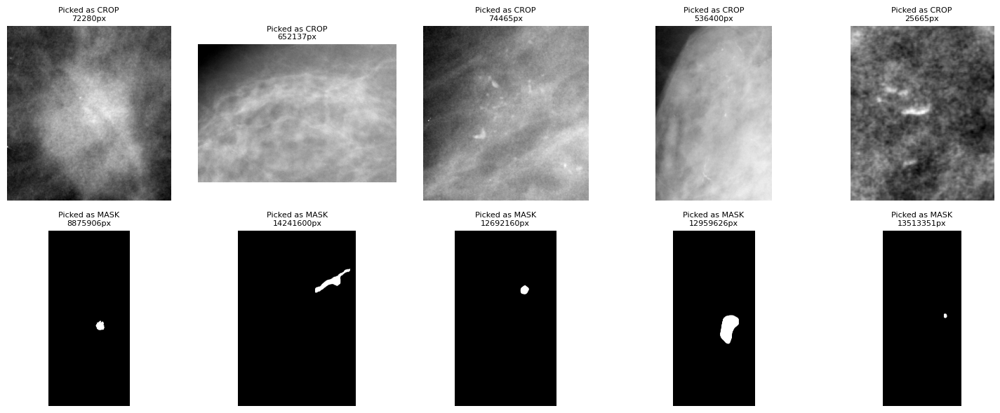

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Find a sample of case folders where get_crop_image_path had to choose
# between two JPEGs by area (the only case where the heuristic matters)
ambiguous_cases = []
for folder in os.listdir(jpeg_root):
    folder_path = os.path.join(jpeg_root, folder)
    if not os.path.isdir(folder_path):
        continue
    jpg_files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(".jpg")])
    if len(jpg_files) == 2:
        ambiguous_cases.append((folder_path, jpg_files))

print(f"Folders with exactly 2 JPEGs (where the area heuristic is used): {len(ambiguous_cases)}")

sample = ambiguous_cases[:5]
fig, axes = plt.subplots(2, len(sample), figsize=(3 * len(sample), 6))
for i, (folder_path, jpg_files) in enumerate(sample):
    sizes = []
    for f in jpg_files:
        img = Image.open(os.path.join(folder_path, f))
        sizes.append((img.width * img.height, f, img))
    sizes.sort(key=lambda x: x[0])  # smaller first — this is what the heuristic picks as "crop"

    axes[0, i].imshow(sizes[0][2], cmap="gray")
    axes[0, i].set_title(f"Picked as CROP\n{sizes[0][0]}px", fontsize=8)
    axes[0, i].axis("off")

    axes[1, i].imshow(sizes[1][2], cmap="gray")
    axes[1, i].set_title(f"Picked as MASK\n{sizes[1][0]}px", fontsize=8)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
missing_count = sum(1 for folder, files in
    [(f, [x for x in os.listdir(os.path.join(jpeg_root, f)) if x.lower().endswith('.jpg')])
     for f in os.listdir(jpeg_root) if os.path.isdir(os.path.join(jpeg_root, f))]
    if len(files) not in (1, 2))
print(f"Folders with an unexpected JPEG count (neither 1 nor 2), returning None: {missing_count}")

Folders with an unexpected JPEG count (neither 1 nor 2), returning None: 0


#### Verification Result

Across the dataset, 3,463 case folders required the two-file disambiguation step. No case had duplicate metadata rows for the same series description, and no folder had an unexpected JPEG count that would have caused a case to be silently dropped. A visual sample of the disambiguated pairs confirmed that the area-based heuristic correctly separates lesion crops from ROI masks in every case checked, with a large and consistent margin in pixel area between the two — masks range from roughly 9 million to 14 million pixels, while crops range from roughly 26,000 to 650,000 pixels. This supports treating the crop selection as reliable across the dataset rather than only for the cases directly inspected.

# 2. Data Preprocessing

This section converts the metadata and image files into labelled, consistently processed inputs for model training and evaluation.


## 2.1 Binary Label Mapping

The pathology labels are converted into the binary classification target used throughout the study. `MALIGNANT` represents the malignant class. `BENIGN` and `BENIGN_WITHOUT_CALLBACK` represent the benign class.


In [ ]:
# Convert the original pathology labels into binary classes
# BENIGN_WITHOUT_CALLBACK is merged with BENIGN

label_mapping = {
    'BENIGN': 'BENIGN',
    'BENIGN_WITHOUT_CALLBACK': 'BENIGN',
    'MALIGNANT': 'MALIGNANT'
}

mass_train['binary_pathology'] = mass_train['pathology'].map(label_mapping)
mass_test['binary_pathology'] = mass_test['pathology'].map(label_mapping)
calc_train['binary_pathology'] = calc_train['pathology'].map(label_mapping)
calc_test['binary_pathology'] = calc_test['pathology'].map(label_mapping)

# Unexpected-value check: catches typos or unlisted pathology categories
# instead of silently producing NaN labels downstream
for name, df in [("mass_train", mass_train), ("mass_test", mass_test),
                  ("calc_train", calc_train), ("calc_test", calc_test)]:
    unexpected = df.loc[df['binary_pathology'].isna(), 'pathology'].unique()
    assert len(unexpected) == 0, f"{name}: unmapped pathology values found: {unexpected}"

print("Label mapping applied with no unexpected pathology values.")

Label mapping applied with no unexpected pathology values.


### Verify Label Mapping

The label counts are checked to confirm that the binary mapping was applied as intended.


In [ ]:
# Check the distribution of the new binary labels
print(mass_train['binary_pathology'].value_counts())
print(calc_train['binary_pathology'].value_counts())

binary_pathology
BENIGN       681
MALIGNANT    637
Name: count, dtype: int64
binary_pathology
BENIGN       1002
MALIGNANT     544
Name: count, dtype: int64


**Result:** The mapping is applied with `.map()`, so any pathology value outside the three expected labels would become `NaN`; the assertion in the mapping cell above confirms none did. The mapped training counts are:

| Lesion type | Benign | Malignant | Malignant % |
|---|---|---|---|
| Mass | 681 | 637 | 48.3% |
| Calcification | 1,002 | 544 | 35.2% |

## 2.2 Combine Mass and Calcification Datasets

The prepared mass and calcification records are combined into a single dataset for model development and evaluation.


In [ ]:
# Combine mass and calcification datasets
# This creates a single dataset for binary lesion classification

train_df = pd.concat(
    [mass_train, calc_train],
    ignore_index=True
)

test_df = pd.concat(
    [mass_test, calc_test],
    ignore_index=True
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (2864, 18)
Test: (704, 18)


**Result:**

| Set | Records | Columns |
|---|---|---|
| Train (mass + calcification) | 2,864 | 18 |
| Test (mass + calcification) | 704 | 18 |

There are 18 columns rather than 15 because the mass and calcification files use different descriptor and density column names; `pd.concat` keeps the union of columns and fills non-applicable fields with `NaN`. These descriptor columns are not model inputs, so the gaps have no effect on training.

## 2.3 Label Encoding

The binary class names are encoded into numeric values required by the model training pipeline.


In [ ]:
# Convert class labels into numerical values
# BENIGN = 0
# MALIGNANT = 1

label_encoder = {
    'BENIGN': 0,
    'MALIGNANT': 1
}

train_df['label'] = train_df['binary_pathology'].map(label_encoder)
test_df['label'] = test_df['binary_pathology'].map(label_encoder)

### Verify Encoded Labels

The encoded labels are checked against the original class names to confirm that the transformation is correct.


In [ ]:
# Verify the numerical label distribution
train_df['label'].value_counts()

,count
label,
0,1683
1,1181


**Result:** 1,683 records encoded as `0` (benign) and 1,181 as `1` (malignant), a 58.8% / 41.2% split. The malignant class is the positive class, so sensitivity (recall on class 1) is the proportion of malignant lesions detected.

### Global Reproducibility Seed

A single seed (`42`) is applied to Python's `random` module, NumPy and TensorFlow, and is also used for the patient-level split and dataset shuffling. This makes weight initialisation, shuffling and augmentation repeatable across runs.

Full determinism is not guaranteed: some cuDNN convolution kernels on the GPU are non-deterministic unless `enable_op_determinism()` is enabled, so small run-to-run differences can still occur. This residual variation is one reason the final models are trained with three seeds (Section 5.2).

In [1]:
# =============================================================================
# Global Reproducibility Seeding — ADD THIS AS THE VERY FIRST CODE CELL,
# before any dataset loading, splitting, or model building
# =============================================================================
import os
import random
import numpy as np
import tensorflow as tf

GLOBAL_SEED = 42  # matches the train/val split's existing random_state=42

os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)

print(f"Global seed set to {GLOBAL_SEED} (Python random, NumPy, TensorFlow).")


# Optional, stronger reproducibility (slower training): forces deterministic
# GPU ops. Test this doesn't break anything on the T4 before relying on it

Global seed set to 42 (Python random, NumPy, TensorFlow).


## 2.4 Train-Validation Split

The training data are divided into training and validation subsets. The validation subset is used during model development, while the held-out test set is reserved for final evaluation.


In [ ]:
leaky = set(train_df['patient_id']) & set(test_df['patient_id'])
train_df = train_df[~train_df['patient_id'].isin(leaky)].reset_index(drop=True)
print("Removed", len(leaky), "overlapping patients; train_df now", train_df.shape)

Removed 31 overlapping patients; train_df now (2781, 19)


In [ ]:
print(len(set(train_df['patient_id']) & set(test_df['patient_id'])))


0


### Cross-Lesion Patient Leakage Removal

The official split is patient-disjoint **within** each lesion type, but not **across** them. After mass and calcification records were combined, 31 patients appeared in both the combined training data and the test set (for example, a patient with a mass in the training file and a calcification in the test file). Images from the same patient share breast anatomy, density and acquisition characteristics, so leaving them in both sets would inflate test performance.

| Step | Training records |
|---|---|
| Combined training data | 2,864 |
| Records from the 31 overlapping patients removed | −83 |
| **Training data after removal** | **2,781** |

The overlapping patients are removed from the **training** side only, so the official test set stays intact at 704 records. The follow-up check confirms 0 shared patients remain.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(train_df, groups=train_df['patient_id']))

train_split = train_df.iloc[train_idx].reset_index(drop=True)
val_split = train_df.iloc[val_idx].reset_index(drop=True)

**Patient-level split.** `GroupShuffleSplit` assigns whole patients (grouped by `patient_id`) to either training or validation, holding out 20% of patients for validation (`random_state=42`).

| Approach | Leakage risk | Class balance |
|---|---|---|
| Record-level stratified split (`train_test_split`, not used) | High: the same patient's CC and MLO views can land on both sides | Exactly preserved |
| Patient-level split (`GroupShuffleSplit`, used) | None: no patient appears in both subsets | Not controlled, preserved only by chance |

A patient-level split was chosen because correlated views of the same patient in both subsets would make validation scores optimistic, which would in turn bias early stopping, hyperparameter selection and threshold selection.

The trade-off is that class balance is not controlled. The resulting validation set is more balanced than the training and test sets (48.2% malignant vs about 40%; see the split composition summary below). This does not affect ROC-AUC, but it does affect thresholds chosen on validation.

### Verify the Split

The resulting subsets are checked to confirm their sizes and class distributions.


In [ ]:
# Check the number of samples in each dataset
print("Training:", train_split.shape)
print("Validation:", val_split.shape)
print("Test:", test_df.shape)

Training: (2273, 19)
Validation: (508, 19)
Test: (704, 19)


**Result of the split**

| Subset | Records | Share of development data |
|---|---|---|
| Training | 2,273 | 81.7% |
| Validation | 508 | 18.3% |
| Test (held out) | 704 | — |

The validation share is below 20% because the split fraction applies to patients, and patients contribute different numbers of records.

### Patient-Level Leakage Check

The train, validation, and test sets are confirmed to share no patients in common. This guards against patient-level leakage, where multiple images from the same patient could otherwise appear across different splits and inflate validation or test performance.

In [ ]:
# Patient-leakage asserts - train vs val, and combined train_df vs test_df
train_patients = set(train_split['patient_id'])
val_patients = set(val_split['patient_id'])
test_patients = set(test_df['patient_id'])

assert train_patients.isdisjoint(val_patients), \
    f"Train/val patient leakage: {train_patients & val_patients}"
assert train_patients.isdisjoint(test_patients), \
    f"Train/test patient leakage: {train_patients & test_patients}"
assert val_patients.isdisjoint(test_patients), \
    f"Val/test patient leakage: {val_patients & test_patients}"

print("No patient leakage between train, validation, and test sets.")

No patient leakage between train, validation, and test sets.


**Result:** All three pairwise checks pass: training, validation and test sets have no patients in common. Because these are assertions, any future change to the split that reintroduced leakage would stop the notebook here instead of silently continuing.

## 2.5 Image Path Generation

Image paths are generated from the metadata so that each record can be linked to its corresponding cropped lesion image.


### Dataset Image Structure

The JPEG repository is organised by image identifiers. Each record may be associated with a full mammogram, a cropped lesion image, and an ROI mask. The preprocessing pipeline selects the cropped lesion image for classification and retains the ROI path for Grad-CAM analysis.


In [ ]:
# ============================================================
# 2.5 Image Path Generation
# ============================================================

import os
from PIL import Image


# Generate the JPEG crop image path from a metadata path
def get_crop_image_path(metadata_path):

    # Extract the JPEG folder identifier from the metadata path
    parts = metadata_path.split("/")
    jpeg_folder = parts[2]

    # Construct the local JPEG folder path
    folder_path = os.path.join(
        jpeg_root,
        jpeg_folder
    )

    # Return None if the JPEG folder does not exist
    if not os.path.exists(folder_path):
        return None

    # Find all JPEG files in the folder
    jpg_files = sorted([
        f
        for f in os.listdir(folder_path)
        if f.lower().endswith(".jpg")
    ])

    # If there is only one JPEG, use it.
    # The inspected single-JPEG cases contain the mammogram crop.
    if len(jpg_files) == 1:

        return os.path.join(
            folder_path,
            jpg_files[0]
        )

    # If there are two JPEGs, identify the crop by image size.
    # The cropped lesion image is much smaller than the ROI mask.
    if len(jpg_files) == 2:

        image_sizes = []

        for jpg_file in jpg_files:

            image_path = os.path.join(
                folder_path,
                jpg_file
            )

            with Image.open(image_path) as image:

                width, height = image.size
                area = width * height

            image_sizes.append(
                (area, jpg_file)
            )

        # Select the JPEG with the smaller image area as the crop.
        crop_file = min(
            image_sizes,
            key=lambda x: x[0]
        )[1]

        return os.path.join(
            folder_path,
            crop_file
        )

    # Return None for unexpected folder structures
    return None

**Crop path resolution rule.** The metadata paths point to DICOM locations, so the function maps each record to the corresponding local JPEG folder (the series UID in the path) and then selects the cropped lesion image:

| Folder content | Selection rule | Rationale |
|---|---|---|
| Folder missing | Return `None` | Record cannot be linked to an image and is removed later |
| 1 JPEG | Use that file | Single-file folders contain the crop |
| 2 JPEGs | Use the file with the **smaller pixel area** | The crop is a small region; the ROI mask is stored at full-mammogram size |
| Any other count | Return `None` | Unexpected structure, excluded for safety (none exist, see the coverage check above) |

## 2.6 Generate Image Paths for All Datasets

This step generates cropped-lesion image paths for the training, validation, and test records.


### Purpose

Each labelled record is linked to its corresponding cropped lesion image so it can be loaded by the training pipeline.


In [ ]:
# ============================================================
# 2.6 Generate Image Paths for All Datasets
# ============================================================

# Generate image paths for all datasets

train_split['image_path'] = train_split[
    'cropped image file path'
].apply(get_crop_image_path)

val_split['image_path'] = val_split[
    'cropped image file path'
].apply(get_crop_image_path)

test_df['image_path'] = test_df[
    'cropped image file path'
].apply(get_crop_image_path)

In [ ]:
# Check for missing image paths

print("Training:", train_split['image_path'].isnull().sum())
print("Validation:", val_split['image_path'].isnull().sum())
print("Test:", test_df['image_path'].isnull().sum())

Training: 1
Validation: 0
Test: 0


**Result:** Only 1 training record has no matching image folder; validation and test are complete. The loss is negligible (0.04% of training records).

Some metadata records do not have a matching JPEG folder. Records without a valid image path are excluded from subsequent image-based analysis.


### 2.6.1 Remove Records with Missing Images

Records without a valid cropped image are removed before dataset construction so that every model input has an accessible image file.


In [ ]:
# Remove records with missing image paths

train_split = train_split.dropna(
    subset=['image_path']
).reset_index(drop=True)

val_split = val_split.dropna(
    subset=['image_path']
).reset_index(drop=True)

test_df = test_df.dropna(
    subset=['image_path']
).reset_index(drop=True)

In [ ]:
# Verify final dataset sizes

print("Training:", train_split.shape)
print("Validation:", val_split.shape)
print("Test:", test_df.shape)

Training: (2272, 20)
Validation: (508, 20)
Test: (704, 20)


In [ ]:
#final verification
# Verify no missing image paths remain

print("Training:", train_split['image_path'].isnull().sum())
print("Validation:", val_split['image_path'].isnull().sum())
print("Test:", test_df['image_path'].isnull().sum())

Training: 0
Validation: 0
Test: 0


**Dataset sizes after removing records without images**

| Subset | Records | Columns |
|---|---|---|
| Training | 2,272 | 20 |
| Validation | 508 | 20 |
| Test | 704 | 20 |

All three subsets now have zero missing image paths. The two extra columns are `label` and `image_path`.

In [ ]:

import numpy as np

# Ground-truth test labels (0 = benign, 1 = malignant), kept in test_df row order
y_true = np.array(test_df['label'].values)

**Ground-truth vector.** `y_true` holds the 704 test labels in `test_df` row order. This order stays valid for evaluation because the test `tf.data` pipelines are built from the same `test_df` columns and are **not shuffled**, so predictions and labels remain aligned index by index. No test images are removed by the decodability screening below, so this vector is unaffected by it.

### 2.6.2 Undecodable Image Screening

A file can exist on disk and still fail to decode as a valid image (a truncated or corrupted JPEG). This is checked separately from the missing-path check above, using the same decode operation the training pipeline itself uses, so any file that would fail during training is caught here instead.

In [ ]:
import tensorflow as tf

def is_decodable(path):
    # Mirrors exactly what the training pipeline does when it loads an
    # image, so this catches anything that would otherwise fail mid-training
    try:
        img_bytes = tf.io.read_file(path)
        tf.image.decode_jpeg(img_bytes, channels=3)
        return True
    except Exception:
        return False

# Flag every image in each split as decodable or not
train_split['decodable'] = train_split['image_path'].apply(is_decodable)
val_split['decodable'] = val_split['image_path'].apply(is_decodable)
test_df['decodable'] = test_df['image_path'].apply(is_decodable)

print("Training undecodable:", (~train_split['decodable']).sum())
print("Validation undecodable:", (~val_split['decodable']).sum())
print("Test undecodable:", (~test_df['decodable']).sum())

Training undecodable: 0
Validation undecodable: 0
Test undecodable: 0


In [ ]:
# Remove undecodable images, same pattern as the missing-path removal above,
# and drop the helper column now that it's done its job
train_split = train_split[train_split['decodable']].drop(columns=['decodable']).reset_index(drop=True)
val_split = val_split[val_split['decodable']].drop(columns=['decodable']).reset_index(drop=True)
test_df = test_df[test_df['decodable']].drop(columns=['decodable']).reset_index(drop=True)

print("Training:", train_split.shape)
print("Validation:", val_split.shape)
print("Test:", test_df.shape)

Training: (2272, 20)
Validation: (508, 20)
Test: (704, 20)


**Result:** Every file in all three subsets decodes successfully (0 failures), so no records are removed and the subset sizes are unchanged (2,272 / 508 / 704). The check uses the same `decode_jpeg(channels=3)` call as the training pipeline, so a pass here guarantees no image will fail mid-training.

### Split Composition Summary

A single summary table records how many patients, images, benign cases, malignant cases, mass cases, and calcification cases fall into each split, once the splits are fully finalised. The split dataframes and this summary are also saved to Drive as CSVs, giving a permanent, exact record of what was used for training, validation, and testing.

In [ ]:
def build_split_summary(df, split_name):
    # 'abnormality type' holds each row's own category label (mass/calc),
    # so this picks up whatever the real values are without hardcoding them
    type_counts = df['abnormality type'].value_counts().to_dict()
    return {
        'Split': split_name,
        'Patients': df['patient_id'].nunique(),
        'Images': len(df),
        'Benign': (df['binary_pathology'] == 'BENIGN').sum(),
        'Malignant': (df['binary_pathology'] == 'MALIGNANT').sum(),
        **type_counts
    }

split_summary_df = pd.DataFrame([
    build_split_summary(train_split, 'Train'),
    build_split_summary(val_split, 'Validation'),
    build_split_summary(test_df, 'Test'),
])
display(split_summary_df)

,Split,Patients,Images,Benign,Malignant,calcification,mass
0,Train,973,2272,1372,900,1244,1028
1,Validation,244,508,263,245,245,263
2,Test,349,704,428,276,326,378


**Final split composition**

| Split | Patients | Images | Benign | Malignant | Malignant % | Mass | Calcification |
|---|---|---|---|---|---|---|---|
| Train | 973 | 2,272 | 1,372 | 900 | 39.6% | 1,028 | 1,244 |
| Validation | 244 | 508 | 263 | 245 | 48.2% | 263 | 245 |
| Test | 349 | 704 | 428 | 276 | 39.2% | 378 | 326 |

- The three splits contain 1,566 distinct patients with no overlap.
- Training and test have almost the same malignant proportion (39.6% vs 39.2%), but the validation set is noticeably more balanced (48.2%). This is a side effect of splitting by patient without stratification. It matters for any metric that depends on class prevalence (accuracy, precision) and for thresholds chosen on validation, but not for ROC-AUC, which is prevalence-independent.
- Mass and calcification cases are represented in every split, which allows the lesion-type analysis later in the study.

In [ ]:
import os

DRIVE_SPLITS_DIR = "/content/drive/MyDrive/dataset_splits"
os.makedirs(DRIVE_SPLITS_DIR, exist_ok=True)

# Save the actual split dataframes, not just the summary — this is the
# exact record of which rows were used, useful if the split ever needs
# to be reproduced or defended later
train_split.to_csv(os.path.join(DRIVE_SPLITS_DIR, "train_split.csv"), index=False)
val_split.to_csv(os.path.join(DRIVE_SPLITS_DIR, "val_split.csv"), index=False)
test_df.to_csv(os.path.join(DRIVE_SPLITS_DIR, "test_df.csv"), index=False)
split_summary_df.to_csv(os.path.join(DRIVE_SPLITS_DIR, "split_composition_summary.csv"), index=False)

print(f"Split CSVs and composition summary saved to {DRIVE_SPLITS_DIR}")

Split CSVs and composition summary saved to /content/drive/MyDrive/dataset_splits


# 2.7 Image Preprocessing

This section defines how cropped lesion images are loaded, resized, normalised, and augmented before they are passed to the models.


## 2.7.1 Image Loading Function

The image-loading function reads each cropped lesion image, converts it to the required channel format, and resizes it to the model input dimensions.


In [ ]:
# ============================================================
# 2.7.1 Image Loading Function
# ============================================================

from PIL import Image
import numpy as np

# Load and preprocess an image

def load_image(image_path):

    # Open image
    image = Image.open(image_path)

    # Convert to RGB
    image = image.convert("RGB")

    # Resize image
    image = image.resize((224, 224))

    # Convert to NumPy array
    image = np.array(image)

    return image

## 2.7.2 Verify Image Preprocessing

Sample images are displayed after preprocessing to verify their dimensions and visual appearance before training.


Shape: (224, 224, 3)


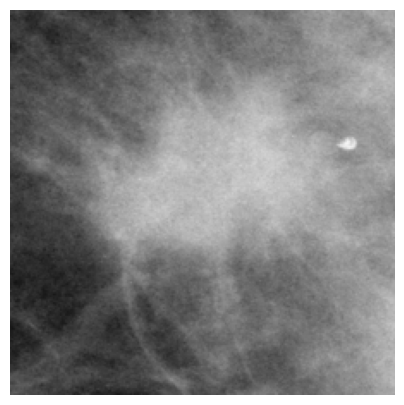

In [ ]:
import matplotlib.pyplot as plt


# Display a sample preprocessed image

sample_image_path = train_split[
    'image_path'
].iloc[0]

image = load_image(sample_image_path)

print("Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis('off')
plt.show()

**Result:** The sample crop is loaded as a 224 × 224 × 3 array. Mammograms are greyscale, so converting to RGB copies the single intensity channel into three identical channels, which is the input format expected by ImageNet-pretrained networks.

This `load_image` helper is used only for visual inspection. The training pipeline uses the TensorFlow loader in Section 3.2.2, which additionally applies CLAHE.

### 2.7.3 Training Data Augmentation

Augmentation is applied to training images to introduce controlled variation and reduce reliance on exact image appearances. Validation and test images are not augmented.


In [ ]:
# ============================================================
# 2.7.3 Training Data Augmentation
# ============================================================

import tensorflow as tf

# Data augmentation for training images
# The explicit Input layer keeps the augmentation pipeline
# independent of a fixed batch size.
data_augmentation = tf.keras.Sequential([

    # Small random rotations
    tf.keras.layers.RandomRotation(
        factor=0.05
    ),

    # Small horizontal and vertical shifts
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),

    # Small zoom augmentation
    tf.keras.layers.RandomZoom(
        height_factor=0.05,
        width_factor=0.05
    ),

    # Horizontal flip - mammogram left/right breast images are mirror images
    tf.keras.layers.RandomFlip("horizontal")
])

**Augmentation settings (training data only)**

| Layer | Setting | Effective range |
|---|---|---|
| `RandomRotation` | `factor=0.05` | ±0.05 × 360° = ±18° |
| `RandomTranslation` | `height_factor=0.05`, `width_factor=0.05` | Up to ±5% shift (about ±11 px at 224 px) |
| `RandomZoom` | `height_factor=0.05`, `width_factor=0.05` | ±5% zoom |
| `RandomFlip` | `"horizontal"` | Left–right mirror with 50% probability |

- Rotation, translation and zoom are deliberately small: lesion crops are already centred on the abnormality, so large shifts or zooms could move the lesion out of view or change its apparent size, which is itself a diagnostic cue.
- Horizontal flipping is anatomically plausible because left and right breasts are mirror images, so it effectively doubles the variety of orientations without creating unrealistic images.
- Validation and test data are never augmented, so evaluation reflects the unaltered images.

### 2.7.4 Normalisation Strategy

The normalisation applied to the images is selected to match the input requirements of the baseline CNN and the pretrained architectures.


**Normalisation by model**

| Model | Where normalisation happens | Implemented in | Transformation |
|---|---|---|---|
| Baseline CNN | Inside the model | `Rescaling(1./255)` layer (Section 4.1; `build_baseline_cnn` in 4.5.2) | Pixel values scaled from [0, 255] to [0, 1] |
| VGG16 | In the input pipeline | `vgg16.preprocess_input` in `process_image_vgg` (Section 4.2) | RGB → BGR, per-channel ImageNet mean subtracted ("caffe" mode) |
| ResNet50 | In the input pipeline | `resnet50.preprocess_input` in `process_image_resnet` (Section 4.3) | Same "caffe" mode as VGG16 |
| EfficientNetB0 | Inside the model | Built-in rescaling and normalisation layers of the backbone; `efficientnet.preprocess_input` in `process_image_efficientnet` (Section 4.4) passes values through unchanged | Expects raw 0–255 input |

All loaders apply CLAHE to the 0–255 image first, so every model receives the same contrast-enhanced image before its own normalisation. Each pretrained network then receives inputs in the same numerical range as during its ImageNet training. Mismatched scaling would shift feature activations away from those the pretrained filters were learned on and reduce the benefit of transfer learning.

## 2.8 Class Weight Calculation

Class weights are calculated from the training labels to reduce the effect of class imbalance during model training. The weights are derived from the training data only.


In [ ]:
# ============================================================
# 2.8 Class Weight Calculation
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

#whats happening :
# Calculate class weights to reduce the effect
# of class imbalance during model training

# Higher weight is assigned to the minority class

# These weights will later be passed into
# model.fit(class_weight=class_weights)




# Calculate class weights from training labels

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_split['label']),
    y=train_split['label']
)

# Convert to dictionary format for Keras

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weights)

{0: np.float64(0.8279883381924198), 1: np.float64(1.2622222222222221)}


In [ ]:
# Display class weights

print("BENIGN (0):", class_weights[0])
print("MALIGNANT (1):", class_weights[1])

BENIGN (0): 0.8279883381924198
MALIGNANT (1): 1.2622222222222221


**Class weights.** The `balanced` strategy sets each weight to *n_samples / (n_classes × n_class_samples)*, computed from the 2,272 training images (1,372 benign, 900 malignant):

| Class | Weight | Effect |
|---|---|---|
| Benign (0) | 0.828 | Each benign error counts slightly less |
| Malignant (1) | 1.262 | Each malignant error counts about 1.52× more than a benign error |

The weights are derived from the training subset only, so no information from validation or test data influences training. They are passed to every `fit()` call in Sections 4 and 5, so all configurations handle the imbalance in the same way.

# 3. Dataset Preparation for Training

This section converts the processed image paths and labels into TensorFlow datasets that can be used consistently by all model configurations.


## 3.1 Dataset Preparation for Training

Image paths and binary labels are organised into a format suitable for loading during model training, validation, and testing.


In [ ]:
# ============================================================
# 3.1 Dataset Preparation for Training
# ============================================================

# Extract image paths

train_paths = train_split['image_path'].values

val_paths = val_split['image_path'].values

test_paths = test_df['image_path'].values


# Extract labels

train_labels = train_split['label'].values

val_labels = val_split['label'].values

test_labels = test_df['label'].values

In [ ]:
# Verify dataset sizes

print("Training Images:", len(train_paths))
print("Validation Images:", len(val_paths))
print("Test Images:", len(test_paths))

Training Images: 2272
Validation Images: 508
Test Images: 704


## 3.2 TensorFlow Dataset Pipeline

Reusable TensorFlow datasets are created for the training, validation, and test subsets. The same pipeline structure supports the baseline CNN, VGG16, and ResNet50 models.


### 3.2.1 Training Configuration

The batch size, shuffle settings, and other dataset parameters are defined before the datasets are created.


In [ ]:
# ============================================================
# 3.2.1 Training Configuration
# ============================================================

# Image dimensions

IMG_HEIGHT = 224
IMG_WIDTH = 224

# Training batch size

BATCH_SIZE = 32

### 3.2.2 Image Loading Function for TensorFlow

This function loads an image from its path and returns the processed image together with its binary label.


### CLAHE Contrast Enhancement

Mammograms have low contrast between lesions and surrounding fibroglandular tissue, especially in dense breasts. CLAHE (Contrast Limited Adaptive Histogram Equalisation) equalises the histogram separately within small tiles, so local lesion boundaries are enhanced without over-amplifying the whole image.

| Parameter | Value | Meaning |
|---|---|---|
| `clipLimit` | 2.0 | Caps histogram peaks to limit noise amplification |
| `tileGridSize` | 8 × 8 | 64 tiles of 28 × 28 px on a 224 × 224 image |

**Implementation details**

- OpenCV's CLAHE has no TensorFlow equivalent, so it is wrapped with `tf.numpy_function`, and the static shape is restored afterwards so that batching still works.
- CLAHE is applied **after** resizing, so tile size is identical for every image regardless of the original crop resolution (68 px to about 3,000 px).
- It is applied in every pipeline (baseline, VGG16, ResNet50, EfficientNetB0) before any model-specific normalisation, so every configuration sees the same enhanced input.

In [ ]:
# =============================================================================
# CLAHE Preprocessing Helper (used by every image-loading pipeline)
# =============================================================================
# Mammography images are inherently low-contrast; CLAHE (Contrast Limited
# Adaptive Histogram Equalization) enhances local contrast per-tile rather
# than globally, which helps bring out lesion boundaries that a single
# global contrast stretch would miss. Applied to every model pipeline so
# all configurations receive identical input.
#
# TensorFlow has no built-in CLAHE, so this wraps OpenCV's implementation
# via tf.numpy_function. Applied AFTER resize (not before), so the fixed
# 224x224 size gives consistent tile behaviour regardless of each crop's
# original resolution (crops range from 68 px to about 3,000 px).

import cv2

CLAHE_CLIP_LIMIT = 2.0 # caps histogram peaks per tile, limiting noise amplification
CLAHE_TILE_GRID_SIZE = (8, 8)# 8x8 tiles = 64 regions of 28x28 px on a 224x224 imag

def _clahe_numpy(image_uint8):
    """Runs on the Python/NumPy side (cv2 has no TF-graph equivalent).
    image_uint8: (H, W, 3) uint8 array, R == G == B (grayscale stored as
    RGB, per this dataset's convert('RGB') step)."""
    gray = image_uint8[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID_SIZE)
    enhanced = clahe.apply(gray) # histogram equalisation within each tile, blended at tile borders
    # Copy the enhanced channel back to 3 channels, as ImageNet models expect RGB input
    return np.stack([enhanced, enhanced, enhanced], axis=-1).astype(np.uint8)

def apply_clahe(image):
    """TF-graph-compatible wrapper.
    image: float32 tensor (H, W, 3), values in [0, 255], as returned by
    tf.image.resize on a decoded JPEG (BEFORE any /255 rescaling or
    architecture-specific preprocess_input)."""
    # Resizing can produce values slightly outside [0, 255]; clip, then convert to uint8 for OpenCV
    image_uint8 = tf.cast(tf.clip_by_value(image, 0, 255), tf.uint8)
    # Run the OpenCV function inside the tf.data pipeline
    enhanced = tf.numpy_function(_clahe_numpy, [image_uint8], tf.uint8)
    enhanced.set_shape(image.shape)  # tf.numpy_function loses static shape info
     # Back to float32 in [0, 255], so model-specific normalisation can follow unchanged
    return tf.cast(enhanced, tf.float32)

In [ ]:
# ============================================================
# 3.2.2 TensorFlow Image Loader
# ============================================================

import tensorflow as tf

# Load and preprocess image

def process_image(image_path, label):

    # Read image file
    image = tf.io.read_file(image_path)

    # Decode JPEG image
    image = tf.image.decode_jpeg( image, channels=3 )

    # Resize image
    image = tf.image.resize(image,  [IMG_HEIGHT, IMG_WIDTH] )

    # Adding CLAHE
    image = apply_clahe(image)

    return image, label

**Baseline CNN loader.** For each file path the function performs, in order:

1. `tf.io.read_file` → raw JPEG bytes
2. `decode_jpeg(channels=3)` → 3-channel image (greyscale replicated)
3. `resize` to 224 × 224 → float32 values in [0, 255]
4. `apply_clahe` → contrast-enhanced image, still in [0, 255]

No scaling is applied here, because the baseline model rescales to [0, 1] internally.

### 3.2.3 Create TensorFlow Datasets

The image paths and labels are converted into TensorFlow datasets for each data subset.


In [ ]:
# ============================================================
# 3.2.3 Create TensorFlow Datasets
# ============================================================

# Training dataset

# train_dataset = tf.data.Dataset.from_tensor_slices(
#     (train_paths, train_labels)
# )
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
).shuffle(buffer_size=len(train_paths), seed=42)

# Validation dataset

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

# Test dataset

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

### 3.2.4 Apply Image Processing

The image-loading and preprocessing operations are mapped across the dataset records.


In [ ]:
# ============================================================
# 3.2.4 Apply Image Processing
# ============================================================

# Apply basic image loading and resizing
train_dataset = train_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Apply data augmentation ONLY to the training dataset
train_dataset = train_dataset.map(
    lambda image, label: (
        data_augmentation(
            image,
            training=True
        ),
        label
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

### 3.2.5 Batch and Prefetch

The datasets are batched and prefetched to improve the efficiency of input delivery during model training and evaluation.


In [ ]:
# Batch datasets

train_dataset = train_dataset.batch(
    BATCH_SIZE
)

val_dataset = val_dataset.batch(
    BATCH_SIZE
)

test_dataset = test_dataset.batch(
    BATCH_SIZE
)

# Improve training performance

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [ ]:
# Verify dataset pipeline

for images, labels in train_dataset.take(1):

    print("Image batch shape:", images.shape)

    print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


**Baseline CNN input pipeline**

| Stage | Train | Validation / Test |
|---|---|---|
| Source | `from_tensor_slices(paths, labels)` | Same |
| Shuffle | Full-buffer shuffle, `seed=42` | None (order preserved for evaluation) |
| Load + CLAHE | `process_image`, parallel (`AUTOTUNE`) | Same |
| Augmentation | Rotation, translation, zoom, horizontal flip | None |
| Batch | 32 | 32 |
| Prefetch | `AUTOTUNE` | `AUTOTUNE` |

**Result:** A training batch has shape `(32, 224, 224, 3)` with labels `(32,)`, confirming the pipeline produces correctly sized inputs. With 2,272 training images this gives 71 steps per epoch.

## 4. Model Design and Implementation

This section defines the training-from-scratch baseline and the transfer learning models used to compare architectures and fine-tuning strategies.


In [ ]:
# #run this first to pull the verified-good checkpoints into the folder my resumable cells check

# import shutil, os

# SRC_DIR = "/content/drive/MyDrive/Colab Notebooks/checkpoints_backup"
# DST_DIR = "/content/drive/MyDrive/section4_checkpoints"
# os.makedirs(DST_DIR, exist_ok=True)

# for fname in ["best_baseline_cnn.keras", "best_vgg16_frozen.keras", "best_vgg16_partial.keras",
#               "best_resnet50_frozen.keras", "best_resnet50_partial.keras"]:
#     shutil.copy(os.path.join(SRC_DIR, fname), os.path.join(DST_DIR, fname))
#     print(f"Copied {fname}")

In [ ]:
# import os
# DRIVE_CKPT_DIR = "/content/drive/MyDrive/section4_checkpoints"
# for fname in ["best_baseline_cnn.keras", "best_vgg16_frozen.keras", "best_vgg16_partial.keras",
#               "best_resnet50_frozen.keras", "best_resnet50_partial.keras"]:
#     path = os.path.join(DRIVE_CKPT_DIR, fname)
#     if os.path.exists(path):
#         os.remove(path)
#         print(f"Deleted {path}")

### Checkpointing and Run Log

Training in Colab can be interrupted by runtime disconnects, so each Section 4 training cell is **resumable**:

- The best checkpoint (lowest validation loss) is written directly to Google Drive (`section4_checkpoints/`).
- If a checkpoint already exists, training is skipped and the saved model is loaded instead.
- `log_section4_run` appends one JSON line per model to `section4_run_log.jsonl`, recording whether the model was trained or loaded, the number of epochs, validation AUC and loss, and run time.

The models trained in Section 4 use **default hyperparameters** (Adam, learning rate 0.001, dropout 0.5). They serve as the untuned reference point that the hyperparameter search in Section 4.5 is compared against.

In [ ]:
# ============================================================
# Section 4 Run Log - shared helper
# ============================================================
import os, json, time

DRIVE_CKPT_DIR = "/content/drive/MyDrive/section4_checkpoints"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
SECTION4_LOG_PATH = os.path.join(DRIVE_CKPT_DIR, "section4_run_log.jsonl")

def log_section4_run(model_name, action, epochs_used, val_metrics, ckpt_path, seconds):
    entry = {
        "model": model_name,
        "action": action,          # "trained" or "loaded_existing"
        "epochs_used": epochs_used,
        "val_auc": val_metrics.get("auc"),
        "val_loss": val_metrics.get("loss"),
        "checkpoint": ckpt_path,
        "seconds": round(seconds, 1),
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    }
    with open(SECTION4_LOG_PATH, "a") as f:
        f.write(json.dumps(entry) + "\n")
    print(f"Logged: {model_name} ({action}, {epochs_used if epochs_used else 'n/a'} epochs)")

## 4.1 Baseline CNN Architecture

The baseline CNN is trained from scratch and provides the reference point for evaluating whether transfer learning improves classification performance.


In [ ]:
# ============================================================
# 4.1 Baseline CNN Architecture
# ============================================================

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Rescaling,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

# Build baseline CNN

cnn_model = Sequential([

    # Define input image size
    Input(shape=(224, 224, 3)),



    # Normalise pixel values to [0,1]
    Rescaling(1./255),

    # Convolution Block 1
    Conv2D(
        32,
        (3,3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D(),

    # Convolution Block 2
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D(),

    # Convolution Block 3
    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D(),

    # Reduce feature maps into a compact feature vector
    GlobalAveragePooling2D(),

    # Fully connected layer for classification
       Dense(
    128,
    activation='relu'
    ),
    BatchNormalization(),

    # Reduce overfitting
    Dropout(0.5),


    # Binary classification output
    Dense(
    1,
    activation='sigmoid'
    )
],name="Baseline_CNN")

In [ ]:
# Build model
cnn_model.build(
    input_shape=(None, 224, 224, 3)
)

# Display model summary
cnn_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,297 (434.75 KB)

 Trainable params: 110,593 (432.00 KB)

 Non-trainable params: 704 (2.75 KB)

**Baseline CNN architecture**

| Stage | Layers | Output shape | Parameters |
|---|---|---|---|
| Input + scaling | `Rescaling(1/255)` | 224 × 224 × 3 | 0 |
| Block 1 | Conv 32 (3×3, ReLU) → BN → MaxPool | 111 × 111 × 32 | 1,024 |
| Block 2 | Conv 64 (3×3, ReLU) → BN → MaxPool | 54 × 54 × 64 | 18,752 |
| Block 3 | Conv 128 (3×3, ReLU) → BN → MaxPool | 26 × 26 × 128 | 74,368 |
| Head | GAP → Dense 128 (ReLU) → BN → Dropout → Dense 1 (sigmoid) | 1 | 17,153 |
| **Total** | | | **111,297** (110,593 trainable) |

- The 704 non-trainable parameters are the BatchNorm moving means and variances.
- Global Average Pooling replaces flattening, which keeps the parameter count low (about 0.75% of the VGG16 model) and reduces overfitting on a small dataset.
- The classification head (GAP → Dense 128 → BN → Dropout → sigmoid) is identical to the head used by every transfer learning model, so performance differences can be attributed to the feature extractor rather than the head.

### Compile Baseline CNN

The baseline CNN is compiled for binary classification using Adam, binary cross-entropy, accuracy, precision, recall, and ROC-AUC.


In [ ]:
# ============================================================
# 4.1 Baseline CNN
# ============================================================

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the baseline CNN

cnn_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

**Default training configuration (Section 4, all seven configurations)**

| Setting | Value | Reason |
|---|---|---|
| Optimiser | Adam, learning rate 0.001 | Standard default, adaptive per-parameter step sizes |
| Loss | Binary cross-entropy | Single sigmoid output for benign vs malignant |
| Metrics | Accuracy, Precision, Recall, AUC | Recall tracks sensitivity to malignancy; AUC is threshold-independent |
| Class weights | {0: 0.828, 1: 1.262} | Compensates for the 60 / 40 class imbalance |
| Max epochs | 30 | Upper bound on training time |
| Early stopping | `val_loss`, patience 5, restore best weights | Stops once validation loss stops improving |
| Checkpoint | Best `val_loss` only | Keeps the best generalising weights |

In [ ]:
# ============================================================
# 4.1 Baseline CNN
# Training Callbacks & Model Training
# ============================================================

import os
import time
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

if "training_validation_results" not in globals():
    training_validation_results = {}

DRIVE_CKPT_DIR = "/content/drive/MyDrive/section4_checkpoints"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
baseline_ckpt_path = os.path.join(DRIVE_CKPT_DIR, "best_baseline_cnn.keras")

start = time.time()
if os.path.exists(baseline_ckpt_path):
    print(f"Checkpoint already on Drive, skipping training: {baseline_ckpt_path}")
    cnn_model = load_model(baseline_ckpt_path)
    action, epochs_used = "loaded_existing", None
else:
    print(f"No checkpoint found on Drive, training now: {baseline_ckpt_path}")
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model_checkpoint = ModelCheckpoint(filepath=baseline_ckpt_path, monitor='val_loss', save_best_only=True)
    history = cnn_model.fit(
        train_dataset, validation_data=val_dataset, epochs=30,
        class_weight=class_weights, callbacks=[early_stopping, model_checkpoint]
    )
    cnn_model = load_model(baseline_ckpt_path)
    action, epochs_used = "trained", len(history.history["loss"])

train_metrics = cnn_model.evaluate(train_dataset, verbose=0, return_dict=True)
val_metrics = cnn_model.evaluate(val_dataset, verbose=0, return_dict=True)

training_validation_results["Baseline CNN"] = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "AUC"],
    "Training": [train_metrics["accuracy"], train_metrics["precision"], train_metrics["recall"], train_metrics["auc"]],
    "Validation": [val_metrics["accuracy"], val_metrics["precision"], val_metrics["recall"], val_metrics["auc"]],
})

log_section4_run("Baseline CNN", action, epochs_used, val_metrics, baseline_ckpt_path, time.time() - start)

print("Baseline CNN - Training and Validation Performance")
display(training_validation_results["Baseline CNN"])

Checkpoint already on Drive, skipping training: /content/drive/MyDrive/section4_checkpoints/best_baseline_cnn.keras
Logged: Baseline CNN (loaded_existing, n/a epochs)
Baseline CNN - Training and Validation Performance


,Metric,Training,Validation
0,Accuracy,0.613116,0.535433
1,Precision,0.514132,0.522388
2,Recall,0.424444,0.428571
3,AUC,0.636761,0.592139


**Baseline CNN (default) training result**

Training ran for 7 epochs; the lowest validation loss (0.676) occurred at epoch 2, after which validation loss drifted upwards and reached 1.01 at epoch 7. In this run the saved checkpoint was reloaded rather than retrained; training metrics are re-evaluated on the augmented training set, so they vary slightly between runs.

| Metric | Training | Validation |
|---|---|---|
| Accuracy | 0.613 | 0.535 |
| Precision | 0.514 | 0.522 |
| Recall | 0.424 | 0.429 |
| AUC | 0.637 | 0.592 |

- Validation AUC of 0.592 is only modestly above chance (0.5), and validation accuracy (0.535) is barely above the 51.8% that predicting "benign" for every validation image would achieve.
- Training AUC is also low (0.637), so the problem is **underfitting**: a small network trained from scratch on about 2,300 images does not learn strongly discriminative lesion features.

The training and validation results provide the baseline against which the transfer learning models are compared. These values describe model performance during development and are not the final test-set results.


## 4.2 VGG16

VGG16 is evaluated using two transfer learning strategies: frozen feature extraction and partial fine-tuning.


### Dataset Preparation

The VGG16 models use the same labelled image subsets and preprocessing pipeline as the baseline CNN.


In [ ]:
# ============================================================
# 4.2 VGG16 Image Preprocessing
# ============================================================

from tensorflow.keras.applications.vgg16 import preprocess_input

def process_image_vgg(image_path, label, augment=False):

    # Read image file
    image = tf.io.read_file(image_path)

    # Decode JPEG image
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize image
    image = tf.image.resize(
        image,
        [224, 224]
    )


     # Enhance local contrast
    image = apply_clahe(image)


    # Apply augmentation only when explicitly enabled
    if augment:
        image = data_augmentation(
            image,
            training=True
        )

    # Convert image to float32
    image = tf.cast(
        image,
        tf.float32
    )

    # Apply VGG16 ImageNet preprocessing
    image = preprocess_input(image)

    return image, label

In [ ]:
#Create VGG16 datasets

In [ ]:
# Training dataset

# train_dataset_vgg = tf.data.Dataset.from_tensor_slices(
#     (
#         train_split['image_path'].values,
#         train_split['label'].values
#     )
# )

train_dataset_vgg = tf.data.Dataset.from_tensor_slices(
    (
        train_split['image_path'].values,
        train_split['label'].values
    )
).shuffle(buffer_size=len(train_split), seed=42)

train_dataset_vgg = (
    train_dataset_vgg
    .map(
        lambda image_path, label: process_image_vgg(
            image_path,
            label,
            augment=True
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation dataset

val_dataset_vgg = tf.data.Dataset.from_tensor_slices(
    (
        val_split['image_path'].values,
        val_split['label'].values
    )
)

val_dataset_vgg = (
    val_dataset_vgg
    .map(process_image_vgg,
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# Test dataset

test_dataset_vgg = tf.data.Dataset.from_tensor_slices(
    (
        test_df['image_path'].values,
        test_df['label'].values
    )
)

test_dataset_vgg = (
    test_dataset_vgg
    .map(process_image_vgg,
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

**VGG16 input pipeline.** `process_image_vgg` differs from the baseline loader in two ways:

| Step | Baseline CNN | VGG16 |
|---|---|---|
| Augmentation | Separate `map` after loading | Inside the loader, enabled with `augment=True` for training only |
| Normalisation | In the model (`/255`) | `vgg16.preprocess_input` (BGR, ImageNet mean subtraction) |

Augmentation is applied before `preprocess_input`, while values are still in the [0, 255] range, so augmented and unaugmented images are normalised in exactly the same way. The training set is shuffled with `seed=42`; validation and test sets keep their original order.

### 4.2.1 Frozen Feature Extraction

The pretrained VGG16 convolutional base is kept frozen, and only the added classification layers are trained. This measures the effectiveness of using fixed pretrained features.


In [ ]:
# ============================================================
# 4.2 VGG16 Frozen - build base model
# ============================================================

from tensorflow.keras.applications import VGG16

# Load pretrained VGG16 model

vgg_base = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)
)

# Freeze all pretrained layers

for layer in vgg_base.layers:
    layer.trainable = False

print("Trainable layers:",
      sum(layer.trainable for layer in vgg_base.layers))

Trainable layers: 0


In [ ]:
#build VGG16 Frozen Model

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    BatchNormalization,
    Dense,
    Dropout
)

vgg16_frozen = Sequential([

    Input(shape=(224, 224, 3)),

    vgg_base,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

], name="VGG16_Frozen")

vgg16_frozen.summary()

Model: "VGG16_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,993 (56.39 MB)

 Trainable params: 66,049 (258.00 KB)

 Non-trainable params: 14,714,944 (56.13 MB)

**VGG16 (Frozen) model**

| Component | Parameters | Trainable |
|---|---|---|
| VGG16 convolutional base (13 conv layers) | 14,714,688 | No |
| Classification head | 66,305 | 66,049 (BN moving statistics excluded) |
| **Total** | **14,780,993** | **66,049 (0.45%)** |

The base outputs a 7 × 7 × 512 feature map. With all base layers frozen (`Trainable layers: 0`), the ImageNet features act as a fixed feature extractor and only the head learns to map them to benign or malignant.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the VGG16 Frozen model
vgg16_frozen.compile(

    # Adam optimizer for model training
    optimizer=Adam(
        learning_rate=0.001
    ),

    # Binary classification loss function
    loss='binary_crossentropy',

    # Evaluation metrics tracked during training
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

In [ ]:
# ============================================================
# 4.2 VGG16 Frozen Model
# Training Callbacks & Model Training
# ============================================================

import os
import time
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

if "training_validation_results" not in globals():
    training_validation_results = {}

DRIVE_CKPT_DIR = "/content/drive/MyDrive/section4_checkpoints"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
vgg16_frozen_ckpt_path = os.path.join(DRIVE_CKPT_DIR, "best_vgg16_frozen.keras")

start = time.time()
if os.path.exists(vgg16_frozen_ckpt_path):
    print(f"Checkpoint already on Drive, skipping training: {vgg16_frozen_ckpt_path}")
    vgg16_frozen = load_model(vgg16_frozen_ckpt_path)
    action, epochs_used = "loaded_existing", None
else:
    print(f"No checkpoint found on Drive, training now: {vgg16_frozen_ckpt_path}")
    early_stopping_vgg = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model_checkpoint_vgg = ModelCheckpoint(filepath=vgg16_frozen_ckpt_path, monitor='val_loss', save_best_only=True)
    history = vgg16_frozen.fit(
        train_dataset_vgg, validation_data=val_dataset_vgg, epochs=30,
        class_weight=class_weights, callbacks=[early_stopping_vgg, model_checkpoint_vgg]
    )
    vgg16_frozen = load_model(vgg16_frozen_ckpt_path)
    action, epochs_used = "trained", len(history.history["loss"])

train_metrics = vgg16_frozen.evaluate(train_dataset_vgg, verbose=0, return_dict=True)
val_metrics = vgg16_frozen.evaluate(val_dataset_vgg, verbose=0, return_dict=True)
training_validation_results["VGG16 (Frozen)"] = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "AUC"],
    "Training": [train_metrics["accuracy"], train_metrics["precision"], train_metrics["recall"], train_metrics["auc"]],
    "Validation": [val_metrics["accuracy"], val_metrics["precision"], val_metrics["recall"], val_metrics["auc"]],
})

log_section4_run("VGG16 (Frozen)", action, epochs_used, val_metrics, vgg16_frozen_ckpt_path, time.time() - start)

print("VGG16 (Frozen) - Training and Validation Performance")
display(training_validation_results["VGG16 (Frozen)"])

No checkpoint found on Drive, training now: /content/drive/MyDrive/section4_checkpoints/best_vgg16_frozen.keras
Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 80s 887ms/step - accuracy: 0.5753 - auc: 0.6207 - loss: 0.8270 - precision: 0.4726 - recall: 0.6233 - val_accuracy: 0.5984 - val_auc: 0.6528 - val_loss: 0.7566 - val_precision: 0.5779 - val_recall: 0.6204
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 874ms/step - accuracy: 0.6140 - auc: 0.6780 - loss: 0.7182 - precision: 0.5100 - recall: 0.6500 - val_accuracy: 0.6063 - val_auc: 0.6566 - val_loss: 0.7960 - val_precision: 0.5733 - val_recall: 0.7184
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 53s 746ms/step - accuracy: 0.6298 - auc: 0.7008 - loss: 0.6711 - precision: 0.5265 - recall: 0.6511 - val_accuracy: 0.6181 - val_auc: 0.6642 - val_loss: 0.7409 - val_precision: 0.6220 - val_recall: 0.5306
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 54s 768ms/step - accuracy: 0.6378 - auc: 0.7013 - loss: 0.6560 - precision: 0.5343 - recall: 0.6656 - val_accuracy: 0.610

,Metric,Training,Validation
0,Accuracy,0.732835,0.647638
1,Precision,0.637559,0.663366
2,Recall,0.754444,0.546939
3,AUC,0.815430,0.702770


**VGG16 (Frozen, default) training result**

Training ran for 24 epochs; the best validation loss (0.643) occurred at epoch 19.

| Metric | Training | Validation |
|---|---|---|
| Accuracy | 0.733 | 0.648 |
| Precision | 0.638 | 0.663 |
| Recall | 0.754 | 0.547 |
| AUC | 0.815 | 0.703 |

- Frozen ImageNet features raise validation AUC from 0.592 (baseline) to 0.703, confirming that pretrained edge, texture and shape filters transfer usefully to mammographic crops.
- The training–validation AUC gap (0.815 vs 0.703) shows the 66k-parameter head already fits the training features more closely than it generalises.

The frozen VGG16 results are compared with the baseline CNN to assess whether pretrained features improve classification during feature extraction without updating the convolutional base.


### 4.2.2 Partial Fine-Tuning


#### Configure Partial Fine-Tuning

Selected layers in the pretrained VGG16 base are made trainable so that higher-level features can adapt to mammographic lesion images, while earlier layers remain fixed.


In [ ]:
# ============================================================
# 4.2.2 VGG16 Partial Fine-Tuning
# ============================================================

from tensorflow.keras.applications import VGG16

# Load pretrained VGG16 model

vgg_base_partial = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)

)

# Freeze all pretrained layers
for layer in vgg_base_partial.layers:
    layer.trainable = False

# Fine-tune the final convolutional block
for layer in vgg_base_partial.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

In [ ]:
# Verify trainable layers

for layer in vgg_base_partial.layers:
    print(f"{layer.name:20} {layer.trainable}")

input_layer_4        False
block1_conv1         False
block1_conv2         False
block1_pool          False
block2_conv1         False
block2_conv2         False
block2_pool          False
block3_conv1         False
block3_conv2         False
block3_conv3         False
block3_pool          False
block4_conv1         False
block4_conv2         False
block4_conv3         False
block4_pool          False
block5_conv1         True
block5_conv2         True
block5_conv3         True
block5_pool          True


**Result:** Only the five `block5` layers (three convolutions and the final pooling layer) are trainable. Blocks 1–4, which encode generic low- and mid-level features such as edges and textures, remain frozen. Block 5 encodes the most task-specific, high-level features, so it is the natural candidate to adapt to mammographic lesions.

### Build VGG16 Partial Fine-Tuning Model

The partially trainable VGG16 base is combined with the classification head used for binary prediction.


In [ ]:
# ============================================================
# Build VGG16 Partial Fine-Tuning Model
# ============================================================

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    BatchNormalization,
    Dense,
    Dropout
)

vgg16_partial = Sequential([

    Input(shape=(224, 224, 3)),

    vgg_base_partial,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

], name="VGG16_Partial")

# Display model summary
vgg16_partial.summary()

Model: "VGG16_Partial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,993 (56.39 MB)

 Trainable params: 7,145,473 (27.26 MB)

 Non-trainable params: 7,635,520 (29.13 MB)

**VGG16 (Partial Fine-Tuning) model**

| Component | Parameters |
|---|---|
| Trainable (block5 + head) | 7,145,473 (48.3%) |
| Non-trainable (blocks 1–4 + BN statistics) | 7,635,520 |
| **Total** | **14,780,993** |

Unfreezing block 5 raises the trainable parameter count from 66k to 7.1M (about 108 times more), which gives the model more capacity to adapt but also more capacity to overfit.

### Compile VGG16 Partial Fine-Tuning Model

The model is compiled using the same loss function, optimiser, and evaluation metrics as the other models to support a fair comparison.


In [ ]:
# ============================================================
# Compile VGG16 Partial Fine-Tuning Model
# ============================================================

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the VGG16 Partial model

vgg16_partial.compile(

    # Adam optimizer for model training
    optimizer=Adam(
        learning_rate=0.001
    ),

    # Binary classification loss function
    loss='binary_crossentropy',

    # Evaluation metrics tracked during training
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

### Training Callbacks and model training

Callbacks monitor training and save the best VGG16 partial fine-tuning checkpoint for later evaluation.


In [ ]:
# ============================================================
# 4.2.2 VGG16 Parttial Fine-Tuning Model
# Training Callbacks & Model Training
# ============================================================



import os
import time
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

if "training_validation_results" not in globals():
    training_validation_results = {}

DRIVE_CKPT_DIR = "/content/drive/MyDrive/section4_checkpoints"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
vgg16_partial_ckpt_path = os.path.join(DRIVE_CKPT_DIR, "best_vgg16_partial.keras")

start = time.time()
if os.path.exists(vgg16_partial_ckpt_path):
    print(f"Checkpoint already on Drive, skipping training: {vgg16_partial_ckpt_path}")
    vgg16_partial = load_model(vgg16_partial_ckpt_path)
    action, epochs_used = "loaded_existing", None
else:
    print(f"No checkpoint found on Drive, training now: {vgg16_partial_ckpt_path}")
    early_stopping_vgg_partial = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model_checkpoint_vgg_partial = ModelCheckpoint(filepath=vgg16_partial_ckpt_path, monitor='val_loss', save_best_only=True)
    history = vgg16_partial.fit(
        train_dataset_vgg, validation_data=val_dataset_vgg, epochs=30,
        class_weight=class_weights, callbacks=[early_stopping_vgg_partial, model_checkpoint_vgg_partial]
    )
    vgg16_partial = load_model(vgg16_partial_ckpt_path)
    action, epochs_used = "trained", len(history.history["loss"])

train_metrics = vgg16_partial.evaluate(train_dataset_vgg, verbose=0, return_dict=True)
val_metrics = vgg16_partial.evaluate(val_dataset_vgg, verbose=0, return_dict=True)
training_validation_results["VGG16 (Partial Fine-Tuning)"] = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "AUC"],
    "Training": [train_metrics["accuracy"], train_metrics["precision"], train_metrics["recall"], train_metrics["auc"]],
    "Validation": [val_metrics["accuracy"], val_metrics["precision"], val_metrics["recall"], val_metrics["auc"]],
})

log_section4_run("VGG16 (Partial Fine-Tuning)", action, epochs_used, val_metrics, vgg16_partial_ckpt_path, time.time() - start)

print("VGG16 (Partial Fine-Tuning) - Training and Validation Performance")
display(training_validation_results["VGG16 (Partial Fine-Tuning)"])

No checkpoint found on Drive, training now: /content/drive/MyDrive/section4_checkpoints/best_vgg16_partial.keras
Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 65s 774ms/step - accuracy: 0.5660 - auc: 0.5937 - loss: 0.7434 - precision: 0.4624 - recall: 0.5878 - val_accuracy: 0.5453 - val_auc: 0.6466 - val_loss: 0.8120 - val_precision: 0.7500 - val_recall: 0.0857
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 54s 763ms/step - accuracy: 0.6457 - auc: 0.7027 - loss: 0.6532 - precision: 0.5408 - recall: 0.7000 - val_accuracy: 0.5000 - val_auc: 0.6667 - val_loss: 1.7770 - val_precision: 0.4910 - val_recall: 1.0000
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 64s 897ms/step - accuracy: 0.6769 - auc: 0.7423 - loss: 0.6050 - precision: 0.5748 - recall: 0.7089 - val_accuracy: 0.4961 - val_auc: 0.6707 - val_loss: 1.8903 - val_precision: 0.4890 - val_recall: 1.0000
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 55s 777ms/step - accuracy: 0.6835 - auc: 0.7534 - loss: 0.5909 - precision: 0.5790 - recall: 0.7367 - val_accuracy: 0.62

,Metric,Training,Validation
0,Accuracy,0.657570,0.688976
1,Precision,0.539254,0.670588
2,Recall,0.931111,0.697959
3,AUC,0.822739,0.725343


**VGG16 (Partial Fine-Tuning, default) training result**

Training ran for 14 epochs; the best validation loss (0.630) occurred at epoch 9.

| Metric | Training | Validation |
|---|---|---|
| Accuracy | 0.658 | 0.689 |
| Precision | 0.539 | 0.671 |
| Recall | 0.931 | 0.698 |
| AUC | 0.823 | 0.725 |

- Partial fine-tuning improves validation AUC over the frozen model (0.725 vs 0.703).
- Training was highly unstable: validation loss jumped between 0.63 and 2.05 from one epoch to the next (for example 1.78 at epoch 2 and 2.05 at epoch 10). This indicates the default learning rate of 0.001 is too large for updating pretrained convolutional weights, and it motivates the separate low learning-rate range used for partial fine-tuning in the Section 4.5 search.

## 4.3 ResNet50

ResNet50 is evaluated using frozen feature extraction and partial fine-tuning under the same binary classification task.


### Dataset Preparation

The ResNet50 models use the same training, validation, and test records as the other model configurations.


#### Image Preprocessing

Images are prepared using the preprocessing required by the ResNet50 input pipeline.


In [ ]:
# ============================================================
# 4.3 ResNet50 Image Preprocessing
# ============================================================

from tensorflow.keras.applications.resnet50 import preprocess_input

def process_image_resnet(image_path, label, augment=False):

    # Read image file
    image = tf.io.read_file(image_path)

    # Decode JPEG image
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize image
    image = tf.image.resize(
        image,
        [224, 224]
    )

    # Enhance local contrast
    image = apply_clahe(image)

    # Apply augmentation only when explicitly enabled
    if augment:
        image = data_augmentation(
            image,
            training=True
        )

    # Convert image to float32
    image = tf.cast(
        image,
        tf.float32
    )

    # Apply ResNet50 ImageNet preprocessing
    image = preprocess_input(image)

    return image, label

In [ ]:
# ============================================================
# Create ResNet50 TensorFlow Datasets
# ============================================================

# Training dataset
# train_dataset_resnet = tf.data.Dataset.from_tensor_slices(
#     (
#         train_split['image_path'].values,
#         train_split['label'].values
#     )
# )

train_dataset_resnet = tf.data.Dataset.from_tensor_slices(
    (
        train_split['image_path'].values,
        train_split['label'].values
    )
).shuffle(buffer_size=len(train_split), seed=42)


train_dataset_resnet = (
    train_dataset_resnet
    .map(
        lambda image_path, label: process_image_resnet(
            image_path,
            label,
            augment=True
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)


# Validation dataset
val_dataset_resnet = tf.data.Dataset.from_tensor_slices(
    (
        val_split['image_path'].values,
        val_split['label'].values
    )
)

val_dataset_resnet = (
    val_dataset_resnet
    .map(
        process_image_resnet,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# Test dataset
test_dataset_resnet = tf.data.Dataset.from_tensor_slices(
    (
        test_df['image_path'].values,
        test_df['label'].values
    )
)

test_dataset_resnet = (
    test_dataset_resnet
    .map(
        process_image_resnet,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

**ResNet50 input pipeline.** The structure is identical to the VGG16 pipeline (CLAHE, training-only augmentation, batch 32, prefetch). `resnet50.preprocess_input` uses the same "caffe" mode as VGG16 (RGB → BGR and ImageNet mean subtraction), so both architectures receive numerically identical inputs and any difference between them comes from the architecture rather than preprocessing.

### 4.3.1 Frozen Feature Extraction

The pretrained ResNet50 convolutional base is kept frozen while the added classification layers are trained.


In [ ]:
# ============================================================
# 4.3.1 ResNet50 Frozen
# ============================================================

from tensorflow.keras.applications import ResNet50

# Load pretrained ResNet50 model

resnet_base = ResNet50(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)

)

# Freeze all pretrained layers

for layer in resnet_base.layers:
    layer.trainable = False

#### Verify Trainable Layers

The trainable and non-trainable layers are checked to confirm that the intended fine-tuning configuration has been applied.


In [ ]:
# Verify trainable layers

for layer in resnet_base.layers:
    print(f"{layer.name:30} {layer.trainable}")

input_layer_6                  False
conv1_pad                      False
conv1_conv                     False
conv1_bn                       False
conv1_relu                     False
pool1_pad                      False
pool1_pool                     False
conv2_block1_1_conv            False
conv2_block1_1_bn              False
conv2_block1_1_relu            False
conv2_block1_2_conv            False
conv2_block1_2_bn              False
conv2_block1_2_relu            False
conv2_block1_0_conv            False
conv2_block1_3_conv            False
conv2_block1_0_bn              False
conv2_block1_3_bn              False
conv2_block1_add               False
conv2_block1_out               False
conv2_block2_1_conv            False
conv2_block2_1_bn              False
conv2_block2_1_relu            False
conv2_block2_2_conv            False
conv2_block2_2_bn              False
conv2_block2_2_relu            False
conv2_block2_3_conv            False
conv2_block2_3_bn              False
c

**Result:** Every layer of the ResNet50 base reports `False`, confirming that no pretrained weights will be updated in the frozen configuration.

#### Build ResNet50 Frozen Model

The ResNet50 base is connected to a binary classification head for benign-versus-malignant prediction.


In [ ]:
# ============================================================
# Build ResNet50 Frozen Model
# ============================================================

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    BatchNormalization,
    Dense,
    Dropout
)

resnet50_frozen = Sequential([

    Input(shape=(224, 224, 3)),

    resnet_base,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

], name="ResNet50_Frozen")

# Display model summary

resnet50_frozen.summary()

Model: "ResNet50_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,625 (90.98 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 23,587,968 (89.98 MB)

**ResNet50 (Frozen) model**

| Component | Parameters | Trainable |
|---|---|---|
| ResNet50 base | 23,587,712 | No |
| Classification head | 262,913 | 262,657 |
| **Total** | **23,850,625** | **262,657 (1.1%)** |

ResNet50 outputs a 7 × 7 × 2048 feature map, four times as many channels as VGG16, which is why its head (Dense 2048 → 128) has about four times more trainable parameters.

#### Compile ResNet50 Frozen Model

The model is compiled using binary cross-entropy and the common evaluation metrics used throughout the study.


In [ ]:
# ============================================================
# Compile ResNet50 Frozen Model
# ============================================================

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the ResNet50 Frozen model

resnet50_frozen.compile(

    # Adam optimizer for model training
    optimizer=Adam(
        learning_rate=0.001
    ),

    # Binary classification loss function
    loss='binary_crossentropy',

    # Evaluation metrics tracked during training
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

#### Training Callbacks

Callbacks monitor training and save the best ResNet50 frozen checkpoint for later evaluation.


In [ ]:
#============================================================
# 4.3.1 ResNet50 Frozen Model
# Training Callbacks & Model Training
# ============================================================



import os
import time
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

if "training_validation_results" not in globals():
    training_validation_results = {}

DRIVE_CKPT_DIR = "/content/drive/MyDrive/section4_checkpoints"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
resnet50_frozen_ckpt_path = os.path.join(DRIVE_CKPT_DIR, "best_resnet50_frozen.keras")

start = time.time()
if os.path.exists(resnet50_frozen_ckpt_path):
    print(f"Checkpoint already on Drive, skipping training: {resnet50_frozen_ckpt_path}")
    resnet50_frozen = load_model(resnet50_frozen_ckpt_path)
    action, epochs_used = "loaded_existing", None
else:
    print(f"No checkpoint found on Drive, training now: {resnet50_frozen_ckpt_path}")
    early_stopping_resnet = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model_checkpoint_resnet = ModelCheckpoint(filepath=resnet50_frozen_ckpt_path, monitor='val_loss', save_best_only=True)
    history = resnet50_frozen.fit(
        train_dataset_resnet, validation_data=val_dataset_resnet, epochs=30,
        class_weight=class_weights, callbacks=[early_stopping_resnet, model_checkpoint_resnet]
    )
    resnet50_frozen = load_model(resnet50_frozen_ckpt_path)
    action, epochs_used = "trained", len(history.history["loss"])

train_metrics = resnet50_frozen.evaluate(train_dataset_resnet, verbose=0, return_dict=True)
val_metrics = resnet50_frozen.evaluate(val_dataset_resnet, verbose=0, return_dict=True)
training_validation_results["ResNet50 (Frozen)"] = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "AUC"],
    "Training": [train_metrics["accuracy"], train_metrics["precision"], train_metrics["recall"], train_metrics["auc"]],
    "Validation": [val_metrics["accuracy"], val_metrics["precision"], val_metrics["recall"], val_metrics["auc"]],
})

log_section4_run("ResNet50 (Frozen)", action, epochs_used, val_metrics, resnet50_frozen_ckpt_path, time.time() - start)

print("ResNet50 (Frozen) - Training and Validation Performance")
display(training_validation_results["ResNet50 (Frozen)"])

No checkpoint found on Drive, training now: /content/drive/MyDrive/section4_checkpoints/best_resnet50_frozen.keras
Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 73s 771ms/step - accuracy: 0.6246 - auc: 0.6945 - loss: 0.7127 - precision: 0.5199 - recall: 0.6811 - val_accuracy: 0.6043 - val_auc: 0.7066 - val_loss: 0.7069 - val_precision: 0.5643 - val_recall: 0.7878
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 47s 665ms/step - accuracy: 0.6545 - auc: 0.7304 - loss: 0.6340 - precision: 0.5508 - recall: 0.6922 - val_accuracy: 0.6516 - val_auc: 0.7043 - val_loss: 0.6659 - val_precision: 0.6604 - val_recall: 0.5714
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 47s 668ms/step - accuracy: 0.6906 - auc: 0.7677 - loss: 0.5781 - precision: 0.5885 - recall: 0.7278 - val_accuracy: 0.6575 - val_auc: 0.7153 - val_loss: 0.6591 - val_precision: 0.7029 - val_recall: 0.5020
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 82s 665ms/step - accuracy: 0.6871 - auc: 0.7739 - loss: 0.5625 - precision: 0.5846 - recall: 0.7256 - val_accuracy: 0.

,Metric,Training,Validation
0,Accuracy,0.699384,0.694882
1,Precision,0.579956,0.708333
2,Recall,0.874444,0.624490
3,AUC,0.823492,0.740413


**ResNet50 (Frozen, default) training result**

Training ran for 9 epochs; the best validation loss (0.611) occurred at epoch 4.

| Metric | Training | Validation |
|---|---|---|
| Accuracy | 0.699 | 0.695 |
| Precision | 0.580 | 0.708 |
| Recall | 0.874 | 0.624 |
| AUC | 0.823 | 0.740 |

With frozen features, ResNet50 outperforms VGG16 on validation AUC (0.740 vs 0.703) and accuracy (0.695 vs 0.648), indicating more transferable features from the deeper residual architecture.

### 4.3.2 Partial Fine-Tuning

This configuration allows selected ResNet50 layers to update during training while retaining the remaining pretrained features.


#### Configure Partial Fine-Tuning

The selected upper layers of the ResNet50 base are made trainable for adaptation to the lesion classification task.


In [ ]:
# ============================================================
# 4.3.2 ResNet50 Partial Fine-Tuning
# ============================================================

from tensorflow.keras.applications import ResNet50

# Load pretrained ResNet50 model

resnet_base_partial = ResNet50(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)

)

# Freeze all pretrained layers

for layer in resnet_base_partial.layers:
    layer.trainable = False

# Fine-tune the final residual stage (conv5)

for layer in resnet_base_partial.layers:

    if layer.name.startswith("conv5"):
        layer.trainable = True

#### Verify Trainable Layers

The layer configuration is checked to confirm which ResNet50 parameters will be updated during training.


In [ ]:
# Verify trainable layers

for layer in resnet_base_partial.layers:
    print(f"{layer.name:30} {layer.trainable}")

input_layer_8                  False
conv1_pad                      False
conv1_conv                     False
conv1_bn                       False
conv1_relu                     False
pool1_pad                      False
pool1_pool                     False
conv2_block1_1_conv            False
conv2_block1_1_bn              False
conv2_block1_1_relu            False
conv2_block1_2_conv            False
conv2_block1_2_bn              False
conv2_block1_2_relu            False
conv2_block1_0_conv            False
conv2_block1_3_conv            False
conv2_block1_0_bn              False
conv2_block1_3_bn              False
conv2_block1_add               False
conv2_block1_out               False
conv2_block2_1_conv            False
conv2_block2_1_bn              False
conv2_block2_1_relu            False
conv2_block2_2_conv            False
conv2_block2_2_bn              False
conv2_block2_2_relu            False
conv2_block2_3_conv            False
conv2_block2_3_bn              False
c

**Result:** Only layers prefixed `conv5` (the final residual stage, three bottleneck blocks) are trainable; stages `conv1` to `conv4` remain frozen.

In this default configuration the BatchNormalization layers inside `conv5` are also trainable, so their moving statistics are updated from mammography batches of 32. The Section 4.5 search changes this and keeps all backbone BatchNorm layers frozen.

#### Build ResNet50 Partial Fine-Tuning Model

The partially trainable ResNet50 base is connected to the binary classification head.


In [ ]:
# ============================================================
# Build ResNet50 Partial Fine-Tuning Model
# ============================================================

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    BatchNormalization,
    Dense,
    Dropout
)

resnet50_partial = Sequential([

    Input(shape=(224, 224, 3)),

    resnet_base_partial,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

], name="ResNet50_Partial")

# Display model summary

resnet50_partial.summary()

Model: "ResNet50_Partial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,625 (90.98 MB)

 Trainable params: 15,238,657 (58.13 MB)

 Non-trainable params: 8,611,968 (32.85 MB)

**ResNet50 (Partial Fine-Tuning) model**

| Component | Parameters |
|---|---|
| Trainable (conv5 stage + head) | 15,238,657 (63.9%) |
| Non-trainable | 8,611,968 |
| **Total** | **23,850,625** |

The final residual stage alone holds about 15M parameters, roughly twice as many trainable weights as VGG16 partial fine-tuning (7.1M).

#### Compile ResNet50 Partial Fine-Tuning Model

The model is compiled using the same objective and metrics as the other configurations.


In [ ]:
# ============================================================
# Compile ResNet50 Partial Fine-Tuning Model
# ============================================================

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the ResNet50 Partial model

resnet50_partial.compile(

    # Adam optimizer for model training
    optimizer=Adam(
        learning_rate=0.001
    ),

    # Binary classification loss function
    loss='binary_crossentropy',

    # Evaluation metrics tracked during training
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

#### Training Callbacks and Model training

Callbacks monitor training and save the best ResNet50 partial fine-tuning checkpoint for later evaluation.


In [ ]:
#============================================================
# 4.3.2 ResNet50 Partial Fine-Tuning Model
# Training Callbacks & Model Training
# ============================================================

import os
import time
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

if "training_validation_results" not in globals():
    training_validation_results = {}

DRIVE_CKPT_DIR = "/content/drive/MyDrive/section4_checkpoints"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
resnet50_partial_ckpt_path = os.path.join(DRIVE_CKPT_DIR, "best_resnet50_partial.keras")

start = time.time()
if os.path.exists(resnet50_partial_ckpt_path):
    print(f"Checkpoint already on Drive, skipping training: {resnet50_partial_ckpt_path}")
    resnet50_partial = load_model(resnet50_partial_ckpt_path)
    action, epochs_used = "loaded_existing", None
else:
    print(f"No checkpoint found on Drive, training now: {resnet50_partial_ckpt_path}")
    early_stopping_resnet_partial = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model_checkpoint_resnet_partial = ModelCheckpoint(filepath=resnet50_partial_ckpt_path, monitor='val_loss', save_best_only=True)
    history = resnet50_partial.fit(
        train_dataset_resnet, validation_data=val_dataset_resnet, epochs=30,
        class_weight=class_weights, callbacks=[early_stopping_resnet_partial, model_checkpoint_resnet_partial]
    )
    resnet50_partial = load_model(resnet50_partial_ckpt_path)
    action, epochs_used = "trained", len(history.history["loss"])

train_metrics = resnet50_partial.evaluate(train_dataset_resnet, verbose=0, return_dict=True)
val_metrics = resnet50_partial.evaluate(val_dataset_resnet, verbose=0, return_dict=True)
training_validation_results["ResNet50 (Partial Fine-Tuning)"] = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "AUC"],
    "Training": [train_metrics["accuracy"], train_metrics["precision"], train_metrics["recall"], train_metrics["auc"]],
    "Validation": [val_metrics["accuracy"], val_metrics["precision"], val_metrics["recall"], val_metrics["auc"]],
})

log_section4_run("ResNet50 (Partial Fine-Tuning)", action, epochs_used, val_metrics, resnet50_partial_ckpt_path, time.time() - start)

print("ResNet50 (Partial Fine-Tuning) - Training and Validation Performance")
display(training_validation_results["ResNet50 (Partial Fine-Tuning)"])

No checkpoint found on Drive, training now: /content/drive/MyDrive/section4_checkpoints/best_resnet50_partial.keras
Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 79s 751ms/step - accuracy: 0.6202 - auc: 0.6835 - loss: 0.7091 - precision: 0.5159 - recall: 0.6656 - val_accuracy: 0.5965 - val_auc: 0.5923 - val_loss: 5.2672 - val_precision: 0.6724 - val_recall: 0.3184
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 51s 706ms/step - accuracy: 0.6963 - auc: 0.7780 - loss: 0.5786 - precision: 0.5921 - recall: 0.7500 - val_accuracy: 0.6732 - val_auc: 0.7117 - val_loss: 0.9557 - val_precision: 0.7068 - val_recall: 0.5510
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 53s 737ms/step - accuracy: 0.7280 - auc: 0.8172 - loss: 0.5212 - precision: 0.6261 - recall: 0.7778 - val_accuracy: 0.6555 - val_auc: 0.7554 - val_loss: 0.8303 - val_precision: 0.6259 - val_recall: 0.7102
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 79s 692ms/step - accuracy: 0.7245 - auc: 0.8149 - loss: 0.5320 - precision: 0.6234 - recall: 0.7689 - val_accuracy: 0

,Metric,Training,Validation
0,Accuracy,0.773768,0.665354
1,Precision,0.647554,0.641509
2,Recall,0.941111,0.693878
3,AUC,0.913080,0.747661


**ResNet50 (Partial Fine-Tuning, default) training result**

Training ran for 11 epochs; the best validation loss (0.752) occurred at epoch 6.

| Metric | Training | Validation |
|---|---|---|
| Accuracy | 0.774 | 0.665 |
| Precision | 0.648 | 0.642 |
| Recall | 0.941 | 0.694 |
| AUC | 0.913 | 0.748 |

- Validation AUC (0.748) is the highest of the Section 4 VGG16/ResNet50 models, but the gain over the frozen model is small (+0.008).
- Training was unstable from the start: validation loss was 5.27 after the first epoch, and later spiked to 1.32 and 1.62. As with VGG16, the default learning rate disrupts the pretrained weights.
- The training–validation AUC gap is the largest of any configuration (0.913 vs 0.748), reflecting the 15M trainable parameters.

In [ ]:
# =============================================================================
# Save Training and Validation Results
# =============================================================================
# Save the completed training and validation summaries so they can be reused
# in future notebook sessions without retraining the models.

import pickle

DRIVE_CKPT_DIR = "/content/drive/MyDrive/section4_checkpoints"
with open(f"{DRIVE_CKPT_DIR}/training_validation_results.pkl", "wb") as file:
    pickle.dump(training_validation_results, file)

print("✓ Training and validation results saved to Drive.")

✓ Training and validation results saved to Drive.


In [ ]:
import shutil, os

backup_dir = "/content/drive/MyDrive/Colab Notebooks/checkpoints_backup"
os.makedirs(backup_dir, exist_ok=True)

for fname in os.listdir("."):
    if fname.endswith((".keras", ".jsonl", ".pkl", ".png")):
        shutil.copy(fname, os.path.join(backup_dir, fname))

print("Backed up:", [f for f in os.listdir(backup_dir)])

Backed up: ['tuned_vgg16_partial_lowft_1e4.keras', 'tuned_resnet50_frozen_lr2e3.keras', 'tuned_resnet50_partial_lowft.keras', 'tuned_baseline_cnn_dropout03.keras', 'tuned_baseline_cnn_vggprep_lr5e4.keras', 'tuned_resnet50_partial_lowft_1e4.keras', 'tuned_resnet50_frozen_lr5e4.keras', 'tuning_log.jsonl', 'tuned_vgg16_frozen_lr5e4.keras', 'tuned_vgg16_frozen_lr2e3.keras', 'tuned_vgg16_partial_lowft.keras', 'tuned_baseline_cnn_lr5e4.keras', 'best_vgg16_partial.keras', 'best_vgg16_frozen.keras', 'best_resnet50_partial.keras', 'best_resnet50_frozen.keras', 'best_baseline_cnn.keras', 'training_validation_results.pkl']


The training/validation summaries (`training_validation_results.pkl`) and the `.keras` checkpoints are copied to a backup folder on Google Drive, so later sections can be re-run in a fresh session without retraining.

## 4.4 EfficientNetB0

EfficientNetB0 is evaluated using the same two transfer learning strategies as VGG16 and ResNet50: frozen feature extraction and partial fine-tuning. Unlike the earlier two architectures, EfficientNetB0 uses compound scaling, allowing a comparison between older and more recent convolutional network designs.

### Dataset Preparation

The EfficientNetB0 models use the same labelled image subsets and preprocessing pipeline as the baseline CNN and other transfer learning models.

In [ ]:
# ============================================================
# 4.4 EfficientNetB0 Image Preprocessing
# ============================================================

from tensorflow.keras.applications.efficientnet import preprocess_input

def process_image_efficientnet(image_path, label, augment=False):

    # Read image file
    image = tf.io.read_file(image_path)

    # Decode JPEG image
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize image
    image = tf.image.resize(
        image,
        [224, 224]
    )

    # Enhance local contrast
    image = apply_clahe(image)

    # Apply augmentation only when explicitly enabled
    if augment:
        image = data_augmentation(
            image,
            training=True
        )

    # Convert image to float32
    image = tf.cast(
        image,
        tf.float32
    )

    # Apply EfficientNetB0 preprocessing
    # Note: unlike VGG16/ResNet50, EfficientNet's preprocess_input is
    # effectively a no-op here - the model itself has rescaling/normalisation
    # built into its first layers and expects raw 0-255 float input. This
    # call is kept for consistency with the other two pipelines and because
    # it does the correct (nothing) thing automatically.
    image = preprocess_input(image)

    return image, label

In [ ]:
# Training dataset

train_dataset_efficientnet = tf.data.Dataset.from_tensor_slices(
    (
        train_split['image_path'].values,
        train_split['label'].values
    )
).shuffle(buffer_size=len(train_split), seed=42)

train_dataset_efficientnet = (
    train_dataset_efficientnet
    .map(
        lambda image_path, label: process_image_efficientnet(
            image_path,
            label,
            augment=True
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation dataset

val_dataset_efficientnet = tf.data.Dataset.from_tensor_slices(
    (
        val_split['image_path'].values,
        val_split['label'].values
    )
)

val_dataset_efficientnet = (
    val_dataset_efficientnet
    .map(process_image_efficientnet,
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# Test dataset

test_dataset_efficientnet = tf.data.Dataset.from_tensor_slices(
    (
        test_df['image_path'].values,
        test_df['label'].values
    )
)

test_dataset_efficientnet = (
    test_dataset_efficientnet
    .map(process_image_efficientnet,
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

**EfficientNetB0 input pipeline.** Same structure as the VGG16 and ResNet50 pipelines (CLAHE, training-only augmentation, batch 32). The difference is normalisation: EfficientNetB0 contains its own rescaling and normalisation layers, so `efficientnet.preprocess_input` passes the 0–255 values through unchanged. The call is kept only for consistency with the other pipelines.

### 4.4.1 Frozen Feature Extraction

The pretrained EfficientNetB0 convolutional base is kept frozen, and only the added classification layers are trained. This measures the effectiveness of using fixed pretrained features.

In [ ]:
# ============================================================
# 4.4 EfficientNetB0 Frozen - build base model
# ============================================================

from tensorflow.keras.applications import EfficientNetB0

# Load pretrained EfficientNetB0 model

efficientnet_base = EfficientNetB0(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)
)

# Freeze all pretrained layers

for layer in efficientnet_base.layers:
    layer.trainable = False

print("Trainable layers:",
      sum(layer.trainable for layer in efficientnet_base.layers))

Trainable layers: 0


In [ ]:
#build EfficientNetB0 Frozen Model

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    BatchNormalization,
    Dense,
    Dropout
)

efficientnetb0_frozen = Sequential([

    Input(shape=(224, 224, 3)),

    efficientnet_base,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

], name="EfficientNetB0_Frozen")

efficientnetb0_frozen.summary()

Model: "EfficientNetB0_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,180 (16.08 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 4,049,827 (15.45 MB)

**EfficientNetB0 (Frozen) model**

| Component | Parameters |
|---|---|
| Trainable (head) | 164,353 |
| Non-trainable (base + BN statistics) | 4,049,827 |
| **Total** | **4,214,180** |

EfficientNetB0 is about 3.5 times smaller than VGG16 and 5.7 times smaller than ResNet50 in total parameters. Its final feature map has 1,280 channels, which sets the head size between VGG16 (512) and ResNet50 (2048).

### Compile EfficientNetB0 Frozen Model

The model is compiled using the same loss function, optimiser, and evaluation metrics as the other models to support a fair comparison.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the EfficientNetB0 Frozen model
efficientnetb0_frozen.compile(

    # Adam optimizer for model training
    optimizer=Adam(
        learning_rate=0.001
    ),

    # Binary classification loss function
    loss='binary_crossentropy',

    # Evaluation metrics tracked during training
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

### Training Callbacks and Model Training

Callbacks monitor training and save the best EfficientNetB0 Frozen checkpoint for later evaluation.

In [ ]:
#============================================================
# 4.4.1 EfficientNetB0 Frozen Model
# Training Callbacks & Model Training
# ============================================================



import os
import time
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

if "training_validation_results" not in globals():
    training_validation_results = {}

DRIVE_CKPT_DIR = "/content/drive/MyDrive/section4_checkpoints"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
efficientnetb0_frozen_ckpt_path = os.path.join(DRIVE_CKPT_DIR, "best_efficientnetb0_frozen.keras")

start = time.time()
if os.path.exists(efficientnetb0_frozen_ckpt_path):
    print(f"Checkpoint already on Drive, skipping training: {efficientnetb0_frozen_ckpt_path}")
    efficientnetb0_frozen = load_model(efficientnetb0_frozen_ckpt_path)
    action, epochs_used = "loaded_existing", None
else:
    print(f"No checkpoint found on Drive, training now: {efficientnetb0_frozen_ckpt_path}")
    early_stopping_efficientnet = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model_checkpoint_efficientnet = ModelCheckpoint(filepath=efficientnetb0_frozen_ckpt_path, monitor='val_loss', save_best_only=True)
    history = efficientnetb0_frozen.fit(
        train_dataset_efficientnet, validation_data=val_dataset_efficientnet, epochs=30,
        class_weight=class_weights, callbacks=[early_stopping_efficientnet, model_checkpoint_efficientnet]
    )
    efficientnetb0_frozen = load_model(efficientnetb0_frozen_ckpt_path)
    action, epochs_used = "trained", len(history.history["loss"])

train_metrics = efficientnetb0_frozen.evaluate(train_dataset_efficientnet, verbose=0, return_dict=True)
val_metrics = efficientnetb0_frozen.evaluate(val_dataset_efficientnet, verbose=0, return_dict=True)
training_validation_results["EfficientNetB0 (Frozen)"] = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "AUC"],
    "Training": [train_metrics["accuracy"], train_metrics["precision"], train_metrics["recall"], train_metrics["auc"]],
    "Validation": [val_metrics["accuracy"], val_metrics["precision"], val_metrics["recall"], val_metrics["auc"]],
})

log_section4_run("EfficientNetB0 (Frozen)", action, epochs_used, val_metrics, efficientnetb0_frozen_ckpt_path, time.time() - start)

print("EfficientNetB0 (Frozen) - Training and Validation Performance")
display(training_validation_results["EfficientNetB0 (Frozen)"])

No checkpoint found on Drive, training now: /content/drive/MyDrive/section4_checkpoints/best_efficientnetb0_frozen.keras
Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 94s 837ms/step - accuracy: 0.5982 - auc: 0.6601 - loss: 0.7531 - precision: 0.4946 - recall: 0.6622 - val_accuracy: 0.5984 - val_auc: 0.7203 - val_loss: 0.6522 - val_precision: 0.5514 - val_recall: 0.8980
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 562ms/step - accuracy: 0.6558 - auc: 0.7252 - loss: 0.6381 - precision: 0.5537 - recall: 0.6756 - val_accuracy: 0.6575 - val_auc: 0.7212 - val_loss: 0.6257 - val_precision: 0.6919 - val_recall: 0.5224
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 38s 537ms/step - accuracy: 0.6620 - auc: 0.7455 - loss: 0.6097 - precision: 0.5587 - recall: 0.6978 - val_accuracy: 0.6496 - val_auc: 0.7120 - val_loss: 0.6492 - val_precision: 0.6450 - val_recall: 0.6082
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 569ms/step - accuracy: 0.6677 - auc: 0.7490 - loss: 0.5963 - precision: 0.5657 - recall: 0.6933 - val_accura

,Metric,Training,Validation
0,Accuracy,0.663292,0.665354
1,Precision,0.544732,0.624585
2,Recall,0.913333,0.767347
3,AUC,0.811043,0.743005


**EfficientNetB0 (Frozen, default) training result**

Training ran for 12 epochs; the best validation loss (0.601) occurred at epoch 7.

| Metric | Training | Validation |
|---|---|---|
| Accuracy | 0.663 | 0.665 |
| Precision | 0.545 | 0.625 |
| Recall | 0.913 | 0.767 |
| AUC | 0.811 | 0.743 |

With frozen features, EfficientNetB0 reaches validation AUC 0.743, level with ResNet50 (0.740) and above VGG16 (0.703), despite having far fewer parameters. It also has the highest validation recall of the frozen models (0.767).

### 4.4.2 Partial Fine-Tuning

#### Configure Partial Fine-Tuning

Selected layers in the pretrained EfficientNetB0 base are made trainable so that higher-level features can adapt to mammographic lesion images, while earlier layers remain fixed.

In [ ]:
# ============================================================
# 4.4.2 EfficientNetB0 Partial Fine-Tuning
# ============================================================

from tensorflow.keras.applications import EfficientNetB0

# Load pretrained EfficientNetB0 model

efficientnet_base_partial = EfficientNetB0(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)

)

# Freeze all pretrained layers
for layer in efficientnet_base_partial.layers:
    layer.trainable = False

# Fine-tune the final block (block7) plus the top projection layers
# (top_conv/top_bn/top_activation), which together form the last stage
# of the backbone before pooling — the equivalent of VGG16's block5 and
# ResNet50's conv5, which don't have a separate "top" stage after them.
for layer in efficientnet_base_partial.layers:
    if layer.name.startswith("block7") or layer.name.startswith("top_"):
        layer.trainable = True

In [ ]:
# Verify trainable layers

for layer in efficientnet_base_partial.layers:
    print(f"{layer.name:20} {layer.trainable}")

input_layer_12       False
rescaling_3          False
normalization_1      False
rescaling_4          False
stem_conv_pad        False
stem_conv            False
stem_bn              False
stem_activation      False
block1a_dwconv       False
block1a_bn           False
block1a_activation   False
block1a_se_squeeze   False
block1a_se_reshape   False
block1a_se_reduce    False
block1a_se_expand    False
block1a_se_excite    False
block1a_project_conv False
block1a_project_bn   False
block2a_expand_conv  False
block2a_expand_bn    False
block2a_expand_activation False
block2a_dwconv_pad   False
block2a_dwconv       False
block2a_bn           False
block2a_activation   False
block2a_se_squeeze   False
block2a_se_reshape   False
block2a_se_reduce    False
block2a_se_expand    False
block2a_se_excite    False
block2a_project_conv False
block2a_project_bn   False
block2b_expand_conv  False
block2b_expand_bn    False
block2b_expand_activation False
block2b_dwconv       False
block2b_bn        

**Result:** Only layers prefixed `block7` and `top_` are trainable. These form the final stage of the EfficientNetB0 backbone before pooling and are the equivalent of VGG16's `block5` and ResNet50's `conv5`, keeping the partial fine-tuning strategy comparable across architectures.

In [ ]:
# ============================================================
# Build EfficientNetB0 Partial Fine-Tuning Model
# ============================================================

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    BatchNormalization,
    Dense,
    Dropout
)

efficientnetb0_partial = Sequential([

    Input(shape=(224, 224, 3)),

    efficientnet_base_partial,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),
    BatchNormalization(),
    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

], name="EfficientNetB0_Partial")

efficientnetb0_partial.summary()

Model: "EfficientNetB0_Partial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,180 (16.08 MB)

 Trainable params: 1,293,745 (4.94 MB)

 Non-trainable params: 2,920,435 (11.14 MB)

**EfficientNetB0 (Partial Fine-Tuning) model:** 1,293,745 trainable parameters (30.7%) and 2,920,435 non-trainable, 4,214,180 in total.

In [ ]:
# ============================================================
# Compile EfficientNetB0 Partial Fine-Tuning Model
# ============================================================

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the EfficientNetB0 Partial model

efficientnetb0_partial.compile(

    # Adam optimizer for model training
    optimizer=Adam(
        learning_rate=0.001
    ),

    # Binary classification loss function
    loss='binary_crossentropy',

    # Evaluation metrics tracked during training
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

In [ ]:
#============================================================
# 4.4.2 EfficientNetB0 Partial Fine-Tuning Model
# Training Callbacks & Model Training
# ============================================================

import os
import time
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

if "training_validation_results" not in globals():
    training_validation_results = {}

DRIVE_CKPT_DIR = "/content/drive/MyDrive/section4_checkpoints"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
efficientnetb0_partial_ckpt_path = os.path.join(DRIVE_CKPT_DIR, "best_efficientnetb0_partial.keras")

start = time.time()
if os.path.exists(efficientnetb0_partial_ckpt_path):
    print(f"Checkpoint already on Drive, skipping training: {efficientnetb0_partial_ckpt_path}")
    efficientnetb0_partial = load_model(efficientnetb0_partial_ckpt_path)
    action, epochs_used = "loaded_existing", None
else:
    print(f"No checkpoint found on Drive, training now: {efficientnetb0_partial_ckpt_path}")
    early_stopping_efficientnet_partial = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model_checkpoint_efficientnet_partial = ModelCheckpoint(filepath=efficientnetb0_partial_ckpt_path, monitor='val_loss', save_best_only=True)
    history = efficientnetb0_partial.fit(
        train_dataset_efficientnet, validation_data=val_dataset_efficientnet, epochs=30,
        class_weight=class_weights, callbacks=[early_stopping_efficientnet_partial, model_checkpoint_efficientnet_partial]
    )
    efficientnetb0_partial = load_model(efficientnetb0_partial_ckpt_path)
    action, epochs_used = "trained", len(history.history["loss"])

train_metrics = efficientnetb0_partial.evaluate(train_dataset_efficientnet, verbose=0, return_dict=True)
val_metrics = efficientnetb0_partial.evaluate(val_dataset_efficientnet, verbose=0, return_dict=True)
training_validation_results["EfficientNetB0 (Partial Fine-Tuning)"] = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "AUC"],
    "Training": [train_metrics["accuracy"], train_metrics["precision"], train_metrics["recall"], train_metrics["auc"]],
    "Validation": [val_metrics["accuracy"], val_metrics["precision"], val_metrics["recall"], val_metrics["auc"]],
})

log_section4_run("EfficientNetB0 (Partial Fine-Tuning)", action, epochs_used, val_metrics, efficientnetb0_partial_ckpt_path, time.time() - start)

print("EfficientNetB0 (Partial Fine-Tuning) - Training and Validation Performance")
display(training_validation_results["EfficientNetB0 (Partial Fine-Tuning)"])

No checkpoint found on Drive, training now: /content/drive/MyDrive/section4_checkpoints/best_efficientnetb0_partial.keras
Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 79s 694ms/step - accuracy: 0.6061 - auc: 0.6657 - loss: 0.8017 - precision: 0.5022 - recall: 0.6367 - val_accuracy: 0.5827 - val_auc: 0.7172 - val_loss: 0.6362 - val_precision: 0.5403 - val_recall: 0.9020
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 578ms/step - accuracy: 0.6470 - auc: 0.7312 - loss: 0.6516 - precision: 0.5416 - recall: 0.7089 - val_accuracy: 0.6102 - val_auc: 0.7397 - val_loss: 0.6338 - val_precision: 0.5637 - val_recall: 0.8490
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 82s 585ms/step - accuracy: 0.6871 - auc: 0.7661 - loss: 0.5936 - precision: 0.5837 - recall: 0.7322 - val_accuracy: 0.6713 - val_auc: 0.7518 - val_loss: 0.5818 - val_precision: 0.6585 - val_recall: 0.6612
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 556ms/step - accuracy: 0.7086 - auc: 0.8013 - loss: 0.5509 - precision: 0.6076 - recall: 0.7467 - val_accur

,Metric,Training,Validation
0,Accuracy,0.720951,0.671260
1,Precision,0.601064,0.658537
2,Recall,0.878889,0.661224
3,AUC,0.855726,0.751758


**EfficientNetB0 (Partial Fine-Tuning, default) training result**

Training ran for 8 epochs; the best validation loss (0.582, the lowest of any Section 4 model) occurred at epoch 3.

| Metric | Training | Validation |
|---|---|---|
| Accuracy | 0.721 | 0.671 |
| Precision | 0.601 | 0.659 |
| Recall | 0.879 | 0.661 |
| AUC | 0.856 | 0.752 |

**Summary of the default (untuned) models**

| Model | Val AUC (frozen) | Val AUC (partial FT) |
|---|---|---|
| Baseline CNN | 0.592 (trained from scratch) | - |
| VGG16 | 0.703 | 0.725 |
| ResNet50 | 0.740 | 0.748 |
| EfficientNetB0 | 0.743 | 0.752 |

With default settings, every transfer learning model clearly beats the baseline, and partial fine-tuning is slightly better than frozen extraction for all three architectures. The unstable fine-tuning curves suggest these defaults are not the best settings for any model, which is why all seven configurations are tuned under the same protocol in Section 4.5 before the final comparison.

## 4.5 Hyperparameter Tuning

Additional configurations are evaluated before final model comparison. The tuning results are used to identify suitable settings for the tested model strategies.


### 4.5.1 Search Space and Configuration

#### Search design

All seven configurations are tuned with the **same search protocol and the same shared set of trials**, so that no model receives more tuning effort than another.

| Element | Setting |
|---|---|
| Trials per configuration | 10 (initially 5, extended to 10 without re-running the first 5) |
| Learning rate | Log-uniform, mapped from a shared relative position in [0, 1] to a regime-specific range |
| – "high" regime (baseline, frozen heads) | 1e-4 to 1e-2 |
| – "low_ft" regime (partial fine-tuning) | 1e-5 to 1e-3 |
| Weight decay | Log-uniform, 1e-6 to 1e-3 (random draw) |
| Dropout | Uniform, 0.2 to 0.5 (random draw) |
| Max epochs / early-stopping patience | 30 / 5 |

**Why a shared relative learning-rate position?** Trial *k* uses the same *relative* aggressiveness for every model. For example, position 0.3 becomes 3.98e-4 for a frozen head and 3.98e-5 for a partial fine-tuning model. This keeps trials comparable across configurations even though fine-tuning needs a much lower absolute learning rate (see the unstable default fine-tuning runs above).

**Why a grid for learning rate but random draws for the rest?** Learning rate is the most influential hyperparameter, so its 10 positions form an even grid (0.0, 0.1, …, 0.9) that guarantees coverage of the whole range, including the very low end needed for fine-tuning. Weight decay and dropout are drawn randomly. The search is therefore a stratified/random hybrid rather than a pure random search.

**Safeguards.** The cell refuses to run unless Google Drive is mounted (otherwise results would be silently written to temporary local storage). The trial configurations are saved to Drive before any training and reloaded on every re-run, so all configurations are guaranteed to see identical trials.

In [ ]:
# =============================================================================
# SECTION 4.5.1 - Smoke-test switch, Drive directories, shared search space
# =============================================================================
# Sets up the smoke-test flag, Drive directories and the shared trial
# configurations (10 trials per config). No training happens here.
#
# Requires: nothing (first cell of the search pipeline).

import os
import json
import math
import numpy as np

# -----------------------------------------------------------------------
# SMOKE TEST SWITCH: True runs a tiny end-to-end check of every cell;
# False runs the full search.
# -----------------------------------------------------------------------
SMOKE_TEST = False  # <-- set to False once the smoke test has passed

GLOBAL_SEED = 42  # matches the seed already used for train_test_split(random_state=42)

# -----------------------------------------------------------------------
# Drive mount check: if Drive is not mounted, /content/drive/MyDrive/...
# silently becomes a temporary local folder, and every log and checkpoint
# would be lost on disconnect. This stops the run before anything is
# written. If it fires, re-run the drive.mount('/content/drive') cell first.
# -----------------------------------------------------------------------
assert os.path.ismount("/content/drive"), (
    "reminder for myselF:Google Drive is not mounted in this runtime. Re-run "
    "`from google.colab import drive; drive.mount('/content/drive')` "
    "(near the top of notebook) before re-running this cell"

)

# -----------------------------------------------------------------------
# Drive directories for the search. A separate folder keeps these results
# apart from the Section 4 checkpoints, and smoke-test runs use their own
# folder so they can never be mistaken for real results.
# -----------------------------------------------------------------------
if SMOKE_TEST:
    DRIVE_DIR = "/content/drive/MyDrive/random_search_smoketest"
else:
    DRIVE_DIR = "/content/drive/MyDrive/random_search_full"

os.makedirs(DRIVE_DIR, exist_ok=True)
FEATURE_CACHE_DIR = os.path.join(DRIVE_DIR, "feature_cache")
os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)
CHECKPOINT_DIR = os.path.join(DRIVE_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
SEARCH_LOG_PATH = os.path.join(DRIVE_DIR, "search_log.jsonl")       # one line per search trial
FINAL_LOG_PATH = os.path.join(DRIVE_DIR, "final_eval_log.jsonl")    # one line per final-seed run
SHARED_CONFIGS_PATH = os.path.join(DRIVE_DIR, "shared_trial_configs.json")

print(f"SMOKE_TEST = {SMOKE_TEST}")
print(f"Writing everything under: {DRIVE_DIR}")

# -----------------------------------------------------------------------
# Run-size knobs. Only these differ between the smoke test and the real
# run, so scale is controlled from one place.
# -----------------------------------------------------------------------
N_TRIALS = 1 if SMOKE_TEST else 10         # trials per config in the search (5, then extended to 10 -- see _extend_shared_trial_configs)
N_AUG_COPIES = 1 if SMOKE_TEST else 3      # augmented passes cached per frozen config
EPOCHS_MAX = 2 if SMOKE_TEST else 30       # hard ceiling; early stopping usually triggers first
EARLY_STOP_PATIENCE = 2 if SMOKE_TEST else 5
SMOKE_SUBSET_SIZE = 16                     # rows per split, smoke test only
FINAL_EXTRA_SEEDS = [1001, 1002]           # the "two additional seeds" for the winning config

# -----------------------------------------------------------------------
# Search space. Learning rate is regime-dependent (partial fine-tuning
# needs a much gentler range than a frozen head or an from-scratch
# baseline), so it's expressed as a *relative position* in [0, 1] and
# resolved into an actual value per-regime later via resolve_lr(). That
# position is a fixed, evenly-spaced grid (not a random draw) — see
# _sample_shared_trial_configs()'s docstring for why. Weight decay and
# dropout use one absolute range shared by every config, and ARE randomly
# drawn.
# -----------------------------------------------------------------------
LR_REGIMES = {
    # regime name -> (lr_min, lr_max), both ends of a log-uniform range
    "high": (1e-4, 1e-2),     # frozen heads + baseline CNN (trained from scratch)
    "low_ft": (1e-5, 1e-3),   # partial fine-tuning
}
WEIGHT_DECAY_RANGE = (1e-6, 1e-3)   # log-uniform, same for every config
DROPOUT_RANGE = (0.2, 0.5)          # uniform, same for every config


def resolve_lr(position, regime_name):
    """Maps a trial's [0, 1] relative position into an actual learning
    rate for a given regime, log-uniformly. position=0 -> regime's lr_min,
    position=1 -> regime's lr_max. Using the same `position` value across
    every regime is what makes "trial 3" mean the same relative
    aggressiveness for every one of the 7 configs, even though the frozen
    and partial-FT regimes cover different absolute LR ranges."""
    lo, hi = LR_REGIMES[regime_name]
    log_lo, log_hi = math.log10(lo), math.log10(hi)
    return float(10 ** (log_lo + position * (log_hi - log_lo)))


def _sample_shared_trial_configs(n_trials, seed):
    """Samples the n_trials shared hyperparameter configs ONCE. Every one
    of the 7 model configs is later tested on these exact same trials
    (turning the comparison into a paired one), so this must only ever
    run once and then be reused - see the save/load wrapper below.

    lr_position is deterministic, not randomly drawn: n_trials evenly
    spaced points on the log scale, bin-centered so neither endpoint of
    the [0, 1] position range is ever hit exactly (positions
    0.1, 0.3, 0.5, 0.7, 0.9 for n_trials=5). A random draw of only 5
    points from a continuous range risks clustering - e.g. missing the
    low end of the partial-FT regime (~1e-5), which is exactly the
    region the literature (and this project's own training logs)
    flags as necessary to test, since learning rate is the single most
    important hyperparameter here. An even grid guarantees full-range
    coverage regardless of draw luck, at zero extra runtime cost (same
    n_trials either way). Weight decay and dropout stay randomly drawn -
    only the learning-rate dimension gets this treatment, since it's the
    one with a known "must cover this region" requirement; this makes it
    a stratified/random hybrid rather than a pure random search, worth
    naming as such if this shows up in the report."""
    rng = np.random.default_rng(seed)
    wd_log_lo, wd_log_hi = math.log10(WEIGHT_DECAY_RANGE[0]), math.log10(WEIGHT_DECAY_RANGE[1])
    lr_positions = (np.arange(n_trials) + 0.5) / n_trials  # e.g. [0.1, 0.3, 0.5, 0.7, 0.9]

    configs = []
    for trial_id in range(n_trials):
        configs.append({
            "trial_id": trial_id,
            # fixed grid point, translated per-regime by resolve_lr() at use time
            "lr_position": float(lr_positions[trial_id]),
            "weight_decay": float(10 ** rng.uniform(wd_log_lo, wd_log_hi)),
            "dropout": float(rng.uniform(*DROPOUT_RANGE)),
            # distinct, reproducible weight-init seed per trial (kept separate
            # from GLOBAL_SEED so re-running this cell can't accidentally
            # reseed anything else)
            "init_seed": GLOBAL_SEED * 1000 + trial_id,
        })
    return configs


def _extend_shared_trial_configs(existing_configs, target_n_trials, seed):
    """Grows an ALREADY-COMPLETED set of shared trials rather than
    resampling from scratch, so search runs already logged for those
    trials stay valid and never need re-running.

    Specific to growing 5 trials to 10. The original 5 used a
    bin-centered grid: lr_position = 0.1, 0.3, 0.5, 0.7, 0.9 (see
    _sample_shared_trial_configs's docstring). The 5 new trials use the
    complementary points, 0.0, 0.2, 0.4, 0.6, 0.8 — nothing about the
    original 5 changes, and together all 10 positions form one clean,
    evenly-spaced grid (step 0.1) from 0.0 to 0.9. Weight decay and
    dropout for the new trials are freshly drawn from a DIFFERENT seed
    than the original 5's draws (seed, not GLOBAL_SEED) so the new points
    can't accidentally reproduce the old ones.

    This helper only knows how to do this one specific 5 -> 10 extension
    (asserted below) — the "positions happen to interleave cleanly" trick
    doesn't generalize to arbitrary trial counts without re-deriving it."""
    n_existing = len(existing_configs)
    assert n_existing == 5 and target_n_trials == 10, (
        f"_extend_shared_trial_configs only knows how to grow 5 trials to "
        f"10 (got {n_existing} -> {target_n_trials}). The 0.0/0.2/0.4/0.6/0.8 "
        f"interleaving is specific to that case — figure out the right grid "
        f"points by hand before extending this function."
    )
    new_positions = [0.0, 0.2, 0.4, 0.6, 0.8]
    rng = np.random.default_rng(seed)
    wd_log_lo, wd_log_hi = math.log10(WEIGHT_DECAY_RANGE[0]), math.log10(WEIGHT_DECAY_RANGE[1])

    new_configs = []
    for offset, position in enumerate(new_positions):
        trial_id = n_existing + offset
        new_configs.append({
            "trial_id": trial_id,
            "lr_position": position,
            "weight_decay": float(10 ** rng.uniform(wd_log_lo, wd_log_hi)),
            "dropout": float(rng.uniform(*DROPOUT_RANGE)),
            "init_seed": GLOBAL_SEED * 1000 + trial_id,
        })
    return existing_configs + new_configs


def load_or_create_shared_trial_configs():
    """Saved-before-any-training guarantee: if the JSON file already
    exists on Drive (e.g. resuming after a disconnect, or re-running this
    cell), load it back exactly rather than resampling — resampling here
    would silently break the "every config sees identical trials"
    property that makes this a fair, paired comparison.

    If fewer trials are saved than N_TRIALS currently asks for (e.g. the
    file has the original 5 but N_TRIALS is now 10), EXTEND the saved set
    rather than resampling it — see _extend_shared_trial_configs. This is
    what lets "part 2 tuning" (5 -> 10 trials) reuse the 35 search runs
    already completed and logged against the original 5."""
    if os.path.exists(SHARED_CONFIGS_PATH):
        with open(SHARED_CONFIGS_PATH) as f:
            configs = json.load(f)
        print(f"Loaded {len(configs)} existing shared trial config(s) from {SHARED_CONFIGS_PATH}")
        if len(configs) < N_TRIALS:
            print(f"N_TRIALS is {N_TRIALS} but only {len(configs)} trial(s) saved — extending...")
            configs = _extend_shared_trial_configs(configs, N_TRIALS, seed=GLOBAL_SEED + 1)
            with open(SHARED_CONFIGS_PATH, "w") as f:
                json.dump(configs, f, indent=2)
            print(f"Saved extended set of {len(configs)} shared trial config(s) to {SHARED_CONFIGS_PATH}")
    else:
        configs = _sample_shared_trial_configs(N_TRIALS, seed=GLOBAL_SEED)
        with open(SHARED_CONFIGS_PATH, "w") as f:
            json.dump(configs, f, indent=2)
        print(f"Sampled and saved {len(configs)} new shared trial config(s) to {SHARED_CONFIGS_PATH}")
    return configs


SHARED_TRIAL_CONFIGS = load_or_create_shared_trial_configs()

# Print a readable table now — this is also the exact numbers to quote in
# your methodology section/appendix as "the shared trials" (trials 0-4:
# the original bin-centered grid; trials 5-9: the extension that fills in
# the complementary grid points, if N_TRIALS has been bumped to 10).
print("\nShared trial configs (lr_position is translated per-regime, see resolve_lr):")
for c in SHARED_TRIAL_CONFIGS:
    print(f"  trial {c['trial_id']}: lr_position={c['lr_position']:.3f}, "
          f"weight_decay={c['weight_decay']:.2e}, dropout={c['dropout']:.3f}, "
          f"init_seed={c['init_seed']}")

SMOKE_TEST = False
Writing everything under: /content/drive/MyDrive/random_search_full
Loaded 10 existing shared trial config(s) from /content/drive/MyDrive/random_search_full/shared_trial_configs.json

Shared trial configs (lr_position is translated per-regime, see resolve_lr):
  trial 0: lr_position=0.100, weight_decay=2.10e-04, dropout=0.332, init_seed=42000
  trial 1: lr_position=0.300, weight_decay=3.77e-04, dropout=0.409, init_seed=42001
  trial 2: lr_position=0.500, weight_decay=1.92e-06, dropout=0.493, init_seed=42002
  trial 3: lr_position=0.700, weight_decay=1.92e-04, dropout=0.436, init_seed=42003
  trial 4: lr_position=0.900, weight_decay=2.42e-06, dropout=0.335, init_seed=42004
  trial 5: lr_position=0.000, weight_decay=9.06e-05, dropout=0.213, init_seed=42005
  trial 6: lr_position=0.200, weight_decay=1.15e-06, dropout=0.452, init_seed=42006
  trial 7: lr_position=0.400, weight_decay=5.77e-05, dropout=0.267, init_seed=42007
  trial 8: lr_position=0.600, weight_decay=1.80e

**Result: the 10 shared trials**

| Trial | LR position | High-regime LR | Fine-tuning LR | Weight decay | Dropout |
|---|---|---|---|---|---|
| 0 | 0.1 | 1.58e-4 | 1.58e-5 | 2.10e-4 | 0.332 |
| 1 | 0.3 | 3.98e-4 | 3.98e-5 | 3.77e-4 | 0.409 |
| 2 | 0.5 | 1.00e-3 | 1.00e-4 | 1.92e-6 | 0.493 |
| 3 | 0.7 | 2.51e-3 | 2.51e-4 | 1.92e-4 | 0.436 |
| 4 | 0.9 | 6.31e-3 | 6.31e-4 | 2.42e-6 | 0.335 |
| 5 | 0.0 | 1.00e-4 | 1.00e-5 | 9.06e-5 | 0.213 |
| 6 | 0.2 | 2.51e-4 | 2.51e-5 | 1.15e-6 | 0.452 |
| 7 | 0.4 | 6.31e-4 | 6.31e-5 | 5.77e-5 | 0.267 |
| 8 | 0.6 | 1.58e-3 | 1.58e-4 | 1.80e-4 | 0.279 |
| 9 | 0.8 | 3.98e-3 | 3.98e-4 | 1.82e-5 | 0.335 |

Trials 0-4 are the original bin-centred grid; trials 5-9 fill the complementary positions, so together they form an evenly spaced grid with step 0.1. Each trial also has its own fixed weight-initialisation seed (42000–42009), making every trial individually reproducible.

### 4.5.2 Model Builders

In [ ]:
# =============================================================================
# SECTION 4.5.2 - Head architecture, model builders, BN-freeze helper and
# the CONFIGS registry used by every later cell
# =============================================================================
# Requires: class_weights, IMG_HEIGHT, IMG_WIDTH,
# BATCH_SIZE, train_split, val_split, test_df, process_image,
# process_image_vgg, process_image_resnet, process_image_efficientnet,
# train_dataset/val_dataset/test_dataset (baseline CNN),
# train_dataset_vgg/val_dataset_vgg/test_dataset_vgg,
# train_dataset_resnet/val_dataset_resnet/test_dataset_resnet,
# train_dataset_efficientnet/val_dataset_efficientnet/test_dataset_efficientnet
# (the Section 3-4 pipelines, reused as they are).

import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0

for _name in ["class_weights", "train_split", "val_split", "test_df", "process_image",
              "process_image_vgg", "process_image_resnet", "process_image_efficientnet"]:
    assert _name in globals(), f"'{_name}' is not defined yet — see 00_README.md prerequisites."


# =============================================================================
# Shared classification head — identical for every one of the 7 configs
# ("head architecture" is one of the things the strategy holds constant).
# For frozen configs the GlobalAveragePooling2D step is baked into the
# cached features instead (see Section 4.5.3), so build_frozen_head() below
# starts from Dense(128) directly rather than reusing this list.
# =============================================================================
def make_head(dropout_rate):
    return [
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid"),
    ]


def build_baseline_cnn(dropout_rate):
    """3 conv blocks trained from scratch, same architecture as
    existing Section 4.1 baseline, just with dropout_rate now a tunable
    argument instead of a fixed 0.5."""
    model = Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Rescaling(1.0 / 255),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        *make_head(dropout_rate),
    ])
    return model


def freeze_batchnorm_layers(base_model):
    """Forces every BatchNorm layer inside a pretrained backbone to stay
    in inference mode (non-trainable) regardless of which conv layers
    around it got unfrozen. This is the strategy's "BatchNorm kept in
    inference mode during fine-tuning" rule: letting BN running
    statistics update on our (much smaller, class-imbalanced) dataset is
    a well-known source of fine-tuning instability, independent of
    whatever the surrounding conv weights are doing."""
    n_frozen = 0 # count returned so the caller can report it
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
          # Non-trainable BN in Keras also runs in inference mode,
            # so its ImageNet moving mean/variance are kept
            layer.trainable = False
            n_frozen += 1
    return n_frozen


def build_partial_finetune_model(base_class, unfreeze_prefix, dropout_rate):
    """Builds a fresh ImageNet-initialised backbone, unfreezes only the
    layers whose name starts with unfreeze_prefix (a string, or a tuple
    of strings for architectures like EfficientNetB0 where the last
    stage's layers use more than one name prefix), then re-freezes every
    BatchNorm layer regardless (see freeze_batchnorm_layers). Returns
    just the compiled-but-not-yet-compiled model, so callers don't need
    to special-case a tuple return."""
    # Pretrained convolutional base without the ImageNet classifier
    base = base_class(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base.trainable = True # must be True at model level for any inner layer to train
    for layer in base.layers:
      # Train only the last stage (e.g. "block5", "conv5", ("block7", "top_"));
        # str.startswith accepts a tuple, so one line handles all three architectures
        layer.trainable = layer.name.startswith(unfreeze_prefix)
       # BatchNorm layers inside the unfrozen stage are switched back to frozen
    n_bn_frozen = freeze_batchnorm_layers(base)
    print(f"  [{base_class.__name__}] unfroze layers starting with {unfreeze_prefix!r}, "
          f"re-froze {n_bn_frozen} BatchNorm layer(s).")
    # Backbone + the shared classification head (pooling, Dense 128, BN, Dropout, sigmoid)
    model = Sequential([base, *make_head(dropout_rate)])
    return model # compiled later by the trial runner with the trial's learning rate and weight decay


def build_frozen_head(feature_dim, dropout_rate):
    """The 'classification head' for a frozen-backbone config, once the
    backbone's own GlobalAveragePooling2D output has already been cached
    as a flat feature vector (see cell 3) - everything AFTER pooling, so
    this matches make_head() minus its first (pooling) layer."""
    return Sequential([
        layers.Input(shape=(feature_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid"),
    ])


def get_frozen_imagenet_base(base_class):
    """A frozen ImageNet backbone with pooling='avg' baked in, i.e. its
    .predict()/call() output is already the flat pooled feature vector
    that build_frozen_head() expects as input. Backbone weights never
    change (frozen, always ImageNet), so calling this once per config and
    reusing the resulting features across all N_TRIALS trials is exactly
    equivalent to "building the model fresh from ImageNet weights every
    trial" for the parts of the model that actually train (the head) —
    see cell 3's docstring for the full reasoning."""
    base = base_class(weights="imagenet", include_top=False, pooling="avg",
                       input_shape=(224, 224, 3))
    base.trainable = False
    return base


# =============================================================================
# Smoke-test datasets: under SMOKE_TEST each config gets a small dataset
# built from a slice of the dataframe, so the smoke test does not wait for
# the full-size shuffle buffers. Not used in the real run.
# =============================================================================
def _build_smoke_dataset(process_fn, df, takes_augment_arg, augment, shuffle=False):
    df_small = df.head(SMOKE_SUBSET_SIZE)
    ds = tf.data.Dataset.from_tensor_slices(
        (df_small['image_path'].values, df_small['label'].values)
    )
    if takes_augment_arg:
        map_fn = lambda p, l: process_fn(p, l, augment=augment)
    else:
        map_fn = process_fn
    if shuffle:
        # Train only. Validation and test data must keep a fixed order, because
        # Section 6.2 pools the three seeds' predictions image by image.
        ds = ds.shuffle(buffer_size=len(df_small), seed=GLOBAL_SEED)
    ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    small_batch = min(BATCH_SIZE, len(df_small))
    return ds.batch(small_batch).prefetch(tf.data.AUTOTUNE)


if SMOKE_TEST:
    print(f"SMOKE_TEST is on — building {SMOKE_SUBSET_SIZE}-row datasets for all 7 configs.")
    baseline_train_ds = _build_smoke_dataset(process_image, train_split, False, False, shuffle=True)
    baseline_val_ds = _build_smoke_dataset(process_image, val_split, False, False)
    baseline_test_ds = _build_smoke_dataset(process_image, test_df, False, False)

    vgg_train_ds = _build_smoke_dataset(process_image_vgg, train_split, True, True, shuffle=True)
    vgg_val_ds = _build_smoke_dataset(process_image_vgg, val_split, True, False)
    vgg_test_ds = _build_smoke_dataset(process_image_vgg, test_df, True, False)

    resnet_train_ds = _build_smoke_dataset(process_image_resnet, train_split, True, True, shuffle=True)
    resnet_val_ds = _build_smoke_dataset(process_image_resnet, val_split, True, False)
    resnet_test_ds = _build_smoke_dataset(process_image_resnet, test_df, True, False)

    effnet_train_ds = _build_smoke_dataset(process_image_efficientnet, train_split, True, True, shuffle=True)
    effnet_val_ds = _build_smoke_dataset(process_image_efficientnet, val_split, True, False)
    effnet_test_ds = _build_smoke_dataset(process_image_efficientnet, test_df, True, False)
else:
    # Reuses the Section 4.4 EfficientNetB0 datasets:
    # train_dataset_efficientnet / val_dataset_efficientnet /
    # test_dataset_efficientnet, not rebuilt here.
    baseline_train_ds, baseline_val_ds, baseline_test_ds = train_dataset, val_dataset, test_dataset
    vgg_train_ds, vgg_val_ds, vgg_test_ds = train_dataset_vgg, val_dataset_vgg, test_dataset_vgg
    resnet_train_ds, resnet_val_ds, resnet_test_ds = train_dataset_resnet, val_dataset_resnet, test_dataset_resnet
    effnet_train_ds, effnet_val_ds, effnet_test_ds = (
        train_dataset_efficientnet, val_dataset_efficientnet, test_dataset_efficientnet
    )


# =============================================================================
# CONFIGS - the single source of truth every later cell iterates over, in
# this fixed order (the round-robin order used in Section 4.5.5: trial 1
# for every config in this order, then trial 2, and so on).
#
#   kind="frozen" -> only the head trains, on cached backbone features (Section 4.5.3)
#   kind="full"   -> the whole model (or its unfrozen part) trains end to end
#
# EfficientNetB0's partial-FT unfreeze target ("block7", "top_") matches
# Section 4.4.2: the final MBConv block plus
# the top_conv/top_bn/top_activation layers after it, the same depth as
# VGG16's "block5" (its last conv block) and ResNet50's "conv5" (its last
# stage) - EfficientNetB0 just splits that last stage across two prefixes
# instead of one, hence the tuple.
# =============================================================================
CONFIGS = {
    "baseline_cnn": dict(
        display="Baseline CNN", kind="full", regime="high",
        builder=lambda dropout: build_baseline_cnn(dropout),
        train_ds=baseline_train_ds, val_ds=baseline_val_ds, test_ds=baseline_test_ds,
    ),
    "vgg16_frozen": dict(
        display="VGG16 (Frozen)", kind="frozen", regime="high",
        base_class=VGG16,
        train_ds=vgg_train_ds, val_ds=vgg_val_ds, test_ds=vgg_test_ds,
    ),
    "vgg16_partial": dict(
        display="VGG16 (Partial FT)", kind="full", regime="low_ft",
        builder=lambda dropout: build_partial_finetune_model(VGG16, "block5", dropout),
        train_ds=vgg_train_ds, val_ds=vgg_val_ds, test_ds=vgg_test_ds,
    ),
    "resnet50_frozen": dict(
        display="ResNet50 (Frozen)", kind="frozen", regime="high",
        base_class=ResNet50,
        train_ds=resnet_train_ds, val_ds=resnet_val_ds, test_ds=resnet_test_ds,
    ),
    "resnet50_partial": dict(
        display="ResNet50 (Partial FT)", kind="full", regime="low_ft",
        builder=lambda dropout: build_partial_finetune_model(ResNet50, "conv5", dropout),
        train_ds=resnet_train_ds, val_ds=resnet_val_ds, test_ds=resnet_test_ds,
    ),
    "effnet_frozen": dict(
        display="EfficientNetB0 (Frozen)", kind="frozen", regime="high",
        base_class=EfficientNetB0,
        train_ds=effnet_train_ds, val_ds=effnet_val_ds, test_ds=effnet_test_ds,
    ),
    "effnet_partial": dict(
        display="EfficientNetB0 (Partial FT)", kind="full", regime="low_ft",
        # ("block7", "top_") matches existing Section 4.4.2 cell's
        # `layer.name.startswith("block7") or layer.name.startswith("top_")`
        builder=lambda dropout: build_partial_finetune_model(
            EfficientNetB0, ("block7", "top_"), dropout
        ),
        train_ds=effnet_train_ds, val_ds=effnet_val_ds, test_ds=effnet_test_ds,
    ),
}

print(f"\nCONFIGS registry built, {len(CONFIGS)} configs, round-robin order:")
for name, cfg in CONFIGS.items():
    print(f"  {name}: {cfg['display']} (kind={cfg['kind']}, regime={cfg['regime']})")


CONFIGS registry built, 7 configs, round-robin order:
  baseline_cnn: Baseline CNN (kind=full, regime=high)
  vgg16_frozen: VGG16 (Frozen) (kind=frozen, regime=high)
  vgg16_partial: VGG16 (Partial FT) (kind=full, regime=low_ft)
  resnet50_frozen: ResNet50 (Frozen) (kind=frozen, regime=high)
  resnet50_partial: ResNet50 (Partial FT) (kind=full, regime=low_ft)
  effnet_frozen: EfficientNetB0 (Frozen) (kind=frozen, regime=high)
  effnet_partial: EfficientNetB0 (Partial FT) (kind=full, regime=low_ft)


**Model builders and configuration registry**

| Config | Type | LR regime | What trains |
|---|---|---|---|
| Baseline CNN | full | high | Whole network, from scratch |
| VGG16 (Frozen) | frozen | high | Head only, on cached features |
| VGG16 (Partial FT) | full | low_ft | `block5` + head |
| ResNet50 (Frozen) | frozen | high | Head only, on cached features |
| ResNet50 (Partial FT) | full | low_ft | `conv5` + head |
| EfficientNetB0 (Frozen) | frozen | high | Head only, on cached features |
| EfficientNetB0 (Partial FT) | full | low_ft | `block7` + `top_` + head |

Changes from the Section 4 defaults, applied identically to every configuration:

- **BatchNorm frozen during fine-tuning.** `freeze_batchnorm_layers` keeps every BatchNorm layer inside a pretrained backbone non-trainable, even in unfrozen blocks. Updating BatchNorm statistics on small, imbalanced batches is a known cause of fine-tuning instability.
- **Tunable dropout** in the shared head (Dense 128 → BN → Dropout → sigmoid), instead of a fixed 0.5.
- **Adam with decoupled weight decay** as an extra regularisation hyperparameter.

The shared head is unchanged across configurations, so any performance difference can still be attributed to the backbone and training strategy. The existing Section 3–4 input pipelines are reused unchanged, so all configurations see the same CLAHE-processed, augmented images.

### 4.5.3 Frozen Backbone Feature Caching

In [ ]:
# =============================================================================
# SECTION 4.5.3 - Cache frozen-backbone features for the 3 frozen configs
# =============================================================================
# A frozen backbone's weights never change, so its output for a given
# (possibly augmented) image is always the same. Features are computed
# once and reused across all trials; only the head is trained.
#
# Train and validation features only. Test features are extracted in
# Section 5.4, the first time the test set is used.
#
# Requires: Section 4.5.1 (N_AUG_COPIES,
# FEATURE_CACHE_DIR, SMOKE_TEST) and Section 4.5.2 (CONFIGS, get_frozen_imagenet_base).

import os
import numpy as np
import tensorflow as tf


def _extract_one_pass(base_model, batched_dataset):
    """Runs the frozen backbone over one full pass of an already-batched
    (image, label) dataset and returns flat numpy arrays. training=False
    is explicit here (not just implied by base.trainable=False) so any
    BatchNorm layers inside the backbone use their frozen running
    statistics rather than batch statistics, regardless of how this
    function is called."""
    feats, labs = [], []
    for batch_images, batch_labels in batched_dataset:
        batch_feats = base_model(batch_images, training=False)
        feats.append(batch_feats.numpy())
        labs.append(batch_labels.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(labs, axis=0)


def extract_and_cache_features(config_name):
    """Builds the frozen ImageNet backbone for one config, extracts
    train features (N_AUG_COPIES independent augmented passes,
    concatenated into one larger cached training set — each pass differs
    because the augmentation layers inside process_image_* re-randomise
    on every iteration of the dataset, even though the base VGG/ResNet/
    EffNet dataset objects use a fixed shuffle seed) and val features
    (single pass, no augmentation), then saves both to a .npz file on
    Drive. Skips straight to loading if that file already exists, so
    this cell is safe to re-run after a disconnect.
    """
    cfg = CONFIGS[config_name]
    assert cfg["kind"] == "frozen", f"{config_name} isn't a frozen config"

    cache_path = os.path.join(FEATURE_CACHE_DIR, f"{config_name}_train_val.npz")
    if os.path.exists(cache_path):
        print(f"[{config_name}] feature cache already exists, loading: {cache_path}")
        data = np.load(cache_path)
        return data["train_feats"], data["train_labels"], data["val_feats"], data["val_labels"]

    print(f"[{config_name}] no cache found, extracting features now "
          f"({N_AUG_COPIES} augmented pass(es) over train, 1 pass over val)...")
    base_model = get_frozen_imagenet_base(cfg["base_class"])

    train_feat_chunks, train_label_chunks = [], []
    for aug_pass in range(N_AUG_COPIES):
        feats, labs = _extract_one_pass(base_model, cfg["train_ds"])
        train_feat_chunks.append(feats)
        train_label_chunks.append(labs)
        print(f"  train augmented pass {aug_pass + 1}/{N_AUG_COPIES}: {feats.shape[0]} examples")
    train_feats = np.concatenate(train_feat_chunks, axis=0)
    train_labels = np.concatenate(train_label_chunks, axis=0)

    val_feats, val_labels = _extract_one_pass(base_model, cfg["val_ds"])
    print(f"  val pass: {val_feats.shape[0]} examples")

    np.savez_compressed(
        cache_path,
        train_feats=train_feats, train_labels=train_labels,
        val_feats=val_feats, val_labels=val_labels,
    )

    print(f"[{config_name}] cached {train_feats.shape[0]} train + {val_feats.shape[0]} val "
          f"feature vectors (dim={train_feats.shape[1]}) -> {cache_path}")

    # Free the backbone now - it isn't needed again until the test-time
    # caching in cell 6, which rebuilds it fresh there.
    del base_model
    tf.keras.backend.clear_session()

    return train_feats, train_labels, val_feats, val_labels

# -----------------------------------------------------------------------
# Run it for the 3 frozen configs. Stored in a dict keyed by config name
# so Sections 4.5.4 and 5.4 can look features up by name.
# -----------------------------------------------------------------------
FROZEN_FEATURE_CACHE = {}
for _config_name, _cfg in CONFIGS.items():
    if _cfg["kind"] == "frozen":
        FROZEN_FEATURE_CACHE[_config_name] = extract_and_cache_features(_config_name)

print(f"\nFeature caching done for: {list(FROZEN_FEATURE_CACHE.keys())}")

[vgg16_frozen] feature cache already exists, loading: /content/drive/MyDrive/random_search_full/feature_cache/vgg16_frozen_train_val.npz
[resnet50_frozen] feature cache already exists, loading: /content/drive/MyDrive/random_search_full/feature_cache/resnet50_frozen_train_val.npz
[effnet_frozen] feature cache already exists, loading: /content/drive/MyDrive/random_search_full/feature_cache/effnet_frozen_train_val.npz

Feature caching done for: ['vgg16_frozen', 'resnet50_frozen', 'effnet_frozen']


**Frozen-backbone feature caching.** For the three frozen configurations the ImageNet backbone never changes, so its output for a given image is always the same. The pooled backbone features are therefore computed once and reused across all 10 trials, instead of recomputing the same forward pass in every trial. Only the small head is trained during the search, which makes frozen trials very fast.

| Detail | Setting |
|---|---|
| Training features | 3 augmented passes over the training set, concatenated (3 × 2,272 = 6,816 vectors) |
| Validation features | 1 unaugmented pass (508 vectors) |
| Feature size | 512 (VGG16), 2,048 (ResNet50), 1,280 (EfficientNetB0) |
| BatchNorm behaviour | `training=False`, so ImageNet running statistics are used |
| Test features | **Not** extracted here; only in Section 5.4, the first time the test set is used |

**Result:** Cached features for all three frozen configurations already existed on Drive and were loaded directly.

One consequence of caching is that frozen heads see a fixed set of three augmented versions of each image, whereas end-to-end models see a new random augmentation every epoch. Frozen models therefore receive less augmentation variety during tuning.

### 4.5.4 Trial Runner

In [ ]:
# =============================================================================
# SECTION 4.5.4 - Trial runners (frozen / full) + resumable JSONL logging
# =============================================================================
# Defines the two trial functions used in Section 4.5.5 and the logging
# that makes the search resumable: each finished trial is appended to
# SEARCH_LOG_PATH immediately, and completed trials are skipped on re-run.
#
# Requires: Section 4.5.1 (resolve_lr,
# EPOCHS_MAX, EARLY_STOP_PATIENCE, CHECKPOINT_DIR, SEARCH_LOG_PATH),
# Section 4.5.2 (CONFIGS), Section 4.5.3 (FROZEN_FEATURE_CACHE).
import os
import json
import time
import traceback
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


def make_optimizer(lr, weight_decay):
    """Adam with decoupled weight decay. Newer TF/Keras (>=2.11) accepts
    weight_decay directly on tf.keras.optimizers.Adam; older versions
    don't have that argument, so this falls back to AdamW instead of
    crashing mid-run over a version difference the smoke test might not
    happen to catch on every install."""
    try:
        return tf.keras.optimizers.Adam(learning_rate=lr, weight_decay=weight_decay)
    except TypeError:
        return tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)


def compile_for_search(model, lr, weight_decay):
    model.compile(
        optimizer=make_optimizer(lr, weight_decay),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )


def _early_stop_and_checkpoint(ckpt_path):
    """Every run early-stops on validation AUC (not val_loss) -this is
    the strategy's explicit choice of AUC as the primary, threshold-
    independent metric driving both stopping and checkpoint selection."""
    return [
        EarlyStopping(monitor="val_auc", mode="max",
                       patience=EARLY_STOP_PATIENCE, restore_best_weights=True),
        ModelCheckpoint(ckpt_path, monitor="val_auc", mode="max", save_best_only=True),
    ]


# -----------------------------------------------------------------------
# Resumable logging
# -----------------------------------------------------------------------
def _load_completed_runs(log_path):
    completed = set()
    if os.path.exists(log_path):
        with open(log_path) as f:
            for line in f:
                entry = json.loads(line)
                if entry.get("status") == "ok":
                    completed.add(entry["run"])
    return completed


def _log_result(log_path, entry):
    with open(log_path, "a") as f:
        f.write(json.dumps(entry) + "\n")
    print("Logged:", {k: v for k, v in entry.items() if k not in ("val_metrics",)})


completed_search_runs = _load_completed_runs(SEARCH_LOG_PATH)
print(f"{len(completed_search_runs)} search run(s) already completed, will be skipped.")


# -----------------------------------------------------------------------
# Frozen configs: head-only training on cached features (fast - no
# backbone forward pass at all during training, since it's cached).
# -----------------------------------------------------------------------
def run_trial_frozen(config_name, trial_cfg):
    tf.keras.backend.clear_session()
    tf.random.set_seed(trial_cfg["init_seed"])  # fresh, reproducible head init this trial

    train_feats, train_labels, val_feats, val_labels = FROZEN_FEATURE_CACHE[config_name]
    lr = resolve_lr(trial_cfg["lr_position"], CONFIGS[config_name]["regime"])

    model = build_frozen_head(feature_dim=train_feats.shape[1], dropout_rate=trial_cfg["dropout"])
    compile_for_search(model, lr, trial_cfg["weight_decay"])

    run_name = f"{config_name}__trial{trial_cfg['trial_id']}"
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{run_name}.keras")

    history = model.fit(
        train_feats, train_labels,
        validation_data=(val_feats, val_labels),
        epochs=EPOCHS_MAX, batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=_early_stop_and_checkpoint(ckpt_path),
        verbose=2,
    )
    val_metrics = model.evaluate(val_feats, val_labels, verbose=0, return_dict=True)
    return ckpt_path, val_metrics, len(history.history["loss"]), lr


# -----------------------------------------------------------------------
# Full-training configs (baseline CNN + every partial-FT variant): one
# function handles both, since build_baseline_cnn and
# build_partial_finetune_model are both wrapped as CONFIGS[...]["builder"]
# closures taking just dropout_rate.
# -----------------------------------------------------------------------
def run_trial_full(config_name, trial_cfg):
    tf.keras.backend.clear_session()
    tf.random.set_seed(trial_cfg["init_seed"])  # model built fresh from ImageNet weights, this seed

    cfg = CONFIGS[config_name]
    lr = resolve_lr(trial_cfg["lr_position"], cfg["regime"])

    model = cfg["builder"](trial_cfg["dropout"])
    compile_for_search(model, lr, trial_cfg["weight_decay"])

    run_name = f"{config_name}__trial{trial_cfg['trial_id']}"
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{run_name}.keras")

    history = model.fit(
        cfg["train_ds"], validation_data=cfg["val_ds"],
        epochs=EPOCHS_MAX,
        class_weight=class_weights,
        callbacks=_early_stop_and_checkpoint(ckpt_path),
        verbose=2,
    )
    val_metrics = model.evaluate(cfg["val_ds"], verbose=0, return_dict=True)
    return ckpt_path, val_metrics, len(history.history["loss"]), lr


def run_one_search_trial(config_name, trial_cfg):
    """Dispatches to the right runner by config kind, and wraps it in the
    same try/except-and-log-and-continue pattern in existing tuning
    cell uses, so one bad run (e.g. an OOM on a single unlucky config)
    doesn't take the rest of the overnight run down with it."""
    run_name = f"{config_name}__trial{trial_cfg['trial_id']}"
    start = time.time()
    try:
        runner = run_trial_frozen if CONFIGS[config_name]["kind"] == "frozen" else run_trial_full
        ckpt_path, val_metrics, epochs_used, lr_used = runner(config_name, trial_cfg)
        _log_result(SEARCH_LOG_PATH, {
            "run": run_name,
            "config_name": config_name,
            "trial_id": trial_cfg["trial_id"],
            "status": "ok",
            "checkpoint": ckpt_path,
            "epochs_used": epochs_used,
            "lr_used": lr_used,
            "weight_decay": trial_cfg["weight_decay"],
            "dropout": trial_cfg["dropout"],
            "val_metrics": val_metrics,
            "seconds": round(time.time() - start, 1),
        })
        completed_search_runs.add(run_name)  # only mark done on success — a failed
        # run stays eligible for retry the next time this cell (or cell 5) runs,
        # since _load_completed_runs() only ever counts status == "ok" entries.
    except Exception as e:
        _log_result(SEARCH_LOG_PATH, {
            "run": run_name,
            "config_name": config_name,
            "trial_id": trial_cfg["trial_id"],
            "status": "failed",
            "error": str(e),
            "traceback": traceback.format_exc(),
            "seconds": round(time.time() - start, 1),
        })
        print(f"!! {run_name} failed, continuing to next run.")


print("Trial runners ready: run_trial_frozen, run_trial_full, run_one_search_trial.")

70 search run(s) already completed, will be skipped.
Trial runners ready: run_trial_frozen, run_trial_full, run_one_search_trial.


**Trial runners.** Two runners implement one search trial:

| Runner | Used for | Input |
|---|---|---|
| `run_trial_frozen` | Frozen configurations | Cached feature vectors |
| `run_trial_full` | Baseline and partial fine-tuning | Full image pipelines |

Both follow the same procedure: clear the Keras session, set the trial's initialisation seed, build a fresh model, compile with Adam (learning rate + weight decay), and train with class weights.

**Early stopping and checkpointing monitor validation AUC** (maximised) instead of validation loss as in Section 4. AUC is the study's primary, threshold-independent metric, so the model is selected on the same criterion it is later compared on.

Every completed trial is appended to `search_log.jsonl` immediately, and a failed trial is logged and skipped instead of stopping the whole search. **Result:** all 70 search runs (7 configurations × 10 trials) were already complete on Drive.

### 4.5.5 Search Execution

In [ ]:
# =============================================================================
# SECTION 4.5.5 - Search execution: round-robin over all 7 configs x
# N_TRIALS shared trials
# =============================================================================
# Round-robin order: trial 0 for every config, then trial 1, and so on.
# If the run is interrupted, every config has had the same number of
# trials, so none is tuned more than another.
#
# Safe to re-run: completed runs in SEARCH_LOG_PATH are skipped.
#
# Requires: Section 4.5.1 (SHARED_TRIAL_CONFIGS,
# N_TRIALS), Section 4.5.2 (CONFIGS), Section 4.5.4 (run_one_search_trial, completed_search_runs).

# Build the round-robin queue once, up front, so its total length and
# order are visible before anything runs.
run_queue = []
for trial_cfg in SHARED_TRIAL_CONFIGS:
    for config_name in CONFIGS:
        run_queue.append((config_name, trial_cfg))

total_runs = len(run_queue)
already_done = sum(
    1 for config_name, trial_cfg in run_queue
    if f"{config_name}__trial{trial_cfg['trial_id']}" in completed_search_runs
)
print(f"Round-robin queue: {total_runs} total runs "
      f"({len(CONFIGS)} configs x {N_TRIALS} trials), {already_done} already done, "
      f"{total_runs - already_done} remaining.\n")

for i, (config_name, trial_cfg) in enumerate(run_queue, start=1):
    run_name = f"{config_name}__trial{trial_cfg['trial_id']}"
    if run_name in completed_search_runs:
        print(f"[{i}/{total_runs}] {run_name}: already done, skipping.")
        continue

    print(f"\n[{i}/{total_runs}] {run_name} "
          f"({CONFIGS[config_name]['display']}, regime={CONFIGS[config_name]['regime']})")
    run_one_search_trial(config_name, trial_cfg)

print("\n search complete (or paused/interrupted - re-run this cell to resume).")
print(f"Check {SEARCH_LOG_PATH} for the full run-by-run record.")

Round-robin queue: 70 total runs (7 configs x 10 trials), 70 already done, 0 remaining.

[1/70] baseline_cnn__trial0: already done, skipping.
[2/70] vgg16_frozen__trial0: already done, skipping.
[3/70] vgg16_partial__trial0: already done, skipping.
[4/70] resnet50_frozen__trial0: already done, skipping.
[5/70] resnet50_partial__trial0: already done, skipping.
[6/70] effnet_frozen__trial0: already done, skipping.
[7/70] effnet_partial__trial0: already done, skipping.
[8/70] baseline_cnn__trial1: already done, skipping.
[9/70] vgg16_frozen__trial1: already done, skipping.
[10/70] vgg16_partial__trial1: already done, skipping.
[11/70] resnet50_frozen__trial1: already done, skipping.
[12/70] resnet50_partial__trial1: already done, skipping.
[13/70] effnet_frozen__trial1: already done, skipping.
[14/70] effnet_partial__trial1: already done, skipping.
[15/70] baseline_cnn__trial2: already done, skipping.
[16/70] vgg16_frozen__trial2: already done, skipping.
[17/70] vgg16_partial__trial2: alr

**Search execution.** Trials run in **round-robin order**: trial 0 for all seven configurations, then trial 1 for all seven, and so on. If the run is interrupted at any point, every configuration has had the same number of trials, so no model ends up better tuned than another by accident of run order.

**Result:** 70 of 70 runs were already logged as complete, so every run was skipped and the search is finished.

# 5. Final Model Training and Test Evaluation

In [ ]:
# =============================================================================
# Tuned vs. untuned comparison (validation AUC)
# Compares each config's Section 4 default-hyperparameter checkpoint
# with its best search trial, as a check that the search improved results.
# Does not affect the winner selection in Section 5.1.
#
# Requires: Section 4.5 (SEARCH_LOG_PATH, CONFIGS
import os
import json
import pandas as pd
from tensorflow.keras.models import load_model

DEFAULT_CKPT_DIR = "/content/drive/MyDrive/section4_checkpoints"
DEFAULT_CHECKPOINTS = {
    "baseline_cnn":     "best_baseline_cnn.keras",
    "vgg16_frozen":      "best_vgg16_frozen.keras",
    "vgg16_partial":     "best_vgg16_partial.keras",
    "resnet50_frozen":   "best_resnet50_frozen.keras",
    "resnet50_partial":  "best_resnet50_partial.keras",
    "effnet_frozen":     "best_efficientnetb0_frozen.keras",
    "effnet_partial":    "best_efficientnetb0_partial.keras",
}


def get_default_val_auc(config_name):
    """Reloads the ORIGINAL Section 4 checkpoint for one config (a
    complete, standalone end-to-end model — not the cached-feature-based
    frozen head Section 4.5's own frozen configs use) and evaluates it
    fresh on validation. Returns (auc, source_filename), or (None, reason)
    if that checkpoint isn't there to compare against."""
    if config_name not in DEFAULT_CHECKPOINTS:
        return None, "no default checkpoint mapped"
    ckpt_path = os.path.join(DEFAULT_CKPT_DIR, DEFAULT_CHECKPOINTS[config_name])
    if not os.path.exists(ckpt_path):
        return None, "checkpoint not found"

    model = load_model(ckpt_path)
    # Always the raw image val_ds (not FROZEN_FEATURE_CACHE) -- these
    # default checkpoints are full end-to-end models regardless of
    # config kind, unlike Section 4.5's own frozen-head models.
    metrics = model.evaluate(CONFIGS[config_name]["val_ds"], verbose=0, return_dict=True)
    return float(metrics["auc"]), DEFAULT_CHECKPOINTS[config_name]


# Tuned val_auc per config, read from the search log.
search_rows = []
with open(SEARCH_LOG_PATH) as f:
    for line in f:
        entry = json.loads(line)
        if entry["status"] == "ok":
            search_rows.append(entry)
search_df = pd.DataFrame(search_rows)
search_df["val_auc"] = search_df["val_metrics"].apply(lambda m: m["auc"])

comparison_rows = []
for config_name, cfg in CONFIGS.items():
    tuned_auc = float(search_df[search_df["config_name"] == config_name]["val_auc"].max())
    default_auc, source = get_default_val_auc(config_name)
    comparison_rows.append({
        "Model": cfg["display"],
        "Default (Untuned) Val AUC": round(default_auc, 4) if default_auc is not None else "not found",
        "Tuned (Search Winner) Val AUC": round(tuned_auc, 4),
        "Δ (Tuned − Default)": round(tuned_auc - default_auc, 4) if default_auc is not None else None,
        "Default Source": source,
    })

comparison_df = pd.DataFrame(comparison_rows)
print("Tuned vs. untuned comparison (validation AUC):")
display(comparison_df)

Tuned vs. untuned comparison (validation AUC):


,Model,Default (Untuned) Val AUC,Tuned (Search Winner) Val AUC,Δ (Tuned − Default),Default Source
0,Baseline CNN,0.5921,0.6672,0.0750,best_baseline_cnn.keras
1,VGG16 (Frozen),0.7028,0.6957,-0.0071,best_vgg16_frozen.keras
2,VGG16 (Partial FT),0.7253,0.7733,0.0479,best_vgg16_partial.keras
3,ResNet50 (Frozen),0.7404,0.7500,0.0096,best_resnet50_frozen.keras
4,ResNet50 (Partial FT),0.7477,0.7980,0.0503,best_resnet50_partial.keras
5,EfficientNetB0 (Frozen),0.7430,0.7590,0.0160,best_efficientnetb0_frozen.keras
6,EfficientNetB0 (Partial FT),0.7518,0.7916,0.0398,best_efficientnetb0_partial.keras


### Tuned vs Untuned (Validation AUC)

As a sanity check that the search was worthwhile, each configuration's best search trial is compared with its Section 4 default model on the same validation set.

| Model | Default val AUC | Tuned val AUC | Δ |
|---|---|---|---|
| Baseline CNN | 0.592 | 0.667 | +0.075 |
| VGG16 (Frozen) | 0.703 | 0.696 | −0.007 |
| VGG16 (Partial FT) | 0.725 | 0.773 | +0.048 |
| ResNet50 (Frozen) | 0.740 | 0.750 | +0.010 |
| ResNet50 (Partial FT) | 0.748 | 0.798 | +0.050 |
| EfficientNetB0 (Frozen) | 0.743 | 0.759 | +0.016 |
| EfficientNetB0 (Partial FT) | 0.752 | 0.792 | +0.040 |

- **Partial fine-tuning benefits most** (+0.04 to +0.05). This is consistent with the unstable default runs: a lower learning rate and frozen BatchNorm let the pretrained weights adapt without being disrupted.
- **Frozen configurations change little** (−0.007 to +0.016). With only a small head to train, there is little room for hyperparameters to matter. VGG16 (Frozen) is marginally worse after tuning, possibly because its tuned heads trained on cached features with a fixed set of augmentations.
- **The baseline gains the most in absolute terms** (+0.075), but remains the weakest model.
- The comparison slightly favours the tuned side. The tuned value is the **best of 10 trials** on this same validation set, whereas the default is a single run, and some improvement would be expected from selection alone. This is why the final comparison is made on the untouched test set with retrained seeds (Section 5).

This comparison is for context only and does not influence which trial is selected in Section 5.1.

## 5.1 Select Winning Hyperparameters per Configuration

In [ ]:
# =============================================================================
# SECTION 5.1 - Select Winning Hyperparameters per Configuration
# =============================================================================
# Reads the completed hyperparameter search (Section 4.5) and picks, for
# each of the 7 configs, the trial with the highest VALIDATION AUC out of
# all N_TRIALS search trials. The test set is not used here.
#
# Requires: Section 4.5 (SEARCH_LOG_PATH,
# SHARED_TRIAL_CONFIGS, CONFIGS, FINAL_EXTRA_SEEDS, DRIVE_DIR, CHECKPOINT_DIR,
# FEATURE_CACHE_DIR, FINAL_LOG_PATH).

import os
import json
import pandas as pd

# -----------------------------------------------------------------------
# Log and prediction paths used across Section 5 (final training,
# thresholds, test predictions), stored in the same Drive folder as the search.
# -----------------------------------------------------------------------
FINAL_TRAINING_LOG_PATH = os.path.join(DRIVE_DIR, "final_training_log.jsonl")  # 5.2
THRESHOLD_LOG_PATH = os.path.join(DRIVE_DIR, "final_threshold_log.jsonl")      # 5.3
FINAL_PREDICTIONS_DIR = os.path.join(DRIVE_DIR, "final_predictions")          # 5.4 (raw per-seed test predictions)
os.makedirs(FINAL_PREDICTIONS_DIR, exist_ok=True)

# Read every completed search trial back in (skip any that errored out -
# status == "failed" entries are left out of this list entirely).
search_rows = []
with open(SEARCH_LOG_PATH) as f:
    for line in f:
        entry = json.loads(line)
        if entry["status"] == "ok":
            search_rows.append(entry)

search_df = pd.DataFrame(search_rows)
# val_metrics is a nested dict per row (accuracy/precision/recall/auc/...) -
# pull just the AUC out into its own column, since that's the only number
# this cell actually ranks trials by.
search_df["val_auc"] = search_df["val_metrics"].apply(lambda m: m["auc"])
# Lets us look up a trial's weight_decay/dropout/init_seed back up from
# just its trial_id, further down.
trial_by_id = {c["trial_id"]: c for c in SHARED_TRIAL_CONFIGS}

WINNING_TRIAL = {}
for config_name in CONFIGS:
    # All rows belonging to this one config, across every trial it ran.
    sub = search_df[search_df["config_name"] == config_name]
    assert len(sub) > 0, f"No completed search trials for '{config_name}' — run Section 4.5.5 first."
    # idxmax() -> the row index of this config's single highest val_auc
    # trial; .loc[...] pulls that whole row back out.
    best = sub.loc[sub["val_auc"].idxmax()]
    WINNING_TRIAL[config_name] = {
        "trial_id": int(best["trial_id"]),
        "lr_used": float(best["lr_used"]),
        "weight_decay": float(best["weight_decay"]),
        "dropout": float(best["dropout"]),
        "val_auc": float(best["val_auc"]),
         # Path to the checkpoint the search saved for this trial;
        # Section 5.2 reuses it as seed 1.
        "checkpoint": best["checkpoint"],
        "init_seed": trial_by_id[int(best["trial_id"])]["init_seed"],
    }

print("Winning trial per config (by validation AUC, out of all N_TRIALS search trials):")
for name, w in WINNING_TRIAL.items():
    print(f"  {CONFIGS[name]['display']}: trial {w['trial_id']}, val_auc={w['val_auc']:.4f}, "
          f"lr={w['lr_used']:.2e}, weight_decay={w['weight_decay']:.2e}, dropout={w['dropout']:.3f}")

Winning trial per config (by validation AUC, out of all N_TRIALS search trials):
  Baseline CNN: trial 1, val_auc=0.6672, lr=3.98e-04, weight_decay=3.77e-04, dropout=0.409
  VGG16 (Frozen): trial 1, val_auc=0.6957, lr=3.98e-04, weight_decay=3.77e-04, dropout=0.409
  VGG16 (Partial FT): trial 1, val_auc=0.7733, lr=3.98e-05, weight_decay=3.77e-04, dropout=0.409
  ResNet50 (Frozen): trial 3, val_auc=0.7500, lr=2.51e-03, weight_decay=1.92e-04, dropout=0.436
  ResNet50 (Partial FT): trial 3, val_auc=0.7980, lr=2.51e-04, weight_decay=1.92e-04, dropout=0.436
  EfficientNetB0 (Frozen): trial 9, val_auc=0.7590, lr=3.98e-03, weight_decay=1.82e-05, dropout=0.335
  EfficientNetB0 (Partial FT): trial 4, val_auc=0.7916, lr=6.31e-04, weight_decay=2.42e-06, dropout=0.335


**Winning hyperparameters per configuration** (highest validation AUC out of 10 trials)

| Model | Trial | Val AUC | Learning rate | Weight decay | Dropout |
|---|---|---|---|---|---|
| Baseline CNN | 1 | 0.667 | 3.98e-4 | 3.77e-4 | 0.409 |
| VGG16 (Frozen) | 1 | 0.696 | 3.98e-4 | 3.77e-4 | 0.409 |
| VGG16 (Partial FT) | 1 | 0.773 | 3.98e-5 | 3.77e-4 | 0.409 |
| ResNet50 (Frozen) | 3 | 0.750 | 2.51e-3 | 1.92e-4 | 0.436 |
| ResNet50 (Partial FT) | 3 | 0.798 | 2.51e-4 | 1.92e-4 | 0.436 |
| EfficientNetB0 (Frozen) | 9 | 0.759 | 3.98e-3 | 1.82e-5 | 0.335 |
| EfficientNetB0 (Partial FT) | 4 | 0.792 | 6.31e-4 | 2.42e-6 | 0.335 |

- Every partial fine-tuning winner uses a learning rate below the default 0.001, from 1.6 times lower (EfficientNetB0) to 25 times lower (VGG16). This confirms the default was too aggressive for updating pretrained weights.
- Within each architecture, the frozen and partial fine-tuning versions select the **same trial** for VGG16 and ResNet50 (same relative learning-rate position, weight decay and dropout). The preferred relative settings are therefore a property of the architecture rather than of the transfer strategy.
- Selection uses validation data only; the test set has not been used at any point so far.
- The Drive paths for the Section 5 logs (final training, thresholds, test predictions) are also defined here.

## 5.2 Multi-Seed Final Retraining

#### Why retrain with multiple seeds?

A single training run reflects one particular weight initialisation and one order of augmentation. Differences between models of 0.01–0.02 AUC can be as large as the variation between two runs of the same model. Each winning configuration is therefore trained **three times**:

| Seed | Source |
|---|---|
| Seed 1 | The winning search trial's own checkpoint (its initialisation seed, e.g. 42001), reused rather than retrained |
| Seed 2 | Retrained from scratch with seed 1001, same hyperparameters |
| Seed 3 | Retrained from scratch with seed 1002, same hyperparameters |

Frozen configurations retrain only the head on the cached features; all other configurations retrain end to end on the image pipelines. Early stopping and checkpointing again monitor validation AUC. Training is resumable through `final_training_log.jsonl`, and the test set is not touched.

In [ ]:
# =============================================================================
# SECTION 5.2 -Multi-Seed Final Retraining
# =============================================================================
# For each config, retrains the winning hyperparameters with 2 additional
# seeds — the winning search trial's own checkpoint already IS seed #1,
# so it is reused rather than retrained a second time. The test set is
# NOT touched anywhere in this cell; only training and validation data.
#
# Resumable: FINAL_TRAINING_LOG_PATH is checked before any retrain starts,
# so re-running this cell after a disconnect just continues where it left
# off, same pattern as Section 4.5's search.
#
# Requires: Section 5.1 (WINNING_TRIAL, FINAL_TRAINING_LOG_PATH).

import os
import time
import traceback
import tensorflow as tf

completed_final_training = _load_completed_runs(FINAL_TRAINING_LOG_PATH)
print(f"{len(completed_final_training)} final-retrain run(s) already completed, will be skipped.")

# Maps (config_name, seed) -> checkpoint path for every one of the 3
# seeds per config. Filled in below; Sections 5.3 and 5.4 both read it.
SEED_CHECKPOINTS = {}

for config_name, cfg in CONFIGS.items():
    win = WINNING_TRIAL[config_name]  # this config's winning hyperparameters, from Section 5.1
    seeds_for_this_config = [win["init_seed"]] + FINAL_EXTRA_SEEDS  # 3 seeds total

    for seed in seeds_for_this_config:
        if seed == win["init_seed"]:
            # This seed IS the winning search trial - its checkpoint
            # already exists from Section 4.5.5, nothing to retrain.
            SEED_CHECKPOINTS[(config_name, seed)] = win["checkpoint"]
            continue  # move straight to the next seed, no training here

        run_name = f"{config_name}__final_seed{seed}"
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"{run_name}.keras")

        # Resumability check: if a previous run of this cell already
        if run_name in completed_final_training:
            SEED_CHECKPOINTS[(config_name, seed)] = ckpt_path
            continue

        print(f"\n=== {cfg['display']}: retraining seed {seed} "
              f"(lr={win['lr_used']:.2e}, weight_decay={win['weight_decay']:.2e}, "
              f"dropout={win['dropout']:.3f}) ===")
        start = time.time()
        try:
            tf.keras.backend.clear_session()  # fresh Keras graph, no leftover state from the previous seed
            tf.random.set_seed(seed)  # this is what actually makes each of the 3 seeds a different run

            if cfg["kind"] == "frozen":
                # Frozen configs train only a small head on the backbone
                # features already cached during the search (Section
                # 4.5.3) — no backbone forward pass happens here at all.
                train_feats, train_labels, val_feats, val_labels = FROZEN_FEATURE_CACHE[config_name]
                model = build_frozen_head(train_feats.shape[1], win["dropout"])
                compile_for_search(model, win["lr_used"], win["weight_decay"])
                history = model.fit(
                    train_feats, train_labels, validation_data=(val_feats, val_labels),
                    epochs=EPOCHS_MAX, batch_size=BATCH_SIZE, class_weight=class_weights,
                    callbacks=_early_stop_and_checkpoint(ckpt_path), verbose=2,
                )
            else:
                # Baseline CNN + every partial-FT config: a full model
                # trained end to end on the real image datasets.
                model = cfg["builder"](win["dropout"])
                compile_for_search(model, win["lr_used"], win["weight_decay"])
                history = model.fit(
                    cfg["train_ds"], validation_data=cfg["val_ds"],
                    epochs=EPOCHS_MAX, class_weight=class_weights,
                    callbacks=_early_stop_and_checkpoint(ckpt_path), verbose=2,
                )

            # Success — log it immediately (before moving to the next
            # seed) so an interrupted run only ever loses at most the
            # one (config, seed) pair that was mid-training.
            _log_result(FINAL_TRAINING_LOG_PATH, {
                "run": run_name, "config_name": config_name, "seed": seed,
                "status": "ok", "epochs_used": len(history.history["loss"]),
                "checkpoint": ckpt_path, "seconds": round(time.time() - start, 1),
            })
            SEED_CHECKPOINTS[(config_name, seed)] = ckpt_path

        except Exception as e:
            # Log the failure too (so it's visible in the JSONL file),
            # then keep going — one bad seed shouldn't take the rest of
            # this loop down with it.
            _log_result(FINAL_TRAINING_LOG_PATH, {
                "run": run_name, "config_name": config_name, "seed": seed,
                "status": "failed", "error": str(e), "traceback": traceback.format_exc(),
                "seconds": round(time.time() - start, 1),
            })
            print(f"  !! {run_name} failed, continuing.")
            # Deliberately NOT added to SEED_CHECKPOINTS — Sections 5.3/5.4
            # check for this and skip (with a warning) rather than crash.

print(f"\nMulti-seed retraining complete (or interrupted - re-run this cell to resume). "
      f"{len(SEED_CHECKPOINTS)} / {len(CONFIGS) * 3} (config, seed) checkpoints ready.")

14 final-retrain run(s) already completed, will be skipped.

Multi-seed retraining complete (or interrupted - re-run this cell to resume). 21 / 21 (config, seed) checkpoints ready.


**Result:** All 21 (configuration, seed) checkpoints are ready: 7 reused from the search and 14 retrained (7 configurations × 2 extra seeds), all of which were already logged as complete.

Because seed 1 is the best of 10 trials on the validation set, its validation performance is slightly optimistic. Seeds 2 and 3 are not selected on validation, so they give a fairer estimate of what the chosen hyperparameters achieve, and averaging over all three reduces the effect of that selection.

## 5.3 Per-Seed Threshold Selection (Youden's J)

In [ ]:
# =============================================================================
# SECTION 5.3 - Per-Seed Threshold Selection (Youden's J)
# =============================================================================
# For each of the 21 (config, seed) models, picks a classification
# threshold using ONLY the validation set - Youden's J statistic
# (the point on the ROC curve maximising sensitivity + specificity - 1,
# equivalently maximising TPR - FPR). This threshold is FIXED here,
# before Section 5.4 ever touches the test set, and is never adjusted
# afterward based on test performance.
#
# Why per-seed rather than one shared threshold per config: every other
# metric in this study (AUC, accuracy, ...) is already reported as
# mean +/- std across the 3 seeds, so the threshold gets the same
# treatment for consistency - its spread across seeds also doubles as a
# sanity check on how stable the choice is.
#
# Requires: Section 5.2 (SEED_CHECKPOINTS, WINNING_TRIAL, FINAL_EXTRA_SEEDS).

import os
import json
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_curve

completed_thresholds = {}
if os.path.exists(THRESHOLD_LOG_PATH):
    with open(THRESHOLD_LOG_PATH) as f:
        for line in f:
            entry = json.loads(line)
            completed_thresholds[(entry["config_name"], entry["seed"])] = entry
print(f"{len(completed_thresholds)} threshold(s) already computed, will be skipped.")

# (config_name, seed) -> threshold, used by Section 5.4.
SEED_THRESHOLDS = {k: v["threshold"] for k, v in completed_thresholds.items()}


def _get_val_predictions(config_name, checkpoint_path):
    """Raw validation predictions for one (config, seed) model — used only
    to pick a threshold here. Nothing test-related happens in this cell."""
    cfg = CONFIGS[config_name]
    model = tf.keras.models.load_model(checkpoint_path)  # exact frozen weights from Section 5.2
    if cfg["kind"] == "frozen":
        # Frozen configs already have their val features cached from the
        # search (Section 4.5.3) - predict straight off the cached array,
        # no image pipeline needed.
        _, _, val_feats, val_labels = FROZEN_FEATURE_CACHE[config_name]
        y_prob = model.predict(val_feats, verbose=0).ravel()
        y_true = val_labels
    else:
        # Full-training configs: walk the val dataset batch by batch and
        # concatenate everything into one flat array at the end.
        y_prob_chunks, y_true_chunks = [], []
        for batch_images, batch_labels in cfg["val_ds"]:
            y_prob_chunks.append(model.predict(batch_images, verbose=0).ravel())
            y_true_chunks.append(batch_labels.numpy())
        y_prob = np.concatenate(y_prob_chunks)
        y_true = np.concatenate(y_true_chunks)
    return y_prob, y_true


for config_name, cfg in CONFIGS.items():
    win = WINNING_TRIAL[config_name]
    seeds_for_this_config = [win["init_seed"]] + FINAL_EXTRA_SEEDS

    for seed in seeds_for_this_config:
        key = (config_name, seed)
        if key in completed_thresholds:
            continue  # already computed in a previous run of this cell
        if key not in SEED_CHECKPOINTS:
            # Section 5.2 failed for this (config, seed) - nothing to
            # compute a threshold from, so skip rather than crash. The
            # printed warning is the signal to go back and fix 5.2.
            print(f"  skipping {config_name} seed {seed}: no checkpoint (Section 5.2 run failed?)")
            continue

        y_prob, y_true = _get_val_predictions(config_name, SEED_CHECKPOINTS[key])
        # fpr/tpr/thresholds are three same-length arrays: fpr[i]/tpr[i]
        # is the false/true positive rate obtained by classifying
        # everything with y_prob >= thresholds[i] as positive.
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        # sklearn always prepends a synthetic first threshold (conventionally
        # max(score) + 1, sometimes literally inf) representing "classify
        # everything as negative" -- not an achievable operating point on
        # the model's own output distribution. Excluded here so Youden's J
        # can't accidentally pick it on a tie, which is easy with a small
        # validation set and would otherwise hand back a meaningless (or
        # literally infinite) threshold.
        if len(thresholds) > 1:
            fpr, tpr, thresholds = fpr[1:], tpr[1:], thresholds[1:]
        # Youden's J = sensitivity + specificity - 1 = TPR - (1 - specificity)
        # = TPR - FPR -- the point on the ROC curve furthest from the
        # diagonal (the "no better than chance" line).
        youden_j = tpr - fpr
        best_idx = int(np.argmax(youden_j))
        threshold = float(thresholds[best_idx])

        entry = {
            "config_name": config_name, "seed": seed, "threshold": threshold,
            "val_sensitivity_at_threshold": float(tpr[best_idx]),
            "val_specificity_at_threshold": float(1 - fpr[best_idx]),
        }
        # Appended immediately, same resumable pattern as everywhere else
        # in this pipeline - a disconnect mid-loop loses at most one entry.
        with open(THRESHOLD_LOG_PATH, "a") as f:
            f.write(json.dumps(entry) + "\n")
        SEED_THRESHOLDS[key] = threshold
        print(f"  {CONFIGS[config_name]['display']} seed {seed}: "
              f"Youden's J threshold = {threshold:.4f} "
              f"(val sensitivity={tpr[best_idx]:.3f}, val specificity={1 - fpr[best_idx]:.3f})")

print(f"\nThreshold selection complete. {len(SEED_THRESHOLDS)} / {len(CONFIGS) * 3} thresholds ready.")

21 threshold(s) already computed, will be skipped.

Threshold selection complete. 21 / 21 thresholds ready.


### Threshold Selection (Youden's J)

Each model outputs a probability, and a threshold is needed to turn it into a benign/malignant decision. Instead of assuming 0.5, a threshold is chosen for **each of the 21 models separately** on the **validation set**, by maximising Youden's J:

*J = sensitivity + specificity − 1 = TPR − FPR*

This is the ROC operating point furthest above the chance diagonal, giving equal weight to missed malignancies and false alarms.

- The threshold is fixed here, **before** the test set is used, and is never adjusted afterwards.
- scikit-learn's artificial first ROC threshold ("classify everything as benign") is excluded, so a tie on a small validation set cannot return a meaningless threshold.
- Thresholds are chosen per seed rather than per configuration, so they are reported as mean ± std like every other metric, and their spread indicates how stable the choice is.

**Result:** All 21 thresholds were already computed and logged.

 ## 5.4 One-Time Test Set Evaluation

#### One-time test evaluation

This is the **only** place in the study where the test set is used. Each of the 21 models is evaluated exactly once, at its validation-chosen threshold. For frozen configurations, test features are extracted here for the first time.

From the test confusion matrix (TP, TN, FP, FN) the cell computes:

| Metric | Formula | Clinical meaning |
|---|---|---|
| Sensitivity | TP / (TP + FN) | Share of malignant lesions detected |
| Specificity | TN / (TN + FP) | Share of benign lesions correctly cleared |
| Precision | TP / (TP + FP) | Share of "malignant" calls that are correct |
| Accuracy | (TP + TN) / N | Overall share correct |
| F1 | 2 · Precision · Sensitivity / (Precision + Sensitivity) | Balance of precision and sensitivity |
| ROC-AUC | from probabilities | Threshold-independent ranking quality |

Raw per-image probabilities are saved for every model, so the significance tests in Section 6 can be run without touching the test set again.

In [ ]:
# =============================================================================
# SECTION 5.4 - One-Time Test Set Evaluation
# =============================================================================
# The test set is touched here, and only here, for the entire study.
# Each of the 21 (config, seed) models is evaluated on the test set
# EXACTLY ONCE, using the threshold Section 5.3 already fixed from
# validation alone - nothing here can influence that threshold after
# the fact. Raw per-image test predictions are saved alongside the
# summary metrics, since Section 6's significance tests (DeLong's,
# McNemar's) need them, not just the rolled-up numbers.
#
# Resumable via FINAL_LOG_PATH, same pattern as the search (Section 4.5).
#
# Requires: Section 5.2 (SEED_CHECKPOINTS), Section 5.3 (SEED_THRESHOLDS).

import os
import time
import traceback
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_auc_score

completed_final_runs = _load_completed_runs(FINAL_LOG_PATH)
print(f"{len(completed_final_runs)} final test-eval run(s) already completed, will be skipped.")


def get_or_cache_test_features(config_name):
    """Lazily caches frozen-backbone TEST features - the first thing in
    the whole pipeline to touch the test set for a given frozen config."""
    cache_path = os.path.join(FEATURE_CACHE_DIR, f"{config_name}_test.npz")
    if os.path.exists(cache_path):
        # Already extracted by an earlier seed of this same config -
        # backbone weights are frozen/identical across all 3 seeds, so
        # these features are valid to reuse rather than recomputing.
        data = np.load(cache_path)
        return data["test_feats"], data["test_labels"]

    print(f"[{config_name}] extracting TEST features (first test-set touch for this config)...")
    base_model = get_frozen_imagenet_base(CONFIGS[config_name]["base_class"])
    test_feats, test_labels = _extract_one_pass(base_model, CONFIGS[config_name]["test_ds"])
    np.savez_compressed(cache_path, test_feats=test_feats, test_labels=test_labels)
    del base_model
    tf.keras.backend.clear_session()
    return test_feats, test_labels


def _get_test_predictions(config_name, checkpoint_path):
    """Same shape as Section 5.3's _get_val_predictions, but against the
    test set instead - this is the one function in the whole pipeline
    that actually reads test images/features."""
    cfg = CONFIGS[config_name]
    model = tf.keras.models.load_model(checkpoint_path)
    if cfg["kind"] == "frozen":
        test_feats, test_labels = get_or_cache_test_features(config_name)
        y_prob = model.predict(test_feats, verbose=0).ravel()
        y_true = test_labels
    else:
        y_prob_chunks, y_true_chunks = [], []
        for batch_images, batch_labels in cfg["test_ds"]:
            y_prob_chunks.append(model.predict(batch_images, verbose=0).ravel())
            y_true_chunks.append(batch_labels.numpy())
        y_prob = np.concatenate(y_prob_chunks)
        y_true = np.concatenate(y_true_chunks)
    return y_prob, y_true


for config_name, cfg in CONFIGS.items():
    win = WINNING_TRIAL[config_name]
    seeds_for_this_config = [win["init_seed"]] + FINAL_EXTRA_SEEDS

    for seed in seeds_for_this_config:
        run_name = f"{config_name}__final_seed{seed}"
        key = (config_name, seed)

        if run_name in completed_final_runs:
            continue  # already evaluated in a previous run of this cell
        if key not in SEED_CHECKPOINTS or key not in SEED_THRESHOLDS:
            # Missing upstream output (5.2 or 5.3 failed for this pair) -
            # skip with a warning instead of crashing the whole loop.
            print(f"  skipping {run_name}: missing checkpoint or threshold (check Sections 5.2/5.3)")
            continue

        start = time.time()
        try:
            # The one real test-set touch for this (config, seed) pair.
            y_prob, y_true = _get_test_predictions(config_name, SEED_CHECKPOINTS[key])
            threshold = SEED_THRESHOLDS[key]  # fixed already, from validation only, in Section 5.3
            y_pred = (y_prob >= threshold).astype(int)

            # Confusion-matrix counts, computed by hand rather than via a
            # library call so every downstream metric below is transparently
            # derived from the same tp/tn/fp/fn, all at this one threshold.
            tp = int(np.sum((y_pred == 1) & (y_true == 1)))
            tn = int(np.sum((y_pred == 0) & (y_true == 0)))
            fp = int(np.sum((y_pred == 1) & (y_true == 0)))
            fn = int(np.sum((y_pred == 0) & (y_true == 1)))
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # a.k.a. recall
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            accuracy = (tp + tn) / len(y_true)
            f1 = 0.0 if (precision + sensitivity) == 0 else 2 * precision * sensitivity / (precision + sensitivity)
            auc = float(roc_auc_score(y_true, y_prob))  # threshold-free, independent of the line above

            # Raw predictions saved for Section 6's pooling + significance tests
            # (DeLong's/McNemar's need the per-image predictions, not just
            # these rolled-up numbers).
            pred_path = os.path.join(FINAL_PREDICTIONS_DIR, f"{run_name}_test_predictions.npz")
            np.savez_compressed(pred_path, y_prob=y_prob, y_true=y_true, threshold=threshold)

            test_metrics = {
                "auc": auc, "accuracy": accuracy, "precision": precision,
                "sensitivity": sensitivity, "specificity": specificity, "f1": f1,
                "threshold": threshold,
            }
            # Logged immediately, same resumable pattern as the rest of
            # the pipeline - this run_name is what marks this (config,
            # seed) pair as "done, don't touch test for it again".
            _log_result(FINAL_LOG_PATH, {
                "run": run_name, "config_name": config_name, "seed": seed,
                "status": "ok", "test_metrics": test_metrics,
                "predictions_file": pred_path, "seconds": round(time.time() - start, 1),
            })

        except Exception as e:
            _log_result(FINAL_LOG_PATH, {
                "run": run_name, "config_name": config_name, "seed": seed,
                "status": "failed", "error": str(e), "traceback": traceback.format_exc(),
                "seconds": round(time.time() - start, 1),
            })
            print(f"  !! {run_name} failed, continuing.")

print("\nOne-time test evaluation complete (or interrupted — re-run this cell to resume).")
print(f"Check {FINAL_LOG_PATH} for the record; Section 5.5 aggregates it; "
      f"raw predictions are under {FINAL_PREDICTIONS_DIR} for Section 6.")

21 final test-eval run(s) already completed, will be skipped.

One-time test evaluation complete (or interrupted — re-run this cell to resume).
Check /content/drive/MyDrive/random_search_full/final_eval_log.jsonl for the record; Section 5.5 aggregates it; raw predictions are under /content/drive/MyDrive/random_search_full/final_predictions for Section 6.


**Result (per seed, test ROC-AUC)**

| Model | Seed 1 | Seed 2 (1001) | Seed 3 (1002) | Thresholds |
|---|---|---|---|---|
| Baseline CNN | 0.618 | 0.579 | 0.605 | 0.059 / 0.201 / 0.065 |
| VGG16 (Frozen) | 0.640 | 0.643 | 0.636 | 0.596 / 0.349 / 0.434 |
| VGG16 (Partial FT) | 0.740 | 0.743 | 0.728 | 0.810 / 0.368 / 0.267 |
| ResNet50 (Frozen) | 0.690 | 0.710 | 0.701 | 0.654 / 0.723 / 0.633 |
| ResNet50 (Partial FT) | 0.753 | 0.755 | 0.744 | 0.801 / 0.571 / 0.722 |
| EfficientNetB0 (Frozen) | 0.713 | 0.701 | 0.678 | 0.457 / 0.234 / 0.506 |
| EfficientNetB0 (Partial FT) | 0.736 | 0.723 | 0.737 | 0.687 / 0.618 / 0.737 |

All 21 evaluations completed. Test AUC is stable across seeds for each configuration, whereas the chosen thresholds vary considerably for some models (for example 0.27 to 0.81 for VGG16 Partial FT).

## 5.5 Aggregation Across Seeds

In [ ]:
# =============================================================================
# SECTION 5.5 - Aggregation Across Seeds
# =============================================================================
# Collapses the 3 seeds per config into mean +/- std for every metric,
# including the per-seed Youden's J threshold itself (its spread across
# seeds is a quick sanity check on how stable that choice is). This is
# the results table Section 6 loads and builds the RQ-answering analysis
# from - nothing in Section 6 re-touches the test set or re-derives
# these numbers, it only reads them back.

import os
import json
import pandas as pd

# Read back every successfully-logged (config, seed) row from Section
# 5.4 - one row per model, flattening its nested test_metrics dict
# (auc/accuracy/.../threshold) into top-level columns.
final_rows = []
with open(FINAL_LOG_PATH) as f:
    for line in f:
        entry = json.loads(line)
        if entry["status"] == "ok":
            row = {"config_name": entry["config_name"], "seed": entry["seed"]}
            row.update(entry["test_metrics"])
            final_rows.append(row)

final_df = pd.DataFrame(final_rows)

# Every metric that gets a mean +/- std column below, including the
# threshold itself (its spread is a stability check, not a "result").
METRIC_COLS = ["auc", "accuracy", "precision", "sensitivity", "specificity", "f1", "threshold"]

summary_rows = []
for config_name, cfg in CONFIGS.items():
    sub = final_df[final_df["config_name"] == config_name]  # this config's 3 seed-rows
    assert len(sub) == 3, (
        f"{config_name} has {len(sub)}/3 seeds logged — finish Section 5.4 before aggregating."
    )
    row = {"config_name": config_name, "Model": cfg["display"]}
    for m in METRIC_COLS:
        row[f"{m}_mean"] = sub[m].mean()
        row[f"{m}_std"] = sub[m].std()
    summary_rows.append(row)

# One row per config, every metric as a _mean/_std pair -- this is the
# raw numeric table Section 6 actually reads programmatically.
results_df = pd.DataFrame(summary_rows)


def _fmt(mean, std, decimals=4):
    """"0.8123 +/- 0.0456"-style string, for the human-readable table only
    -- results_df above keeps mean/std as separate numeric columns."""
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"


# A second, purely cosmetic dataframe: one nicely-formatted "mean ± std"
# column per metric, for printing/reading -- built from results_df, not
# a re-derivation of it.
display_df = pd.DataFrame({"Model": results_df["Model"]})
for m in METRIC_COLS:
    label = m.replace("_", " ").title().replace("Auc", "AUC")
    decimals = 3 if m == "threshold" else 4  # thresholds are probabilities in [0, 1], finer precision reads oddly
    display_df[label] = [
        _fmt(row[f"{m}_mean"], row[f"{m}_std"], decimals) for _, row in results_df.iterrows()
    ]

print("Final results per config, mean +/- std over 3 seeds (test set touched once per seed):")
display(display_df)

# The unformatted numbers (not the "mean ± std" strings) are what gets
# saved -- Section 6 needs actual floats to sort/compare/test on.
results_csv_path = os.path.join(DRIVE_DIR, "final_results_summary.csv")
results_df.to_csv(results_csv_path, index=False)
print(f"\nSaved raw (unformatted) numbers to: {results_csv_path}")
print("Section 6 loads this file (and the per-seed raw predictions under "
      f"{FINAL_PREDICTIONS_DIR}) - nothing further here touches the test set.")

Final results per config, mean +/- std over 3 seeds (test set touched once per seed):


,Model,AUC,Accuracy,Precision,Sensitivity,Specificity,F1,Threshold
0,Baseline CNN,0.6005 ± 0.0199,0.5762 ± 0.0575,0.4800 ± 0.0462,0.5918 ± 0.1789,0.5662 ± 0.2100,0.5167 ± 0.0401,0.108 ± 0.080
1,VGG16 (Frozen),0.6397 ± 0.0033,0.5833 ± 0.0240,0.4772 ± 0.0228,0.6027 ± 0.0515,0.5709 ± 0.0726,0.5311 ± 0.0073,0.459 ± 0.125
2,VGG16 (Partial FT),0.7369 ± 0.0079,0.6487 ± 0.0502,0.5538 ± 0.0595,0.6715 ± 0.1230,0.6340 ± 0.1604,0.5986 ± 0.0157,0.482 ± 0.289
3,ResNet50 (Frozen),0.7004 ± 0.0103,0.6544 ± 0.0100,0.5641 ± 0.0173,0.5266 ± 0.0344,0.7368 ± 0.0331,0.5440 ± 0.0147,0.670 ± 0.047
4,ResNet50 (Partial FT),0.7505 ± 0.0056,0.6828 ± 0.0249,0.5989 ± 0.0548,0.6353 ± 0.1323,0.7134 ± 0.1244,0.6079 ± 0.0304,0.698 ± 0.117
5,EfficientNetB0 (Frozen),0.6973 ± 0.0174,0.6439 ± 0.0435,0.5642 ± 0.0701,0.5531 ± 0.1558,0.7025 ± 0.1673,0.5433 ± 0.0494,0.399 ± 0.145
6,EfficientNetB0 (Partial FT),0.7321 ± 0.0080,0.6747 ± 0.0093,0.5937 ± 0.0153,0.5423 ± 0.0544,0.7601 ± 0.0331,0.5657 ± 0.0281,0.681 ± 0.060



Saved raw (unformatted) numbers to: /content/drive/MyDrive/random_search_full/final_results_summary.csv
Section 6 loads this file (and the per-seed raw predictions under /content/drive/MyDrive/random_search_full/final_predictions) - nothing further here touches the test set.


### Final Test Results (mean ± std over 3 seeds)

| Model | ROC-AUC | Accuracy | Sensitivity | Specificity | Precision | F1 | Threshold |
|---|---|---|---|---|---|---|---|
| Baseline CNN | 0.601 ± 0.020 | 0.576 ± 0.058 | 0.592 ± 0.179 | 0.566 ± 0.210 | 0.480 ± 0.046 | 0.517 ± 0.040 | 0.108 ± 0.080 |
| VGG16 (Frozen) | 0.640 ± 0.003 | 0.583 ± 0.024 | 0.603 ± 0.052 | 0.571 ± 0.073 | 0.477 ± 0.023 | 0.531 ± 0.007 | 0.459 ± 0.125 |
| VGG16 (Partial FT) | 0.737 ± 0.008 | 0.649 ± 0.050 | 0.672 ± 0.123 | 0.634 ± 0.160 | 0.554 ± 0.060 | 0.599 ± 0.016 | 0.482 ± 0.289 |
| ResNet50 (Frozen) | 0.700 ± 0.010 | 0.654 ± 0.010 | 0.527 ± 0.034 | 0.737 ± 0.033 | 0.564 ± 0.017 | 0.544 ± 0.015 | 0.670 ± 0.047 |
| **ResNet50 (Partial FT)** | **0.751 ± 0.006** | **0.683 ± 0.025** | 0.635 ± 0.132 | 0.713 ± 0.124 | **0.599 ± 0.055** | **0.608 ± 0.030** | 0.698 ± 0.117 |
| EfficientNetB0 (Frozen) | 0.697 ± 0.017 | 0.644 ± 0.044 | 0.553 ± 0.156 | 0.703 ± 0.167 | 0.564 ± 0.070 | 0.543 ± 0.049 | 0.399 ± 0.145 |
| EfficientNetB0 (Partial FT) | 0.732 ± 0.008 | 0.675 ± 0.009 | 0.542 ± 0.054 | **0.760 ± 0.033** | 0.594 ± 0.015 | 0.566 ± 0.028 | 0.681 ± 0.060 |

**Ranking by ROC-AUC:** ResNet50 (Partial FT) 0.751 > VGG16 (Partial FT) 0.737 > EfficientNetB0 (Partial FT) 0.732 > ResNet50 (Frozen) 0.700 > EfficientNetB0 (Frozen) 0.697 > VGG16 (Frozen) 0.640 > Baseline CNN 0.601.

**Answers to RQ1 (descriptive; formal significance tests follow in Section 6)**

| Sub-question | Evidence (mean test AUC) | Finding |
|---|---|---|
| RQ1a: partial FT vs frozen | VGG16 0.737 vs 0.640; ResNet50 0.751 vs 0.700; EfficientNetB0 0.732 vs 0.697 | Partial fine-tuning is better for all three architectures (+0.097, +0.050, +0.035) |
| RQ1b: ResNet50 vs VGG16 | Frozen 0.700 vs 0.640; Partial FT 0.751 vs 0.737 | ResNet50 is better under both strategies; the gap is large when frozen but small (0.014) after fine-tuning |
| RQ1c: best transfer vs scratch | 0.751 vs 0.601 | Transfer learning improves AUC by 0.15 |

**Interpretation**

- **ROC-AUC is stable across seeds** (std 0.003–0.020), so the AUC ranking is not an artefact of one lucky run. The standard deviations are much smaller than most of the gaps between configurations.
- **Threshold-dependent metrics are much less stable.** Sensitivity and specificity vary by up to ±0.21 across seeds, mainly because the Youden threshold chosen on the 508-image validation set moves a lot between seeds (for example 0.482 ± 0.289 for VGG16 Partial FT). The same model can trade sensitivity for specificity from one seed to the next while its AUC barely changes. Threshold-dependent comparisons between models should therefore be interpreted with caution.
- **Partial fine-tuning is the strongest strategy in every architecture**, and the three fine-tuned models form a clear top group (0.732–0.751). The ordering within this group is separated by less than 0.02 AUC and needs the paired tests in Section 6 to confirm.
- **VGG16 benefits most from fine-tuning** (+0.097): its frozen ImageNet features transfer worst of the three, but updating `block5` closes most of the gap.
- **EfficientNetB0 matches ResNet50 as a frozen extractor** (0.697 vs 0.700) with less than a fifth of the parameters, and has the highest specificity after fine-tuning (0.760).
- **Validation to test drop.** Every configuration scores 0.036–0.066 lower on the test set than its best validation AUC in the search (for example ResNet50 Partial FT 0.798 → 0.751). This is expected: the search winner is the best of 10 trials on validation, so its validation score is optimistic, and the test set also differs from validation in class balance and patient population. The drop is similar across models, so the relative comparison still holds.
- The raw numbers are saved to `final_results_summary.csv`. Section 6 reads this file and the saved per-image predictions, so the test set is never used again.

# 6. Model Evaluation and Statistical Analysis


 ## 6.1 Load Final Test Results


In [ ]:
# =============================================================================
# SECTION 6.1 - Load Final Test Results
# =============================================================================
# Reloads Section 5.5's saved summary straight from disk (not from memory),
# so Section 6 has a clean boundary from Section 5: everything from here on
# only ever READS results that are already frozen on Drive, never re-touches
# a model or the test set.
#
# Requires: Section 4.5 (CONFIGS, DRIVE_DIR).

import os
import pandas as pd

RESULTS_CSV_PATH = os.path.join(DRIVE_DIR, "final_results_summary.csv")
assert os.path.exists(RESULTS_CSV_PATH), (
    f"{RESULTS_CSV_PATH} not found — finish Section 5.5 before starting Section 6."
)

results_df = pd.read_csv(RESULTS_CSV_PATH)

# Same metric list Section 5.5 aggregated - kept in sync here so every
# later Section 6 cell has one place to look up "which columns are metrics".
METRIC_COLS = ["auc", "accuracy", "precision", "sensitivity", "specificity", "f1", "threshold"]


def _fmt(mean, std, decimals=4):
    """"0.8123 ± 0.0456"-style string for display only — results_df itself
    keeps mean/std as separate numeric columns, this never touches those."""
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"


# Formatted mean ± std table for display, rebuilt from the saved CSV.
display_df = pd.DataFrame({"Model": results_df["Model"]})
for m in METRIC_COLS:
    label = m.replace("_", " ").title().replace("Auc", "AUC")
    decimals = 3 if m == "threshold" else 4
    display_df[label] = [
        _fmt(row[f"{m}_mean"], row[f"{m}_std"], decimals) for _, row in results_df.iterrows()
    ]

print(f"Loaded final results for {len(results_df)} configs from {RESULTS_CSV_PATH}:")
display(display_df)

Loaded final results for 7 configs from /content/drive/MyDrive/random_search_full/final_results_summary.csv:


,Model,AUC,Accuracy,Precision,Sensitivity,Specificity,F1,Threshold
0,Baseline CNN,0.6005 ± 0.0199,0.5762 ± 0.0575,0.4800 ± 0.0462,0.5918 ± 0.1789,0.5662 ± 0.2100,0.5167 ± 0.0401,0.108 ± 0.080
1,VGG16 (Frozen),0.6397 ± 0.0033,0.5833 ± 0.0240,0.4772 ± 0.0228,0.6027 ± 0.0515,0.5709 ± 0.0726,0.5311 ± 0.0073,0.459 ± 0.125
2,VGG16 (Partial FT),0.7369 ± 0.0079,0.6487 ± 0.0502,0.5538 ± 0.0595,0.6715 ± 0.1230,0.6340 ± 0.1604,0.5986 ± 0.0157,0.482 ± 0.289
3,ResNet50 (Frozen),0.7004 ± 0.0103,0.6544 ± 0.0100,0.5641 ± 0.0173,0.5266 ± 0.0344,0.7368 ± 0.0331,0.5440 ± 0.0147,0.670 ± 0.047
4,ResNet50 (Partial FT),0.7505 ± 0.0056,0.6828 ± 0.0249,0.5989 ± 0.0548,0.6353 ± 0.1323,0.7134 ± 0.1244,0.6079 ± 0.0304,0.698 ± 0.117
5,EfficientNetB0 (Frozen),0.6973 ± 0.0174,0.6439 ± 0.0435,0.5642 ± 0.0701,0.5531 ± 0.1558,0.7025 ± 0.1673,0.5433 ± 0.0494,0.399 ± 0.145
6,EfficientNetB0 (Partial FT),0.7321 ± 0.0080,0.6747 ± 0.0093,0.5937 ± 0.0153,0.5423 ± 0.0544,0.7601 ± 0.0331,0.5657 ± 0.0281,0.681 ± 0.060


**Result:** The Section 5.5 summary is reloaded from `final_results_summary.csv` for all 7 configurations. The values are identical to Section 5.5 (for example ResNet50 (Partial FT) AUC 0.7505 ± 0.0056), confirming that Section 6 works from the saved, final numbers rather than from anything recomputed in memory.


## 6.2 Pooled Predictions for Significance Testing


In [ ]:
# =============================================================================
# SECTION 6.2 - Pooled Predictions for Significance Testing
# =============================================================================
# DeLong's test, McNemar's test and bootstrap CIs (Section 6.5) all need ONE
# representative predicted probability per test image per config, not 3
# separate seed-level predictions - a paired significance test compares two
# models' predictions on the SAME images, and "which of the 3 seeds do we
# use" has no principled single answer. Instead, this pools the 3 seeds the
# same way an ensemble would: average predicted probability per image
# across the 3 seeds, and average their 3 Youden's-J thresholds into one
# pooled operating point. No model is re-run; only the per-seed
# predictions saved in Section 5.4 are read.
#
# Seed files are found by searching FINAL_PREDICTIONS_DIR, so this cell
# also works after a kernel restart.
#
# Requires: Section 4.5 (CONFIGS, DRIVE_DIR).

import os
import glob
import numpy as np

FINAL_PREDICTIONS_DIR = os.path.join(DRIVE_DIR, "final_predictions")

# config_name -> {"y_true", "y_prob" (pooled), "threshold" (pooled),
#                 "y_pred" (pooled), "n_seeds", "seed_probs" (list, per-seed)}
POOLED = {}

for config_name, cfg in CONFIGS.items():
    pattern = os.path.join(FINAL_PREDICTIONS_DIR, f"{config_name}__final_seed*_test_predictions.npz")
    seed_files = sorted(glob.glob(pattern))
    assert len(seed_files) > 0, (
        f"No test predictions found for '{config_name}' under {FINAL_PREDICTIONS_DIR} "
        f"— finish Section 5.4 before pooling."
    )

    y_true_ref = None
    seed_probs, seed_thresholds = [], []
    for path in seed_files:
        data = np.load(path)
        if y_true_ref is None:
            y_true_ref = data["y_true"]
        else:
            # Every seed of the same config was evaluated on the identical
            # test set in the identical order - if this ever fails, the
            # test pipeline produced a different ordering between seeds,
            # which would silently corrupt every pooled/paired test below.
            assert np.array_equal(y_true_ref, data["y_true"]), (
                f"{config_name}: y_true differs between seed prediction files — "
                f"test set ordering isn't consistent across seeds, investigate before pooling."
            )
        seed_probs.append(data["y_prob"])
        seed_thresholds.append(float(data["threshold"]))

    pooled_prob = np.mean(seed_probs, axis=0)
    pooled_threshold = float(np.mean(seed_thresholds))
    pooled_pred = (pooled_prob >= pooled_threshold).astype(int)

    POOLED[config_name] = {
        "y_true": y_true_ref,
        "y_prob": pooled_prob,
        "threshold": pooled_threshold,
        "y_pred": pooled_pred,
        "n_seeds": len(seed_files),
        "seed_probs": seed_probs,
    }

print("Pooled (seed-averaged) test predictions ready for:")
for config_name, p in POOLED.items():
    print(f"  {CONFIGS[config_name]['display']}: {p['n_seeds']} seeds pooled, "
          f"pooled threshold={p['threshold']:.4f}, {len(p['y_true'])} test images")

Pooled (seed-averaged) test predictions ready for:
  Baseline CNN: 3 seeds pooled, pooled threshold=0.1081, 704 test images
  VGG16 (Frozen): 3 seeds pooled, pooled threshold=0.4595, 704 test images
  VGG16 (Partial FT): 3 seeds pooled, pooled threshold=0.4815, 704 test images
  ResNet50 (Frozen): 3 seeds pooled, pooled threshold=0.6696, 704 test images
  ResNet50 (Partial FT): 3 seeds pooled, pooled threshold=0.6982, 704 test images
  EfficientNetB0 (Frozen): 3 seeds pooled, pooled threshold=0.3993, 704 test images
  EfficientNetB0 (Partial FT): 3 seeds pooled, pooled threshold=0.6806, 704 test images


### Pooled (Seed-Averaged) Predictions

Paired significance tests (Section 6.5) need **one** probability per test image for each configuration, but each configuration has three seed models. The three seeds are therefore combined as a small ensemble:

| Quantity | How it is pooled |
|---|---|
| Probability per image | Mean of the three seeds' predicted P(malignant) |
| Decision threshold | Mean of the three seeds' Youden's J thresholds (Section 5.3) |
| Predicted class | Pooled probability ≥ pooled threshold |

No model is re-run and the test set is not used again: the cell only reads the per-seed predictions saved in Section 5.4. An assertion confirms that all seeds' labels are in the same order before averaging.

**Result**

| Model | Seeds | Pooled threshold | Test images |
|---|---|---|---|
| Baseline CNN | 3 | 0.108 | 704 |
| VGG16 (Frozen) | 3 | 0.460 | 704 |
| VGG16 (Partial FT) | 3 | 0.482 | 704 |
| ResNet50 (Frozen) | 3 | 0.670 | 704 |
| ResNet50 (Partial FT) | 3 | 0.698 | 704 |
| EfficientNetB0 (Frozen) | 3 | 0.399 | 704 |
| EfficientNetB0 (Partial FT) | 3 | 0.681 | 704 |

From here on, point estimates describe the **three-seed ensemble** rather than the average single model, so they differ slightly from the Section 5.5 means (see Section 6.5).

### Prototype Export: Thresholds and Preprocessing Settings

Saves the decision threshold for each of the seven configurations and the CLAHE settings to `prototype_export/` on Drive, so the prototype applies exactly the same preprocessing and operating points as the study.

In [ ]:
# =============================================================================
# Prototype export: thresholds and CLAHE settings
# =============================================================================
# Saves the pooled decision thresholds and CLAHE settings used by the
# Streamlit prototype.
#
# Produces two files to copy into the prototype's models/ folder:
#   thresholds.pkl        -- {prototype_model_name: pooled_threshold}
#   prototype_config.json -- CLAHE settings, so the prototype's
#                             preprocessing matches training.
#
# Requires: Section 6.2 (POOLED), the CLAHE helper
# cell (CLAHE_CLIP_LIMIT, CLAHE_TILE_GRID_SIZE).

import os
import json
import pickle

PROTOTYPE_EXPORT_DIR = os.path.join(DRIVE_DIR, "prototype_export")
os.makedirs(PROTOTYPE_EXPORT_DIR, exist_ok=True)


# Maps each config's display name to the name used by the prototype.
# All 7 configurations are exported
DISPLAY_TO_PROTOTYPE_NAME = {
    "Baseline CNN": "Baseline CNN",
    "VGG16 (Frozen)": "VGG16 Frozen",
    "VGG16 (Partial FT)": "VGG16 Partial",
    "ResNet50 (Frozen)": "ResNet50 Frozen",
    "ResNet50 (Partial FT)": "ResNet50 Partial",
    "EfficientNetB0 (Frozen)": "EfficientNetB0 Frozen",
    "EfficientNetB0 (Partial FT)": "EfficientNetB0 Partial",
}

thresholds = {}
missing_display_names = []
for config_name, pooled in POOLED.items():
    display_name = CONFIGS[config_name]["display"]
    prototype_name = DISPLAY_TO_PROTOTYPE_NAME.get(display_name)
    if prototype_name is None:
        missing_display_names.append(display_name)
        continue
    thresholds[prototype_name] = pooled["threshold"]

if missing_display_names:
    print(f"Note: no prototype name mapping for {missing_display_names} -- "
          f"add them to DISPLAY_TO_PROTOTYPE_NAME above if this is unexpected.")

thresholds_path = os.path.join(PROTOTYPE_EXPORT_DIR, "thresholds.pkl")
with open(thresholds_path, "wb") as f:
    pickle.dump(thresholds, f)

config_path = os.path.join(PROTOTYPE_EXPORT_DIR, "prototype_config.json")
with open(config_path, "w") as f:
    json.dump({
        "clahe_clip_limit": CLAHE_CLIP_LIMIT,
        "clahe_tile_grid_size": list(CLAHE_TILE_GRID_SIZE),
    }, f, indent=2)

print(f"Saved {len(thresholds)} threshold(s) to {thresholds_path}:")
for name, t in thresholds.items():
    print(f"  {name}: {t:.4f}")
print(f"Saved CLAHE settings to {config_path}")
print(f"\nCopy both files from {PROTOTYPE_EXPORT_DIR} into the prototype's models/ folder.")

Saved 7 threshold(s) to /content/drive/MyDrive/random_search_full/prototype_export/thresholds.pkl:
  Baseline CNN: 0.1081
  VGG16 Frozen: 0.4595
  VGG16 Partial: 0.4815
  ResNet50 Frozen: 0.6696
  ResNet50 Partial: 0.6982
  EfficientNetB0 Frozen: 0.3993
  EfficientNetB0 Partial: 0.6806
Saved CLAHE settings to /content/drive/MyDrive/random_search_full/prototype_export/prototype_config.json

Copy both files from /content/drive/MyDrive/random_search_full/prototype_export into the prototype's models/ folder.


**Result:** Thresholds for all seven configurations are saved to `thresholds.pkl` under the prototype's model names, together with the CLAHE settings (clip limit 2.0, 8 × 8 tiles) in `prototype_config.json`. Storing the CLAHE settings alongside the thresholds prevents the prototype's preprocessing from drifting away from what the models were trained on.

### Prototype Export: Reference Predictions for Verification

Saves the test-set image paths, labels and pooled predictions for every configuration to `pooled_export.pkl`, so the prototype's live predictions can be checked against the numbers reported in this notebook.

In [ ]:
# =============================================================================
# Export POOLED + test image paths, for prototype verification
# =============================================================================
# Saves pooled_export.pkl, which verify_prototype_predictions.py reads to
# compare the prototype's predictions with the notebook's results.
#
# test_df must be in the same row order as POOLED's y_true; the assertions
# below stop the export if it is not.
#
# Requires: Section 2.6 (test_df), Section 6.2
# (POOLED), DISPLAY_TO_PROTOTYPE_NAME (prototype export cell above).

import pickle
import numpy as np

IMAGE_PATH_COLUMN = "image_path"
LABEL_COLUMN = "label"

pooled_export = {}

for config_name, pooled in POOLED.items():
    display_name = CONFIGS[config_name]["display"]
    prototype_name = DISPLAY_TO_PROTOTYPE_NAME.get(display_name)
    if prototype_name is None:
        continue

    test_labels = test_df[LABEL_COLUMN].to_numpy()
    assert len(test_labels) == len(pooled["y_true"]), (
        f"{config_name}: test_df has {len(test_labels)} rows but POOLED has "
        f"{len(pooled['y_true'])} -- test_df is not the same test set POOLED "
        f"was built from, fix before exporting."
    )
    assert np.array_equal(test_labels, pooled["y_true"]), (
        f"{config_name}: test_df's labels don't match POOLED's y_true in "
        f"order -- something has re-sorted or re-split the test set since "
        f"Section 2.6. Do not trust image-path-to-prediction alignment "
        f"until this is fixed."
    )

    pooled_export[prototype_name] = {
        "image_paths": test_df[IMAGE_PATH_COLUMN].tolist(),
        "y_true": pooled["y_true"].tolist(),
        "y_prob": pooled["y_prob"].tolist(),
        "y_pred": pooled["y_pred"].tolist(),
    }

export_path = "pooled_export.pkl"  # copy this file next to verify_prototype_predictions.py
with open(export_path, "wb") as f:
    pickle.dump(pooled_export, f)

print(f"Exported {len(pooled_export)} model(s) to {export_path}: "
      f"{list(pooled_export.keys())}")
print(f"{len(test_df)} test images each.")

Exported 7 model(s) to pooled_export.pkl: ['Baseline CNN', 'VGG16 Frozen', 'VGG16 Partial', 'ResNet50 Frozen', 'ResNet50 Partial', 'EfficientNetB0 Frozen', 'EfficientNetB0 Partial']
704 test images each.


In [ ]:
import shutil, os
shutil.copy("pooled_export.pkl", os.path.join(PROTOTYPE_EXPORT_DIR, "pooled_export.pkl"))
print("copied to", PROTOTYPE_EXPORT_DIR)

copied to /content/drive/MyDrive/random_search_full/prototype_export


**Result:** Pooled test predictions for all 7 models (704 images each) are exported to `pooled_export.pkl` and copied to the Drive export folder. Two assertions confirm that `test_df` has the same length and label order as the pooled predictions, so each exported image path is paired with its own prediction.

 ## 6.3 Ranked Comparison Table


In [ ]:
# =============================================================================
# SECTION 6.3 - Ranked Comparison Table
# =============================================================================
# Ranks all 7 configs by mean test AUC - AUC-ROC is this study's primary
# metric
#
# Requires: Section 6.1 (results_df, display_df, METRIC_COLS).

ranked_df = results_df.sort_values("auc_mean", ascending=False).reset_index(drop=True)
ranked_df.insert(0, "Rank", ranked_df.index + 1)

# Same mean ± std formatting as 6.1's display_df, re-ordered to match the
# ranking and with the new Rank column at the front.
ranked_display_df = display_df.set_index("Model").loc[ranked_df["Model"]].reset_index()
ranked_display_df.insert(0, "Rank", ranked_df["Rank"].values)

print("Ranked comparison, AUC-primary (test set, mean ± std over 3 seeds each):")
display(ranked_display_df)

print(f"\nTop-ranked overall: {ranked_df.iloc[0]['Model']} "
      f"(AUC = {ranked_df.iloc[0]['auc_mean']:.4f} ± {ranked_df.iloc[0]['auc_std']:.4f})")
print("Note: this is the overall ranking across all 7 configs — Section 6.4 selects "
      "one winner PER ARCHITECTURE (frozen vs partial), which is what RQ1a/b actually ask for; "
      "this table alone doesn't yet answer those.")

Ranked comparison, AUC-primary (test set, mean ± std over 3 seeds each):


,Rank,Model,AUC,Accuracy,Precision,Sensitivity,Specificity,F1,Threshold
0,1,ResNet50 (Partial FT),0.7505 ± 0.0056,0.6828 ± 0.0249,0.5989 ± 0.0548,0.6353 ± 0.1323,0.7134 ± 0.1244,0.6079 ± 0.0304,0.698 ± 0.117
1,2,VGG16 (Partial FT),0.7369 ± 0.0079,0.6487 ± 0.0502,0.5538 ± 0.0595,0.6715 ± 0.1230,0.6340 ± 0.1604,0.5986 ± 0.0157,0.482 ± 0.289
2,3,EfficientNetB0 (Partial FT),0.7321 ± 0.0080,0.6747 ± 0.0093,0.5937 ± 0.0153,0.5423 ± 0.0544,0.7601 ± 0.0331,0.5657 ± 0.0281,0.681 ± 0.060
3,4,ResNet50 (Frozen),0.7004 ± 0.0103,0.6544 ± 0.0100,0.5641 ± 0.0173,0.5266 ± 0.0344,0.7368 ± 0.0331,0.5440 ± 0.0147,0.670 ± 0.047
4,5,EfficientNetB0 (Frozen),0.6973 ± 0.0174,0.6439 ± 0.0435,0.5642 ± 0.0701,0.5531 ± 0.1558,0.7025 ± 0.1673,0.5433 ± 0.0494,0.399 ± 0.145
5,6,VGG16 (Frozen),0.6397 ± 0.0033,0.5833 ± 0.0240,0.4772 ± 0.0228,0.6027 ± 0.0515,0.5709 ± 0.0726,0.5311 ± 0.0073,0.459 ± 0.125
6,7,Baseline CNN,0.6005 ± 0.0199,0.5762 ± 0.0575,0.4800 ± 0.0462,0.5918 ± 0.1789,0.5662 ± 0.2100,0.5167 ± 0.0401,0.108 ± 0.080



Top-ranked overall: ResNet50 (Partial FT) (AUC = 0.7505 ± 0.0056)
Note: this is the overall ranking across all 7 configs — Section 6.4 selects one winner PER ARCHITECTURE (frozen vs partial), which is what RQ1a/b actually ask for; this table alone doesn't yet answer those.


**Ranked comparison (test set, mean over 3 seeds, primary metric ROC-AUC)**

| Rank | Model | ROC-AUC | F1 | Sensitivity | Specificity |
|---|---|---|---|---|---|
| 1 | ResNet50 (Partial FT) | 0.751 ± 0.006 | 0.608 ± 0.030 | 0.635 ± 0.132 | 0.713 ± 0.124 |
| 2 | VGG16 (Partial FT) | 0.737 ± 0.008 | 0.599 ± 0.016 | 0.672 ± 0.123 | 0.634 ± 0.160 |
| 3 | EfficientNetB0 (Partial FT) | 0.732 ± 0.008 | 0.566 ± 0.028 | 0.542 ± 0.054 | 0.760 ± 0.033 |
| 4 | ResNet50 (Frozen) | 0.700 ± 0.010 | 0.544 ± 0.015 | 0.527 ± 0.034 | 0.737 ± 0.033 |
| 5 | EfficientNetB0 (Frozen) | 0.697 ± 0.017 | 0.543 ± 0.049 | 0.553 ± 0.156 | 0.703 ± 0.167 |
| 6 | VGG16 (Frozen) | 0.640 ± 0.003 | 0.531 ± 0.007 | 0.603 ± 0.052 | 0.571 ± 0.073 |
| 7 | Baseline CNN | 0.601 ± 0.020 | 0.517 ± 0.040 | 0.592 ± 0.179 | 0.566 ± 0.210 |

- The ranking splits into three tiers: all three partially fine-tuned models (0.732–0.751), the ResNet50 and EfficientNetB0 frozen extractors (about 0.70), and VGG16 (Frozen) and the baseline (0.60–0.64).
- The top three are separated by at most 0.019 AUC, so their order needs the formal tests in Section 6.5 before any claim is made.
- This table ranks all seven configurations; it does not yet answer RQ1a or RQ1b, which need the per-architecture selection in Section 6.4.

## 6.4 Per-Architecture Model Selection


In [ ]:
# =============================================================================
# SECTION 6.4: Per-Architecture Model Selection
# =============================================================================
# RQ1a: for each architecture, does frozen or partial FT win? Winner =
# higher mean VALIDATION AUC (Objective 3's rule), ties broken by
# sensitivity then trainable param count. Test AUC is shown for reference
# only, never used to decide anything.
#
# The two retrained seeds only logged their checkpoints, so they are
# reloaded and evaluated on the validation set here.
#
# Requires: Section 6.1 (results_df), Section 4.5 (CONFIGS,
# SEARCH_LOG_PATH, FINAL_TRAINING_LOG_PATH), Section 4.5.3 (FROZEN_FEATURE_CACHE).

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf

TIE_EPSILON = 0.005  # AUC difference below this is treated as a tie, not a win

ARCHITECTURES = {
    "vgg16": ("vgg16_frozen", "vgg16_partial"),
    "resnet50": ("resnet50_frozen", "resnet50_partial"),
    "effnet": ("effnet_frozen", "effnet_partial"),
}


def _winning_trial_entry(config_name):
    """This config's winning search trial (highest val_auc), re-derived
    from SEARCH_LOG_PATH."""
    best_row, best_auc = None, -1.0
    with open(SEARCH_LOG_PATH) as f:
        for line in f:
            entry = json.loads(line)
            if entry["status"] == "ok" and entry["config_name"] == config_name:
                if entry["val_metrics"]["auc"] > best_auc:
                    best_auc, best_row = entry["val_metrics"]["auc"], entry
    assert best_row is not None, f"No completed search trials found for '{config_name}'."
    return best_row


def _retrain_seed_checkpoints(config_name):
    """Checkpoint paths for the other 2 final seeds, from Section 5.2's log."""
    paths = []
    if os.path.exists(FINAL_TRAINING_LOG_PATH):
        with open(FINAL_TRAINING_LOG_PATH) as f:
            for line in f:
                entry = json.loads(line)
                if entry["status"] == "ok" and entry["config_name"] == config_name:
                    paths.append(entry["checkpoint"])
    return paths


def _evaluate_checkpoint_on_val(config_name, ckpt_path):
    """Validation AUC + sensitivity for one checkpoint. Frozen configs are
    head-only, so they're evaluated on cached validation features, not images."""
    cfg = CONFIGS[config_name]
    model = tf.keras.models.load_model(ckpt_path)
    if cfg["kind"] == "frozen":
        _, _, val_feats, val_labels = FROZEN_FEATURE_CACHE[config_name]
        metrics = model.evaluate(val_feats, val_labels, verbose=0, return_dict=True)
    else:
        metrics = model.evaluate(cfg["val_ds"], verbose=0, return_dict=True)
    tf.keras.backend.clear_session()
    return metrics["auc"], metrics["recall"]  # recall == sensitivity (malignant is the positive class)


def _config_val_auc_sensitivity(config_name):
    """3-seed mean validation AUC and sensitivity. Seed 1 is read from the
    search log; seeds 2/3 are reloaded and evaluated since only their
    checkpoint was logged."""
    win_entry = _winning_trial_entry(config_name)
    aucs = [win_entry["val_metrics"]["auc"]]
    sens = [win_entry["val_metrics"]["recall"]]

    for ckpt_path in _retrain_seed_checkpoints(config_name):
        auc, recall = _evaluate_checkpoint_on_val(config_name, ckpt_path)
        aucs.append(auc)
        sens.append(recall)

    assert len(aucs) == 3, (
        f"{config_name}: found validation metrics for {len(aucs)}/3 seeds, "
        f"finish Section 5.2 before running this cell."
    )
    return float(np.mean(aucs)), float(np.mean(sens))


def _count_trainable_params(config_name):
    ckpt_path = _winning_trial_entry(config_name)["checkpoint"]
    model = tf.keras.models.load_model(ckpt_path)
    n_params = int(sum(tf.keras.backend.count_params(w) for w in model.trainable_weights))
    tf.keras.backend.clear_session()
    return n_params


print("Computing 3-seed mean validation AUC/sensitivity per config...")
VAL_AUC, VAL_SENSITIVITY, TRAINABLE_PARAMS = {}, {}, {}
for name in CONFIGS:
    VAL_AUC[name], VAL_SENSITIVITY[name] = _config_val_auc_sensitivity(name)
    TRAINABLE_PARAMS[name] = _count_trainable_params(name)
    print(f"  {CONFIGS[name]['display']}: val AUC={VAL_AUC[name]:.4f}, "
          f"val sensitivity={VAL_SENSITIVITY[name]:.4f}, "
          f"{TRAINABLE_PARAMS[name]:,} trainable params")

# Test-set numbers, reference columns in the table only, not used to decide anything.
results_by_config = results_df.set_index("config_name")

ARCHITECTURE_WINNERS = {}
selection_rows = []
for arch_name, (frozen_name, partial_name) in ARCHITECTURES.items():
    auc_diff = VAL_AUC[partial_name] - VAL_AUC[frozen_name]  # positive favours partial, on validation AUC

    if abs(auc_diff) >= TIE_EPSILON:
        winner = partial_name if auc_diff > 0 else frozen_name
        reason = f"Validation AUC difference {auc_diff:+.4f} (>= {TIE_EPSILON} tie threshold)"
    else:
        # Tied on AUC: fall through to sensitivity.
        sens_diff = VAL_SENSITIVITY[partial_name] - VAL_SENSITIVITY[frozen_name]
        if abs(sens_diff) >= 1e-6:
            winner = partial_name if sens_diff > 0 else frozen_name
            reason = (f"Validation AUC tied (diff {auc_diff:+.4f}); "
                      f"validation sensitivity difference {sens_diff:+.4f} decided it")
        else:
            # Tied on AUC and sensitivity: fewer trainable params wins.
            frozen_params, partial_params = TRAINABLE_PARAMS[frozen_name], TRAINABLE_PARAMS[partial_name]
            winner = frozen_name if frozen_params <= partial_params else partial_name
            reason = (f"Validation AUC and sensitivity both tied; fewer trainable params decided it "
                      f"({frozen_params:,} vs {partial_params:,})")

    ARCHITECTURE_WINNERS[arch_name] = winner
    selection_rows.append({
        "Architecture": arch_name.upper() if arch_name != "effnet" else "EfficientNetB0",
        "Frozen Val AUC": round(VAL_AUC[frozen_name], 4),
        "Partial FT Val AUC": round(VAL_AUC[partial_name], 4),
        "Frozen Test AUC (reference only)": round(float(results_by_config.loc[frozen_name, "auc_mean"]), 4),
        "Partial FT Test AUC (reference only)": round(float(results_by_config.loc[partial_name, "auc_mean"]), 4),
        "Winner": CONFIGS[winner]["display"],
        "Reason": reason,
    })

selection_df = pd.DataFrame(selection_rows)
print("\nPer-architecture selection (RQ1a: frozen vs. partial fine-tuning), "
      "decided on validation AUC, test AUC columns are reference only:")
display(selection_df)

# Best of the 3 architecture winners, for RQ1c (vs. baseline). Also chosen
# by validation AUC, since this decides what Section 6.5 formally compares
# against baseline.
_tl_winner_names = list(ARCHITECTURE_WINNERS.values())
BEST_TL_CONFIG = max(_tl_winner_names, key=lambda name: VAL_AUC[name])
print(f"\nBest transfer-learning config overall (for RQ1c, vs. baseline), by validation AUC: "
      f"{CONFIGS[BEST_TL_CONFIG]['display']} "
      f"(validation AUC = {VAL_AUC[BEST_TL_CONFIG]:.4f}, "
      f"test AUC = {results_by_config.loc[BEST_TL_CONFIG]['auc_mean']:.4f}, reference only)")

Computing 3-seed mean validation AUC/sensitivity per config...
  Baseline CNN: val AUC=0.6413, val sensitivity=0.0231, 110,593 trainable params
  VGG16 (Frozen): val AUC=0.6911, val sensitivity=0.5878, 66,049 trainable params
  VGG16 (Partial FT): val AUC=0.7598, val sensitivity=0.6354, 7,145,473 trainable params
  ResNet50 (Frozen): val AUC=0.7503, val sensitivity=0.7265, 262,657 trainable params
  ResNet50 (Partial FT): val AUC=0.7871, val sensitivity=0.8871, 15,216,129 trainable params
  EfficientNetB0 (Frozen): val AUC=0.7465, val sensitivity=0.5224, 164,353 trainable params
  EfficientNetB0 (Partial FT): val AUC=0.7789, val sensitivity=0.7782, 1,285,937 trainable params

Per-architecture selection (RQ1a: frozen vs. partial fine-tuning), decided on validation AUC, test AUC columns are reference only:


,Architecture,Frozen Val AUC,Partial FT Val AUC,Frozen Test AUC (reference only),Partial FT Test AUC (reference only),Winner,Reason
0,VGG16,0.6911,0.7598,0.6397,0.7369,VGG16 (Partial FT),Validation AUC difference +0.0687 (>= 0.005 ti...
1,RESNET50,0.7503,0.7871,0.7004,0.7505,ResNet50 (Partial FT),Validation AUC difference +0.0368 (>= 0.005 ti...
2,EfficientNetB0,0.7465,0.7789,0.6973,0.7321,EfficientNetB0 (Partial FT),Validation AUC difference +0.0324 (>= 0.005 ti...



Best transfer-learning config overall (for RQ1c, vs. baseline), by validation AUC: ResNet50 (Partial FT) (validation AUC = 0.7871, test AUC = 0.7505, reference only)


### Per-Architecture Selection (RQ1a)

For each architecture, the frozen and partial fine-tuning configurations are compared on **validation** AUC, averaged over the three seeds. Test AUC is shown only for reference and plays no part in the decision.

**Selection rule**

1. Higher mean validation AUC wins if the difference is at least 0.005.
2. If the difference is smaller (a tie), higher validation sensitivity wins.
3. If still tied, the configuration with fewer trainable parameters wins.

**3-seed validation results**

| Model | Val AUC | Val sensitivity (at 0.5) | Trainable parameters |
|---|---|---|---|
| Baseline CNN | 0.641 | 0.023 | 110,593 |
| VGG16 (Frozen) | 0.691 | 0.588 | 66,049 |
| VGG16 (Partial FT) | 0.760 | 0.635 | 7,145,473 |
| ResNet50 (Frozen) | 0.750 | 0.727 | 262,657 |
| ResNet50 (Partial FT) | 0.787 | 0.887 | 15,216,129 |
| EfficientNetB0 (Frozen) | 0.747 | 0.522 | 164,353 |
| EfficientNetB0 (Partial FT) | 0.779 | 0.778 | 1,285,937 |

**Per-architecture winners**

| Architecture | Frozen val AUC | Partial FT val AUC | Difference | Winner | Test AUC (reference) |
|---|---|---|---|---|---|
| VGG16 | 0.691 | 0.760 | +0.069 | Partial FT | 0.640 → 0.737 |
| ResNet50 | 0.750 | 0.787 | +0.037 | Partial FT | 0.700 → 0.751 |
| EfficientNetB0 | 0.747 | 0.779 | +0.032 | Partial FT | 0.697 → 0.732 |

- Partial fine-tuning wins for every architecture by a clear margin, well above the 0.005 tie threshold, so the tie-break rules were never needed.
- The validation-based decision agrees with the test-set reference in every case, so selecting on validation did not change the outcome.
- **Best transfer learning configuration (for RQ1c):** ResNet50 (Partial FT), validation AUC 0.787.
- The baseline's validation sensitivity (0.023) is measured at the default 0.5 threshold. Its probabilities are almost always below 0.5, which is why its Youden threshold is so low (0.108).
- The partial fine-tuning parameter counts are slightly lower than in Section 4 (for example 15,216,129 vs 15,238,657 for ResNet50), because the Section 4.5 protocol keeps backbone BatchNorm layers frozen.

### 6.4b Export Settings for External Validation

Saves the models selected in 6.4, their preprocessing settings, and the locations of the saved logs and predictions to `external_validation_config.json` on Drive. The external validation notebook reads this file instead of hardcoding any of these values, so rerun this cell whenever Section 6.4 changes.

In [ ]:
# =============================================================================
# 6.4b Export settings for external validation
# =============================================================================
import os
import json

EXTERNAL_VALIDATION_CONFIG_PATH = os.path.join(DRIVE_DIR, "external_validation_config.json")

selected_models = ["baseline_cnn"] + list(ARCHITECTURE_WINNERS.values())

export = {
    "selected_models": selected_models,
    "display_names": {name: CONFIGS[name]["display"] for name in selected_models},
    "model_kinds": {name: CONFIGS[name]["kind"] for name in selected_models},
    "clahe_clip_limit": CLAHE_CLIP_LIMIT,
    "clahe_tile_grid_size": list(CLAHE_TILE_GRID_SIZE),
    "search_log_path": SEARCH_LOG_PATH,
    "final_training_log_path": FINAL_TRAINING_LOG_PATH,
    "final_predictions_dir": FINAL_PREDICTIONS_DIR,
    "cbis_zip_path": zip_path,
}

with open(EXTERNAL_VALIDATION_CONFIG_PATH, "w") as f:
    json.dump(export, f, indent=2)

print(f"Saved to {EXTERNAL_VALIDATION_CONFIG_PATH}")
print("Selected models:", [CONFIGS[n]["display"] for n in selected_models])

Saved to /content/drive/MyDrive/random_search_full/external_validation_config.json
Selected models: ['Baseline CNN', 'VGG16 (Partial FT)', 'ResNet50 (Partial FT)', 'EfficientNetB0 (Partial FT)']


**Result:** `external_validation_config.json` records the four selected models (Baseline CNN, VGG16 (Partial FT), ResNet50 (Partial FT), EfficientNetB0 (Partial FT)), their model types, the CLAHE settings and the locations of the logs and predictions, so the external validation notebook uses exactly the same selection and preprocessing.

## 6.5 Statistical Significance Testing


### Statistical Testing Design

Three complementary analyses are run on the pooled test predictions:

| Analysis | Question it answers | Uses |
|---|---|---|
| Bootstrap 95% CIs (2,000 resamples) | How precisely is each metric estimated on 704 images? | Probabilities (AUC) and pooled-threshold predictions (other metrics) |
| DeLong's test | Do two models have different ROC-AUC on the same images? | Probabilities; primary test |
| McNemar's test | Do two models make different numbers of errors on the same images? | Pooled-threshold predictions |

Both DeLong's and McNemar's tests are **paired**: every model is evaluated on the same 704 images, and the tests account for that.

**Ten pre-specified comparisons,** fixed by the research questions before the results were inspected:

| RQ | Comparisons |
|---|---|
| RQ1a | Frozen vs partial FT for VGG16, ResNet50 and EfficientNetB0 (3) |
| RQ1b | Every pair of architectures, separately for frozen and partial FT (6) |
| RQ1c | Best transfer learning configuration vs baseline (1) |

With ten tests, some would appear significant by chance, so Holm–Bonferroni correction is applied (α = 0.05), separately for DeLong's and McNemar's tests. DeLong's test has no standard library implementation, so the fast algorithm of Sun and Xu (2014) is implemented directly and checked against scikit-learn's AUC.

In [ ]:
# =============================================================================
# SECTION 6.5: Statistical Significance Testing
# =============================================================================
# 1. Bootstrap 95% CIs per config: AUC, accuracy, precision, recall, F1
#    (Objective 1), all from the same resample so they're consistent with
#    each other. Accuracy/precision/recall/F1 use the config's own pooled
#    threshold.
# 2. DeLong's test: is one config's AUC different from another's, on the
#    same paired test set. Primary test, run on the 10 pre-specified
#    comparisons below, Holm-Bonferroni corrected.
# 3. McNemar's test: do two configs disagree on specific images. Same 10
#    pairs, its own separate Holm-Bonferroni correction (3.7.3).
#
# The 10 pre-specified comparisons (fixed before looking at results): 3
# from RQ1a (frozen vs partial per architecture), 6 from RQ1b (3
# architectures pairwise, frozen and partial), 1 from RQ1c (best TL vs
# baseline).
#
# DeLong's test has no library implementation, so this is the standard
# fast O(n log n) algorithm (Sun & Xu, 2014; DeLong et al., 1988).
#
# Requires: Section 6.2 (POOLED), Section 6.4 (ARCHITECTURE_WINNERS,
# BEST_TL_CONFIG), Section 4.5 (CONFIGS, DRIVE_DIR).

import os
import numpy as np
import pandas as pd
from scipy import stats as _scipy_stats
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

N_BOOTSTRAP = 2000
BOOTSTRAP_SEED = GLOBAL_SEED
HOLM_ALPHA = 0.05

# -----------------------------------------------------------------------
# Part A: Bootstrapped 95% CIs, one config at a time, for all 5 metrics.
# -----------------------------------------------------------------------
def bootstrap_metric_cis(y_true, y_prob, threshold, n_boot=N_BOOTSTRAP, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    auc_scores, acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)  # resample n indices with replacement
        yt, yp = y_true[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue  # degenerate resample, skip
        yhat = (yp >= threshold).astype(int)  # same pooled threshold as the point estimate
        auc_scores.append(roc_auc_score(yt, yp))
        acc_scores.append(accuracy_score(yt, yhat))
        prec_scores.append(precision_score(yt, yhat, zero_division=0))
        rec_scores.append(recall_score(yt, yhat, zero_division=0))
        f1_scores.append(f1_score(yt, yhat, zero_division=0))

    def _ci(scores):
        scores = np.array(scores)
        return float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))

    return {
        "auc": _ci(auc_scores), "accuracy": _ci(acc_scores), "precision": _ci(prec_scores),
        "recall": _ci(rec_scores), "f1": _ci(f1_scores),
    }


bootstrap_rows = []
for config_name, cfg in CONFIGS.items():
    p = POOLED[config_name]
    point_auc = float(roc_auc_score(p["y_true"], p["y_prob"]))
    point_acc = float(accuracy_score(p["y_true"], p["y_pred"]))
    point_prec = float(precision_score(p["y_true"], p["y_pred"], zero_division=0))
    point_rec = float(recall_score(p["y_true"], p["y_pred"], zero_division=0))
    point_f1 = float(f1_score(p["y_true"], p["y_pred"], zero_division=0))
    cis = bootstrap_metric_cis(p["y_true"], p["y_prob"], p["threshold"])
    bootstrap_rows.append({
        "Model": cfg["display"],
        "AUC": round(point_auc, 4), "AUC 95% CI": f"[{cis['auc'][0]:.4f}, {cis['auc'][1]:.4f}]",
        "Accuracy": round(point_acc, 4), "Accuracy 95% CI": f"[{cis['accuracy'][0]:.4f}, {cis['accuracy'][1]:.4f}]",
        "Precision": round(point_prec, 4), "Precision 95% CI": f"[{cis['precision'][0]:.4f}, {cis['precision'][1]:.4f}]",
        "Recall": round(point_rec, 4), "Recall 95% CI": f"[{cis['recall'][0]:.4f}, {cis['recall'][1]:.4f}]",
        "F1": round(point_f1, 4), "F1 95% CI": f"[{cis['f1'][0]:.4f}, {cis['f1'][1]:.4f}]",
    })
bootstrap_ci_df = pd.DataFrame(bootstrap_rows)
print(f"Bootstrapped 95% CIs, pooled test set ({N_BOOTSTRAP} resamples each):")
display(bootstrap_ci_df)


# -----------------------------------------------------------------------
# Part B: DeLong's test (fast algorithm: Sun & Xu, 2014)
# -----------------------------------------------------------------------
def _compute_midrank(x):
    """Ranks x, giving tied values their shared average rank (midrank)."""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1  # shared midrank for the tied block
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T  # scatter back into original order
    return T2


def _fast_delong(preds_sorted_2xN, label_1_count):
    """2 rows (one per model) x N columns (one per image, positives first).
    Returns each model's AUC and the 2x2 covariance between them."""
    m = label_1_count                               # number of positives
    n = preds_sorted_2xN.shape[1] - m                # number of negatives
    k = preds_sorted_2xN.shape[0]                    # number of models (2)
    positive_examples = preds_sorted_2xN[:, :m]
    negative_examples = preds_sorted_2xN[:, m:]

    tx = np.empty([k, m], dtype=float)      # midranks among positives
    ty = np.empty([k, n], dtype=float)      # midranks among negatives
    tz = np.empty([k, m + n], dtype=float)  # midranks among all images
    for r in range(k):
        tx[r, :] = _compute_midrank(positive_examples[r, :])
        ty[r, :] = _compute_midrank(negative_examples[r, :])
        tz[r, :] = _compute_midrank(preds_sorted_2xN[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    # v01/v10: per-image contribution to the AUC estimate. Their covariance
    # across the two models accounts for the paired (same images) design.
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delong_cov = sx / m + sy / n
    return aucs, delong_cov


def delong_test(y_true, prob_a, prob_b):
    """Two-sided p-value for H0: AUC(prob_a) == AUC(prob_b), same paired
    test set. Returns (p_value, auc_a, auc_b)."""
    y_true = np.asarray(y_true)
    order = np.argsort(-y_true)  # positives first
    label_1_count = int(np.sum(y_true))
    preds_sorted = np.vstack([prob_a, prob_b])[:, order]
    aucs, cov = _fast_delong(preds_sorted, label_1_count)
    l = np.array([[1.0, -1.0]])  # contrast vector for AUC_A - AUC_B
    var = float((l @ cov @ l.T).item())  # .item(): numpy 2.x needs it, not float() directly
    if var <= 0:
        return 1.0, float(aucs[0]), float(aucs[1])  # identical predictions, no evidence of a difference
    z = abs(float(aucs[0] - aucs[1])) / np.sqrt(var)
    p = 2 * (1 - _scipy_stats.norm.cdf(z))
    return float(p), float(aucs[0]), float(aucs[1])


# -----------------------------------------------------------------------
# Part C: McNemar's test (statsmodels), at each config's own pooled threshold.
# -----------------------------------------------------------------------
def mcnemar_test(y_true, pred_a, pred_b):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    n_disagree_a_wins = int(np.sum(correct_a & ~correct_b))
    n_disagree_b_wins = int(np.sum(~correct_a & correct_b))

    if n_disagree_a_wins == 0 and n_disagree_b_wins == 0:
        # No disagreement at all: statsmodels' continuity-corrected stat
        # divides by 0 here and returns p=0.0, which is wrong; correct answer is p=1.0.
        return 1.0

    table = [
        [int(np.sum(correct_a & correct_b)), n_disagree_a_wins],
        [n_disagree_b_wins, int(np.sum(~correct_a & ~correct_b))],
    ]
    result = mcnemar(table, exact=False, correction=True)
    return float(result.pvalue)


# -----------------------------------------------------------------------
# The 10 pre-specified comparisons, fixed by RQ1a/b/c.
# -----------------------------------------------------------------------
COMPARISONS = (
    [("RQ1a", a, b) for a, b in [
        ("vgg16_frozen", "vgg16_partial"),
        ("resnet50_frozen", "resnet50_partial"),
        ("effnet_frozen", "effnet_partial"),
    ]]
    + [("RQ1b", a, b) for a, b in [
        ("vgg16_frozen", "resnet50_frozen"),
        ("vgg16_frozen", "effnet_frozen"),
        ("resnet50_frozen", "effnet_frozen"),
        ("vgg16_partial", "resnet50_partial"),
        ("vgg16_partial", "effnet_partial"),
        ("resnet50_partial", "effnet_partial"),
    ]]
    + [("RQ1c", a, b) for a, b in [(BEST_TL_CONFIG, "baseline_cnn")]]
)
assert len(COMPARISONS) == 10, f"Expected exactly 10 pre-specified comparisons, got {len(COMPARISONS)}."

comparison_rows = []
for rq, name_a, name_b in COMPARISONS:
    pa, pb = POOLED[name_a], POOLED[name_b]
    assert np.array_equal(pa["y_true"], pb["y_true"]), (
        f"{name_a} vs {name_b}: pooled y_true differ, not the same paired test set, "
        f"can't run a paired test."
    )
    delong_p, auc_a, auc_b = delong_test(pa["y_true"], pa["y_prob"], pb["y_prob"])

    assert np.isclose(auc_a, roc_auc_score(pa["y_true"], pa["y_prob"])) and \
           np.isclose(auc_b, roc_auc_score(pb["y_true"], pb["y_prob"])), "DeLong AUC differs from sklearn"

    mcnemar_p = mcnemar_test(pa["y_true"], pa["y_pred"], pb["y_pred"])
    comparison_rows.append({
        "RQ": rq, "Model A": CONFIGS[name_a]["display"], "Model B": CONFIGS[name_b]["display"],
        "AUC A": round(auc_a, 4), "AUC B": round(auc_b, 4), "AUC diff (A - B)": round(auc_a - auc_b, 4),
        "delong_p_raw": delong_p, "mcnemar_p_raw": mcnemar_p,
    })

comparisons_df = pd.DataFrame(comparison_rows)

# Holm-Bonferroni, applied separately to DeLong's and to McNemar's.
reject_delong, delong_p_holm, _, _ = multipletests(
    comparisons_df["delong_p_raw"].values, alpha=HOLM_ALPHA, method="holm"
)
comparisons_df["delong_p_holm"] = delong_p_holm
comparisons_df["significant_holm_delong"] = reject_delong

reject_mcnemar, mcnemar_p_holm, _, _ = multipletests(
    comparisons_df["mcnemar_p_raw"].values, alpha=HOLM_ALPHA, method="holm"
)
comparisons_df["mcnemar_p_holm"] = mcnemar_p_holm
comparisons_df["significant_holm_mcnemar"] = reject_mcnemar

print(f"\nStatistical significance across the 10 pre-specified comparisons "
      f"(Holm-Bonferroni, alpha={HOLM_ALPHA}, applied separately to DeLong's and McNemar's):")
display(comparisons_df[[
    "RQ", "Model A", "Model B", "AUC A", "AUC B", "AUC diff (A - B)",
    "delong_p_raw", "delong_p_holm", "significant_holm_delong",
    "mcnemar_p_raw", "mcnemar_p_holm", "significant_holm_mcnemar",
]])

comparisons_csv_path = os.path.join(DRIVE_DIR, "statistical_comparisons.csv")
comparisons_df.to_csv(comparisons_csv_path, index=False)
bootstrap_ci_df.to_csv(os.path.join(DRIVE_DIR, "bootstrap_auc_ci.csv"), index=False)
print(f"\nSaved: {comparisons_csv_path}")
print(f"Saved: {os.path.join(DRIVE_DIR, 'bootstrap_auc_ci.csv')}")

Bootstrapped 95% CIs, pooled test set (2000 resamples each):


,Model,AUC,AUC 95% CI,Accuracy,Accuracy 95% CI,Precision,Precision 95% CI,Recall,Recall 95% CI,F1,F1 95% CI
0,Baseline CNN,0.6298,"[0.5878, 0.6718]",0.5398,"[0.5028, 0.5767]",0.4452,"[0.3977, 0.4898]",0.7065,"[0.6519, 0.7584]",0.5462,"[0.5000, 0.5852]"
1,VGG16 (Frozen),0.6467,"[0.6026, 0.6879]",0.5923,"[0.5554, 0.6293]",0.4841,"[0.4306, 0.5361]",0.6051,"[0.5496, 0.6630]",0.5378,"[0.4878, 0.5846]"
2,VGG16 (Partial FT),0.7486,"[0.7107, 0.7841]",0.6832,"[0.6491, 0.7188]",0.5777,"[0.5216, 0.6297]",0.7138,"[0.6606, 0.7662]",0.6386,"[0.5919, 0.6811]"
3,ResNet50 (Frozen),0.7056,"[0.6642, 0.7421]",0.6634,"[0.6264, 0.6989]",0.5789,"[0.5131, 0.6382]",0.5181,"[0.4607, 0.5789]",0.5468,"[0.4930, 0.5978]"
4,ResNet50 (Partial FT),0.7574,"[0.7206, 0.7915]",0.6932,"[0.6577, 0.7273]",0.6034,"[0.5439, 0.6564]",0.6341,"[0.5772, 0.6905]",0.6184,"[0.5687, 0.6623]"
5,EfficientNetB0 (Frozen),0.7023,"[0.6612, 0.7418]",0.6591,"[0.6236, 0.6946]",0.5672,"[0.5050, 0.6240]",0.5507,"[0.4910, 0.6100]",0.5588,"[0.5054, 0.6060]"
6,EfficientNetB0 (Partial FT),0.7383,"[0.6989, 0.7757]",0.6875,"[0.6520, 0.7216]",0.6167,"[0.5515, 0.6760]",0.5362,"[0.4735, 0.5951]",0.5736,"[0.5176, 0.6223]"



Statistical significance across the 10 pre-specified comparisons (Holm-Bonferroni, alpha=0.05, applied separately to DeLong's and McNemar's):


,RQ,Model A,Model B,AUC A,AUC B,AUC diff (A - B),delong_p_raw,delong_p_holm,significant_holm_delong,mcnemar_p_raw,mcnemar_p_holm,significant_holm_mcnemar
0,RQ1a,VGG16 (Frozen),VGG16 (Partial FT),0.6467,0.7486,-0.1019,1.941843e-08,1.747659e-07,True,1.029503e-05,9.265526e-05,True
1,RQ1a,ResNet50 (Frozen),ResNet50 (Partial FT),0.7056,0.7574,-0.0518,1.884709e-04,1.507767e-03,True,6.674355e-02,4.004613e-01,False
2,RQ1a,EfficientNetB0 (Frozen),EfficientNetB0 (Partial FT),0.7023,0.7383,-0.0359,5.615493e-03,2.807747e-02,True,1.083194e-01,5.415969e-01,False
3,RQ1b,VGG16 (Frozen),ResNet50 (Frozen),0.6467,0.7056,-0.0588,1.907139e-03,1.334997e-02,True,7.213815e-04,5.771052e-03,True
4,RQ1b,VGG16 (Frozen),EfficientNetB0 (Frozen),0.6467,0.7023,-0.0556,3.674704e-03,2.204822e-02,True,1.387586e-03,9.713099e-03,True
5,RQ1b,ResNet50 (Frozen),EfficientNetB0 (Frozen),0.7056,0.7023,0.0032,8.580080e-01,1.000000e+00,False,8.849360e-01,1.000000e+00,False
6,RQ1b,VGG16 (Partial FT),ResNet50 (Partial FT),0.7486,0.7574,-0.0087,4.779447e-01,1.000000e+00,False,5.973116e-01,1.000000e+00,False
7,RQ1b,VGG16 (Partial FT),EfficientNetB0 (Partial FT),0.7486,0.7383,0.0104,4.869056e-01,1.000000e+00,False,8.755190e-01,1.000000e+00,False
8,RQ1b,ResNet50 (Partial FT),EfficientNetB0 (Partial FT),0.7574,0.7383,0.0191,1.977320e-01,7.909281e-01,False,8.113637e-01,1.000000e+00,False
9,RQ1c,ResNet50 (Partial FT),Baseline CNN,0.7574,0.6298,0.1275,1.165342e-08,1.165342e-07,True,3.830705e-11,3.830705e-10,True



Saved: /content/drive/MyDrive/random_search_full/statistical_comparisons.csv
Saved: /content/drive/MyDrive/random_search_full/bootstrap_auc_ci.csv


**(a) Bootstrapped 95% confidence intervals (pooled predictions, pooled threshold)**

| Model | AUC [95% CI] | Accuracy | Precision | Recall | F1 [95% CI] |
|---|---|---|---|---|---|
| Baseline CNN | 0.630 [0.588, 0.672] | 0.540 | 0.445 | 0.707 | 0.546 [0.500, 0.585] |
| VGG16 (Frozen) | 0.647 [0.603, 0.688] | 0.592 | 0.484 | 0.605 | 0.538 [0.488, 0.585] |
| VGG16 (Partial FT) | 0.749 [0.711, 0.784] | 0.683 | 0.578 | 0.714 | **0.639** [0.592, 0.681] |
| ResNet50 (Frozen) | 0.706 [0.664, 0.742] | 0.663 | 0.579 | 0.518 | 0.547 [0.493, 0.598] |
| ResNet50 (Partial FT) | **0.757** [0.721, 0.792] | **0.693** | 0.603 | 0.634 | 0.618 [0.569, 0.662] |
| EfficientNetB0 (Frozen) | 0.702 [0.661, 0.742] | 0.659 | 0.567 | 0.551 | 0.559 [0.505, 0.606] |
| EfficientNetB0 (Partial FT) | 0.738 [0.699, 0.776] | 0.688 | **0.617** | 0.536 | 0.574 [0.518, 0.622] |

- Every pooled AUC is higher than the corresponding mean single-seed AUC in Section 5.5 (by 0.005 to 0.029), a normal ensembling effect. The ranking is unchanged.
- AUC intervals are about ±0.04 wide, the precision a 704-image test set allows.
- The baseline's high recall (0.707) comes from its very low threshold and is paid for with the lowest precision (0.445); it is not evidence of good discrimination.

**(b) Paired tests on the ten pre-specified comparisons (Holm-corrected p-values)**

| RQ | Comparison (A vs B) | AUC A | AUC B | Δ (A − B) | DeLong p (Holm) | McNemar p (Holm) |
|---|---|---|---|---|---|---|
| RQ1a | VGG16 Frozen vs Partial FT | 0.647 | 0.749 | −0.102 | **1.7e-7** | **9.3e-5** |
| RQ1a | ResNet50 Frozen vs Partial FT | 0.706 | 0.757 | −0.052 | **0.0015** | 0.400 |
| RQ1a | EfficientNetB0 Frozen vs Partial FT | 0.702 | 0.738 | −0.036 | **0.028** | 0.542 |
| RQ1b | VGG16 vs ResNet50 (Frozen) | 0.647 | 0.706 | −0.059 | **0.013** | **0.0058** |
| RQ1b | VGG16 vs EfficientNetB0 (Frozen) | 0.647 | 0.702 | −0.056 | **0.022** | **0.0097** |
| RQ1b | ResNet50 vs EfficientNetB0 (Frozen) | 0.706 | 0.702 | +0.003 | 1.000 | 1.000 |
| RQ1b | VGG16 vs ResNet50 (Partial FT) | 0.749 | 0.757 | −0.009 | 1.000 | 1.000 |
| RQ1b | VGG16 vs EfficientNetB0 (Partial FT) | 0.749 | 0.738 | +0.010 | 1.000 | 1.000 |
| RQ1b | ResNet50 vs EfficientNetB0 (Partial FT) | 0.757 | 0.738 | +0.019 | 0.791 | 1.000 |
| RQ1c | ResNet50 (Partial FT) vs Baseline CNN | 0.757 | 0.630 | +0.128 | **1.2e-7** | **3.8e-10** |

**Answers to RQ1**

- **RQ1a (partial FT vs frozen):** partial fine-tuning gives significantly higher AUC for **all three** architectures (DeLong). At the chosen operating points, the difference in errors is significant only for VGG16 (McNemar). Fine-tuning therefore consistently improves how well models rank malignant above benign lesions, but for ResNet50 and EfficientNetB0 that improvement does not translate into a significantly different error count at the selected thresholds.
- **RQ1b (architecture):** with frozen features, VGG16 is significantly worse than both ResNet50 and EfficientNetB0, while those two are equivalent. After partial fine-tuning, **no architecture differs significantly** from another. The architecture matters when ImageNet features are used as they are, but fine-tuning removes the gap.
- **RQ1c (transfer vs scratch):** the best transfer learning model outperforms the baseline by 0.128 AUC, significant on both tests (p < 10⁻⁶).
- Every comparison that is significant on McNemar's test is also significant on DeLong's test, but not the other way round. McNemar is less sensitive because it only uses the images on which the two models disagree at one threshold, whereas DeLong uses the full ranking of probabilities.

## 6.6 Diagnostics (Confusion Matrices, ROC Curves, Error Analysis, Convergence Efficiency, Calibration Check)


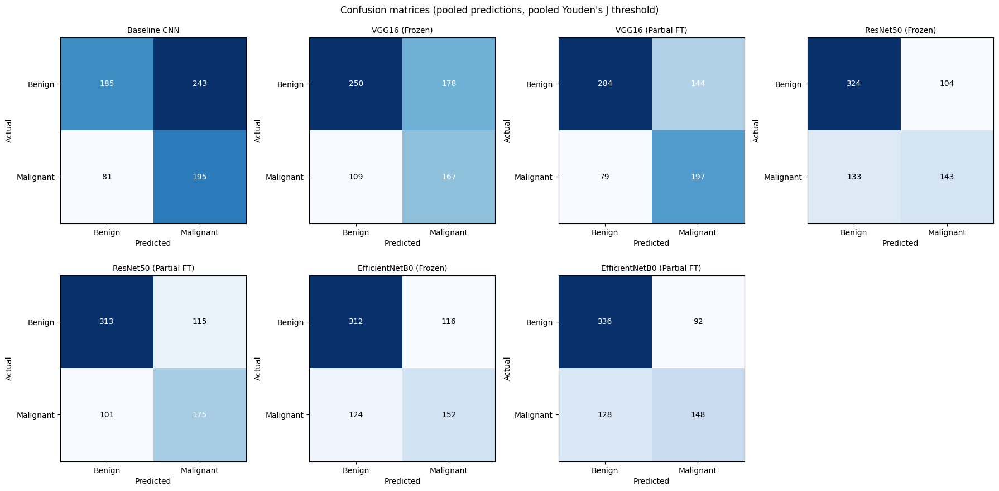

In [ ]:
# =============================================================================
# SECTION 6.6.1: Confusion Matrices
# =============================================================================
# One confusion matrix per config, using pooled (seed-averaged) predictions
# at each config's own pooled Youden's J threshold. Read-only against
# Section 6.2's output, nothing here touches the test set again.
#
# Requires: Section 6.2 (POOLED), Section 4.5 (CONFIGS).
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 4, figsize=(18, 9))  # 8 subplot slots for 7 configs
axes = axes.flatten()
for ax, (config_name, cfg) in zip(axes, CONFIGS.items()):
    p = POOLED[config_name]
    cm = confusion_matrix(p["y_true"], p["y_pred"])  # 2x2: rows are actual, columns are predicted
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            # Print each cell's count on top of its square, white text on
            # the darker (high-count) squares so it stays readable.
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Benign", "Malignant"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Benign", "Malignant"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(cfg["display"], fontsize=10)
axes[-1].axis("off")  # 7 configs, 8 subplot slots, hide the unused one
fig.suptitle("Confusion matrices (pooled predictions, pooled Youden's J threshold)")
fig.tight_layout()
plt.show()

**Confusion matrices (pooled predictions, pooled threshold; 428 benign, 276 malignant)**

| Model | TN | FP | FN | TP | Specificity | Sensitivity |
|---|---|---|---|---|---|---|
| Baseline CNN | 185 | 243 | 81 | 195 | 0.432 | 0.707 |
| VGG16 (Frozen) | 250 | 178 | 109 | 167 | 0.584 | 0.605 |
| VGG16 (Partial FT) | 284 | 144 | 79 | 197 | 0.664 | 0.714 |
| ResNet50 (Frozen) | 324 | 104 | 133 | 143 | 0.757 | 0.518 |
| ResNet50 (Partial FT) | 313 | 115 | 101 | 175 | 0.731 | 0.634 |
| EfficientNetB0 (Frozen) | 312 | 116 | 124 | 152 | 0.729 | 0.551 |
| EfficientNetB0 (Partial FT) | 336 | 92 | 128 | 148 | 0.785 | 0.536 |

- The models operate at different trade-offs. VGG16 (Partial FT) is the most **sensitive** transfer model (197 of 276 malignant lesions detected), EfficientNetB0 (Partial FT) the most **specific** (336 of 428 benign lesions cleared), and ResNet50 (Partial FT) sits between them.
- The baseline reaches its sensitivity only by calling more than half of the benign lesions malignant (243 false positives).

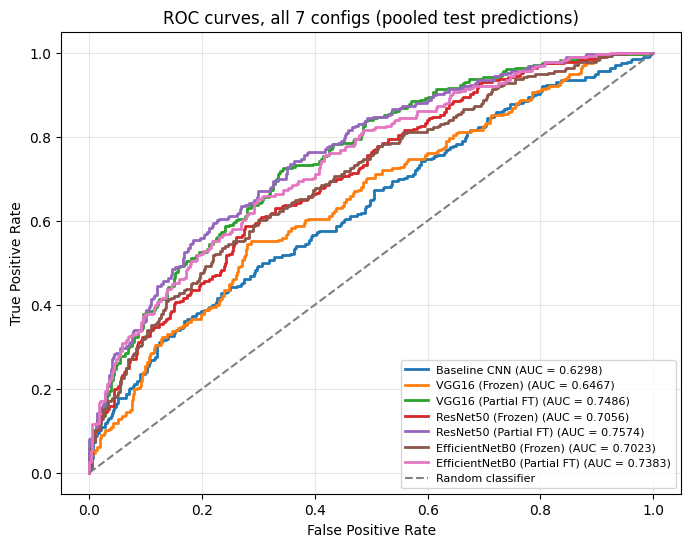

In [ ]:
# =============================================================================
# SECTION 6.6.2: ROC Curves
# =============================================================================
# ROC curve overlay, all 7 configs, pooled probabilities. Threshold-free,
# so this is a separate view from 6.6.1's confusion matrices, not derived
# from them.
#
# Requires: Section 6.2 (POOLED), Section 4.5 (CONFIGS).

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))
for config_name, cfg in CONFIGS.items():
    p = POOLED[config_name]
    # fpr/tpr trace the curve itself; the third return value (thresholds)
    # isn't needed here since this plot doesn't mark a specific operating point.
    fpr, tpr, _ = roc_curve(p["y_true"], p["y_prob"])
    auc = roc_auc_score(p["y_true"], p["y_prob"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{cfg['display']} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random classifier")
plt.title("ROC curves, all 7 configs (pooled test predictions)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.show()

**ROC curves (pooled predictions).** The three partially fine-tuned models form the upper group of curves across most of the false-positive range, the ResNet50 and EfficientNetB0 frozen models sit just below, and VGG16 (Frozen) and the baseline stay closest to the diagonal. The legend AUCs are the pooled values (for example 0.757 for ResNet50 (Partial FT)), which match the bootstrap table in Section 6.5.

In [ ]:
# =============================================================================
# SECTION 6.6.3: Error Analysis
# =============================================================================
# Two things, both chosen for what actually matters in a cancer-detection
# study, not just "how many did each model get wrong":
#
#   1. Error RATES, not raw counts. A false negative here is a missed
#      malignant case, the clinically costly error, so this reports
#      "% of malignant test cases missed" per config (equivalent to
#      1 - sensitivity, just framed as an error statement) alongside the
#      benign-side false positive rate.
#
#   2. Cross-model overlap: for each test image, how many of the 7 configs
#      got it wrong. Images every config misses are either genuinely hard
#      cases or possibly mislabeled/ambiguous, worth discussing as a
#      limitation, and they're natural candidates for Section 7's Grad-CAM
#      (visualize the cases nothing gets right). Images only one config
#      misses say more about that specific model than about the data.
#
# A mass-vs-calcification breakdown of these errors is deliberately left
# to Section 8, which already does that in depth for the per-architecture
# winners, so it isn't duplicated here.
#
# Requires: Section 6.2 (POOLED), Section 4.5 (CONFIGS),
# Section 2 (test_df).


import numpy as np
import pandas as pd

HARD_CASE_MIN_CONFIGS = 4  # out of 7: "most configs got this one wrong"

# -----------------------------------------------------------------------
# Check that POOLED's label order matches test_df, so the per-image
# lookups below (patient_id, abnormality type) point at the right rows.
# -----------------------------------------------------------------------
assert np.array_equal(POOLED["baseline_cnn"]["y_true"], test_df["label"].values), (
    "POOLED test predictions aren't in the same order as test_df. The lookups below "
    "(patient_id, abnormality type per hard case) would point at the wrong rows, so "
    "stopping here rather than printing misleading case IDs."
)

# -----------------------------------------------------------------------
# Part 1: error rates per config.
# -----------------------------------------------------------------------
rate_rows = []
for config_name, cfg in CONFIGS.items():
    p = POOLED[config_name]
    is_malignant = p["y_true"] == 1
    is_benign = p["y_true"] == 0
    n_malignant, n_benign = int(is_malignant.sum()), int(is_benign.sum())

    fn = int(np.sum(is_malignant & (p["y_pred"] == 0)))  # malignant, predicted benign
    fp = int(np.sum(is_benign & (p["y_pred"] == 1)))      # benign, predicted malignant

    rate_rows.append({
        "Model": cfg["display"],
        "N Malignant": n_malignant, "False Negatives": fn,
        "FN Rate (% malignant missed)": round(100 * fn / n_malignant, 1) if n_malignant else float("nan"),
        "N Benign": n_benign, "False Positives": fp,
        "FP Rate (% benign over-called)": round(100 * fp / n_benign, 1) if n_benign else float("nan"),
        "Overall Error Rate (%)": round(100 * (fn + fp) / len(p["y_true"]), 1),
    })
error_rates_df = pd.DataFrame(rate_rows)
print("Error rates (pooled predictions, pooled threshold):")
display(error_rates_df)

# -----------------------------------------------------------------------
# Part 2: cross-model overlap. For each test image, count how many of the
# 7 configs got it wrong, split by direction (missed malignant vs.
# over-called benign), since those are different failure modes.
# -----------------------------------------------------------------------
y_true = POOLED["baseline_cnn"]["y_true"]  # identical across configs, already asserted above
is_malignant = y_true == 1
is_benign = y_true == 0

# One row per config, one column per test image: True where that config
# got that image wrong, in that image's specific direction (FN or FP).
fn_matrix = np.array([(POOLED[c]["y_true"] == 1) & (POOLED[c]["y_pred"] == 0) for c in CONFIGS])
fp_matrix = np.array([(POOLED[c]["y_true"] == 0) & (POOLED[c]["y_pred"] == 1) for c in CONFIGS])

n_configs_missed = fn_matrix.sum(axis=0)      # per image: how many configs missed it (0 for benign images)
n_configs_overcalled = fp_matrix.sum(axis=0)  # per image: how many configs over-called it (0 for malignant images)

n_configs_total = len(CONFIGS)


def _overlap_histogram(counts, mask, label):
    """counts: per-image count of configs that got it wrong, ALREADY zero
    outside the relevant class. mask picks out just that class's images,
    so the histogram only covers images where this error direction is
    even possible."""
    vals = counts[mask]
    rows = [{"N configs wrong": k, "N images": int(np.sum(vals == k))} for k in range(n_configs_total + 1)]
    hist_df = pd.DataFrame(rows)
    print(f"\n{label}: how many of the {n_configs_total} configs missed each test image "
          f"(0 = every config got it right):")
    display(hist_df)
    return hist_df


malignant_overlap_df = _overlap_histogram(n_configs_missed, is_malignant, "Malignant cases (false negatives)")
benign_overlap_df = _overlap_histogram(n_configs_overcalled, is_benign, "Benign cases (false positives)")

# -----------------------------------------------------------------------
# Part 3: name the actual hard cases, for Section 7 Grad-CAM candidates
# and for discussion in the write-up.
# -----------------------------------------------------------------------
lookup_cols = [c for c in ["patient_id", "abnormality type", "image_path"] if c in test_df.columns]


def _hard_case_table(counts, mask, min_configs, count_label):
    idx = np.where(mask & (counts >= min_configs))[0]
    if len(idx) == 0:
        return pd.DataFrame(columns=lookup_cols + [count_label])
    rows = test_df.iloc[idx][lookup_cols].copy()
    rows[count_label] = counts[idx]
    return rows.sort_values(count_label, ascending=False).reset_index(drop=True)


hard_malignant_df = _hard_case_table(n_configs_missed, is_malignant, HARD_CASE_MIN_CONFIGS, "N configs missed")
hard_benign_df = _hard_case_table(n_configs_overcalled, is_benign, HARD_CASE_MIN_CONFIGS, "N configs over-called")

print(f"\nMalignant cases missed by at least {HARD_CASE_MIN_CONFIGS}/{n_configs_total} configs "
      f"(candidates for Section 7 Grad-CAM, and worth a mention as hard/ambiguous cases):")
display(hard_malignant_df)

print(f"\nBenign cases over-called by at least {HARD_CASE_MIN_CONFIGS}/{n_configs_total} configs:")
display(hard_benign_df)


Error rates (pooled predictions, pooled threshold):


,Model,N Malignant,False Negatives,FN Rate (% malignant missed),N Benign,False Positives,FP Rate (% benign over-called),Overall Error Rate (%)
0,Baseline CNN,276,81,29.3,428,243,56.8,46.0
1,VGG16 (Frozen),276,109,39.5,428,178,41.6,40.8
2,VGG16 (Partial FT),276,79,28.6,428,144,33.6,31.7
3,ResNet50 (Frozen),276,133,48.2,428,104,24.3,33.7
4,ResNet50 (Partial FT),276,101,36.6,428,115,26.9,30.7
5,EfficientNetB0 (Frozen),276,124,44.9,428,116,27.1,34.1
6,EfficientNetB0 (Partial FT),276,128,46.4,428,92,21.5,31.2



Malignant cases (false negatives): how many of the 7 configs missed each test image (0 = every config got it right):


,N configs wrong,N images
0,0,71
1,1,40
2,2,37
3,3,26
4,4,25
5,5,21
6,6,34
7,7,22



Benign cases (false positives): how many of the 7 configs missed each test image (0 = every config got it right):


,N configs wrong,N images
0,0,104
1,1,95
2,2,76
3,3,40
4,4,30
5,5,25
6,6,26
7,7,32



Malignant cases missed by at least 4/7 configs (candidates for Section 7 Grad-CAM, and worth a mention as hard/ambiguous cases):


,patient_id,abnormality type,image_path,N configs missed
0,P_00198,mass,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,7
1,P_01140,mass,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,7
2,P_01323,mass,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,7
3,P_01140,mass,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,7
4,P_00591,mass,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,7
...,...,...,...,...
97,P_01803,calcification,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,4
98,P_01883,calcification,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,4
99,P_01842,calcification,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,4
100,P_02198,calcification,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,4



Benign cases over-called by at least 4/7 configs:


,patient_id,abnormality type,image_path,N configs over-called
0,P_00358,mass,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,7
1,P_00369,mass,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,7
2,P_00379,mass,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,7
3,P_00358,mass,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,7
4,P_00662,mass,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,7
...,...,...,...,...
108,P_01353,calcification,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,4
109,P_01308,calcification,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,4
110,P_01460,calcification,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,4
111,P_01752,calcification,/content/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2...,4


### Error Analysis

**(a) Error rates (pooled threshold)**

| Model | Malignant missed (FN rate) | Benign over-called (FP rate) | Overall error |
|---|---|---|---|
| Baseline CNN | 81 / 276 (29.3%) | 243 / 428 (56.8%) | 46.0% |
| VGG16 (Frozen) | 109 (39.5%) | 178 (41.6%) | 40.8% |
| VGG16 (Partial FT) | **79 (28.6%)** | 144 (33.6%) | 31.7% |
| ResNet50 (Frozen) | 133 (48.2%) | 104 (24.3%) | 33.7% |
| ResNet50 (Partial FT) | 101 (36.6%) | 115 (26.9%) | **30.7%** |
| EfficientNetB0 (Frozen) | 124 (44.9%) | 116 (27.1%) | 34.1% |
| EfficientNetB0 (Partial FT) | 128 (46.4%) | **92 (21.5%)** | 31.2% |

- A missed malignancy is the clinically costly error. VGG16 (Partial FT) misses the fewest malignant lesions of any transfer model (28.6%), while ResNet50 (Partial FT) has the lowest overall error rate (30.7%).
- The three partially fine-tuned models have almost the same overall error (30.7–31.7%) but distribute it differently between the two error types. The appropriate choice therefore depends on whether sensitivity or specificity is prioritised.

**(b) How many of the 7 configurations get each image wrong**

| Configurations wrong | Malignant images (FN) | Benign images (FP) |
|---|---|---|
| 0 (all correct) | 71 (25.7%) | 104 (24.3%) |
| 1–3 | 103 (37.3%) | 211 (49.3%) |
| 4–6 | 80 (29.0%) | 81 (18.9%) |
| 7 (all wrong) | 22 (8.0%) | 32 (7.5%) |

- 102 malignant and 113 benign images are misclassified by at least 4 of the 7 configurations. Errors that most models share point to difficult or ambiguous images rather than to a weakness of one model, and they include both masses and calcifications.
- 54 images (22 malignant, 32 benign) are misclassified by every configuration. These are candidates for visual inspection and are discussed as a limitation of image-only classification.
- The mass-versus-calcification breakdown of errors is left to Section 8.

In [ ]:
# =============================================================================
# SECTION 6.6.4: Calibration Check
# =============================================================================
# Compares predicted P(malignant) with the observed malignant rate in
# 10 equal-width probability bins (expected calibration error, ECE).
#
# Requires: Section 6.2 (POOLED), Section 4.5 (CONFIGS).

import numpy as np
import pandas as pd


def _confidence_and_correctness(y_true, y_prob, threshold):
    pred_label = (y_prob >= threshold).astype(int)
    # "Confidence" here means how sure the model was in whichever class it
    # actually predicted: if it predicted malignant, that's y_prob itself;
    # if it predicted benign, that's 1 - y_prob (its confidence in "benign").
    confidence = np.where(pred_label == 1, y_prob, 1 - y_prob)
    correct = (pred_label == y_true).astype(int)
    return confidence, correct


def _expected_calibration_error(confidence, correct, n_bins=10, bin_range=(0.5, 1.0)):
    # Split the [0.5, 1.0] confidence range into 10 equal-width bins, then
    # figure out which bin each prediction's confidence falls into.
    edges = np.linspace(*bin_range, n_bins + 1)
    bin_ids = np.clip(np.digitize(confidence, edges[1:-1]), 0, n_bins - 1)
    n_total = len(confidence)
    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        # For each bin: how far apart is the average stated confidence
        # from the actual accuracy in that bin, weighted by how many
        # predictions fall in it, then summed across all bins.
        ece += (mask.sum() / n_total) * abs(confidence[mask].mean() - correct[mask].mean())
    return ece

def _ece_probability(y_true, y_prob, n_bins=10):
    """Standard binary ECE: mean predicted P(malignant) vs observed malignant rate, 10 bins over [0, 1]."""
    edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)
    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.any():
            ece += mask.mean() * abs(y_prob[mask].mean() - y_true[mask].mean())
    return ece


calibration_rows = []
for config_name, cfg in CONFIGS.items():
    p = POOLED[config_name]
    # confidence, correct = _confidence_and_correctness(p["y_true"], p["y_prob"], p["threshold"])
    # ece = _expected_calibration_error(confidence, correct)
    # calibration_rows.append({"Model": cfg["display"], "Expected Calibration Error": round(ece, 4)})
    calibration_rows.append({"Model": cfg["display"],"ECE (P(malignant))": round(_ece_probability(p["y_true"], p["y_prob"]), 4)})
calibration_df = pd.DataFrame(calibration_rows).sort_values("ECE (P(malignant))")
# print("Calibration check: lower ECE = stated confidence more closely matches observed accuracy:")
print("Calibration check: lower ECE = predicted P(malignant) more closely matches the observed malignant rate:")
display(calibration_df)

Calibration check: lower ECE = predicted P(malignant) more closely matches the observed malignant rate:


,Model,ECE (P(malignant))
2,VGG16 (Partial FT),0.0869
5,EfficientNetB0 (Frozen),0.1040
1,VGG16 (Frozen),0.1413
6,EfficientNetB0 (Partial FT),0.1549
3,ResNet50 (Frozen),0.1585
4,ResNet50 (Partial FT),0.2137
0,Baseline CNN,0.2585


### Calibration (Expected Calibration Error)

ECE here measures whether the predicted probability of malignancy matches the observed malignant rate. Predictions are grouped into 10 equal-width probability bins over [0, 1], and ECE is the sample-weighted average gap between mean predicted P(malignant) and the actual malignant proportion in each bin (0 = perfectly calibrated).

| Model | ECE |
|---|---|
| VGG16 (Partial FT) | **0.087** |
| EfficientNetB0 (Frozen) | 0.104 |
| VGG16 (Frozen) | 0.141 |
| EfficientNetB0 (Partial FT) | 0.155 |
| ResNet50 (Frozen) | 0.159 |
| ResNet50 (Partial FT) | 0.214 |
| Baseline CNN | 0.259 |

- No model is well calibrated: even the best is off by about 9 percentage points on average, so raw outputs should not be read as the probability that a lesion is malignant.
- Calibration does not follow discrimination. ResNet50 (Partial FT) has the best AUC but the second-worst ECE, while VGG16 (Partial FT) is best calibrated.
- The miscalibration is consistent with the thresholds chosen in Section 5.3: a model whose Youden threshold is far from 0.5 (0.108 for the baseline, about 0.70 for ResNet50 (Partial FT)) produces probabilities that are systematically shifted. The thresholds already correct the **decision**, but not the stated probability, which is why calibrators are fitted below for the prototype.

In [ ]:
# =============================================================================
# Fit and Save Confidence Calibrators (for the prototype)
# =============================================================================
# Fits an isotonic calibrator for each config's seed-1 checkpoint
# (WINNING_TRIAL[config]["checkpoint"], the file the prototype loads),
# using validation-set predictions only.
#
# Requires: Section 5.1 (WINNING_TRIAL),
# Section 4.5 (CONFIGS, FEATURE_CACHE_DIR).


import os
import pickle
import numpy as np
import tensorflow as tf
from sklearn.isotonic import IsotonicRegression

# Prototype app uses shorter display names than CONFIGS' own "display" field.
PROTOTYPE_MODEL_NAMES = {
    "baseline_cnn": "Baseline CNN",
    "vgg16_frozen": "VGG16 Frozen",
    "vgg16_partial": "VGG16 Partial",
    "resnet50_frozen": "ResNet50 Frozen",
    "resnet50_partial": "ResNet50 Partial",
    "effnet_frozen": "EfficientNetB0 Frozen",
    "effnet_partial": "EfficientNetB0 Partial",
}


def _get_winning_val_predictions(config_name):
    """Validation-set raw probabilities for THIS config's winning checkpoint
    (the exact file the prototype loads) -- never the test set.

    Loads frozen-config val features straight from the Section 4.5.3 disk
    cache rather than relying on FROZEN_FEATURE_CACHE still being in
    memory, so this cell works standalone even after a kernel restart,
    same pattern Section 6.2's pooling cell uses.
    """
    cfg = CONFIGS[config_name]
    checkpoint_path = WINNING_TRIAL[config_name]["checkpoint"]
    model = tf.keras.models.load_model(checkpoint_path)

    if cfg["kind"] == "frozen":
        cache_path = os.path.join(FEATURE_CACHE_DIR, f"{config_name}_train_val.npz")
        assert os.path.exists(cache_path), (
            f"Feature cache not found for '{config_name}': {cache_path}. "
            f"Section 4.5.3 must have run at least once for this config."
        )
        data = np.load(cache_path)
        val_feats, val_labels = data["val_feats"], data["val_labels"]
        y_prob = model.predict(val_feats, verbose=0).ravel()
        y_true = val_labels
    else:
        y_prob_chunks, y_true_chunks = [], []
        for batch_images, batch_labels in cfg["val_ds"]:
            y_prob_chunks.append(model.predict(batch_images, verbose=0).ravel())
            y_true_chunks.append(batch_labels.numpy())
        y_prob = np.concatenate(y_prob_chunks)
        y_true = np.concatenate(y_true_chunks)

    del model
    tf.keras.backend.clear_session()
    return y_prob, y_true


calibrators = {}
for config_name, cfg in CONFIGS.items():
    y_prob, y_true = _get_winning_val_predictions(config_name)

    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(y_prob, y_true)

    calibrators[PROTOTYPE_MODEL_NAMES[config_name]] = iso
    print(f"  fitted calibrator for {cfg['display']} ({len(y_prob)} validation examples)")

# Saved to Drive, not the relative "calibrators.pkl" path used by the old
# notebook -- a relative path here would land in Colab's local /content/
# runtime disk instead, which is wiped on disconnect. DRIVE_DIR already
# exists in memory from Section 4.5.1.
calibrators_path = os.path.join(DRIVE_DIR, "calibrators.pkl")
with open(calibrators_path, "wb") as f:
    pickle.dump(calibrators, f)

print("\nSaved calibrators.pkl for:", list(calibrators.keys()))
print(f"Location (Google Drive): {calibrators_path}")


  fitted calibrator for Baseline CNN (508 validation examples)
  fitted calibrator for VGG16 (Frozen) (508 validation examples)
  fitted calibrator for VGG16 (Partial FT) (508 validation examples)
  fitted calibrator for ResNet50 (Frozen) (508 validation examples)
  fitted calibrator for ResNet50 (Partial FT) (508 validation examples)
  fitted calibrator for EfficientNetB0 (Frozen) (508 validation examples)
  fitted calibrator for EfficientNetB0 (Partial FT) (508 validation examples)

Saved calibrators.pkl for: ['Baseline CNN', 'VGG16 Frozen', 'VGG16 Partial', 'ResNet50 Frozen', 'ResNet50 Partial', 'EfficientNetB0 Frozen', 'EfficientNetB0 Partial']
Location (Google Drive): /content/drive/MyDrive/random_search_full/calibrators.pkl



**Isotonic calibrators for the prototype.** For each configuration, an `IsotonicRegression` is fitted that maps the model's raw validation probabilities (508 images) to the observed outcomes. Isotonic regression learns a monotonic step function, so it corrects the probability scale without changing the ranking of predictions (ROC-AUC is unaffected).

| Setting | Value |
|---|---|
| Data | Validation set only, never the test set |
| Model calibrated | Each configuration's winning search checkpoint (seed 1), the file the prototype loads |
| Out-of-range inputs | Clipped to the fitted range |
| Output | `calibrators.pkl` on Drive, keyed by the prototype's model names |

**Result:** Calibrators are fitted and saved for all seven configurations.

In [ ]:
# =============================================================================
# Standalone export: POOLED + sampled test images, for prototype verification
# =============================================================================
# Unlike export_pooled_for_verification.py, this does NOT need POOLED,
# CONFIGS, or any models already in memory. It rebuilds everything itself
# from what's already saved on Drive: Section 5.4's per-seed .npz prediction
# files, and this notebook's DRIVE_DIR.
#
# The ONE thing it still needs in memory is test_df (with an "image_path"
# and a "label" column) -- that's built early on by Sections 1-2 (metadata
# loading, patient-disjoint split, image path generation), NOT by any
# training section, so it's fast to rebuild after a fresh kernel: rerun
# Sections 1 through 2.6, nothing after that, then run this cell.
#
# Why it needs test_df at all: Section 5.4's saved .npz files only ever
# stored y_prob/y_true/threshold, never image paths -- there was nothing
# else to read them back from.

import os
import glob
import pickle
import numpy as np
import pandas as pd

# --- REMINDER: adjust only if setup differs/changes ---
DRIVE_DIR = "/content/drive/MyDrive/random_search_full"
IMAGE_PATH_COLUMN = "image_path"
LABEL_COLUMN = "label"
N_CHECK = 50
RANDOM_SEED = 0

assert os.path.ismount("/content/drive"), (
    "Google Drive is not mounted -- run "
    "`from google.colab import drive; drive.mount('/content/drive')` first."
)
assert "test_df" in globals(), (
    "test_df is not in memory -- rerun Sections 1 through 2.6 (data loading, "
    "split, image path generation) first. Nothing after 2.6 is needed."
)

FINAL_PREDICTIONS_DIR = os.path.join(DRIVE_DIR, "final_predictions")

# config_name -> the prototype's own short model name (utils/model_loader.py,
# utils/calibration.py, utils/thresholds.py all key on these exact strings).
PROTOTYPE_MODEL_NAMES = {
    "baseline_cnn": "Baseline CNN",
    "vgg16_frozen": "VGG16 Frozen",
    "vgg16_partial": "VGG16 Partial",
    "resnet50_frozen": "ResNet50 Frozen",
    "resnet50_partial": "ResNet50 Partial",
    "effnet_frozen": "EfficientNetB0 Frozen",
    "effnet_partial": "EfficientNetB0 Partial",
}

# --- rebuild POOLED from disk, same averaging logic as Section 6.2 ---
POOLED = {}
for config_name in PROTOTYPE_MODEL_NAMES:
    pattern = os.path.join(FINAL_PREDICTIONS_DIR, f"{config_name}__final_seed*_test_predictions.npz")
    seed_files = sorted(glob.glob(pattern))
    if not seed_files:
        print(f"skipping {config_name}: no prediction files found under {FINAL_PREDICTIONS_DIR}")
        continue

    y_true_ref = None
    seed_probs, seed_thresholds = [], []
    for path in seed_files:
        data = np.load(path)
        if y_true_ref is None:
            y_true_ref = data["y_true"]
        seed_probs.append(data["y_prob"])
        seed_thresholds.append(float(data["threshold"]))

    pooled_prob = np.mean(seed_probs, axis=0)
    pooled_threshold = float(np.mean(seed_thresholds))  # same averaging as Section 6.2
    POOLED[config_name] = {"y_true": y_true_ref, "y_prob": pooled_prob, "threshold": pooled_threshold}
    print(f"{config_name}: pooled {len(seed_files)} seed file(s), {len(y_true_ref)} test images, "
          f"threshold={pooled_threshold:.4f}")

# --- sample N_CHECK rows once, reused across every config (same test_df) ---
rng = np.random.default_rng(RANDOM_SEED)
sample_indices = rng.choice(len(test_df), size=min(N_CHECK, len(test_df)), replace=False)

pooled_export = {}
for config_name, pooled in POOLED.items():
    prototype_name = PROTOTYPE_MODEL_NAMES[config_name]

    test_labels = test_df[LABEL_COLUMN].to_numpy()
    assert len(test_labels) == len(pooled["y_true"]), (
        f"{config_name}: test_df has {len(test_labels)} rows but the pooled "
        f"predictions have {len(pooled['y_true'])} -- test_df in memory right "
        f"now is not the same test set these predictions were built from."
    )
    assert np.array_equal(test_labels, pooled["y_true"]), (
        f"{config_name}: test_df's labels don't match the saved y_true in "
        f"order -- don't trust image-path-to-prediction alignment until "
        f"this is fixed."
    )

    sample_paths = [test_df[IMAGE_PATH_COLUMN].iloc[i] for i in sample_indices]
    pooled_export[prototype_name] = {
        "image_paths": sample_paths,  # reference/debugging only
        "image_bytes": [open(p, "rb").read() for p in sample_paths],
        "y_true": [int(pooled["y_true"][i]) for i in sample_indices],
        "y_prob": [float(pooled["y_prob"][i]) for i in sample_indices],
        "y_pred": [int(pooled["y_prob"][i] >= pooled["threshold"]) for i in sample_indices],
    }

export_path = os.path.join(DRIVE_DIR, "pooled_export.pkl")
with open(export_path, "wb") as f:
    pickle.dump(pooled_export, f)

print(f"\nExported {len(pooled_export)} model(s) to {export_path}: {list(pooled_export.keys())}")
print(f"{len(sample_indices)} embedded test images each (self-contained, no local paths needed).")
print("Download completed . Download file from Drive and copy it into FYP_Prototype/ as pooled_export.pkl.")

baseline_cnn: pooled 3 seed file(s), 704 test images, threshold=0.1081
vgg16_frozen: pooled 3 seed file(s), 704 test images, threshold=0.4595
vgg16_partial: pooled 3 seed file(s), 704 test images, threshold=0.4815
resnet50_frozen: pooled 3 seed file(s), 704 test images, threshold=0.6696
resnet50_partial: pooled 3 seed file(s), 704 test images, threshold=0.6982
effnet_frozen: pooled 3 seed file(s), 704 test images, threshold=0.3993
effnet_partial: pooled 3 seed file(s), 704 test images, threshold=0.6806

Exported 7 model(s) to /content/drive/MyDrive/random_search_full/pooled_export.pkl: ['Baseline CNN', 'VGG16 Frozen', 'VGG16 Partial', 'ResNet50 Frozen', 'ResNet50 Partial', 'EfficientNetB0 Frozen', 'EfficientNetB0 Partial']
50 embedded test images each (self-contained, no local paths needed).
Download this file from Drive and copy it into FYP_Prototype/ as pooled_export.pkl.


# 7. Grad-CAM Interpretability Analysis
## 7.1 Grad-CAM Setup
Grad-CAM uses all three seed models of each configuration (Section 7.2b), consistent with the seed-averaged predictions used throughout the study.

In [ ]:
# =============================================================================
# SECTION 7.1: Grad-CAM Setup
# =============================================================================
# Grad-CAM runs on the 4 "selected models" used across RQ2a/Objective 5:
# baseline CNN + Section 6.4's ARCHITECTURE_WINNERS (one winner per TL
# architecture), not a separate selection made here.
#
# A frozen config's checkpoint is head-only (trained on pooled feature
# vectors, no conv layers), so it can't be loaded directly for Grad-CAM.
# This rebuilds it as a full image-in model: fresh frozen ImageNet backbone
# (spatial output this time) + the trained head's own layers reused on top
# of GlobalAveragePooling2D, giving the same predictions as the
# frozen feature pipeline.
#
# Uses Sequential so the backbone stays a nested model, which
# find_last_conv_layer relies on for ResNet50 and EfficientNetB0.
#
# Requires: Section 6.4 (ARCHITECTURE_WINNERS), Section 4.5 (CONFIGS,
# SEARCH_LOG_PATH), Section 2 (test_df).
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D

# The 4 selected models: baseline plus one winner per TL architecture.
gradcam_config_names = ["baseline_cnn"] + list(ARCHITECTURE_WINNERS.values())


def _winning_checkpoint_path(config_name):
    """Highest val_auc search trial for this config, from SEARCH_LOG_PATH
    (same selection logic as Section 6.4/6.6.4)."""
    best_row, best_auc = None, -1.0
    with open(SEARCH_LOG_PATH) as f:
        for line in f:
            entry = json.loads(line)
            if entry["status"] == "ok" and entry["config_name"] == config_name:
                if entry["val_metrics"]["auc"] > best_auc:
                    best_auc, best_row = entry["val_metrics"]["auc"], entry
    assert best_row is not None, f"No completed search trials found for '{config_name}'."
    return best_row["checkpoint"]


def _load_gradcam_model(config_name):
    """Full image-to-prediction model for one config. "full" configs load
    directly. "frozen" configs get rebuilt: fresh backbone + pooling +
    the trained head's layers reused as-is."""
    cfg = CONFIGS[config_name]
    ckpt_path = _winning_checkpoint_path(config_name)

    if cfg["kind"] != "frozen":
        return tf.keras.models.load_model(ckpt_path)

    base = cfg["base_class"](weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base.trainable = False

    # Saved checkpoint is just the trained head (Input(feature_dim) ->
    # Dense128 -> BN -> Dropout -> Dense1). Drop its Input layer, reuse the rest.
    trained_head = tf.keras.models.load_model(ckpt_path)
    reused_head_layers = [
        layer for layer in trained_head.layers
        if not isinstance(layer, tf.keras.layers.InputLayer)
    ]

    model = tf.keras.Sequential([base, GlobalAveragePooling2D(), *reused_head_layers])
    model.build((None, 224, 224, 3))
    return model


# Keyed by DISPLAY name (e.g. "VGG16 (Frozen)"), matching how 7.2/7.5/7.6/7.7
# look up models and thresholds.
gradcam_models = {
    CONFIGS[config_name]["display"]: _load_gradcam_model(config_name)
    for config_name in gradcam_config_names
}

print("Models selected for Grad-CAM (baseline + one winner per architecture):")
for config_name in gradcam_config_names:
    print(f"- {CONFIGS[config_name]['display']}")

# Each model's own pooled CBIS-DDSM threshold, used for "predicted
# malignant vs benign" in Grad-CAM's class_score instead of a fresh 0.5 cutoff.
gradcam_thresholds = {
    CONFIGS[config_name]["display"]: POOLED[config_name]["threshold"]
    for config_name in gradcam_config_names
}


# -----------------------------------------------------------------------
# Identify the final convolutional layer for each selected model.
# -----------------------------------------------------------------------
def find_last_conv_layer(model):
    """ResNet50 -> conv5_block3_out (its final block's output, not the
    literal last Conv2D, which is followed by BN+ReLU in the same block).
    EfficientNetB0 -> top_conv (its actual final conv layer). Everything
    else (VGG16, baseline CNN) -> last Conv2D found searching backwards."""
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.Model):
            if "resnet" in layer.name.lower():
                for nested_layer in layer.layers:
                    if nested_layer.name == "conv5_block3_out":
                        return nested_layer
            elif "efficientnet" in layer.name.lower():
                for nested_layer in layer.layers:
                    if nested_layer.name == "top_conv":
                        return nested_layer
            for nested_layer in reversed(layer.layers):
                if isinstance(nested_layer, Conv2D):
                    return nested_layer
        if isinstance(layer, Conv2D):
            return layer
    raise ValueError(f"No suitable Grad-CAM target layer found in model: {model.name}")


gradcam_target_layers = {
    model_name: find_last_conv_layer(model)
    for model_name, model in gradcam_models.items()
}

print("\nGrad-CAM target layers:")
for model_name, layer in gradcam_target_layers.items():
    print(f"  {model_name}: {layer.name}")


# -----------------------------------------------------------------------
# Compatibility aliases so Sections 7.5/7.6/7.7 don't need their own copies.
# -----------------------------------------------------------------------
test_image_paths = test_df["image_path"].values
y_true = test_df["label"].values

# Same alignment check Section 6.6.3 relies on, repeated since Section 7
# can run standalone after a kernel restart.
assert np.array_equal(POOLED["baseline_cnn"]["y_true"], y_true), (
    "POOLED test predictions aren't in the same order as test_df. Grad-CAM "
    "case selection (7.3) would point at the wrong images if this doesn't hold."
)

Models selected for Grad-CAM (baseline + one winner per architecture):
- Baseline CNN
- VGG16 (Partial FT)
- ResNet50 (Partial FT)
- EfficientNetB0 (Partial FT)

Grad-CAM target layers:
  Baseline CNN: conv2d_2
  VGG16 (Partial FT): block5_conv3
  ResNet50 (Partial FT): conv5_block3_out
  EfficientNetB0 (Partial FT): top_conv


**Grad-CAM models and target layers.** Grad-CAM is applied to the four selected models: the baseline and the per-architecture winners from Section 6.4.

| Model | Target layer | Feature map | Upsampling to 224 px | Pooled threshold |
|---|---|---|---|---|
| Baseline CNN | `conv2d_2` (third convolution) | 56 × 56 × 128 | 4× | 0.108 |
| VGG16 (Partial FT) | `block5_conv3` | 14 × 14 × 512 | 16× | 0.482 |
| ResNet50 (Partial FT) | `conv5_block3_out` | 7 × 7 × 2,048 | 32× | 0.698 |
| EfficientNetB0 (Partial FT) | `top_conv` | 7 × 7 × 1,280 | 32× | 0.681 |

- The last convolutional feature map is used because it combines high-level features with spatial layout and is closest to the classification decision.
- For ResNet50, the output of the final residual block (after the skip connection) is used rather than the last raw convolution, because that is the tensor actually passed to the classifier head.
- The native heatmap resolution differs by a factor of 8 between the baseline and the 7 × 7 models. ResNet50 and EfficientNetB0 maps are therefore inherently coarse, while baseline maps can show fine, texture-like detail.
- Frozen configurations are saved as head-only models, so the loader rebuilds them with a fresh ImageNet backbone. None of the selected models is frozen, but the loader supports both.
- An assertion confirms that `test_df` and the pooled predictions are in the same order before any case is selected.

##  7.2 Grad-CAM Generation Function

In [ ]:
# =============================================================================
# 7.2 Grad-CAM Generation
# =============================================================================
# Computes a Grad-CAM heatmap for one image and one model.
# - The predicted class is decided with the model's pooled threshold.
# - Gradients are taken of the logit (pre-sigmoid) rather than the
#   probability, because the sigmoid's gradient vanishes when the model
#   is confident.
# - apply_relu=True gives standard Grad-CAM (positive evidence only).
#   apply_relu=False returns the raw map, min-max scaled to [0, 1];
#   used by the weight-randomisation checks in 7.8 and 7.8b.

import tensorflow as tf


def _logit_layer(final_dense):
    """final_dense's own weights on a plain Dense(1, activation=None), i.e.
    the same layer minus its fused sigmoid. A proper Keras layer, not a raw
    tf.matmul, since a bare tf.matmul on a symbolic KerasTensor errors out
    while building a functional-API graph."""
    # Explicit unique name: auto-naming can collide with an existing layer name.
    layer = tf.keras.layers.Dense(1, activation=None, name=f"{final_dense.name}_logit")
    layer.build((None, final_dense.kernel.shape[0]))
    layer.set_weights(final_dense.get_weights())
    return layer


def generate_gradcam(model, image, target_layer, model_name, threshold=0.5,
                     target_class=None, apply_relu=True):
    # Always Dense(1, activation="sigmoid"), see make_head
    final_dense = model.layers[-1]
    logit_layer = _logit_layer(final_dense)

    if model_name == "Baseline CNN":
      # Flat Sequential model: rebuild it layer by layer and capture the
        # target conv layer's output on the way through
        gradcam_input = tf.keras.Input(shape=(224, 224, 3))
        x = gradcam_input
        target_activation = None
        for layer in model.layers[:-1]:  # everything up to, not including, the final Dense
            x = layer(x, training=False)  # inference mode: BatchNorm/Dropout behave as at test time
            if layer.name == target_layer.name:
                target_activation = x  # feature maps Grad-CAM will weight
        if target_activation is None:
            raise ValueError(f"Target layer '{target_layer.name}' was not found in the Baseline CNN.")
        # Pre-activation output of the final Dense layer, bypassing its fused sigmoid.
        logit = logit_layer(x)
        # One model returning both the feature maps and the logit, so both are on the same gradient tape
        grad_model = tf.keras.Model(inputs=gradcam_input, outputs=[target_activation, logit])
    else:
      # Transfer models: the pretrained backbone is a nested model inside the Sequential,
        # so find the sub-model that contains the target layer
        nested_model = None
        for layer in model.layers:
            if isinstance(layer, tf.keras.Model):
                nested_layer_names = [nested_layer.name for nested_layer in layer.layers]
                if target_layer.name in nested_layer_names:
                    nested_model = layer
                    break
        if nested_model is None:
            raise ValueError(f"Could not find the pretrained model containing '{target_layer.name}'.")
        # Backbone variant that outputs the target layer's feature maps as well as its normal output
        nested_grad_model = tf.keras.Model(
            inputs=nested_model.input, outputs=[target_layer.output, nested_model.output]
        )
        gradcam_input = tf.keras.Input(shape=(224, 224, 3))
        conv_outputs, x = nested_grad_model(gradcam_input, training=False)
        # Re-apply the classification head (pooling, Dense, BN, Dropout) on the backbone output
        for layer in model.layers[:-1]:  # everything except the backbone and the final Dense
            if layer is nested_model:
                continue
            x = layer(x, training=False)
        logit = logit_layer(x)
        grad_model = tf.keras.Model(inputs=gradcam_input, outputs=[conv_outputs, logit])

    with tf.GradientTape() as tape:# records operations so gradients can be taken
        conv_outputs, logit = grad_model(image, training=False)
        logit = logit[:, 0]
        prediction_probability = tf.sigmoid(logit)  # for reporting/thresholding, not differentiated
        predicted_class = tf.cast(prediction_probability >= threshold, tf.int32)
        # Evidence for the predicted class, in logit space: +logit if
        # predicted malignant, -logit if predicted benign
        # target_class, if given, overrides this
        if target_class is None:
            class_score = tf.where(predicted_class == 1, logit, -logit)
        else:
            class_score = logit if target_class == 1 else -logit

    gradients = tape.gradient(class_score, conv_outputs)
    pooled_gradients = tf.reduce_mean(gradients, axis=(1, 2))
    conv_outputs = conv_outputs[0]
    pooled_gradients = pooled_gradients[0]
    weighted_activations = conv_outputs * pooled_gradients
    heatmap = tf.reduce_sum(weighted_activations, axis=-1)

    if apply_relu:
        # Standard Grad-CAM: keep positive evidence only, scale to [0, 1].
        # If nothing is positive the map stays all zero (a "blank" heatmap).
        heatmap = tf.maximum(heatmap, 0)
        max_value = tf.reduce_max(heatmap)
        heatmap = tf.where(max_value > 0, heatmap / max_value, heatmap)
    else:
        # Raw map (no ReLU), min-max scaled to [0, 1]. Used only by the 7.8
        # sanity check. A truly constant map is returned as all zeros.
        h_min = tf.reduce_min(heatmap)
        h_max = tf.reduce_max(heatmap)
        heatmap = tf.where(h_max > h_min, (heatmap - h_min) / (h_max - h_min), tf.zeros_like(heatmap))

    heatmap = heatmap.numpy()
    prediction_probability = float(prediction_probability[0].numpy())
    predicted_class = int(predicted_class[0].numpy())
    return heatmap, prediction_probability, predicted_class

**Grad-CAM computation.** For one image and one model, the function:

1. Builds a gradient model returning the target-layer activations and the **logit** (the final layer's output before the sigmoid).
2. Chooses the class to explain: the predicted class at the model's pooled threshold, or a fixed `target_class` when several models must explain the same class.
3. Differentiates the class score (+logit for malignant, −logit for benign) with respect to the activations and averages the gradients spatially, giving one importance weight per channel.
4. Takes the weighted sum of the channels.
5. Standard mode (`apply_relu=True`): keeps only positive evidence and scales to [0, 1]. If no location has positive evidence, the map is blank (all zeros).
   Raw mode (`apply_relu=False`, used only in Sections 7.8–7.8b): keeps negative values and min–max scales the map, so it is never blank.

**Why the logit?** The sigmoid flattens out near 0 and 1, so its gradient becomes very small exactly when the model is confident. Differentiating the logit avoids this and gives usable gradients for confident predictions.

**Reading the maps:** for a benign prediction the heatmap shows evidence for *benign*, which need not coincide with the lesion.

### 7.2b Seed-Averaged Grad-CAM

Every other result in this study uses the average of three seed models, so Grad-CAM does too. The seed-averaged prediction and pooled threshold decide which class is explained; each seed then produces a heatmap for that class, and the three heatmaps are averaged and rescaled to [0, 1]. This keeps the heatmap, the displayed probability and the case selection (7.3) all based on the same ensemble.

In [ ]:
# =============================================================================
# 7.2b Seed-averaged Grad-CAM
# =============================================================================
def _load_checkpoint_for_gradcam(config_name, ckpt_path):
    """Same as _load_gradcam_model, for a given checkpoint path."""
    cfg = CONFIGS[config_name]
    if cfg["kind"] != "frozen":
        return tf.keras.models.load_model(ckpt_path)
    base = cfg["base_class"](weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    head = tf.keras.models.load_model(ckpt_path)
    head_layers = [l for l in head.layers if not isinstance(l, tf.keras.layers.InputLayer)]
    model = tf.keras.Sequential([base, GlobalAveragePooling2D(), *head_layers])
    model.build((None, 224, 224, 3))
    return model


def _other_seed_checkpoints(config_name):
    paths = []
    with open(FINAL_TRAINING_LOG_PATH) as f:
        for line in f:
            e = json.loads(line)
            if e["status"] == "ok" and e["config_name"] == config_name:
                paths.append(e["checkpoint"])
    return paths


# display name -> list of (model, target_layer), seed 1 first
gradcam_seed_models = {}
for config_name in gradcam_config_names:
    display_name = CONFIGS[config_name]["display"]
    seeds = [(gradcam_models[display_name], gradcam_target_layers[display_name])]
    for ckpt in _other_seed_checkpoints(config_name):
        m = _load_checkpoint_for_gradcam(config_name, ckpt)
        seeds.append((m, find_last_conv_layer(m)))
    gradcam_seed_models[display_name] = seeds
    print(f"{display_name}: {len(seeds)} seed models loaded")


def ensemble_gradcam(model_name, processed_image):
    """Seed-averaged probability, pooled-threshold class, seed-averaged heatmap."""
    image = tf.convert_to_tensor(processed_image)
    seeds = gradcam_seed_models[model_name] # list of (model, target_layer), one per seed

    # Ensemble prediction: mean P(malignant) across the three seed models
    probability = float(np.mean([float(m(image, training=False)[0, 0]) for m, _ in seeds]))
    # Class decided at the model's pooled threshold, as in the main evaluation
    predicted_class = int(probability >= gradcam_thresholds[model_name])

    # One heatmap per seed, all explaining the SAME (ensemble-predicted) class
    heatmaps = [
        generate_gradcam(m, image, layer, model_name, target_class=predicted_class)[0] # [0] = heatmap only
        for m, layer in seeds
    ]
    # Average the seed heatmaps, then rescale to [0, 1] (skipped if all maps are blank)
    heatmap = np.mean(heatmaps, axis=0)
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()
    return heatmap, probability, predicted_class

Baseline CNN: 3 seed models loaded
VGG16 (Partial FT): 3 seed models loaded
ResNet50 (Partial FT): 3 seed models loaded
EfficientNetB0 (Partial FT): 3 seed models loaded


**Seed-averaged Grad-CAM.** To stay consistent with the pooled predictions used everywhere else, each explanation is built from all three seed models:

1. The three seeds' probabilities are averaged, and the pooled threshold decides the predicted class.
2. Each seed produces a Grad-CAM map for **that same class**.
3. The three maps are averaged and rescaled to [0, 1].

**Result:** Three seed models are loaded for each of the four selected configurations (12 models in total).

## 7.3 Representative Grad-CAM Case Selection

In [ ]:
# =============================================================================
# SECTION 7.3: Representative Grad-CAM Case Selection
# =============================================================================
# Picks one benign + one malignant test case for each scenario:
#   Agree + Correct / Disagreement / Agree + Wrong
# Uses Section 6.2's POOLED predictions at each model's pooled threshold.
#
# Requires: Section 7.1 (gradcam_models, gradcam_config_names), Section 6.2
# (POOLED), Section 2 (test_df).

import numpy as np

# Display names, same order as gradcam_config_names.
gradcam_model_names = list(gradcam_models.keys())

# Each model's pooled binary prediction, keyed by display name.
gradcam_predictions = {
    display_name: POOLED[config_name]["y_pred"]
    for config_name, display_name in zip(gradcam_config_names, gradcam_model_names)
}

# Rows = test images, columns = models (in gradcam_model_names order).
prediction_matrix = np.column_stack([gradcam_predictions[name] for name in gradcam_model_names])

# True where a model's prediction matches the true label.
correct_matrix = (prediction_matrix == y_true.reshape(-1, 1))

# Per image: how many models got it right.
number_correct = correct_matrix.sum(axis=1)

n_selected = len(gradcam_model_names)

agree_correct_indices = np.where(number_correct == n_selected)[0]  # all correct
disagreement_indices = np.where(prediction_matrix.max(axis=1) != prediction_matrix.min(axis=1))[0]  # not unanimous
agree_wrong_indices = np.where(number_correct == 0)[0]  # all wrong


def select_cases_by_class(indices):
    """First benign and first malignant case in indices, or None if absent."""
    benign_cases = [i for i in indices if y_true[i] == 0]
    malignant_cases = [i for i in indices if y_true[i] == 1]
    return {
        "Benign": benign_cases[0] if benign_cases else None,
        "Malignant": malignant_cases[0] if malignant_cases else None,
    }


selected_gradcam_cases = {
    "Agree + Correct": select_cases_by_class(agree_correct_indices),
    "Disagreement": select_cases_by_class(disagreement_indices),
    "Agree + Wrong": select_cases_by_class(agree_wrong_indices),
}

# Print the selected cases and each model's prediction on them.
for scenario, class_cases in selected_gradcam_cases.items():
    print(f"\n{scenario}:")
    for image_class, index in class_cases.items():
        if index is None:
            print(f"  {image_class}: No suitable case found")
            continue
        prediction_str = ", ".join(
            f"{name}={prediction_matrix[index, col]}"
            for col, name in enumerate(gradcam_model_names)
        )
        print(f"  {image_class} | Test index: {index} | "
              f"True label: {'Malignant' if y_true[index] == 1 else 'Benign'} | "
              f"Predictions: {prediction_str}")



Agree + Correct:
  Benign | Test index: 11 | True label: Benign | Predictions: Baseline CNN=0, VGG16 (Partial FT)=0, ResNet50 (Partial FT)=0, EfficientNetB0 (Partial FT)=0
  Malignant | Test index: 0 | True label: Malignant | Predictions: Baseline CNN=1, VGG16 (Partial FT)=1, ResNet50 (Partial FT)=1, EfficientNetB0 (Partial FT)=1

Disagreement:
  Benign | Test index: 4 | True label: Benign | Predictions: Baseline CNN=1, VGG16 (Partial FT)=1, ResNet50 (Partial FT)=1, EfficientNetB0 (Partial FT)=0
  Malignant | Test index: 2 | True label: Malignant | Predictions: Baseline CNN=0, VGG16 (Partial FT)=0, ResNet50 (Partial FT)=1, EfficientNetB0 (Partial FT)=0

Agree + Wrong:
  Benign | Test index: 5 | True label: Benign | Predictions: Baseline CNN=1, VGG16 (Partial FT)=1, ResNet50 (Partial FT)=1, EfficientNetB0 (Partial FT)=1
  Malignant | Test index: 3 | True label: Malignant | Predictions: Baseline CNN=0, VGG16 (Partial FT)=0, ResNet50 (Partial FT)=0, EfficientNetB0 (Partial FT)=0


**Representative cases.** Pooled predictions of the four selected models are compared on every test image, and for each scenario the first benign and first malignant case (by test index) are selected. Taking the first case keeps the selection reproducible rather than hand-picked.

| Scenario | Case | Baseline | VGG16 | ResNet50 | EfficientNetB0 |
|---|---|---|---|---|---|
| Agree + Correct | Benign, index 11 | ✓ | ✓ | ✓ | ✓ |
| Agree + Correct | Malignant, index 0 | ✓ | ✓ | ✓ | ✓ |
| Disagreement | Benign, index 4 | ✗ | ✗ | ✗ | ✓ |
| Disagreement | Malignant, index 2 | ✗ | ✗ | ✓ | ✗ |
| Agree + Wrong | Benign, index 5 | ✗ | ✗ | ✗ | ✗ |
| Agree + Wrong | Malignant, index 3 | ✗ | ✗ | ✗ | ✗ |

(✓ = correct, ✗ = wrong.) Unlike the earlier 0.5-threshold version, every scenario now has both a benign and a malignant case, because the pooled thresholds make the baseline call malignant far more often.

##  7.4 Grad-CAM Image Preparation

In [ ]:
# =============================================================================
# SECTION 7.4: Grad-CAM Image Preparation
# =============================================================================
# Returns the raw image (for display) and the model-ready tensor for
# the given model: resize, CLAHE (as in training), then the model's
# own preprocessing.
#
# Requires: apply_clahe (CLAHE helper before Section 3.2.2).
import numpy as np
import tensorflow as tf
from PIL import Image
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input


def prepare_gradcam_image(image_path, model_name):
    """Returns (raw_image_array, preprocessed_tensor) for one image."""

    # Load as RGB, resize to model input size.
    image = Image.open(image_path).convert("RGB").resize((224, 224))
    image_array = np.array(image).astype("float32")

    # Same CLAHE step as Sections 4.1-4.4, applied before any architecture
    # preprocessing (reuses the notebook's own apply_clahe function).
    clahe_image = apply_clahe(tf.convert_to_tensor(image_array)).numpy()

    if model_name == "Baseline CNN":
        # Baseline rescales internally (see build_baseline_cnn), pass through raw (CLAHE'd) pixels.
        processed_image = clahe_image

    elif model_name in ("VGG16 (Frozen)", "VGG16 (Partial FT)"):
        processed_image = vgg16_preprocess_input(clahe_image.copy())

    elif model_name in ("ResNet50 (Frozen)", "ResNet50 (Partial FT)"):
        processed_image = resnet50_preprocess_input(clahe_image.copy())

    elif model_name in ("EfficientNetB0 (Frozen)", "EfficientNetB0 (Partial FT)"):
        processed_image = efficientnet_preprocess_input(clahe_image.copy())

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    # Add batch dimension.
    processed_image = np.expand_dims(processed_image, axis=0)

    return image_array, processed_image

**Grad-CAM image preparation.** Each image is loaded, resized to 224 × 224, contrast-enhanced with the same `apply_clahe` function used in training, and then normalised for the specific model:

| Model | Normalisation after CLAHE |
|---|---|
| Baseline CNN | None (rescales inside the model) |
| VGG16 | `vgg16.preprocess_input` |
| ResNet50 | `resnet50.preprocess_input` |
| EfficientNetB0 | `efficientnet.preprocess_input` (pass-through) |

Applying CLAHE here matters: without it, Grad-CAM would explain images the models never saw in training. The preprocessing functions are imported under distinct names, so they cannot overwrite each other.

## 7.5 Grad-CAM Visualisation

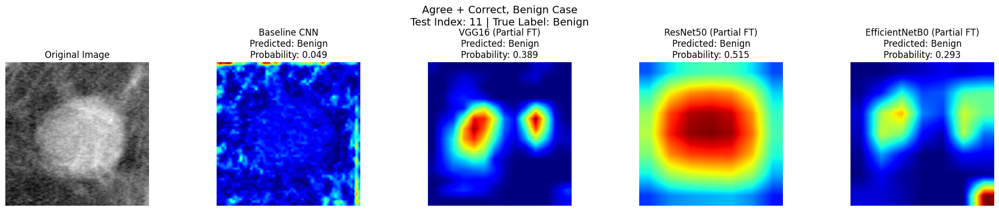

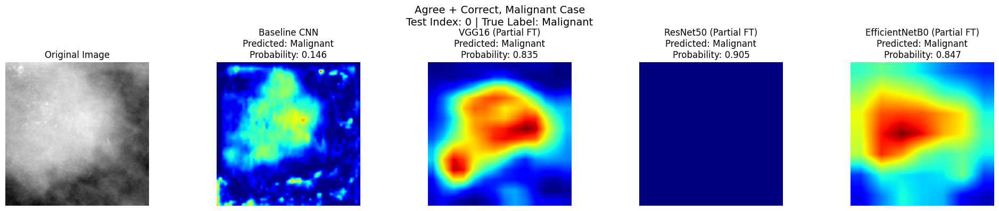

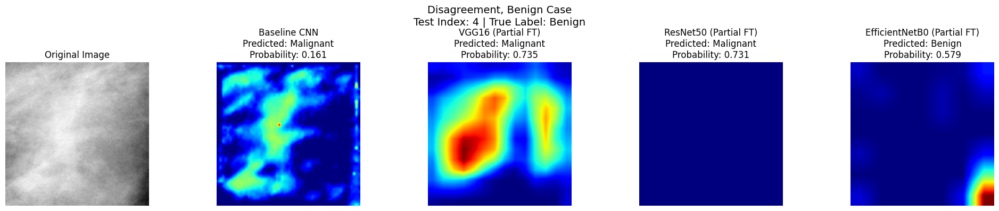

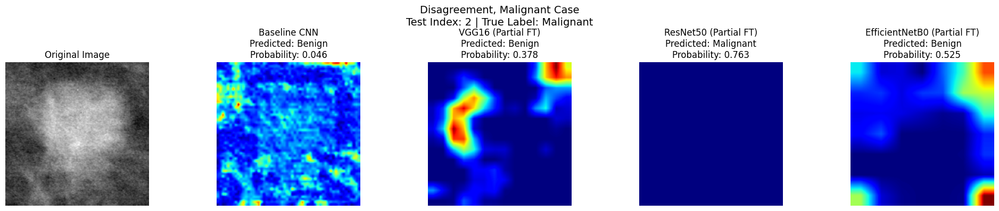

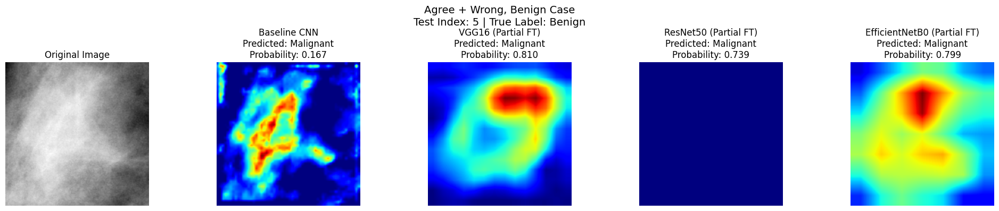

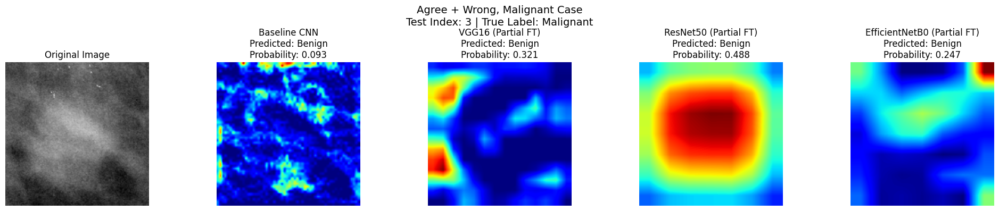

In [ ]:
# =============================================================================
# SECTION 7.5: Grad-CAM Visualisation
# =============================================================================
# Generates and plots Grad-CAM heatmaps for the cases selected in 7.3, one
# figure per case, one panel per selected model plus the original image.
#
# Requires: Section 7.1 (gradcam_models, gradcam_target_layers,
# gradcam_thresholds), Section 7.3 (selected_gradcam_cases), Section 7.4
# (prepare_gradcam_image), Section 7.2 (generate_gradcam).
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image


def resize_gradcam_heatmap(heatmap, target_size=(224, 224)):
    """Upscales the small conv-resolution heatmap to 224x224 for display."""
    heatmap_tensor = tf.convert_to_tensor(heatmap[..., np.newaxis], dtype=tf.float32)
    resized_heatmap = tf.image.resize(heatmap_tensor, target_size)
    resized_heatmap = resized_heatmap[..., 0]
    return resized_heatmap.numpy()


n_panels = len(gradcam_models) + 1  # original image + one heatmap per model

for scenario, class_cases in selected_gradcam_cases.items():
    for image_class, image_index in class_cases.items():

        if image_index is None:  # no case found for this scenario/class
            continue

        # Load original image once, shown in panel 0.
        image_path = test_image_paths[image_index]
        original_image = Image.open(image_path).convert("RGB").resize((224, 224))
        original_image_array = np.array(original_image)

        fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4))

        axes[0].imshow(original_image_array)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        # One Grad-CAM heatmap per selected model, panels 1..n_panels-1.
        for column, model_name in enumerate(gradcam_models.keys(), start=1):

            _, processed_image = prepare_gradcam_image(image_path, model_name)

            heatmap, probability, predicted_class = ensemble_gradcam(model_name, processed_image)

            heatmap = resize_gradcam_heatmap(heatmap, target_size=(224, 224))

            axes[column].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
            axes[column].set_title(
                f"{model_name}\n"
                f"Predicted: {'Malignant' if predicted_class == 1 else 'Benign'}\n"
                f"Probability: {probability:.3f}"
            )
            axes[column].axis("off")

        true_label = "Malignant" if y_true[image_index] == 1 else "Benign"
        fig.suptitle(
            f"{scenario}, {image_class} Case\n"
            f"Test Index: {image_index} | True Label: {true_label}",
            fontsize=14,
        )
        plt.tight_layout()
        plt.show()

**Grad-CAM visualisations.** One figure per representative case: the original crop followed by the seed-averaged heatmap of each selected model, with its predicted class and pooled probability. Heatmaps are upsampled with bilinear interpolation to 224 × 224 and shown on a common 0–1 colour scale (red = strongest evidence for the predicted class).

## 7.6 Grad-CAM and ROI Comparison

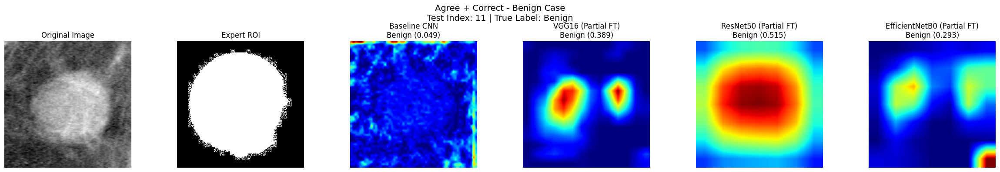

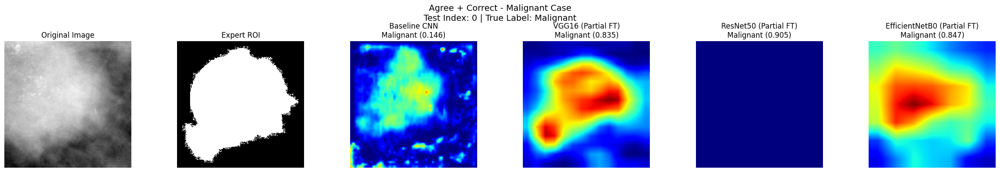

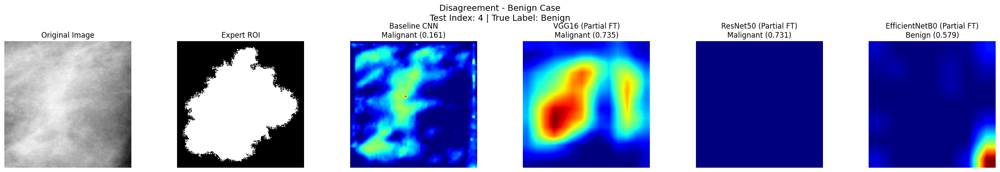

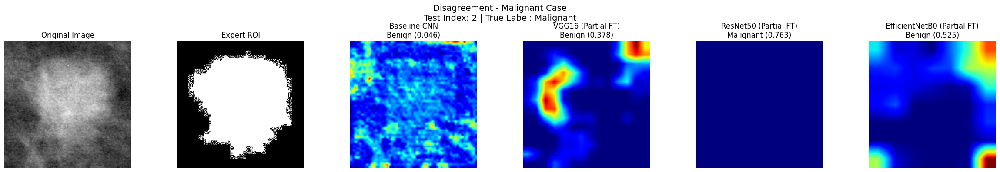

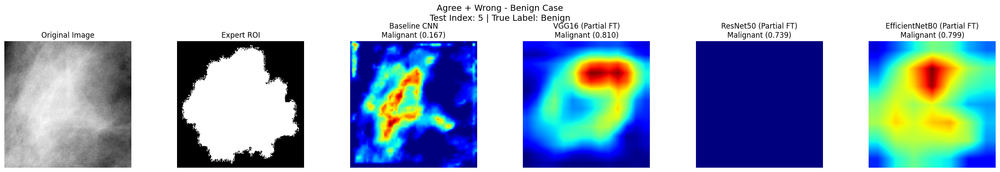

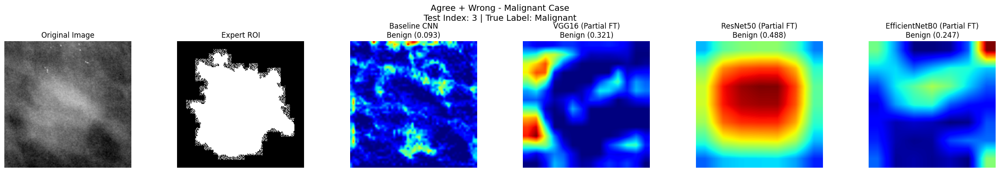

In [ ]:
# =============================================================================
# 7.6 Grad-CAM and ROI Comparison
# =============================================================================
# Qualitative comparison of Grad-CAM activation regions against the expert
# ROI. The ROI mask is stored at original image resolution, so its bounding
# box is reconstructed within the lesion crop's own dimensions before
# resizing to 224x224.
#
# Requires: Section 7.1 (gradcam_models, gradcam_target_layers,
# gradcam_thresholds), Section 7.3 (selected_gradcam_cases), Section 7.4
# (prepare_gradcam_image), Section 7.2 (generate_gradcam).


# -------------------------------------------------------------------------
# Helper function to locate the ROI mask
# -------------------------------------------------------------------------

def get_roi_mask_path(image_path):
    folder_path = os.path.dirname(image_path)

    jpg_files = [
        file_name for file_name in os.listdir(folder_path)
        if file_name.lower().endswith(".jpg")
    ]

    if len(jpg_files) != 2:
        raise ValueError(f"Expected two JPEG files in {folder_path}, but found {len(jpg_files)}.")

    image_sizes = []
    for file_name in jpg_files:
        file_path = os.path.join(folder_path, file_name)
        with Image.open(file_path) as image:
            width, height = image.size
        image_sizes.append((width * height, file_name))

    # The larger JPEG is the ROI mask.
    roi_file = max(image_sizes, key=lambda item: item[0])[1]
    return os.path.join(folder_path, roi_file)


# -------------------------------------------------------------------------
# Helper function to reconstruct ROI in crop coordinates
# -------------------------------------------------------------------------

def prepare_aligned_roi(roi_path, crop_size, target_size=(224, 224)):
    """Approximate the ROI mask in the coordinate system of the lesion crop.
    The non-black ROI bounding box is placed centrally within a canvas whose
    dimensions match the corresponding cropped lesion JPEG."""
    crop_width, crop_height = crop_size

    roi_image = Image.open(roi_path).convert("L")
    roi_array = np.array(roi_image)

    non_black = (roi_array > 0)
    if not np.any(non_black):
        raise ValueError(f"No ROI pixels found in: {roi_path}")

    rows, columns = np.where(non_black)
    y_min, y_max = rows.min(), rows.max() + 1
    x_min, x_max = columns.min(), columns.max() + 1

    roi_bbox = (roi_array[y_min:y_max, x_min:x_max] > 0).astype(np.float32)
    roi_height, roi_width = roi_bbox.shape

    if roi_width > crop_width or roi_height > crop_height:
        raise ValueError("ROI bounding box is larger than the corresponding lesion crop.")

    # Centre the ROI bounding box inside a canvas matching the lesion crop.
    aligned_roi = np.zeros((crop_height, crop_width), dtype=np.float32)
    x_offset = (crop_width - roi_width) // 2
    y_offset = (crop_height - roi_height) // 2
    aligned_roi[y_offset:y_offset + roi_height, x_offset:x_offset + roi_width] = roi_bbox

    # Resize using nearest-neighbour interpolation so it stays a binary mask.
    aligned_roi = tf.image.resize(aligned_roi[..., np.newaxis], target_size, method="nearest")
    aligned_roi = aligned_roi[..., 0].numpy()

    return aligned_roi


# -------------------------------------------------------------------------
# Generate Grad-CAM and ROI comparison
# -------------------------------------------------------------------------

for scenario, class_cases in selected_gradcam_cases.items():
    for image_class, image_index in class_cases.items():

        if image_index is None:
            continue

        image_path = test_image_paths[image_index]
        roi_path = get_roi_mask_path(image_path)

        original_image = Image.open(image_path).convert("RGB")
        crop_size = original_image.size
        original_image = original_image.resize((224, 224))
        original_image_array = np.array(original_image)

        roi_binary = prepare_aligned_roi(roi_path, crop_size=crop_size, target_size=(224, 224))

        fig, axes = plt.subplots(1, 2 + len(gradcam_models), figsize=(4 * (2 + len(gradcam_models)), 4))

        axes[0].imshow(original_image_array)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        axes[1].imshow(roi_binary, cmap="gray", vmin=0, vmax=1)
        axes[1].set_title("Expert ROI")
        axes[1].axis("off")

        for column, model_name in enumerate(gradcam_models.keys(), start=2):
            _, processed_image = prepare_gradcam_image(image_path, model_name)

            heatmap, probability, predicted_class = ensemble_gradcam(model_name, processed_image)

            heatmap = resize_gradcam_heatmap(heatmap, target_size=(224, 224))

            axes[column].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
            axes[column].set_title(
                f"{model_name}\n"
                f"{'Malignant' if predicted_class == 1 else 'Benign'} "
                f"({probability:.3f})"
            )
            axes[column].axis("off")

        true_label = "Malignant" if y_true[image_index] == 1 else "Benign"
        fig.suptitle(
            f"{scenario} - {image_class} Case\n"
            f"Test Index: {image_index} | True Label: {true_label}",
            fontsize=14,
        )
        plt.tight_layout()
        plt.show()

### Grad-CAM Compared with the Expert ROI

**ROI alignment.** The ROI mask is stored at full-mammogram resolution, while the models see only the lesion crop. The mask is reduced to the bounding box of its annotated region, placed at the **centre** of a canvas with the crop's dimensions, and resized to 224 × 224 with nearest-neighbour interpolation to keep it binary. This relies on CBIS-DDSM crops being generated around the lesion; it is an approximation, not pixel-accurate registration (checked visually in 7.6.1).

**Qualitative observations**

| Model | Observed pattern |
|---|---|
| Baseline CNN | Fine-grained, texture-like activation spread across the whole crop, often including the image border. No consistent focus on the lesion. |
| VGG16 (Partial FT) | One or two compact hot spots. On the correctly classified malignant case (index 0) the activation lies within the lesion; on other cases its position is more variable, sometimes at the lesion edge or outside it. |
| ResNet50 (Partial FT) | Benign predictions give a broad, smooth blob over the centre of the crop. **Every malignant prediction gives a completely blank map** (indices 0, 4, 2 and 5). |
| EfficientNetB0 (Partial FT) | Broad central activation on the correctly classified malignant case (index 0); on benign predictions the activation often moves to the crop corners. |

- The ROI covers a large part of every crop, so a broad central heatmap will overlap it whether or not the model is using lesion-specific features.
- The blank ResNet50 maps mean that, with standard (ReLU) Grad-CAM, no location in the final feature map contributes positive evidence for its malignant decisions, even though the prediction itself is confident (for example 0.905 on index 0). This is examined in 7.7b and 7.8.

### 7.6.1 ROI Alignment Check

 Overlays the reconstructed ROI on its crop for 15 random test cases, to confirm that the centred-box reconstruction used in 7.6–7.7 places the mask on the lesion.

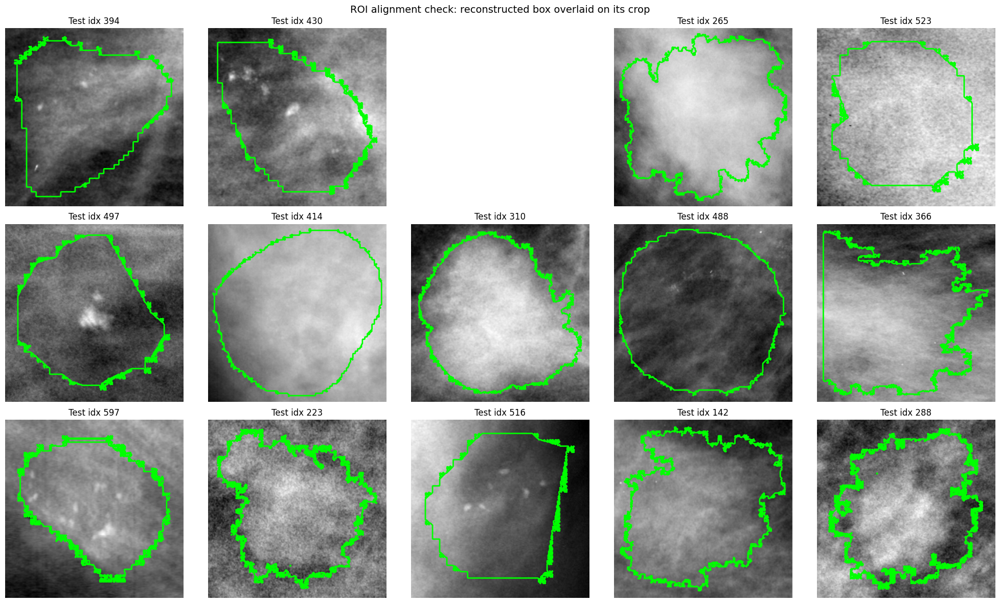

In [ ]:
# =============================================================================
# 7.6.1 ROI Alignment Sanity Check
# =============================================================================
# Everything in 7.6/7.7 (IoU, pointing game) depends on prepare_aligned_roi
# reconstructing the ROI box in the right place within the crop. This
# overlays the reconstructed box on the crop itself, for a random sample,
# so misalignment is visible directly rather than assumed correct.
#
# Requires: Section 7.6 (get_roi_mask_path, prepare_aligned_roi).

import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

N_CHECK = 15
random.seed(0)
check_indices = random.sample(range(len(test_image_paths)), min(N_CHECK, len(test_image_paths)))

fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for ax, image_index in zip(axes.flat, check_indices):
    image_path = test_image_paths[image_index]

    try:
        roi_path = get_roi_mask_path(image_path)
    except ValueError:
        ax.axis("off")
        continue

    original_image = Image.open(image_path).convert("RGB")
    crop_size = original_image.size
    crop_resized = np.array(original_image.resize((224, 224)))
    roi_binary = prepare_aligned_roi(roi_path, crop_size=crop_size, target_size=(224, 224))

    ax.imshow(crop_resized)
    ax.contour(roi_binary, levels=[0.5], colors="lime", linewidths=2)
    ax.set_title(f"Test idx {image_index}")
    ax.axis("off")

# Any unused grid cells (fewer than 15 valid crops found).
for ax in axes.flat[len(check_indices):]:
    ax.axis("off")

plt.suptitle("ROI alignment check: reconstructed box overlaid on its crop", fontsize=14)
plt.tight_layout()
plt.show()

**Result:** For the 14 of 15 randomly sampled test images that have a crop–mask pair (one panel is empty because its folder has no mask), the reconstructed ROI outline follows the visible lesion or calcification cluster closely. The centred-box reconstruction is therefore a reasonable approximation for this dataset. The overlays also show that the annotated region typically fills most of the crop.

## 7.7 Grad-CAM vs ROI: Quantitative Overlap Across a Larger Sample

#### Quantitative localisation metrics

The six hand-picked cases cannot support general claims, so localisation is measured on a larger sample: 25 malignant and 25 benign test images drawn at random (seed 42), with the same seed-averaged heatmaps.

| Metric | Definition | Reference value |
|---|---|---|
| IoU | Heatmap thresholded at 0.5, compared with the ROI: area of overlap / area of union | **All-ones reference:** IoU obtained by marking the whole image, which equals the ROI's share of the image |
| Pointing game | Does the heatmap's single brightest pixel fall inside the ROI? | **Chance:** ROI's share of the image. **Centre point:** does the image centre fall inside the ROI? |

The reference rows show what a model with no localisation ability would score, which is essential when the ROI covers a large share of the image.

In [ ]:
# =============================================================================
# 7.7 Grad-CAM vs ROI: Quantitative Overlap Across a Larger Sample
# =============================================================================
# Two scores per model, from the same heatmaps, across a larger sample than
# Section 7.6's 6 hand-picked cases: IoU (thresholded heatmap vs. ROI mask)
# and pointing game (does the heatmap's peak pixel fall inside the ROI).
# "All-Ones Reference / Chance" is the ROI's area fraction, used as the
# baseline for both: marking the whole image as attended for IoU, and the
# hit rate a random peak location would get for pointing game.
#
# Requires: Section 7.1 (gradcam_models, gradcam_thresholds), Section 7.2b
# (ensemble_gradcam), Section 7.6 (get_roi_mask_path, prepare_aligned_roi),
# Section 7.4 (prepare_gradcam_image).

import random

random.seed(42)

N_PER_CLASS = 25

malignant_indices = [i for i in range(len(y_true)) if y_true[i] == 1]
benign_indices = [i for i in range(len(y_true)) if y_true[i] == 0]

# Equal benign/malignant sample so neither class dominates the average.
sampled_indices = (
    random.sample(malignant_indices, min(N_PER_CLASS, len(malignant_indices)))
    + random.sample(benign_indices, min(N_PER_CLASS, len(benign_indices)))
)


def compute_iou(heatmap, roi_binary, threshold=0.5):
    heatmap_binary = (heatmap >= threshold).astype(np.float32)
    intersection = np.logical_and(heatmap_binary, roi_binary).sum()
    union = np.logical_or(heatmap_binary, roi_binary).sum()
    if union == 0:  # heatmap and ROI both empty
        return 0.0
    return intersection / union


def pointing_game_hit(heatmap, roi_binary):
    """True if the heatmap's single brightest pixel falls inside the ROI."""
    peak_row, peak_col = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    return bool(roi_binary[peak_row, peak_col])


iou_scores = {model_name: [] for model_name in gradcam_models.keys()}
pointing_hits = {model_name: [] for model_name in gradcam_models.keys()}
all_ones_scores = []  # one entry per image, no model involved
centre_hits = []
skipped = 0

for image_index in sampled_indices:
    image_path = test_image_paths[image_index]

    try:
        roi_path = get_roi_mask_path(image_path)
        original_image = Image.open(image_path).convert("RGB")
        crop_size = original_image.size
        roi_binary = prepare_aligned_roi(roi_path, crop_size=crop_size, target_size=(224, 224))
    except ValueError:  # ROI mask pair missing for this image
        skipped += 1
        continue

    all_ones_scores.append(roi_binary.sum() / roi_binary.size)
    centre_hits.append(bool(roi_binary[112, 112]))

    for model_name in gradcam_models.keys():
        _, processed_image = prepare_gradcam_image(image_path, model_name)

        heatmap, probability, predicted_class = ensemble_gradcam(model_name, processed_image)
        heatmap = resize_gradcam_heatmap(heatmap, target_size=(224, 224))

        iou_scores[model_name].append(compute_iou(heatmap, roi_binary))
        pointing_hits[model_name].append(pointing_game_hit(heatmap, roi_binary))

print(f"Evaluated {len(sampled_indices) - skipped} images "
      f"({skipped} skipped due to missing ROI files).")

# -------------------------------------------------------------------------
# Per-model summary, plus the all-ones/chance reference row.
# -------------------------------------------------------------------------

iou_summary = []
for model_name in gradcam_models.keys():
    iou = np.array(iou_scores[model_name])
    hits = np.array(pointing_hits[model_name])
    iou_summary.append({
        "Model": model_name,
        "N": len(iou),
        "Mean IoU": round(iou.mean(), 4),
        "Std IoU": round(iou.std(), 4),
        "Pointing Game Hit Rate": round(hits.mean(), 4),
    })

all_ones_scores = np.array(all_ones_scores)
iou_summary.append({
    "Model": "All-Ones Reference / Chance",
    "N": len(all_ones_scores),
    "Mean IoU": round(all_ones_scores.mean(), 4),
    "Std IoU": round(all_ones_scores.std(), 4),
    "Pointing Game Hit Rate": round(all_ones_scores.mean(), 4),
})
iou_summary.append({
    "Model": "Centre-Point Reference",
    "N": len(centre_hits),
    "Mean IoU": np.nan,
    "Std IoU": np.nan,
    "Pointing Game Hit Rate": round(np.mean(centre_hits), 4),
})

iou_summary_df = pd.DataFrame(iou_summary)
print("\nGrad-CAM vs ROI, IoU and pointing game across the sample:")
display(iou_summary_df)

Evaluated 48 images (2 skipped due to missing ROI files).

Grad-CAM vs ROI, IoU and pointing game across the sample:


,Model,N,Mean IoU,Std IoU,Pointing Game Hit Rate
0,Baseline CNN,48,0.0862,0.1308,0.3333
1,VGG16 (Partial FT),48,0.1800,0.1568,0.7083
2,ResNet50 (Partial FT),48,0.4134,0.3572,0.5833
3,EfficientNetB0 (Partial FT),48,0.2083,0.2571,0.4167
4,All-Ones Reference / Chance,48,0.5274,0.1000,0.5274
5,Centre-Point Reference,48,NaN,NaN,1.0000


**Grad-CAM vs ROI (48 images; 2 skipped because no mask file exists)**

| Model | Mean IoU (± SD) | Pointing game hit rate |
|---|---|---|
| Baseline CNN | 0.086 ± 0.131 | 0.333 |
| VGG16 (Partial FT) | 0.180 ± 0.157 | **0.708** |
| ResNet50 (Partial FT) | **0.413** ± 0.357 | 0.583 |
| EfficientNetB0 (Partial FT) | 0.208 ± 0.257 | 0.417 |
| All-ones reference / chance | 0.527 ± 0.100 | 0.527 |
| Centre-point reference | — | 1.000 |

- On average the ROI covers **52.7%** of the crop, so marking the entire image already gives IoU 0.527. **No model exceeds this reference**, which means none of the Grad-CAM maps localises the lesion better than trivially highlighting everything.
- The image centre falls inside the ROI in **every** sampled image (hit rate 1.000), because the crops are centred on the lesion. A model that always "points" at the centre would win the pointing game every time, so pointing-game scores here mainly show how close to the centre a model's peak lies, not whether it has found the lesion.
- VGG16 (Partial FT) is the only model whose pointing-game hit rate (0.708) clearly exceeds chance (0.527), indicating that its peak activation tends to fall on the lesion.
- ResNet50's relatively high mean IoU and its very large standard deviation (0.357) come from a mix of broad central blobs on benign predictions and blank maps on malignant predictions, as 7.7b shows.
- **RQ2a:** Grad-CAM maps show only partial spatial overlap with the expert ROI, and none of the models outperforms the all-ones reference.

### 7.7b Localisation by Predicted Class
Re-scores the 7.7 sample separately for benign and malignant predictions, counting blank heatmaps and giving each row its own all-ones reference

In [ ]:
# =============================================================================
# 7.7b Grad-CAM Localisation by Predicted Class, with Blank-Map Counts
# =============================================================================
# ResNet50's standard (ReLU) Grad-CAM is completely
# blank whenever it predicts malignant. A blank map scores IoU = 0 and always
# misses the pointing game (argmax of an all-zero map is the top-left corner),
# so the pooled 7.7 figures mix real localisation with automatic zeros.
#
# This re-scores the same images as 7.7, with the same seed-averaged heatmaps
# and pooled thresholds, and splits the results by the model's predicted
# class. For each model and class it reports:
#   - how many heatmaps are blank
#   - IoU and pointing game over all images (as in 7.7)
#   - IoU and pointing game over non-blank maps only
#   - the all-ones IoU reference on the SAME images, so each row has its
#     own chance baseline
#
# Requires: Section 7.2 (apply_relu switch) and 7.2b,
# Section 7.7 (sampled_indices, compute_iou, pointing_game_hit, iou_scores),
# Section 7.6 (get_roi_mask_path, prepare_aligned_roi), Section 7.4, 7.5.
# =============================================================================

import os
import numpy as np
import pandas as pd
from PIL import Image

MODELS = list(gradcam_models.keys())

records = []
for image_index in sampled_indices:
    image_path = test_image_paths[image_index]

    try:
        roi_path = get_roi_mask_path(image_path)
        with Image.open(image_path) as im:
            crop_size = im.size
        roi_binary = prepare_aligned_roi(roi_path, crop_size=crop_size, target_size=(224, 224))
    except ValueError:  # ROI mask pair missing, same skip rule as 7.7
        continue

    roi_fraction = roi_binary.sum() / roi_binary.size   # all-ones IoU for this image

    for model_name in MODELS:
        _, processed = prepare_gradcam_image(image_path, model_name)
        heatmap, probability, predicted_class = ensemble_gradcam(model_name, processed)
        heatmap = resize_gradcam_heatmap(heatmap, target_size=(224, 224))

        records.append({
            "Model": model_name,
            "image_index": image_index,
            "Predicted": "Malignant" if predicted_class == 1 else "Benign",
            "True": "Malignant" if y_true[image_index] == 1 else "Benign",
            "blank": bool(np.allclose(heatmap, heatmap.flat[0])),
            "iou": compute_iou(heatmap, roi_binary),
            "pointing": pointing_game_hit(heatmap, roi_binary),
            "all_ones": roi_fraction,
        })

gradcam_by_class = pd.DataFrame(records)

# --- Consistency check: pooled numbers must match Section 7.7 ----------------
for model_name in MODELS:
    ours = gradcam_by_class.loc[gradcam_by_class["Model"] == model_name, "iou"].mean()
    if not np.isclose(ours, np.mean(iou_scores[model_name]), atol=1e-6):
        print(f"WARNING: {model_name} pooled IoU {ours:.4f} differs from 7.7 "
              f"({np.mean(iou_scores[model_name]):.4f}) - was 7.7 run with the same 7.2/7.2b?")

# --- Table 1: blank maps by model and predicted class ------------------------
blank_table = (
    gradcam_by_class
    .groupby(["Model", "Predicted"])["blank"]
    .agg(lambda s: f"{int(s.sum())}/{len(s)}")
    .unstack("Predicted")
    .reindex(MODELS)
)
blank_table["Total blank"] = (
    gradcam_by_class.groupby("Model")["blank"]
    .agg(lambda s: f"{int(s.sum())}/{len(s)}")
    .reindex(MODELS)
)
print(f"Blank Grad-CAM maps (standard ReLU Grad-CAM, seed-averaged), "
      f"{gradcam_by_class['image_index'].nunique()} images:")
display(blank_table)


# --- Table 2: localisation split by predicted class --------------------------
def summarise(g):
    non_blank = g[~g["blank"]]
    return pd.Series({
        "N": len(g),
        "Blank": int(g["blank"].sum()),
        "Mean IoU (all)": g["iou"].mean(),
        "Mean IoU (non-blank)": non_blank["iou"].mean() if len(non_blank) else np.nan,
        "Pointing (all)": g["pointing"].mean(),
        "Pointing (non-blank)": non_blank["pointing"].mean() if len(non_blank) else np.nan,
        "All-ones IoU (same images)": g["all_ones"].mean(),
    })

localisation_by_class = (
    gradcam_by_class
    .groupby(["Model", "Predicted"])[["blank", "iou", "pointing", "all_ones"]]
    .apply(summarise)
    .reindex(MODELS, level=0)
    .round(3)
)
localisation_by_class[["N", "Blank"]] = localisation_by_class[["N", "Blank"]].astype(int)

print("\nGrad-CAM vs ROI, split by predicted class:")
print("'non-blank' columns exclude maps with no signal; NaN = every map in that row was blank.")
print("Centre-point reference (7.7) = 1.000 for every row: all lesions cover the crop centre.")
display(localisation_by_class)

# --- Save for the report ------------------------------------------------------
out_dir = os.path.dirname(SEARCH_LOG_PATH)
gradcam_by_class.to_csv(os.path.join(out_dir, "gradcam_by_class_per_image.csv"), index=False)
localisation_by_class.to_csv(os.path.join(out_dir, "gradcam_localisation_by_class.csv"))
print(f"\nSaved per-image and summary tables to {out_dir}")

Blank Grad-CAM maps (standard ReLU Grad-CAM, seed-averaged), 48 images:


Predicted,Benign,Malignant,Total blank
Model,,,
Baseline CNN,0/22,0/26,0/48
VGG16 (Partial FT),0/26,0/22,0/48
ResNet50 (Partial FT),0/28,20/20,20/48
EfficientNetB0 (Partial FT),0/33,0/15,0/48



Grad-CAM vs ROI, split by predicted class:
'non-blank' columns exclude maps with no signal; NaN = every map in that row was blank.
Centre-point reference (7.7) = 1.000 for every row: all lesions cover the crop centre.


N  Blank  Mean IoU (all)  \
Model                       Predicted                              
Baseline CNN                Benign     22      0           0.059   
                            Malignant  26      0           0.109   
VGG16 (Partial FT)          Benign     26      0           0.086   
                            Malignant  22      0           0.291   
ResNet50 (Partial FT)       Benign     28      0           0.709   
                            Malignant  20     20           0.000   
EfficientNetB0 (Partial FT) Benign     33      0           0.061   
                            Malignant  15      0           0.533   

                                       Mean IoU (non-blank)  Pointing (all)  \
Model                       Predicted                                         
Baseline CNN                Benign                    0.059           0.136   
                            Malignant                 0.109           0.500   
VGG16 (Partial FT)          Benign                    0.086           0.577   
                            Malignant                 0.291           0.864   
ResNet50 (Partial FT)       Benign                    0.709           1.000   
                            Malignant                   NaN           0.000   
EfficientNetB0 (Partial FT) Benign                    0.061           0.152   
                            Malignant                 0.533           1.000   

                                       Pointing (non-blank)  \
Model                       Predicted                         
Baseline CNN                Benign                    0.136   
                            Malignant                 0.500   
VGG16 (Partial FT)          Benign                    0.577   
                            Malignant                 0.864   
ResNet50 (Partial FT)       Benign                    1.000   
                            Malignant                   NaN   
EfficientNetB0 (Partial FT) Benign                    0.152   
                            Malignant                 1.000   

                                       All-ones IoU (same images)  
Model                       Predicted                              
Baseline CNN                Benign                          0.500  
                            Malignant                       0.551  
VGG16 (Partial FT)          Benign                          0.515  
                            Malignant                       0.542  
ResNet50 (Partial FT)       Benign                          0.507  
                            Malignant                       0.556  
EfficientNetB0 (Partial FT) Benign                          0.518  
                            Malignant                       0.549


Saved per-image and summary tables to /content/drive/MyDrive/random_search_full


### Localisation Split by Predicted Class

**Blank Grad-CAM maps (standard ReLU Grad-CAM, 48 images)**

| Model | Predicted benign | Predicted malignant | Total blank |
|---|---|---|---|
| Baseline CNN | 0 / 22 | 0 / 26 | 0 / 48 |
| VGG16 (Partial FT) | 0 / 26 | 0 / 22 | 0 / 48 |
| ResNet50 (Partial FT) | 0 / 28 | **20 / 20** | 20 / 48 |
| EfficientNetB0 (Partial FT) | 0 / 33 | 0 / 15 | 0 / 48 |

**Localisation by predicted class**

| Model | Predicted | N | Mean IoU | Pointing | All-ones IoU (same images) |
|---|---|---|---|---|---|
| Baseline CNN | Benign | 22 | 0.059 | 0.136 | 0.500 |
| Baseline CNN | Malignant | 26 | 0.109 | 0.500 | 0.551 |
| VGG16 (Partial FT) | Benign | 26 | 0.086 | 0.577 | 0.515 |
| VGG16 (Partial FT) | Malignant | 22 | 0.291 | 0.864 | 0.542 |
| ResNet50 (Partial FT) | Benign | 28 | 0.709 | 1.000 | 0.507 |
| ResNet50 (Partial FT) | Malignant | 20 | 0.000 (all blank) | 0.000 | 0.556 |
| EfficientNetB0 (Partial FT) | Benign | 33 | 0.061 | 0.152 | 0.518 |
| EfficientNetB0 (Partial FT) | Malignant | 15 | 0.533 | 1.000 | 0.549 |

- **ResNet50 (Partial FT) produces a blank map for every malignant prediction.** Its pooled figures in 7.7 therefore mix genuine maps with automatic zeros. For benign predictions its IoU (0.709) is the only value above its all-ones reference (0.507), but these maps are the broad central blobs seen in 7.6, which overlap a centred ROI by construction.
- **For the other transfer models, localisation is much better for malignant predictions.** VGG16's malignant-prediction peaks land in the ROI 86% of the time, and EfficientNetB0's malignant maps reach IoU 0.533, level with the all-ones reference, with a pointing rate of 1.000. For benign predictions both models focus away from the lesion (IoU 0.06–0.09), consistent with benign evidence being spread through the surrounding tissue.
- The baseline localises poorly for both classes.
- Each row's all-ones reference is computed on the same images, so the comparison within a row is fair even though the classes contain different images.

 ### 7.8 Weight-Randomisation Sanity Check

 Tests whether each model's Grad-CAM depends on its learned weights, by comparing two trained seeds against a randomly initialised copy on 50 test images (Adebayo et al., 2018).

In [ ]:
# =============================================================================
# 7.8 Weight-Randomisation Sanity Check (Adebayo et al., 2018) - all 4 models
# =============================================================================
# Question: does Grad-CAM reflect what each model LEARNED, or just its
# architecture and the image itself?
#
# For every selected model, three heatmaps are made per image, all
# explaining the SAME class (the class trained seed 1 predicts at the
# model's pooled threshold):
#   A = trained seed 1
#   B = trained seed 2          (a second, independently trained model)
#   R = same architecture, random untrained weights
#
#   A vs B (trained vs trained) -> reference: how alike two models that
#                                  learned the task look
#   A vs R (trained vs random)  -> how alike a learned model looks to one
#                                  that learned nothing
#
# Pass: A vs B clearly MORE similar than A vs R (paired Wilcoxon on the
# per-image Spearman correlations, Holm-corrected across the 4 models).
#
# Raw pre-ReLU maps are compared (apply_relu=False, see 7.2), because
# standard Grad-CAM is blank for every ResNet50 malignant prediction (7.7b),
# which would make the comparison impossible.
#
# Requires: Section 7.2 (apply_relu switch) and 7.2b,
# 7.1 (gradcam_thresholds, find_last_conv_layer), 7.4 (prepare_gradcam_image),
# 7.5 (resize_gradcam_heatmap), 7.7 (sampled_indices).
# =============================================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.stats import spearmanr, wilcoxon
from skimage.metrics import structural_similarity as ssim
from statsmodels.stats.multitest import multipletests


def is_flat(heatmap):
    """True if the heatmap has no spatial pattern (every pixel the same)."""
    return np.allclose(heatmap, heatmap.flat[0])


def similarity(h1, h2):
    """(SSIM, Spearman) between two heatmaps, or (nan, nan) if either is flat."""
    if is_flat(h1) or is_flat(h2):
        return np.nan, np.nan
    return ssim(h1, h2, data_range=1.0), spearmanr(h1.ravel(), h2.ravel())[0]


def raw_gradcam(model, layer, x, model_name, **kwargs):
    """Raw (pre-ReLU) Grad-CAM, resized to 224 x 224. Returns (heatmap, class)."""
    h, _, cls = generate_gradcam(model, x, layer, model_name, apply_relu=False, **kwargs)
    return resize_gradcam_heatmap(h, target_size=(224, 224)), cls


per_image_rows = []

for model_name, seeds in gradcam_seed_models.items():
    assert len(seeds) >= 2, f"{model_name}: need at least two trained seeds."
    (model_a, layer_a), (model_b, layer_b) = seeds[0], seeds[1]
    threshold = gradcam_thresholds[model_name]

    tf.keras.utils.set_random_seed(0)                   # reproducible random copy
    model_r = tf.keras.models.clone_model(model_a)      # same architecture, fresh random weights
    model_r.build((None, 224, 224, 3))
    layer_r = find_last_conv_layer(model_r)

    for image_index in sampled_indices:
        _, processed = prepare_gradcam_image(test_image_paths[image_index], model_name)
        x = tf.convert_to_tensor(processed)

        # Seed 1 decides which class is explained; B and R explain that same class.
        h_a, cls = raw_gradcam(model_a, layer_a, x, model_name, threshold=threshold)
        h_b, _   = raw_gradcam(model_b, layer_b, x, model_name, target_class=cls)
        h_r, _   = raw_gradcam(model_r, layer_r, x, model_name, target_class=cls)

        ssim_ab, spearman_ab = similarity(h_a, h_b)
        ssim_ar, spearman_ar = similarity(h_a, h_r)

        per_image_rows.append({
            "Model": model_name, "image_index": image_index,
            "Predicted (seed 1)": "Malignant" if cls == 1 else "Benign",
            "flat_A": is_flat(h_a), "flat_B": is_flat(h_b), "flat_R": is_flat(h_r),
            "ssim_AB": ssim_ab, "spearman_AB": spearman_ab,
            "ssim_AR": ssim_ar, "spearman_AR": spearman_ar,
        })

    print(f"{model_name}: done ({len(sampled_indices)} images)")

sanity_df = pd.DataFrame(per_image_rows)


# --- Per-model summary + paired Wilcoxon ------------------------------------------
def mean_sd(s):
    s = s.dropna()
    return f"{s.mean():.3f} ± {s.std():.3f}"


summary_rows = []
for model_name, g in sanity_df.groupby("Model", sort=False):
    paired = g.dropna(subset=["spearman_AB", "spearman_AR"])
    if len(paired) >= 10:
        p = wilcoxon(paired["spearman_AB"], paired["spearman_AR"], alternative="greater").pvalue
    else:
        p = np.nan
    summary_rows.append({
        "Model": model_name,
        "N paired": len(paired),
        "Flat maps (A/B/R)": f"{int(g['flat_A'].sum())}/{int(g['flat_B'].sum())}/{int(g['flat_R'].sum())}",
        "SSIM trained-trained": mean_sd(g["ssim_AB"]),
        "SSIM trained-random": mean_sd(g["ssim_AR"]),
        "Spearman trained-trained": mean_sd(g["spearman_AB"]),
        "Spearman trained-random": mean_sd(g["spearman_AR"]),
        "Wilcoxon p (raw)": p,
    })

sanity_summary = pd.DataFrame(summary_rows)

# Holm correction across the 4 models (4 tests of the same hypothesis).
valid = sanity_summary["Wilcoxon p (raw)"].notna()
sanity_summary["Wilcoxon p (Holm)"] = np.nan
if valid.any():
    sanity_summary.loc[valid, "Wilcoxon p (Holm)"] = multipletests(
        sanity_summary.loc[valid, "Wilcoxon p (raw)"], method="holm"
    )[1]
sanity_summary["Passes (Holm p < 0.05)"] = sanity_summary["Wilcoxon p (Holm)"] < 0.05

print(f"\nWeight-randomisation sanity check, raw Grad-CAM maps, "
      f"{len(sampled_indices)} test images per model (same sample as 7.7, "
      f"incl. images without an ROI file):")
display(sanity_summary.style.format({"Wilcoxon p (raw)": "{:.2e}", "Wilcoxon p (Holm)": "{:.2e}"}))

print("\nReading: 'Passes' = trained-vs-trained heatmaps are significantly more similar\n"
      "than trained-vs-random (one-sided paired Wilcoxon on per-image Spearman,\n"
      "Holm-corrected). A pass means Grad-CAM depends on what the model learned;\n"
      "a fail means the heatmaps mostly reflect architecture and image structure.")

# --- Save for the report --------------------------------------------------------------
import os
out_dir = os.path.dirname(SEARCH_LOG_PATH)
sanity_df.to_csv(os.path.join(out_dir, "gradcam_sanity_per_image.csv"), index=False)
sanity_summary.to_csv(os.path.join(out_dir, "gradcam_sanity_summary.csv"), index=False)
print(f"\nSaved per-image and summary tables to {out_dir}")

Baseline CNN: done (50 images)
VGG16 (Partial FT): done (50 images)
ResNet50 (Partial FT): done (50 images)
EfficientNetB0 (Partial FT): done (50 images)

Weight-randomisation sanity check, raw Grad-CAM maps, 50 test images per model (same sample as 7.7, incl. images without an ROI file):


,Model,N paired,Flat maps (A/B/R),SSIM trained-trained,SSIM trained-random,Spearman trained-trained,Spearman trained-random,Wilcoxon p (raw),Wilcoxon p (Holm),Passes (Holm p < 0.05)
0,Baseline CNN,50,0/0/0,0.340 ± 0.121,0.342 ± 0.136,0.117 ± 0.419,0.074 ± 0.420,4.02e-01,4.02e-01,False
1,VGG16 (Partial FT),50,0/0/0,0.757 ± 0.079,0.508 ± 0.070,0.657 ± 0.166,0.047 ± 0.226,1.78e-15,5.33e-15,True
2,ResNet50 (Partial FT),50,0/0/0,0.916 ± 0.029,0.315 ± 0.075,0.894 ± 0.045,-0.595 ± 0.211,8.88e-16,3.55e-15,True
3,EfficientNetB0 (Partial FT),50,0/0/0,0.775 ± 0.114,0.629 ± 0.101,0.728 ± 0.161,0.310 ± 0.356,2.85e-12,5.71e-12,True



Reading: 'Passes' = trained-vs-trained heatmaps are significantly more similar
than trained-vs-random (one-sided paired Wilcoxon on per-image Spearman,
Holm-corrected). A pass means Grad-CAM depends on what the model learned;
a fail means the heatmaps mostly reflect architecture and image structure.

Saved per-image and summary tables to /content/drive/MyDrive/random_search_full


### Weight-Randomisation Sanity Check (Adebayo et al., 2018)

A useful explanation should depend on what the model has learned. For each model and each of the 50 sampled images, three raw (pre-ReLU) Grad-CAM maps explaining the **same class** are compared:

| Map | Model |
|---|---|
| A | Trained seed 1 |
| B | Trained seed 2 (trained independently) |
| R | Same architecture with random, untrained weights |

If Grad-CAM reflects learned features, A should resemble B (another trained model) more than R. This is tested with a one-sided paired Wilcoxon test on the per-image Spearman correlations, Holm-corrected across the four models. Raw maps are used because ResNet50's standard maps are blank for malignant predictions.

**Results (50 images per model; no flat maps in any condition)**

| Model | SSIM trained–trained | SSIM trained–random | Spearman trained–trained | Spearman trained–random | Holm p | Passes |
|---|---|---|---|---|---|---|
| Baseline CNN | 0.340 ± 0.121 | 0.342 ± 0.136 | 0.117 ± 0.419 | 0.074 ± 0.420 | 0.40 | **No** |
| VGG16 (Partial FT) | 0.757 ± 0.079 | 0.508 ± 0.070 | 0.657 ± 0.166 | 0.047 ± 0.226 | 5.3e-15 | Yes |
| ResNet50 (Partial FT) | 0.916 ± 0.029 | 0.315 ± 0.075 | 0.894 ± 0.045 | −0.595 ± 0.211 | 3.6e-15 | Yes |
| EfficientNetB0 (Partial FT) | 0.775 ± 0.114 | 0.629 ± 0.101 | 0.728 ± 0.161 | 0.310 ± 0.356 | 5.7e-12 | Yes |

- **All three transfer learning models pass.** Their explanations are highly consistent between independently trained seeds and clearly different from a random network, so they reflect learned features rather than just the architecture or image structure. ResNet50 is the most consistent (Spearman 0.894 between seeds).
- **The baseline fails.** Its two trained seeds agree with each other no more than with a random network (Spearman 0.117 vs 0.074), so its Grad-CAM maps cannot be interpreted as showing what it learned. This matches its weak classification performance.
- EfficientNetB0's trained and random maps are still moderately correlated (0.310), suggesting that part of its map pattern comes from the architecture itself.
- Passing this check shows that an explanation is **model-dependent**, not that it is **correct**. The ROI comparisons in 7.7 and 7.7b are still needed to judge whether the maps point at the lesion.

### 7.8b Sanity Check on the Representative Cases
Visual version of 7.8 for the six cases shown in 7.6, so each figure comes with its own check.

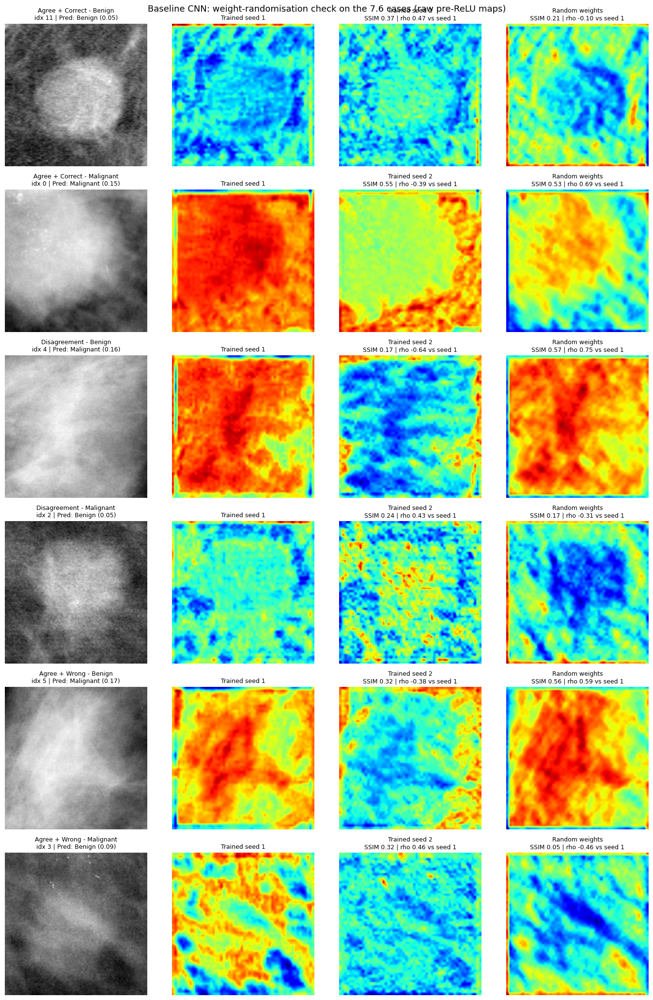

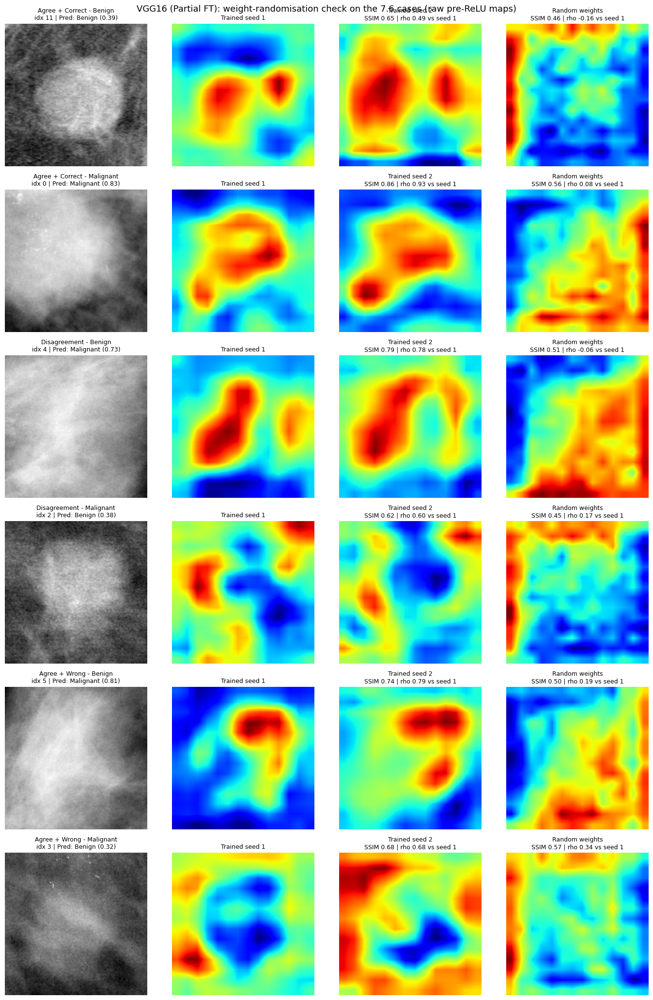

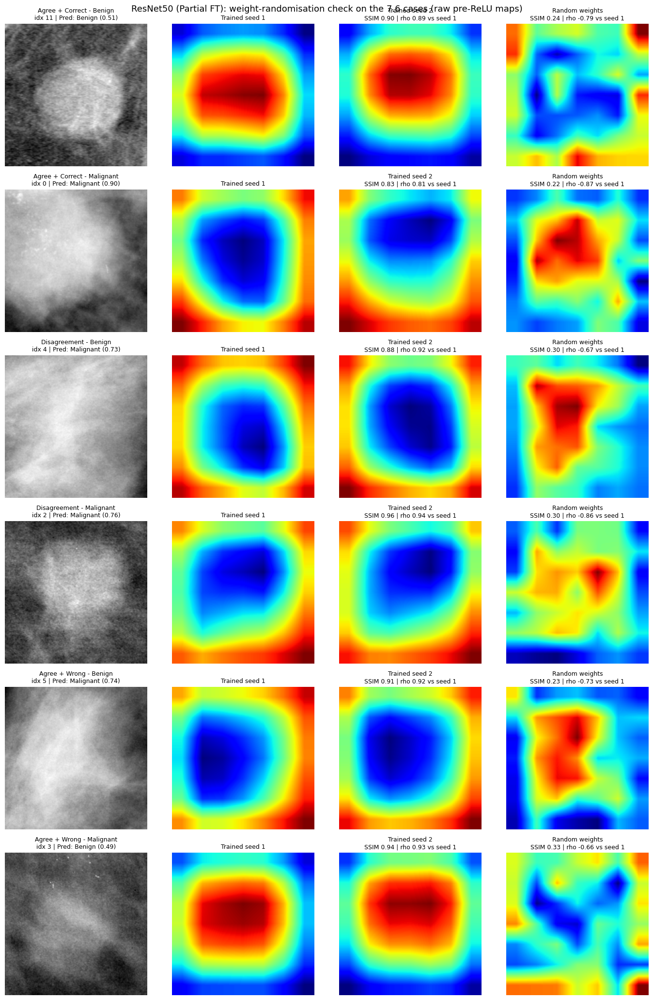

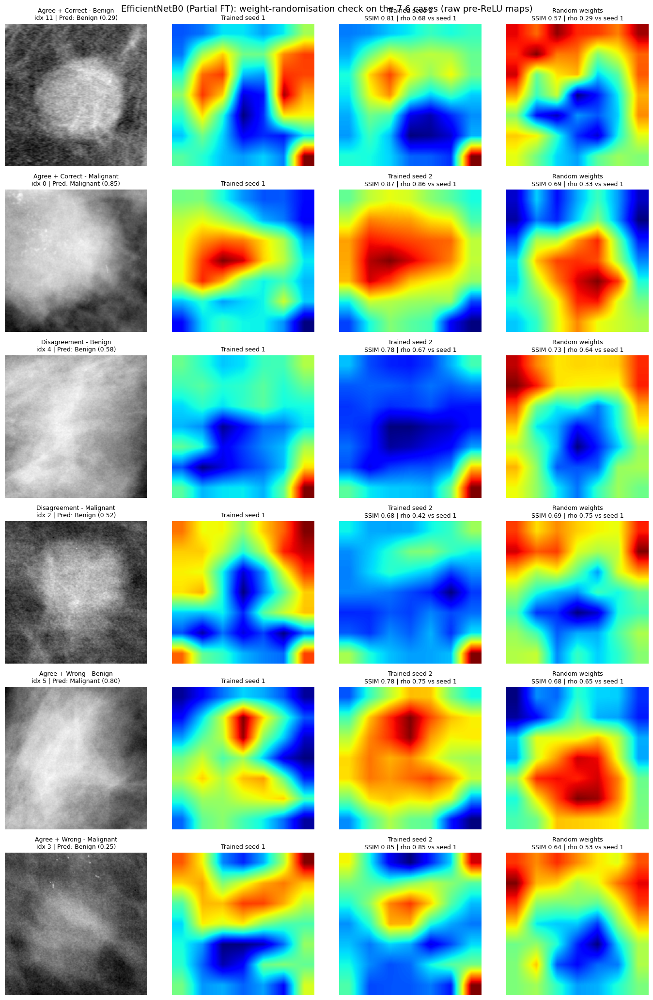

Per-case similarity (raw Grad-CAM maps, same class explained by all three models):


,Model,Case,Test index,Predicted,SSIM seed1-seed2,Spearman seed1-seed2,SSIM seed1-random,Spearman seed1-random
0,Baseline CNN,Agree + Correct - Benign,11,Benign,0.370,0.465,0.213,-0.097
1,Baseline CNN,Agree + Correct - Malignant,0,Malignant,0.555,-0.392,0.530,0.693
2,Baseline CNN,Disagreement - Benign,4,Malignant,0.172,-0.640,0.572,0.750
3,Baseline CNN,Disagreement - Malignant,2,Benign,0.237,0.435,0.168,-0.310
4,Baseline CNN,Agree + Wrong - Benign,5,Malignant,0.315,-0.381,0.558,0.593
5,Baseline CNN,Agree + Wrong - Malignant,3,Benign,0.318,0.458,0.049,-0.465
6,VGG16 (Partial FT),Agree + Correct - Benign,11,Benign,0.648,0.493,0.456,-0.160
7,VGG16 (Partial FT),Agree + Correct - Malignant,0,Malignant,0.865,0.926,0.558,0.082
8,VGG16 (Partial FT),Disagreement - Benign,4,Malignant,0.793,0.784,0.508,-0.064
9,VGG16 (Partial FT),Disagreement - Malignant,2,Benign,0.624,0.597,0.447,0.175



Mean over the 6 cases, per model (descriptive only - 6 cases is too few for a significance test; see 7.8 for that):


,SSIM seed1-seed2,SSIM seed1-random,Spearman seed1-seed2,Spearman seed1-random,"Passes (seed-seed > seed-random, both metrics)"
Model,,,,,
Baseline CNN,0.328,0.348,-0.009,0.194,False
VGG16 (Partial FT),0.725,0.507,0.711,0.094,True
ResNet50 (Partial FT),0.906,0.268,0.903,-0.762,True
EfficientNetB0 (Partial FT),0.796,0.665,0.706,0.531,True


In [ ]:
# =============================================================================
# 7.8b Weight-Randomisation Sanity Check on the Section 7.6 Cases
# =============================================================================
# Applies the 7.8 weight-randomisation test to the six representative
# cases shown in 7.5/7.6, for all four selected
# models, so the figures in 7.6 come with their own sanity check.
#
# For each model and case, three heatmaps explain the SAME class (the
# seed-averaged prediction at the pooled threshold, exactly as in 7.6):
#   seed 1 (trained), seed 2 (trained), and a randomly initialised copy.
# Raw maps (apply_relu=False) are compared, as in 7.8, so no map is blank.
# NOTE: these raw maps include negative evidence, so they look different
# from the ReLU maps displayed in 7.6. They test the explainer, not the
# figure's appearance.
#
# Pass: seed 1 vs seed 2 similar, seed 1 vs random dissimilar.
#
# Requires: Section 7.2 and 7.2b, 7.1 (gradcam_seed_models,
# gradcam_thresholds, find_last_conv_layer), 7.3 (selected_gradcam_cases),
# 7.4 (prepare_gradcam_image), 7.5 (resize_gradcam_heatmap).
# =============================================================================


import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from skimage.metrics import structural_similarity as ssim


def _is_flat(h):
    return np.allclose(h, h.flat[0])


def _similarity(h1, h2):
    """(SSIM, Spearman), or (nan, nan) if either map is flat."""
    if _is_flat(h1) or _is_flat(h2):
        return np.nan, np.nan
    return ssim(h1, h2, data_range=1.0), spearmanr(h1.ravel(), h2.ravel())[0]


def _raw_map(model, layer, x, model_name, target_class):
    h, _, _ = generate_gradcam(model, x, layer, model_name,
                               target_class=target_class, apply_relu=False)
    return resize_gradcam_heatmap(h, target_size=(224, 224))


# The six 7.6 cases, in display order.
cases_76 = [
    (scenario, label, idx)
    for scenario, by_class in selected_gradcam_cases.items()
    for label, idx in by_class.items()
    if idx is not None
]

sanity_76_rows = []

for model_name in gradcam_seed_models:
    seeds = gradcam_seed_models[model_name]
    (m1, l1), (m2, l2) = seeds[0], seeds[1]

    tf.keras.utils.set_random_seed(0)                   # reproducible random copy
    m_rand = tf.keras.models.clone_model(m1)
    m_rand.build((None, 224, 224, 3))
    l_rand = find_last_conv_layer(m_rand)

    fig, axes = plt.subplots(len(cases_76), 4, figsize=(14, 3.5 * len(cases_76)))
    axes = np.atleast_2d(axes)

    for r, (scenario, label, idx) in enumerate(cases_76):
        raw_image, processed = prepare_gradcam_image(test_image_paths[idx], model_name)

        # Class to explain = seed-averaged prediction at the pooled threshold (same as 7.6).
        _, probability, cls = ensemble_gradcam(model_name, processed)

        x = tf.convert_to_tensor(processed)
        h1 = _raw_map(m1, l1, x, model_name, cls)
        h2 = _raw_map(m2, l2, x, model_name, cls)
        hr = _raw_map(m_rand, l_rand, x, model_name, cls)

        s12, r12 = _similarity(h1, h2)
        s1r, r1r = _similarity(h1, hr)
        pred_label = "Malignant" if cls == 1 else "Benign"

        sanity_76_rows.append({
            "Model": model_name, "Case": f"{scenario} - {label}", "Test index": idx,
            "Predicted": pred_label,
            "SSIM seed1-seed2": s12, "Spearman seed1-seed2": r12,
            "SSIM seed1-random": s1r, "Spearman seed1-random": r1r,
        })

        axes[r, 0].imshow(raw_image.astype("uint8"))
        axes[r, 0].set_title(f"{scenario} - {label}\nidx {idx} | Pred: {pred_label} ({probability:.2f})",
                             fontsize=9)
        axes[r, 1].imshow(h1, cmap="jet", vmin=0, vmax=1)
        axes[r, 1].set_title("Trained seed 1", fontsize=9)
        axes[r, 2].imshow(h2, cmap="jet", vmin=0, vmax=1)
        axes[r, 2].set_title(f"Trained seed 2\nSSIM {s12:.2f} | rho {r12:.2f} vs seed 1", fontsize=9)
        axes[r, 3].imshow(hr, cmap="jet", vmin=0, vmax=1)
        axes[r, 3].set_title(f"Random weights\nSSIM {s1r:.2f} | rho {r1r:.2f} vs seed 1", fontsize=9)
        for ax in axes[r]:
            ax.axis("off")

    fig.suptitle(f"{model_name}: weight-randomisation check on the 7.6 cases "
                 f"(raw pre-ReLU maps)", fontsize=13)
    plt.tight_layout()
    plt.show()

sanity_76_df = pd.DataFrame(sanity_76_rows)

# --- Per-case table ------------------------------------------------------------
print("Per-case similarity (raw Grad-CAM maps, same class explained by all three models):")
display(sanity_76_df.round(3))

# --- Per-model summary -----------------------------------------------------------
sanity_76_summary = (
    sanity_76_df.groupby("Model", sort=False)[
        ["SSIM seed1-seed2", "SSIM seed1-random", "Spearman seed1-seed2", "Spearman seed1-random"]
    ].mean().round(3)
)
sanity_76_summary["Passes (seed-seed > seed-random, both metrics)"] = (
    (sanity_76_summary["SSIM seed1-seed2"] > sanity_76_summary["SSIM seed1-random"])
    & (sanity_76_summary["Spearman seed1-seed2"] > sanity_76_summary["Spearman seed1-random"])
)
print(f"\nMean over the {len(cases_76)} cases, per model "
      f"(descriptive only - 6 cases is too few for a significance test; see 7.8 for that):")
display(sanity_76_summary)

**Sanity check on the six representative cases (descriptive).** The same comparison is repeated on the cases shown in 7.6, so each figure has its own check. The raw maps include negative evidence, so they look different from the ReLU maps in 7.6.

| Model | SSIM seed–seed | SSIM seed–random | Spearman seed–seed | Spearman seed–random | Passes (both metrics) |
|---|---|---|---|---|---|
| Baseline CNN | 0.328 | 0.348 | −0.009 | 0.194 | No |
| VGG16 (Partial FT) | 0.725 | 0.507 | 0.711 | 0.094 | Yes |
| ResNet50 (Partial FT) | 0.906 | 0.268 | 0.903 | −0.762 | Yes |
| EfficientNetB0 (Partial FT) | 0.796 | 0.665 | 0.706 | 0.531 | Yes |

- The pattern matches the 50-image test in 7.8: the three transfer models pass and the baseline fails.
- The baseline's seed-to-seed correlations flip sign between cases (from −0.64 to +0.47), confirming that its heatmaps for the 7.6 figures are not stable explanations.
- With only six cases these are descriptive results; significance is established in 7.8.

## 8. Abnormality-Type Analysis
### 8.1 Test Set Preparation

In [ ]:
# =============================================================================
# 8.1 Abnormality-Type Test Set Preparation
# =============================================================================
# The four selected models (baseline + one winner per architecture) are
# evaluated separately on mass and calcification lesions.
#
# The same independent test set used for the main evaluation is divided by
# abnormality type. No additional training or validation split is performed.


# -------------------------------------------------------------------------
# Identify mass and calcification test cases
# -------------------------------------------------------------------------

abnormality_type = (
    test_df["abnormality type"]
    .astype(str)
    .str.upper()
)

mass_test_df = test_df[
    abnormality_type.str.contains("MASS")
].copy()

calcification_test_df = test_df[
    abnormality_type.str.contains("CALC")
].copy()


# -------------------------------------------------------------------------
# Display subset sizes
# -------------------------------------------------------------------------

print("=" * 70)
print("ABNORMALITY-TYPE TEST SET")
print("=" * 70)

print(
    f"Total test cases: "
    f"{len(test_df)}"
)

print(
    f"Mass test cases: "
    f"{len(mass_test_df)}"
)

print(
    f"Calcification test cases: "
    f"{len(calcification_test_df)}"
)


# -------------------------------------------------------------------------
# Display binary class distribution
# -------------------------------------------------------------------------

print("\nMass pathology distribution:")
print(
    mass_test_df["label"]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "Benign",
            1: "Malignant"
        }
    )
)

print("\nCalcification pathology distribution:")
print(
    calcification_test_df["label"]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "Benign",
            1: "Malignant"
        }
    )
)


# -------------------------------------------------------------------------
# Verify that all test cases belong to one of the two groups
# -------------------------------------------------------------------------

classified_cases = (
    len(mass_test_df)
    + len(calcification_test_df)
)

print(
    "\nCases classified by abnormality type:",
    classified_cases
)

print(
    "Unclassified cases:",
    len(test_df) - classified_cases
)

ABNORMALITY-TYPE TEST SET
Total test cases: 704
Mass test cases: 378
Calcification test cases: 326

Mass pathology distribution:
label
Benign       231
Malignant    147
Name: count, dtype: int64

Calcification pathology distribution:
label
Benign       197
Malignant    129
Name: count, dtype: int64

Cases classified by abnormality type: 704
Unclassified cases: 0


**Lesion-type subsets of the test set**

| Subset | Cases | Benign | Malignant | Malignant % |
|---|---|---|---|---|
| Mass | 378 | 231 | 147 | 38.9% |
| Calcification | 326 | 197 | 129 | 39.6% |
| **Total** | **704** | **428** | **276** | **39.2%** |

Every test case is assigned to exactly one lesion type (0 unclassified). Both subsets have almost the same malignant proportion, so differences in performance between them cannot be explained by class balance.

### 8.2 Mass and Calcification Evaluation

In [ ]:
# =============================================================================
# 8.2 Mass and Calcification Evaluation
# =============================================================================
# Evaluates the 4 selected models separately on mass and calcification
# lesions, using Section 6.2's POOLED predictions and pooled threshold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

# Row indices (into test_df's own order) for each abnormality type.
abnormality_type = test_df["abnormality type"].astype(str).str.upper()
mass_indices = np.where(abnormality_type.values == "MASS")[0]
calcification_indices = np.where(abnormality_type.values == "CALCIFICATION")[0]

abnormality_results = []

for config_name in gradcam_config_names:
    model_name = CONFIGS[config_name]["display"]

    # Pooled (3-seed) probability and pooled-threshold prediction, same
    # numbers Section 6 reports everywhere else, not a fresh 0.5 cutoff.
    y_prob = POOLED[config_name]["y_prob"]
    y_pred = POOLED[config_name]["y_pred"]

    for label, indices in [("Mass", mass_indices), ("Calcification", calcification_indices)]:
        subset_true = y_true[indices]
        subset_prob = y_prob[indices]
        subset_pred = y_pred[indices]

        abnormality_results.append({
            "Abnormality Type": label,
            "Model": model_name,
            "Accuracy": accuracy_score(subset_true, subset_pred),
            "Precision": precision_score(subset_true, subset_pred, zero_division=0),
            "Recall": recall_score(subset_true, subset_pred, zero_division=0),
            "F1-score": f1_score(subset_true, subset_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(subset_true, subset_prob),
        })

abnormality_results_df = pd.DataFrame(abnormality_results)

metric_columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
abnormality_results_df[metric_columns] = abnormality_results_df[metric_columns].round(4)

print("=" * 90)
print("ABNORMALITY-TYPE MODEL EVALUATION")
print("=" * 90)
display(abnormality_results_df)

ABNORMALITY-TYPE MODEL EVALUATION


,Abnormality Type,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Mass,Baseline CNN,0.4762,0.4052,0.7415,0.5240,0.6193
1,Calcification,Baseline CNN,0.6135,0.5089,0.6667,0.5772,0.6509
2,Mass,VGG16 (Partial FT),0.6640,0.5485,0.7687,0.6402,0.7392
3,Calcification,VGG16 (Partial FT),0.7055,0.6222,0.6512,0.6364,0.7694
4,Mass,ResNet50 (Partial FT),0.6958,0.5952,0.6803,0.6349,0.7686
5,Calcification,ResNet50 (Partial FT),0.6902,0.6148,0.5814,0.5976,0.7495
6,Mass,EfficientNetB0 (Partial FT),0.6878,0.5901,0.6463,0.6169,0.7402
7,Calcification,EfficientNetB0 (Partial FT),0.6871,0.6709,0.4109,0.5096,0.7553


**Performance by lesion type (pooled predictions, pooled threshold)**

| Model | Lesion | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|---|
| Baseline CNN | Mass | 0.476 | 0.405 | 0.742 | 0.524 | 0.619 |
| Baseline CNN | Calcification | 0.614 | 0.509 | 0.667 | 0.577 | 0.651 |
| VGG16 (Partial FT) | Mass | 0.664 | 0.549 | 0.769 | 0.640 | 0.739 |
| VGG16 (Partial FT) | Calcification | 0.706 | 0.622 | 0.651 | 0.636 | **0.769** |
| ResNet50 (Partial FT) | Mass | 0.696 | 0.595 | 0.680 | 0.635 | **0.769** |
| ResNet50 (Partial FT) | Calcification | 0.690 | 0.615 | 0.581 | 0.598 | 0.750 |
| EfficientNetB0 (Partial FT) | Mass | 0.688 | 0.590 | 0.646 | 0.617 | 0.740 |
| EfficientNetB0 (Partial FT) | Calcification | 0.687 | 0.671 | 0.411 | 0.510 | 0.755 |

The same stored pooled predictions are split by lesion type, so no additional inference is performed. Each subset has 326–378 images, so these estimates are less precise than the overall results.

### 8.3 Comparative Results

In [ ]:
# =============================================================================
# 8.3 Comparative Results
# =============================================================================
# Compare model performance between mass and calcification lesions.
#
# Positive differences indicate higher performance on Mass lesions.
# Negative differences indicate higher performance on Calcification lesions.
#
# No additional model inference is performed in this section.

# -------------------------------------------------------------------------
# Create a comparison table
# -------------------------------------------------------------------------

comparison_results = []


for model_name in abnormality_results_df["Model"].unique():

    # Get Mass results
    mass_result = abnormality_results_df[
        (
            abnormality_results_df["Model"]
            == model_name
        )
        &
        (
            abnormality_results_df["Abnormality Type"]
            == "Mass"
        )
    ].iloc[0]


    # Get Calcification results
    calc_result = abnormality_results_df[
        (
            abnormality_results_df["Model"]
            == model_name
        )
        &
        (
            abnormality_results_df["Abnormality Type"]
            == "Calcification"
        )
    ].iloc[0]


    # Calculate Mass - Calcification
    comparison_results.append({

        "Model": model_name,

        "Accuracy Difference":
            mass_result["Accuracy"]
            - calc_result["Accuracy"],

        "Precision Difference":
            mass_result["Precision"]
            - calc_result["Precision"],

        "Recall Difference":
            mass_result["Recall"]
            - calc_result["Recall"],

        "F1-score Difference":
            mass_result["F1-score"]
            - calc_result["F1-score"],

        "ROC-AUC Difference":
            mass_result["ROC-AUC"]
            - calc_result["ROC-AUC"]
    })


# -------------------------------------------------------------------------
# Create DataFrame
# -------------------------------------------------------------------------

abnormality_comparison_df = pd.DataFrame(
    comparison_results
)


# -------------------------------------------------------------------------
# Round values
# -------------------------------------------------------------------------

difference_columns = [
    "Accuracy Difference",
    "Precision Difference",
    "Recall Difference",
    "F1-score Difference",
    "ROC-AUC Difference"
]

abnormality_comparison_df[
    difference_columns
] = abnormality_comparison_df[
    difference_columns
].round(4)


# -------------------------------------------------------------------------
# Display comparison
# -------------------------------------------------------------------------

print("=" * 90)
print("MASS VS CALCIFICATION PERFORMANCE DIFFERENCE")
print("=" * 90)

print(
    "Difference = Mass performance - Calcification performance"
)

display(
    abnormality_comparison_df
)

MASS VS CALCIFICATION PERFORMANCE DIFFERENCE
Difference = Mass performance - Calcification performance


,Model,Accuracy Difference,Precision Difference,Recall Difference,F1-score Difference,ROC-AUC Difference
0,Baseline CNN,-0.1373,-0.1037,0.0748,-0.0532,-0.0316
1,VGG16 (Partial FT),-0.0415,-0.0737,0.1175,0.0038,-0.0302
2,ResNet50 (Partial FT),0.0056,-0.0196,0.0989,0.0373,0.0191
3,EfficientNetB0 (Partial FT),0.0007,-0.0808,0.2354,0.1073,-0.0151


**Mass - Calcification difference** (positive = better on masses)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Baseline CNN | −0.137 | −0.104 | +0.075 | −0.053 | −0.032 |
| VGG16 (Partial FT) | −0.042 | −0.074 | +0.118 | +0.004 | −0.030 |
| ResNet50 (Partial FT) | +0.006 | −0.020 | +0.099 | +0.037 | +0.019 |
| EfficientNetB0 (Partial FT) | +0.001 | −0.081 | **+0.235** | +0.107 | −0.015 |

- **Discrimination is similar for both lesion types.** AUC differences are small (−0.032 to +0.019) and go in different directions for different models: VGG16 and EfficientNetB0 rank calcifications slightly better, ResNet50 masses. Differences of this size are within the ±0.04 uncertainty of the full test set and larger still for these smaller subsets, so no model can be said to handle one lesion type better.
- **The operating point is not similar.** Every model has higher recall on masses than on calcifications (+0.08 to +0.24) and lower precision. At the pooled thresholds, malignant calcifications are more likely to be missed, most strongly for EfficientNetB0 (recall 0.646 vs 0.411).
- This is a threshold effect rather than a ranking effect: the models separate benign from malignant calcifications about as well as masses, but a single threshold shared by both lesion types suits masses better. Lesion-specific thresholds would be one way to reduce missed calcifications.
- The baseline is much less accurate on masses (0.476) than on calcifications (0.614), mainly because it over-calls benign masses.

### 8.4 Visual Comparison

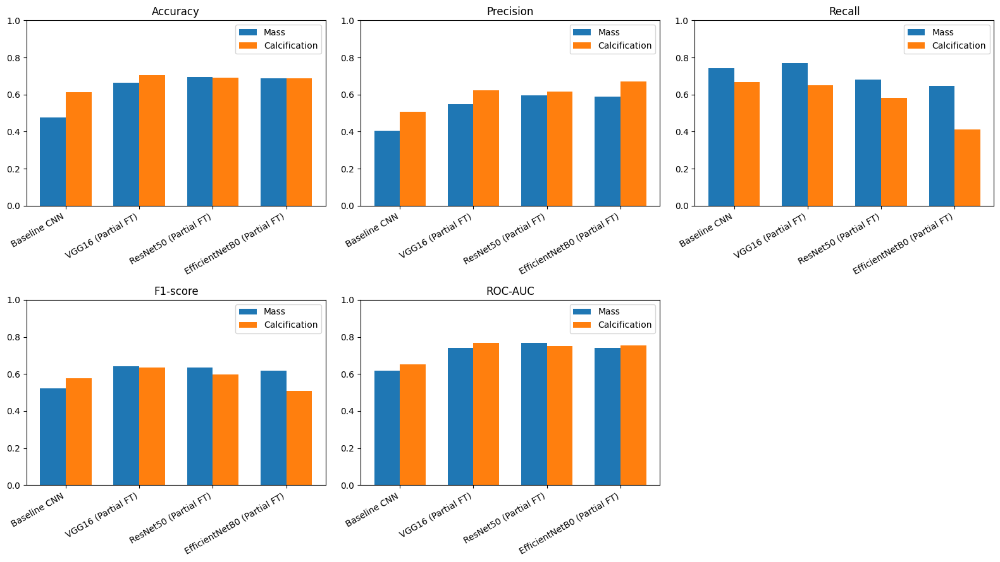

In [ ]:
# =============================================================================
# 8.4 Visual Comparison
# =============================================================================
# Grouped bar chart, Mass vs Calcification, one panel per metric.
# Reuses abnormality_results_df from 8.2, no extra inference.

import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
models = abnormality_results_df["Model"].unique()
x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    mass_vals = [
        abnormality_results_df[
            (abnormality_results_df["Model"] == m) &
            (abnormality_results_df["Abnormality Type"] == "Mass")
        ][metric].values[0]
        for m in models
    ]
    calc_vals = [
        abnormality_results_df[
            (abnormality_results_df["Model"] == m) &
            (abnormality_results_df["Abnormality Type"] == "Calcification")
        ][metric].values[0]
        for m in models
    ]

    ax.bar(x - width/2, mass_vals, width, label="Mass")
    ax.bar(x + width/2, calc_vals, width, label="Calcification")
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.legend()

axes[-1].axis("off")  # unused 6th slot
plt.tight_layout()
plt.savefig("abnormality_visual_comparison.png", dpi=150)
plt.show()